# Scientific teams with more debutants are disproportionately disruptive

## Manuscript analysis and figure reproduction

This notebook reproduces the statistical analyses, robustness checks, tables,
and figures reported in the manuscript.

It assumes that the repository's upstream preprocessing has already been run.
The required inputs are:

```text
data/disruption_analysis.csv

data/sciscinet_field_reconstruction_v2/
    analysis_level0_field_memberships.parquet

data/sciscinet_exact_career_age_v2/
    v9_exact_career_age_handoff.parquet
```

The first file is generated by the BigQuery preprocessing pipeline. The field
and exact-career-age files are generated by:

```text
01_prepare_sciscinet_fields.ipynb
02_prepare_exact_career_age.ipynb
```

The main paper-level sample contains 29,054,261 research articles published
from 1941 through 2020. Analyses requiring complete exact-career-age
reconstruction use 29,054,201 papers.

The notebook is distributed with its executed outputs so that the reported
tables and figures can be inspected without rerunning the full analysis.
Figures are also written as vector PDFs, and supporting numerical outputs are
saved as CSV or LaTeX tables where appropriate.

## Environment setup

Install the analysis dependencies in the Jupyter environment:

```bash
pip install -U polars pyarrow numpy scipy pandas statsmodels matplotlib psutil duckdb
```

Restart the kernel after installation.

Polars is used for large-scale columnar processing, NumPy/SciPy/statsmodels for
statistical estimation, and DuckDB for the disk-backed joins used in the field
analyses.

In [1]:
from pathlib import Path
from time import perf_counter
import os
import gc
import math
import json
import warnings

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import matplotlib as mpl
import duckdb

from scipy import stats
from scipy.stats import kendalltau, ks_2samp
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore", category=RuntimeWarning)

DATA_PATH = Path(r"data\disruption_analysis.csv")

CACHE_DIR = Path(r"data\beginners_charm_cache_nov9_v3")
FILTERED_CACHE = CACHE_DIR / "01_filtered_raw.parquet"
ANALYSIS_CACHE = CACHE_DIR / "02_analysis_with_percentiles.parquet"
FIELD_BASE_CACHE = CACHE_DIR / "04_field_base_with_paperid.parquet"
FIELD_ANALYSIS_CACHE = CACHE_DIR / "05_canonical_level0_field_analysis_long.parquet"

LEVEL0_MEMBERSHIP_PATH = Path(
    r"data\sciscinet_field_reconstruction_v2\analysis_level0_field_memberships.parquet"
)

PRODUCTIVITY_CANDIDATES = [
    Path(r"data\average_num_of_papers_by_career_age.csv"),
    Path(r"average_num_of_papers_by_career_age.csv"),
]

OUTPUT_DIR = Path("Reanalysis_Results_v9")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
LOG_DIR = OUTPUT_DIR / "logs"

for _d in [FIGURE_DIR, TABLE_DIR, LOG_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

START_YEAR = 1941
MAX_TEAM_SIZE = 40
C10_COMPLETE_THROUGH = 2010

FORCE_REBUILD_FILTERED_CACHE = False
FORCE_REBUILD_ANALYSIS_CACHE = False

# Full-data Kendall tau is relatively expensive and single-machine SciPy
# does not exploit all 19 cores well. Turn on only if specifically needed.
RUN_FULL_DATA_KENDALL = True

# Canonical field analyses now use the separately reconstructed
# SciSciNet-v2 Level-0 multi-membership file.
RUN_CANONICAL_FIELD_ANALYSIS = True

# Kendall tau on the very large exploded field table is optional and not needed
# for the revised main inference, which uses Pearson/Spearman plus adjusted FE.
RUN_CANONICAL_FIELD_KENDALL = True

# V9 reproduces the earlier rank-correlation tables as well as the revised
# regression results. Set False only if you intentionally want a faster
# exploratory rerun.
RUN_LEGACY_RAW_KENDALL = True

# Plot-point Kendall tables use the same binned/median points as the original
# visualization logic and bootstrap those plot points.
LEGACY_KENDALL_BOOTSTRAPS = 2000
LEGACY_KENDALL_SEED = 123


# DuckDB settings for the field-only join.
FIELD_JOIN_MEMORY_LIMIT = "32GB"
FIELD_JOIN_THREADS = 19
FIELD_DUCKDB_TEMP = CACHE_DIR / "duckdb_field_temp"
FIELD_DUCKDB_TEMP.mkdir(parents=True, exist_ok=True)

# Limits temporary RAM use during HC1 sandwich accumulation.
REGRESSION_CHUNK_ROWS = 2_000_000

print("Input:", DATA_PATH.resolve())
print("Polars version:", pl.__version__)
print("Polars thread pool:", pl.thread_pool_size())
print("Logical CPUs visible to Python:", os.cpu_count())
print("Outputs:", OUTPUT_DIR.resolve())
print("Canonical 19-field analysis:", RUN_CANONICAL_FIELD_ANALYSIS)
print("Expected Level-0 membership file:", LEVEL0_MEMBERSHIP_PATH.resolve())
print("Productivity candidates:")
for _p in PRODUCTIVITY_CANDIDATES:
    print(" ", _p.resolve())
print("Atypicality policy: exclude null and non-finite Atyp_Median_Z values.")

def parquet_cache_is_valid(path, required_columns=None):
    """Metadata-only validation; avoids reusing a partial file after a failed write."""
    path = Path(path)
    if not path.exists() or path.stat().st_size == 0:
        return False
    try:
        schema = pl.scan_parquet(path).collect_schema()
        names = set(schema.names())
        if required_columns is not None:
            return set(required_columns).issubset(names)
        return True
    except Exception:
        return False

def remove_invalid_cache(path, required_columns=None):
    path = Path(path)
    if path.exists() and not parquet_cache_is_valid(path, required_columns):
        print("Removing incomplete/incompatible cache:", path.resolve())
        try:
            path.unlink()
        except FileNotFoundError:
            pass

try:
    import psutil
    vm = psutil.virtual_memory()
    print(f"System RAM: {vm.total / 2**30:.1f} GB")
    print(f"Available RAM now: {vm.available / 2**30:.1f} GB")
except Exception:
    pass

Input: D:\beginners_charm\new_statistical_analysis\data\disruption_analysis_nov9.csv
Polars version: 1.36.1
Polars thread pool: 20
Logical CPUs visible to Python: 20
Outputs: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9
Canonical 19-field analysis: True
Expected Level-0 membership file: D:\beginners_charm\new_statistical_analysis\data\sciscinet_field_reconstruction_v2\analysis_level0_field_memberships.parquet
Productivity candidates:
  D:\beginners_charm\new_statistical_analysis\data\average_num_of_papers_by_career_age.csv
  average_num_of_papers_by_career_age.csv
Atypicality policy: exclude null and non-finite Atyp_Median_Z values.
System RAM: 63.8 GB
Available RAM now: 54.0 GB


### Figure and table output

Figures are saved as vector PDFs. Key statistical tables are exported as both
CSV and LaTeX, while larger figure-data tables are saved as CSV.

In [2]:
# ------------------------------------------------------------------
# Final publication-figure style (v9)
# ------------------------------------------------------------------
# IMPORTANT: these are the same core colors used in the v7 figures.
#
# V7 palette:
#   orange      #E66101
#   pale orange #FDB863
#   mint        #80CDC1
#   dark teal   #01665E
#
# V9 changes the semantic ORDER where requested, not the palette itself.
# Thus debutant/high-debutant-share is dark teal and senior/low-share is orange.
# Single-estimate inferential curves retain the v7 orange styling.

COLORS = {
    "text": "#252525",
    "axis": "#4A4A4A",
    "grid": "#D9D9D9",
    "grid_light": "#ECECEC",
    "neutral": "#6F6F6F",
    "neutral_light": "#BDBDBD",
    "orange": "#E66101",
    "pale_orange": "#FDB863",
    "mint": "#80CDC1",
    "teal": "#01665E",
    "dark_teal": "#003C30",
}

# Career-stage ordering requested after inspecting v7:
# Debutant = dark teal, senior = orange.
CAREER3_COLORS = {
    "Debutant": COLORS["teal"],
    "Early career (1–10)": COLORS["mint"],
    "Senior (>10)": COLORS["orange"],
}
CAREER3_MARKERS = {
    "Debutant": "o",
    "Early career (1–10)": "s",
    "Senior (>10)": "D",
}

CAREER4_COLORS = {
    "Debutant": COLORS["teal"],
    "Early career (1–5)": COLORS["mint"],
    "Mid career (6–10)": COLORS["pale_orange"],
    "Senior (>10)": COLORS["orange"],
}
CAREER4_MARKERS = {
    "Debutant": "o",
    "Early career (1–5)": "^",
    "Mid career (6–10)": "s",
    "Senior (>10)": "D",
}

# Exact v7 four-color sequence, reversed so higher debutant share is the
# cool/dark endpoint and lower debutant share is the warm endpoint.
DEBUT_QUARTILE_COLORS = {
    "0.00 - 0.25": COLORS["orange"],
    "0.25 - 0.50": COLORS["pale_orange"],
    "0.50 - 0.75": COLORS["mint"],
    "0.75 - 1.00": COLORS["teal"],
    "0.00–0.25": COLORS["orange"],
    "0.25–0.50": COLORS["pale_orange"],
    "0.50–0.75": COLORS["mint"],
    "0.75–1.00": COLORS["teal"],
}
DEBUT_QUARTILE_DISPLAY = {
    "0.00 - 0.25": "Q1: 0–25%",
    "0.25 - 0.50": "Q2: 25–50%",
    "0.50 - 0.75": "Q3: 50–75%",
    "0.75 - 1.00": "Q4: 75–100%",
    "0.00–0.25": "Q1: 0–25%",
    "0.25–0.50": "Q2: 25–50%",
    "0.50–0.75": "Q3: 50–75%",
    "0.75–1.00": "Q4: 75–100%",
}

# Single-estimate/regression figures keep the v7 orange.
ESTIMATE_COLOR = COLORS["orange"]

HEATMAP_CMAP = mpl.colormaps["YlGnBu"].copy()
HEATMAP_CMAP.set_bad("white")

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": COLORS["axis"],
    "axes.labelcolor": COLORS["text"],
    "axes.titlecolor": COLORS["text"],
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "font.size": 9.5,
    "axes.labelsize": 10.0,
    "axes.titlesize": 10.5,
    "xtick.labelsize": 8.8,
    "ytick.labelsize": 8.8,
    "xtick.color": COLORS["text"],
    "ytick.color": COLORS["text"],
    "xtick.major.width": 0.7,
    "ytick.major.width": 0.7,
    "xtick.major.size": 3.0,
    "ytick.major.size": 3.0,
    "lines.linewidth": 1.7,
    "lines.markersize": 4.2,
    "legend.fontsize": 8.5,
    "legend.title_fontsize": 8.7,
    "legend.frameon": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

PUBLICATION_FILES = []

def apply_science_axes(ax, grid="y"):
    """Restrained v7/Science-like axes."""
    ax.spines["left"].set_color(COLORS["axis"])
    ax.spines["bottom"].set_color(COLORS["axis"])
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)

    if grid == "y":
        ax.grid(
            axis="y",
            color=COLORS["grid"],
            linewidth=0.65,
            alpha=0.75,
            zorder=0,
        )
    elif grid == "both":
        ax.grid(
            color=COLORS["grid_light"],
            linewidth=0.6,
            alpha=0.75,
            zorder=0,
        )

    ax.set_axisbelow(True)
    ax.tick_params(direction="out")

def add_zero_line(ax, orientation="h"):
    kwargs = dict(
        color=COLORS["neutral"],
        linewidth=0.9,
        linestyle="-",
        zorder=1,
    )
    if orientation == "h":
        ax.axhline(0, **kwargs)
    else:
        ax.axvline(0, **kwargs)

def fisher_r_ci(r, n, alpha=0.05):
    """Large-sample Fisher-z confidence interval for a correlation."""
    if not np.isfinite(r) or n is None or n <= 3:
        return (np.nan, np.nan)

    r = float(np.clip(r, -0.999999, 0.999999))
    z = np.arctanh(r)
    se = 1.0 / np.sqrt(n - 3.0)
    crit = stats.norm.ppf(1 - alpha / 2)

    return (
        float(np.tanh(z - crit * se)),
        float(np.tanh(z + crit * se)),
    )

def add_fisher_ci_columns(df, r_col, n_col="n", prefix="r"):
    vals = [
        fisher_r_ci(r, n)
        for r, n in zip(df[r_col], df[n_col])
    ]
    df[f"{prefix}_ci95_low"] = [x[0] for x in vals]
    df[f"{prefix}_ci95_high"] = [x[1] for x in vals]
    return df

def save_pub_figure(fig, stem):
    """Save publication figure as vector PDF only."""
    pdf_path = FIGURE_DIR / f"{stem}.pdf"

    fig.savefig(
        pdf_path,
        dpi=300,
        facecolor="white",
        bbox_inches="tight",
        pad_inches=0.06,
    )

    PUBLICATION_FILES.append(str(pdf_path.resolve()))
    print("Saved figure:", pdf_path.resolve())
    return pdf_path

def export_pub_table(df, stem, index=False, float_format="%.5f"):
    csv_path = TABLE_DIR / f"{stem}.csv"
    tex_path = TABLE_DIR / f"{stem}.tex"

    df.to_csv(csv_path, index=index)

    try:
        tex = df.to_latex(
            index=index,
            escape=True,
            float_format=float_format,
        )
        tex_path.write_text(tex, encoding="utf-8")
        PUBLICATION_FILES.append(str(tex_path.resolve()))
    except Exception as exc:
        print(f"LaTeX export warning for {stem}: {exc}")

    PUBLICATION_FILES.append(str(csv_path.resolve()))
    print("Saved table:", csv_path.resolve())
    if tex_path.exists():
        print("Saved table:", tex_path.resolve())

    return csv_path, tex_path

def export_figure_data(df, stem, index=False):
    csv_path = TABLE_DIR / f"FigureData_{stem}.csv"
    df.to_csv(csv_path, index=index)
    PUBLICATION_FILES.append(str(csv_path.resolve()))
    print("Saved figure data:", csv_path.resolve())
    return csv_path

def resolve_productivity_path():
    """Return the first existing productivity CSV candidate."""
    for p in PRODUCTIVITY_CANDIDATES:
        if p.exists():
            return p
    return None

# Build analysis caches

The paper-level preprocessing follows the manuscript analysis sample:

- research articles only;
- publication years 1941–2020;
- team size at most 40;
- removal of internally inconsistent all-debutant records;
- debutants defined at publication career age 0;
- early-career authors defined as career ages 1–10;
- senior authors defined as more than 10 years past publication debut.

The original 1–5 and 6–10 variables are retained internally because they are
needed to reconstruct the manuscript's 1–10-year early-career measures and for
validation of the exact-career-age reconstruction.

In [3]:
# Read only the CSV header/schema first. This is cheap compared with scanning 13+ GB.
RAW_SCHEMA = pl.scan_csv(
    DATA_PATH,
    infer_schema_length=100_000,
    ignore_errors=False,
    try_parse_dates=False,
).collect_schema()

RAW_COLUMNS = set(RAW_SCHEMA.names())

# The older export used level_0_field_names / level_1_field_names.
# The November export supplied here uses field_name.
FIELD_CANDIDATES = [
    "level_0_field_names",
    "field_name",
]

FIELD_SOURCE_COL = next(
    (c for c in FIELD_CANDIDATES if c in RAW_COLUMNS),
    None,
)

if FIELD_SOURCE_COL is None:
    raise ValueError(
        "No supported field column was found. "
        f"Looked for {FIELD_CANDIDATES}. "
        f"CSV columns are: {sorted(RAW_COLUMNS)}"
    )

REQUIRED_BASE_COLS = [
    "doctype",
    "team_size",
    "year",
    "first_time_author_ratio",
    "avg_career_age",
    "senior_author_avg_disruption",
    "mid_career_author_ratio",
    "early_author_avg_disruption",
    "early_career_author_ratio",
    "mid_author_avg_disruption",
    "disruption",
    "citation_count",
    "C10",
    "avg_disruption",
    "avg_citation_count",
    "Atyp_Median_Z",
    "avg_reference_age",
    "median_reference_age",
    "avg_reference_popularity",
    "median_reference_popularity",
    "senior_author_ratio",
    "first_time_author_count",
    "mid_career_author_count",
    "early_career_author_count",
    "senior_author_count",
]

missing_required = [c for c in REQUIRED_BASE_COLS if c not in RAW_COLUMNS]
if missing_required:
    raise ValueError(
        "The CSV is missing columns required by the notebook:\n"
        + "\n".join(f"  - {c}" for c in missing_required)
    )

REQUIRED_COLS = REQUIRED_BASE_COLS + [FIELD_SOURCE_COL]

PERCENTILE_SOURCE_COLS = [
    "disruption",
    "citation_count",
    "C10",
    "avg_disruption",
    "avg_citation_count",
    "Atyp_Median_Z",
    "avg_reference_age",
    "median_reference_age",
    "avg_reference_popularity",
    "median_reference_popularity",
]

print(f"Detected field column: {FIELD_SOURCE_COL!r}")
print(f"CSV contains {len(RAW_COLUMNS)} columns.")
print("Required analysis columns are present.")

def bad_all_beginner_expr():
    signals = [
        (pl.col("avg_career_age") > 0).fill_null(False),
        (pl.col("senior_author_avg_disruption") > 0).fill_null(False),
        (pl.col("senior_author_ratio") > 0).fill_null(False),
        (pl.col("mid_career_author_ratio") > 0).fill_null(False),
        (pl.col("mid_author_avg_disruption") > 0).fill_null(False),
        (pl.col("early_career_author_ratio") > 0).fill_null(False),
        (pl.col("early_author_avg_disruption") > 0).fill_null(False),
    ]
    return (
        (pl.col("first_time_author_ratio") == 1)
        & pl.any_horizontal(signals)
    ).fill_null(False)

def rank_pct(colname):
    return (
        pl.col(colname).rank(method="average")
        / pl.col(colname).count()
        * 100
    ).cast(pl.Float32).alias(f"{colname}_percentile")

def rank_pct_within_year(colname, alias):
    return (
        pl.col(colname).rank(method="average").over("year")
        / pl.col(colname).count().over("year")
        * 100
    ).cast(pl.Float32).alias(alias)

Detected field column: 'field_name'
CSV contains 48 columns.
Required analysis columns are present.


### Input schema check

The analysis CSV contains a scalar field label in addition to the variables
used for the paper-level analyses. This field is detected here for compatibility
with the preprocessing output.

The manuscript's 19-field analyses do not use this scalar field label; they use
the canonical SciSciNet-v2 Level-0 multi-membership file prepared by
`01_prepare_sciscinet_fields.ipynb`.

In [4]:
# Small schema report. No full CSV scan occurs here.
schema_report = pd.DataFrame({
    "column": RAW_SCHEMA.names(),
    "dtype": [str(dtype) for dtype in RAW_SCHEMA.dtypes()],
})

display(schema_report)

print("\nField source:", FIELD_SOURCE_COL)
print("The November export should use field_name.")

,column,dtype
0,paperid,String
1,doi,String
2,year,Int64
3,doctype,String
4,citation_count,Int64
5,C10,Int64
6,disruption,Float64
7,Atyp_Median_Z,Float64
8,Atyp_10pct_Z,Float64
9,Atyp_Pairs,Int64



Field source: field_name
The November export should use field_name.


### Data-treatment and integrity checks

The analysis dataset is checked for:

- one row per paper in the analysis scope;
- career-stage counts that sum to team size;
- career-stage shares that sum to one and agree with the corresponding counts;
- valid disruption values and nonnegative count variables.

Two additional treatments are used throughout the manuscript analyses:

1. **Atypicality.** Non-finite `Atyp_Median_Z` values are treated as unavailable.
   Atypicality ranks and tests therefore use only finite observations.
2. **Prior disruption of early-career collaborators.** The stored 1–5-year and
   6–10-year collaborator means are combined into a count-weighted 1–10-year
   mean, using whichever component stages are represented on the paper.

Canonical broad-field analyses use the Level-0 SciSciNet-v2 memberships
prepared separately in `01_prepare_sciscinet_fields.ipynb`.

## 1.1 First pass: 13+ GB CSV → filtered Parquet

This is the only stage that scans the raw CSV. Polars selects only the required columns and applies the main filters before writing a Zstandard-compressed cache.

In [5]:
FILTERED_REQUIRED_COLUMNS = [
    "year",
    "team_size",
    "first_time_author_ratio",
    "early_career_author_ratio_main",
    "senior_author_ratio",
    "field_names_for_analysis",
]

def build_filtered_cache(force=False):
    # A failed sink can leave a partial file. Never reuse it blindly.
    remove_invalid_cache(FILTERED_CACHE, FILTERED_REQUIRED_COLUMNS)

    if FILTERED_CACHE.exists() and not force:
        print("Filtered cache already exists and passed schema validation:")
        print(" ", FILTERED_CACHE.resolve())
        return

    if not DATA_PATH.exists():
        raise FileNotFoundError(
            f"Could not find input CSV:\n{DATA_PATH.resolve()}"
        )

    if force and FILTERED_CACHE.exists():
        FILTERED_CACHE.unlink()

    t0 = perf_counter()

    lf = (
        pl.scan_csv(
            DATA_PATH,
            infer_schema_length=100_000,
            ignore_errors=False,
            try_parse_dates=False,
        )
        .select(REQUIRED_COLS)
        .with_columns([
            pl.col("year").cast(pl.Int32, strict=False),
            pl.col("team_size").cast(pl.Int16, strict=False),

            # Normalize old/new export schemas to one internal name.
            pl.col(FIELD_SOURCE_COL)
              .cast(pl.String, strict=False)
              .alias("field_names_for_analysis"),
        ])
        .filter(pl.col("doctype") == "article")
        .filter(pl.col("team_size") <= MAX_TEAM_SIZE)
        .filter(pl.col("year") >= START_YEAR)
        .filter(~bad_all_beginner_expr())
        .with_columns([
            pl.col("early_career_author_ratio")
              .alias("early_1_5_author_ratio"),
            pl.col("mid_career_author_ratio")
              .alias("mid_6_10_author_ratio"),
            pl.col("early_career_author_count")
              .alias("early_1_5_author_count"),
            pl.col("mid_career_author_count")
              .alias("mid_6_10_author_count"),

            # Match the repository's 1–5 + 6–10 = 1–10 construction.
            (
                pl.col("early_career_author_ratio")
                + pl.col("mid_career_author_ratio")
            ).alias("early_career_author_ratio_main"),

            (
                pl.col("early_career_author_count")
                + pl.col("mid_career_author_count")
            ).alias("early_career_author_count_main"),

            # Correct count-weighted 1–10-year collaborator prior disruption.
            # Stage means are structurally null exactly when that stage count is zero.
            pl.when(
                (
                    pl.col("early_career_author_count")
                    + pl.col("mid_career_author_count")
                ) > 0
            )
            .then(
                (
                    pl.col("early_career_author_count")
                    * pl.col("early_author_avg_disruption").fill_null(0.0)
                    + pl.col("mid_career_author_count")
                    * pl.col("mid_author_avg_disruption").fill_null(0.0)
                )
                /
                (
                    pl.col("early_career_author_count")
                    + pl.col("mid_career_author_count")
                )
            )
            .otherwise(None)
            .alias("early_1_10_author_avg_disruption"),
        ])
        # Do not keep the source-specific field name; keep the canonical one.
        .drop(FIELD_SOURCE_COL)
    )

    print("Streaming filtered data to:", FILTERED_CACHE.resolve())

    try:
        lf.sink_parquet(
            FILTERED_CACHE,
            compression="zstd",
            compression_level=3,
            statistics=True,
            maintain_order=True,
        )
    except Exception:
        # Avoid a corrupt/partial cache silently being reused on the next run.
        if FILTERED_CACHE.exists():
            try:
                FILTERED_CACHE.unlink()
            except Exception:
                pass
        raise

    if not parquet_cache_is_valid(FILTERED_CACHE, FILTERED_REQUIRED_COLUMNS):
        raise RuntimeError(
            "Filtered Parquet write completed but cache validation failed."
        )

    print(f"Finished in {(perf_counter() - t0) / 60:.2f} minutes.")

build_filtered_cache(FORCE_REBUILD_FILTERED_CACHE)

Filtered cache already exists and passed schema validation:
  D:\beginners_charm\new_statistical_analysis\data\beginners_charm_cache_nov9_v3\01_filtered_raw.parquet


### If the previous failed run left a partial file

This version checks the Parquet metadata before reuse and deletes an incomplete/incompatible cache automatically. You should therefore be able to rerun from the top without manually cleaning the cache directory.

A successful first-pass cell should end with a `Finished in ... minutes` message.

## 1.2 Second pass: repository percentiles + compact analysis cache

This starts from Parquet, not CSV.

It reproduces the repository's global percentile ranks and adds:

- disruption percentile within publication year;
- \(C_{10}\) percentile within publication year.

Those two additions are robustness variables, not new substantive outcomes.

In [6]:
ANALYSIS_KEEP_RAW = [
    "year", "team_size",
    "first_time_author_ratio",
    "early_career_author_ratio_main",
    "senior_author_ratio",
    "early_1_5_author_ratio",
    "mid_6_10_author_ratio",
    "first_time_author_count",
    "early_career_author_count_main",
    "senior_author_count",
    "early_1_10_author_avg_disruption",
    "senior_author_avg_disruption",
    "disruption", "citation_count", "C10",
    "avg_disruption", "avg_citation_count",
    "Atyp_Median_Z",
    "avg_reference_age", "median_reference_age",
    "avg_reference_popularity", "median_reference_popularity",
    "field_names_for_analysis",
]

ANALYSIS_REQUIRED_COLUMNS = [
    "year",
    "team_size",
    "first_time_author_ratio",
    "disruption_percentile",
    "disruption_percentile_within_year",
    "C10_percentile_within_year",
    "field_names_for_analysis",
]

def build_analysis_cache(force=False):
    remove_invalid_cache(ANALYSIS_CACHE, ANALYSIS_REQUIRED_COLUMNS)

    if ANALYSIS_CACHE.exists() and not force:
        print("Analysis cache already exists and passed schema validation:")
        print(" ", ANALYSIS_CACHE.resolve())
        return

    if force and ANALYSIS_CACHE.exists():
        ANALYSIS_CACHE.unlink()

    t0 = perf_counter()
    lf = pl.scan_parquet(FILTERED_CACHE)

    # Atypicality cleanup:
    # +inf/-inf are not legitimate rankable observations.
    # Preserve finite values; convert null or non-finite values to null.
    lf = lf.with_columns(
        pl.when(pl.col("Atyp_Median_Z").is_finite())
          .then(pl.col("Atyp_Median_Z"))
          .otherwise(None)
          .alias("Atyp_Median_Z")
    )

    percentile_exprs = [rank_pct(c) for c in PERCENTILE_SOURCE_COLS]
    percentile_exprs += [
        rank_pct("early_1_10_author_avg_disruption"),
        rank_pct("senior_author_avg_disruption"),
    ]
    percentile_exprs += [
        rank_pct_within_year(
            "disruption",
            "disruption_percentile_within_year",
        ),
        rank_pct_within_year(
            "C10",
            "C10_percentile_within_year",
        ),
    ]

    lf = lf.with_columns(percentile_exprs)

    compact_exprs = [
        pl.col("year").cast(pl.Int16),
        pl.col("team_size").cast(pl.Int8),
        pl.col("first_time_author_count").cast(pl.Int16, strict=False),
        pl.col("early_career_author_count_main").cast(pl.Int16, strict=False),
        pl.col("senior_author_count").cast(pl.Int16, strict=False),
    ]

    float_cols = [
        "first_time_author_ratio",
        "early_career_author_ratio_main",
        "senior_author_ratio",
        "early_1_5_author_ratio",
        "mid_6_10_author_ratio",
        "early_1_10_author_avg_disruption",
        "senior_author_avg_disruption",
        "disruption",
        "avg_disruption",
        "Atyp_Median_Z",
        "avg_reference_age",
        "median_reference_age",
        "avg_reference_popularity",
        "median_reference_popularity",
    ]
    compact_exprs += [
        pl.col(c).cast(pl.Float32, strict=False) for c in float_cols
    ]

    rank_cols = [f"{c}_percentile" for c in PERCENTILE_SOURCE_COLS] + [
        "early_1_10_author_avg_disruption_percentile",
        "senior_author_avg_disruption_percentile",
        "disruption_percentile_within_year",
        "C10_percentile_within_year",
    ]

    lf = lf.with_columns(compact_exprs).select(
        ANALYSIS_KEEP_RAW + rank_cols
    )

    print("Building analysis cache:", ANALYSIS_CACHE.resolve())
    lf.sink_parquet(
        ANALYSIS_CACHE,
        compression="zstd",
        compression_level=3,
        statistics=True,
        maintain_order=True,
    )

    if not parquet_cache_is_valid(ANALYSIS_CACHE, ANALYSIS_REQUIRED_COLUMNS):
        raise RuntimeError(
            "Analysis Parquet write completed but cache validation failed."
        )

    print(f"Finished in {(perf_counter() - t0) / 60:.2f} minutes.")

build_analysis_cache(FORCE_REBUILD_ANALYSIS_CACHE)

Analysis cache already exists and passed schema validation:
  D:\beginners_charm\new_statistical_analysis\data\beginners_charm_cache_nov9_v3\02_analysis_with_percentiles.parquet


## 1.3 Cache audit

In [7]:
audit = (
    pl.scan_parquet(ANALYSIS_CACHE)
    .select([
        pl.len().alias("n_papers"),
        pl.col("year").min().alias("min_year"),
        pl.col("year").max().alias("max_year"),
        pl.col("team_size").median().alias("median_team_size"),
        pl.col("first_time_author_ratio").mean().alias("mean_beginner_ratio"),
        pl.col("first_time_author_ratio").median().alias("median_beginner_ratio"),
        pl.col("disruption").null_count().alias("missing_disruption"),
        pl.col("C10").null_count().alias("missing_C10"),
        pl.col("Atyp_Median_Z").null_count().alias("missing_atypicality"),
    ])
    .collect()
)

display(audit.to_pandas())

for p in [DATA_PATH, FILTERED_CACHE, ANALYSIS_CACHE]:
    if p.exists():
        print(f"{p.name}: {p.stat().st_size / 2**30:.2f} GB")

,n_papers,min_year,max_year,median_team_size,mean_beginner_ratio,median_beginner_ratio,missing_disruption,missing_C10,missing_atypicality
0,29054261,1941,2020,3.0,0.130498,0.0,0,0,5397420


disruption_analysis_nov9.csv: 13.06 GB
01_filtered_raw.parquet: 1.56 GB
02_analysis_with_percentiles.parquet: 1.93 GB


### Atypicality finite-sample audit

This verifies that the analysis cache no longer ranks `+inf` values. The finite count should match the previously observed 23,656,841 papers unless the upstream CSV changes.

In [8]:
atyp_cache_audit = (
    pl.scan_parquet(ANALYSIS_CACHE)
    .select([
        pl.len().alias("N"),
        pl.col("Atyp_Median_Z").null_count().alias("null_after_cleaning"),
        pl.col("Atyp_Median_Z").is_finite().sum().alias("finite"),
        pl.col("Atyp_Median_Z_percentile").null_count()
          .alias("percentile_null"),
        pl.col("Atyp_Median_Z_percentile").min()
          .alias("percentile_min"),
        pl.col("Atyp_Median_Z_percentile").max()
          .alias("percentile_max"),
    ])
    .collect()
)

display(atyp_cache_audit.to_pandas())

,N,null_after_cleaning,finite,percentile_null,percentile_min,percentile_max
0,29054261,5397420,23656841,5397420,0.000004,100.0


### Scalar field-label diagnostic

This diagnostic summarizes the scalar field label contained in the main
analysis CSV. It is not used for the manuscript's 19-field robustness analysis,
which uses the canonical SciSciNet-v2 Level-0 multi-membership reconstruction.

In [9]:
field_audit = (
    pl.scan_parquet(ANALYSIS_CACHE)
    .select("field_names_for_analysis")
    .filter(pl.col("field_names_for_analysis").is_not_null())
    .with_columns(
        pl.col("field_names_for_analysis")
          .str.split("|")
          .alias("field")
    )
    .explode("field")
    .filter(pl.col("field").str.len_chars() > 0)
    .group_by("field")
    .agg(pl.len().alias("n"))
    .sort("n", descending=True)
    .collect()
)

display(field_audit.to_pandas())
print("Unique field labels:", field_audit.height)

,field,n
0,Physics,3461091
1,Internal medicine,2389719
2,Statistics,1656442
3,Optics,1496011
4,Engineering,1273679
...,...,...
168,Classics,136
169,Polymer chemistry,126
170,Unknown,101
171,Clinical psychology,85


Unique field labels: 173


### Polars 1.36.x grouped-correlation compatibility

All correlation inputs in this notebook are explicitly cast to `Float64` immediately before `pl.corr`. This avoids a Windows/Polars schema-mismatch failure of the form:

```text
SchemaError: cannot build list with different dtypes
Expected list[f32], got f64.
```

This cast changes storage precision for the calculation only; it does not change the observations or statistical definition.

# Descriptive Analyses

Polars handles Pearson/Spearman/group operations directly on the Parquet cache. Full-data Kendall tau is optional because it is disproportionately expensive relative to the information it adds here.

In [10]:
def corr_p_from_r(r, n):
    if r is None or not np.isfinite(r) or n is None or n <= 2:
        return np.nan
    if abs(r) >= 1:
        return 0.0
    t = r * np.sqrt((n - 2) / (1 - r*r))
    return float(2 * stats.t.sf(abs(t), df=n - 2))

def polars_corr_summary(x, y, predicate=None):
    lf = pl.scan_parquet(ANALYSIS_CACHE)
    if predicate is not None:
        lf = lf.filter(predicate)

    clean = lf.filter(
        pl.col(x).is_not_null()
        & pl.col(y).is_not_null()
        & pl.col(x).is_finite()
        & pl.col(y).is_finite()
    )

    clean = clean.with_columns([
        pl.col(x).cast(pl.Float64).alias("_corr_x"),
        pl.col(y).cast(pl.Float64).alias("_corr_y"),
    ])

    r = clean.select([
        pl.len().alias("n"),
        pl.corr(
            "_corr_x", "_corr_y", method="pearson"
        ).cast(pl.Float64).alias("pearson_r"),
        pl.corr(
            "_corr_x", "_corr_y", method="spearman"
        ).cast(pl.Float64).alias("spearman_r"),
    ]).collect().row(0, named=True)

    r["pearson_p"] = corr_p_from_r(r["pearson_r"], r["n"])
    r["spearman_p_approx"] = corr_p_from_r(r["spearman_r"], r["n"])
    return r

## 2.1 Overall career-stage correlations with disruption percentile

In [11]:
career_vars = {
    "Beginner / debut": "first_time_author_ratio",
    "Early career (1–10)": "early_career_author_ratio_main",
    "Senior (>10)": "senior_author_ratio",
}

overall_rows = []
for label, col in career_vars.items():
    r = polars_corr_summary(col, "disruption_percentile")
    r["career_stage"] = label
    overall_rows.append(r)

overall_corr = pd.DataFrame(overall_rows)[
    ["career_stage", "n", "pearson_r", "pearson_p",
     "spearman_r", "spearman_p_approx"]
]

display(overall_corr)
overall_corr.to_csv(
    OUTPUT_DIR / "reproduction_overall_correlations.csv",
    index=False,
)

export_pub_table(overall_corr, "T01_overall_career_stage_correlations")

,career_stage,n,pearson_r,pearson_p,spearman_r,spearman_p_approx
0,Beginner / debut,29054261,0.107232,0.000000e+00,0.081831,0.0
1,Early career (1–10),29054261,0.001801,2.737793e-22,-0.015586,0.0
2,Senior (>10),29054261,-0.076666,0.000000e+00,-0.072070,0.0


Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T01_overall_career_stage_correlations.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T01_overall_career_stage_correlations.tex


(WindowsPath('Reanalysis_Results_v9/tables/T01_overall_career_stage_correlations.csv'),
 WindowsPath('Reanalysis_Results_v9/tables/T01_overall_career_stage_correlations.tex'))

In [12]:
if RUN_FULL_DATA_KENDALL:
    print("Loading only the two columns needed for full-data Kendall tau...")
    z = (
        pl.read_parquet(
            ANALYSIS_CACHE,
            columns=["first_time_author_ratio", "disruption_percentile"],
        )
        .drop_nulls()
    )
    x = z["first_time_author_ratio"].to_numpy()
    y = z["disruption_percentile"].to_numpy()
    tau, p = kendalltau(x, y)
    print("Full-data beginner Kendall tau:", tau)
    print("p:", p)
    del z, x, y
    gc.collect()
else:
    print("RUN_FULL_DATA_KENDALL=False — skipped expensive full-data Kendall.")

Loading only the two columns needed for full-data Kendall tau...
Full-data beginner Kendall tau: 0.06281261589509951
p: 0.0


## Debutant share and disruption within exact team size

,team_size,n,pearson_r,spearman_r,pearson_p,spearman_p_approx,spearman_ci95_low,spearman_ci95_high
0,1,6407720,0.086170,0.091429,0.000000e+00,0.000000e+00,0.090661,0.092197
1,2,7069739,0.118827,0.113905,0.000000e+00,0.000000e+00,0.113178,0.114633
2,3,5750977,0.125481,0.119302,0.000000e+00,0.000000e+00,0.118497,0.120108
3,4,3878634,0.117683,0.108133,0.000000e+00,0.000000e+00,0.107149,0.109116
4,5,2405936,0.119749,0.106315,0.000000e+00,0.000000e+00,0.105066,0.107564
5,6,1507006,0.117116,0.100827,0.000000e+00,0.000000e+00,0.099246,0.102407
6,7,834882,0.113394,0.094083,0.000000e+00,0.000000e+00,0.091956,0.096209
7,8,492727,0.119139,0.095800,0.000000e+00,0.000000e+00,0.093033,0.098566
8,9,281077,0.117179,0.092112,0.000000e+00,0.000000e+00,0.088445,0.095777
9,10,175754,0.120585,0.093712,0.000000e+00,0.000000e+00,0.089076,0.098344


Saved figure: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\figures\raw_debutant_disruption_correlation_by_team_size.pdf


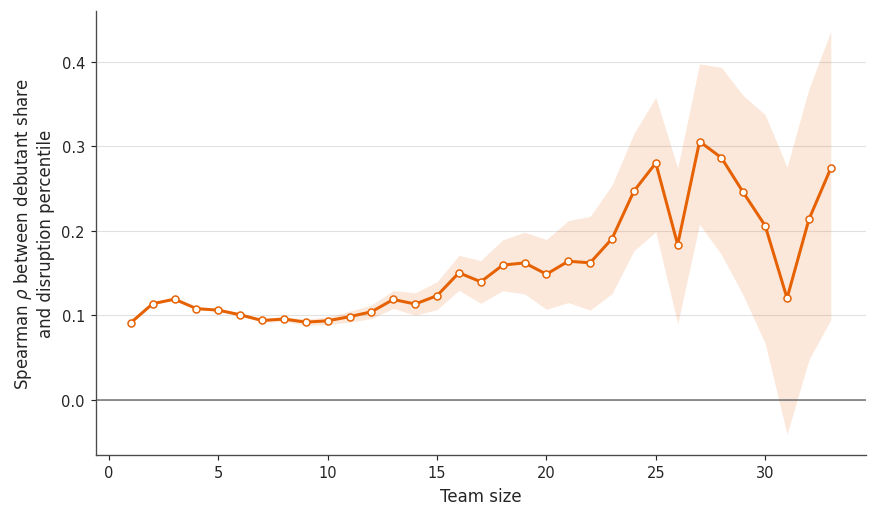

Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T02_debutant_disruption_by_team_size.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T02_debutant_disruption_by_team_size.tex


(WindowsPath('Reanalysis_Results_v9/tables/T02_debutant_disruption_by_team_size.csv'),
 WindowsPath('Reanalysis_Results_v9/tables/T02_debutant_disruption_by_team_size.tex'))

In [13]:
team_corr = (
    pl.scan_parquet(ANALYSIS_CACHE)
    .filter(
        pl.col("first_time_author_ratio").is_not_null()
        & pl.col("disruption_percentile").is_not_null()
    )
    .with_columns([
        pl.col("first_time_author_ratio").cast(pl.Float64).alias("_corr_x"),
        pl.col("disruption_percentile").cast(pl.Float64).alias("_corr_y"),
    ])
    .group_by("team_size")
    .agg([
        pl.len().alias("n"),
        pl.corr("_corr_x", "_corr_y", method="pearson")
          .cast(pl.Float64).alias("pearson_r"),
        pl.corr("_corr_x", "_corr_y", method="spearman")
          .cast(pl.Float64).alias("spearman_r"),
    ])
    .sort("team_size")
    .collect()
    .to_pandas()
)

team_corr["pearson_p"] = [
    corr_p_from_r(r, n)
    for r, n in zip(team_corr["pearson_r"], team_corr["n"])
]
team_corr["spearman_p_approx"] = [
    corr_p_from_r(r, n)
    for r, n in zip(team_corr["spearman_r"], team_corr["n"])
]
team_corr = add_fisher_ci_columns(
    team_corr,
    "spearman_r",
    prefix="spearman",
)

display(team_corr.head(15))
team_corr.to_csv(
    OUTPUT_DIR / "reproduction_debutant_disruption_by_team_size.csv",
    index=False,
)

fig, ax = plt.subplots(figsize=(7.4, 4.4))
p = team_corr[team_corr["n"] >= 100].copy()

ax.plot(
    p["team_size"],
    p["spearman_r"],
    color=ESTIMATE_COLOR,
    marker="o",
    markerfacecolor="white",
    markeredgecolor=ESTIMATE_COLOR,
    markeredgewidth=0.9,
    linewidth=1.8,
)

ax.fill_between(
    p["team_size"],
    p["spearman_ci95_low"],
    p["spearman_ci95_high"],
    color=ESTIMATE_COLOR,
    alpha=0.14,
    linewidth=0,
)

add_zero_line(ax)
apply_science_axes(ax)

ax.set_xlabel("Team size")
ax.set_ylabel(
    "Spearman $\\rho$ between debutant share\n"
    "and disruption percentile"
)

plt.tight_layout()
save_pub_figure(
    fig,
    "raw_debutant_disruption_correlation_by_team_size",
)
plt.show()

export_pub_table(team_corr, "T02_debutant_disruption_by_team_size")

## Debutant-share association across decades

In [14]:
decade_corr = (
    pl.scan_parquet(ANALYSIS_CACHE)
    .with_columns(
        (((pl.col("year").cast(pl.Int32) - 1) // 10) * 10 + 1)
        .alias("decade_start")
    )
    .filter(
        pl.col("first_time_author_ratio").is_not_null()
        & pl.col("disruption_percentile").is_not_null()
    )
    .with_columns([
        pl.col("first_time_author_ratio")
          .cast(pl.Float64)
          .alias("_corr_x"),
        pl.col("disruption_percentile")
          .cast(pl.Float64)
          .alias("_corr_y"),
    ])
    .group_by("decade_start")
    .agg([
        pl.len().alias("n"),
        pl.corr(
            "_corr_x",
            "_corr_y",
            method="pearson",
        ).cast(pl.Float64).alias("pearson_r"),
        pl.corr(
            "_corr_x",
            "_corr_y",
            method="spearman",
        ).cast(pl.Float64).alias("spearman_r"),
    ])
    .sort("decade_start")
    .collect()
    .to_pandas()
)

decade_corr["decade"] = (
    decade_corr["decade_start"].astype(str)
    + "-"
    + (decade_corr["decade_start"] + 9).astype(str)
)

display(decade_corr)
decade_corr.to_csv(
    OUTPUT_DIR / "reproduction_beginner_disruption_by_decade.csv",
    index=False,
)

export_pub_table(decade_corr, "T03_beginner_disruption_by_decade")

,decade_start,n,pearson_r,spearman_r,decade
0,1941,47213,0.042378,0.048536,1941-1950
1,1951,235753,0.046041,0.043221,1951-1960
2,1961,730667,0.072996,0.058709,1961-1970
3,1971,1477240,0.068561,0.053265,1971-1980
4,1981,2418102,0.073413,0.052354,1981-1990
5,1991,3757344,0.075212,0.051006,1991-2000
6,2001,7290170,0.096032,0.067303,2001-2010
7,2011,13097772,0.137404,0.109909,2011-2020


Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T03_beginner_disruption_by_decade.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T03_beginner_disruption_by_decade.tex


(WindowsPath('Reanalysis_Results_v9/tables/T03_beginner_disruption_by_decade.csv'),
 WindowsPath('Reanalysis_Results_v9/tables/T03_beginner_disruption_by_decade.tex'))

## Atypical knowledge combinations across debutant-share groups

Matches the four equal-width beginner-share groups used in the existing analysis, while also reporting median differences and Holm-adjusted p-values.

In [15]:
atyp = (
    pl.read_parquet(
        ANALYSIS_CACHE,
        columns=["first_time_author_ratio", "Atyp_Median_Z"],
    )
    .filter(
        pl.col("first_time_author_ratio").is_not_null()
        & pl.col("Atyp_Median_Z").is_finite()
    )
)

ratio = atyp["first_time_author_ratio"].to_numpy()
value = atyp["Atyp_Median_Z"].to_numpy()

group = np.digitize(ratio, [0.25, 0.50, 0.75], right=True)
labels4 = [
    "0.00 - 0.25", "0.25 - 0.50",
    "0.50 - 0.75", "0.75 - 1.00"
]

rows = []
for i in range(4):
    for j in range(i + 1, 4):
        a = value[group == i]
        b = value[group == j]
        D, p = ks_2samp(a, b, alternative="two-sided", method="auto")
        rows.append({
            "group_a": labels4[i],
            "group_b": labels4[j],
            "n_a": len(a),
            "n_b": len(b),
            "ks_D": D,
            "p_value": p,
            "median_a": np.median(a),
            "median_b": np.median(b),
            "median_diff_a_minus_b": np.median(a) - np.median(b),
        })

ks_atyp = pd.DataFrame(rows)
ks_atyp["p_holm"] = multipletests(
    ks_atyp["p_value"], method="holm"
)[1]

display(ks_atyp)
ks_atyp.to_csv(
    OUTPUT_DIR / "reproduction_atypicality_pairwise_KS.csv",
    index=False,
)

export_pub_table(ks_atyp, "T04_atypicality_pairwise_KS")

del atyp, ratio, value, group
gc.collect()

,group_a,group_b,n_a,n_b,ks_D,p_value,median_a,median_b,median_diff_a_minus_b,p_holm
0,0.00 - 0.25,0.25 - 0.50,19336778,3223015,0.050905,0.0,97.376587,80.282288,17.094299,0.0
1,0.00 - 0.25,0.50 - 0.75,19336778,435378,0.102660,0.0,97.376587,65.047241,32.329346,0.0
2,0.00 - 0.25,0.75 - 1.00,19336778,661670,0.142077,0.0,97.376587,54.377113,42.999474,0.0
3,0.25 - 0.50,0.50 - 0.75,3223015,435378,0.051847,0.0,80.282288,65.047241,15.235046,0.0
4,0.25 - 0.50,0.75 - 1.00,3223015,661670,0.091258,0.0,80.282288,54.377113,25.905174,0.0
5,0.50 - 0.75,0.75 - 1.00,435378,661670,0.040716,0.0,65.047241,54.377113,10.670128,0.0


Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T04_atypicality_pairwise_KS.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T04_atypicality_pairwise_KS.tex


41

## 2.5 Reference popularity and reference age

In [16]:
reference_outcomes = [
    "avg_reference_popularity_percentile",
    "median_reference_popularity_percentile",
    "avg_reference_age_percentile",
    "median_reference_age_percentile",
]

ref_rows = []
for outcome in reference_outcomes:
    r = polars_corr_summary("first_time_author_ratio", outcome)
    r["outcome"] = outcome
    ref_rows.append(r)

reference_results = pd.DataFrame(ref_rows)[
    ["outcome", "n", "pearson_r", "pearson_p",
     "spearman_r", "spearman_p_approx"]
]

display(reference_results)
reference_results.to_csv(
    OUTPUT_DIR / "reproduction_reference_patterns.csv",
    index=False,
)

export_pub_table(reference_results, "T05_reference_patterns")

,outcome,n,pearson_r,pearson_p,spearman_r,spearman_p_approx
0,avg_reference_popularity_percentile,29054261,-0.080926,0.000000e+00,-0.064277,0.0
1,median_reference_popularity_percentile,29054261,-0.058347,0.000000e+00,-0.047924,0.0
2,avg_reference_age_percentile,29054261,-0.014440,0.000000e+00,-0.030906,0.0
3,median_reference_age_percentile,29054261,0.006666,1.008117e-282,-0.010299,0.0


Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T05_reference_patterns.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T05_reference_patterns.tex


(WindowsPath('Reanalysis_Results_v9/tables/T05_reference_patterns.csv'),
 WindowsPath('Reanalysis_Results_v9/tables/T05_reference_patterns.tex'))

## 2.6 Exact team-composition ranking

In [17]:
composition = (
    pl.scan_parquet(ANALYSIS_CACHE)
    .group_by([
        "first_time_author_count",
        "early_career_author_count_main",
        "senior_author_count",
    ])
    .agg([
        pl.len().alias("count"),
        pl.col("disruption_percentile").mean().alias("mean"),
        pl.col("disruption_percentile").median().alias("median"),
        pl.col("disruption_percentile").quantile(0.25).alias("q25"),
        pl.col("disruption_percentile").quantile(0.75).alias("q75"),
    ])
    .filter(pl.col("count") >= 10_000)
    .with_columns([
        (
            pl.col("first_time_author_count")
            + pl.col("early_career_author_count_main")
            + pl.col("senior_author_count")
        ).alias("team_size_from_counts"),
        (
            1.57
            * (pl.col("q75") - pl.col("q25"))
            / pl.col("count").cast(pl.Float64).sqrt()
        ).alias("median_ci_halfwidth"),
    ])
    .with_columns([
        (
            pl.col("median") - pl.col("median_ci_halfwidth")
        ).alias("median_ci95_low"),
        (
            pl.col("median") + pl.col("median_ci_halfwidth")
        ).alias("median_ci95_high"),
    ])
    .sort("median", descending=True)
    .collect()
    .to_pandas()
)

display(composition.head(25))

,first_time_author_count,early_career_author_count_main,senior_author_count,count,mean,median,q25,q75,team_size_from_counts,median_ci_halfwidth,median_ci95_low,median_ci95_high
0,3,0,0,58525,63.600510,71.672501,43.692543,88.120735,3,0.288329,71.384172,71.960829
1,2,0,0,172021,63.202568,71.348228,42.100601,88.509125,2,0.175674,71.172555,71.523902
2,4,0,0,21282,62.644485,70.580048,40.856354,87.766609,4,0.504849,70.075199,71.084896
3,1,0,0,828448,62.585339,70.102936,40.601986,88.392319,1,0.082434,70.020502,70.185370
4,4,1,0,13612,60.890247,68.208702,36.976429,86.253738,5,0.663110,67.545592,68.871812
5,3,1,0,43000,60.724518,67.919662,36.762913,86.302086,4,0.375072,67.544591,68.294734
6,2,1,0,148622,60.140694,67.018250,36.168148,85.717232,3,0.201787,66.816462,67.220037
7,3,2,0,18855,59.153309,65.648872,34.022926,84.987946,5,0.582718,65.066154,66.231591
8,4,0,1,13789,59.402832,65.209160,35.337990,84.792809,5,0.661214,64.547946,65.870374
9,2,2,0,64399,58.223072,64.076729,33.055416,84.150948,4,0.316113,63.760615,64.392842


## Disruption–citation association across debutant-share groups

This reproduces the existing logic of examining the disruption–citation association inside progressively broader top-disruption subsets, stratified by the same four equal-width beginner-share groups.

The calculation is performed from a compact three-column Parquet read and then discarded.

,beginner_group,n,spearman_r,top_disruption_percent,p_approx,spearman_ci95_low,spearman_ci95_high
0,0.00 - 0.25,2069321,-0.043939,10,0.000000e+00,-0.045299,-0.042579
1,0.25 - 0.50,492974,-0.026963,10,5.942199e-80,-0.029752,-0.024173
2,0.50 - 0.75,92202,-0.006370,10,5.308010e-02,-0.012824,0.000085
3,0.75 - 1.00,250912,0.020499,10,9.720170e-25,0.016587,0.024409
4,0.00 - 0.25,4232293,0.003671,20,4.302153e-14,0.002718,0.004623
5,0.25 - 0.50,977034,0.037335,20,2.504547e-298,0.035355,0.039315
6,0.50 - 0.75,175896,0.057850,20,3.002117e-130,0.053191,0.062507
7,0.75 - 1.00,425548,0.071972,20,0.000000e+00,0.068982,0.074960
8,0.00 - 0.25,6465022,0.055610,30,0.000000e+00,0.054842,0.056379
9,0.25 - 0.50,1429690,0.091447,30,0.000000e+00,0.089822,0.093072


Saved figure: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\figures\diagnostic_lifetime_citation_cumulative_correlation.pdf


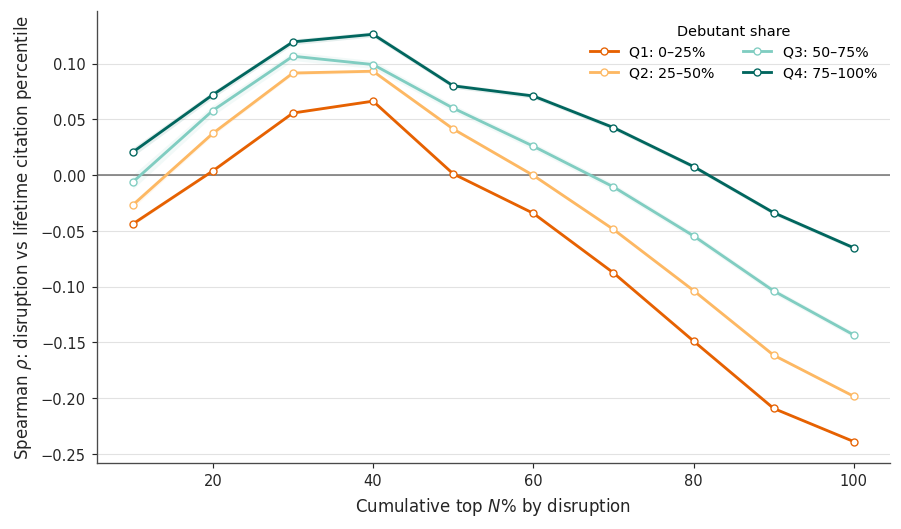

Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T00_sanity_lifetime_citation_curve_NOT_FINAL.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T00_sanity_lifetime_citation_curve_NOT_FINAL.tex


6151

In [18]:
citation_repro = (
    pl.read_parquet(
        ANALYSIS_CACHE,
        columns=[
            "disruption_percentile",
            "citation_count_percentile",
            "first_time_author_ratio",
        ],
    )
    .drop_nulls()
    .with_columns([
        pl.col("disruption_percentile")
          .cast(pl.Float64)
          .alias("_corr_disruption"),
        pl.col("citation_count_percentile")
          .cast(pl.Float64)
          .alias("_corr_citation"),
    ])
    .with_columns(
        pl.when(pl.col("first_time_author_ratio") <= 0.25)
          .then(pl.lit("0.00 - 0.25"))
        .when(pl.col("first_time_author_ratio") <= 0.50)
          .then(pl.lit("0.25 - 0.50"))
        .when(pl.col("first_time_author_ratio") <= 0.75)
          .then(pl.lit("0.50 - 0.75"))
        .otherwise(pl.lit("0.75 - 1.00"))
        .alias("beginner_group")
    )
)

citation_rows = []

for top_n in range(10, 101, 10):
    threshold = 100 - top_n

    tab = (
        citation_repro
        .filter(pl.col("disruption_percentile") >= threshold)
        .group_by("beginner_group")
        .agg([
            pl.len().alias("n"),
            pl.corr(
                "_corr_disruption",
                "_corr_citation",
                method="spearman",
            ).cast(pl.Float64).alias("spearman_r"),
        ])
        .sort("beginner_group")
        .to_pandas()
    )

    tab["top_disruption_percent"] = top_n
    citation_rows.append(tab)

citation_tail_corr = pd.concat(citation_rows, ignore_index=True)

citation_tail_corr["p_approx"] = [
    corr_p_from_r(r, n)
    for r, n in zip(
        citation_tail_corr["spearman_r"],
        citation_tail_corr["n"],
    )
]
citation_tail_corr = add_fisher_ci_columns(
    citation_tail_corr,
    "spearman_r",
    prefix="spearman",
)

display(citation_tail_corr.head(20))

citation_tail_corr.to_csv(
    OUTPUT_DIR / "reproduction_citation_disruption_by_debutant_group.csv",
    index=False,
)

fig, ax = plt.subplots(figsize=(7.6, 4.5))

for group_name, g in citation_tail_corr.groupby(
    "beginner_group",
    sort=True,
):
    color = DEBUT_QUARTILE_COLORS[group_name]

    ax.plot(
        g["top_disruption_percent"],
        g["spearman_r"],
        marker="o",
        markerfacecolor="white",
        markeredgecolor=color,
        markeredgewidth=0.8,
        color=color,
        linewidth=1.7,
        label=DEBUT_QUARTILE_DISPLAY[group_name],
    )

    ax.fill_between(
        g["top_disruption_percent"],
        g["spearman_ci95_low"],
        g["spearman_ci95_high"],
        color=color,
        alpha=0.10,
        linewidth=0,
    )

add_zero_line(ax)
apply_science_axes(ax)

ax.set_xlabel("Cumulative top $N$% by disruption")
ax.set_ylabel(
    "Spearman $\\rho$: disruption vs lifetime citation percentile"
)
ax.legend(
    title="Debutant share",
    ncol=2,
    loc="best",
)

plt.tight_layout()

save_pub_figure(
    fig,
    "diagnostic_lifetime_citation_cumulative_correlation",
)
plt.show()

export_pub_table(
    citation_tail_corr,
    "T00_sanity_lifetime_citation_curve_NOT_FINAL",
)

del citation_repro
gc.collect()

# Fixed-effect estimation

The fixed effects are additive publication-year FE + exact team-size FE.

The design matrix for those fixed effects has only about 119 parameters. We build its normal equations from year counts, team-size counts, the year×team-size count table, and grouped sums of the modeled variables. We never create an \(n \times 119\) dummy matrix.

In [19]:
def finite_mask(*arrays):
    mask = np.ones(len(arrays[0]), dtype=bool)
    for a in arrays:
        mask &= np.isfinite(np.asarray(a, dtype=np.float64))
    return mask

def recode_categories(values):
    levels, codes = np.unique(values, return_inverse=True)
    return levels, codes.astype(np.int32, copy=False)

def residualize_two_way_exact(Y, fe_a, fe_b):
    # Residualize Y against intercept + categorical FE_A + categorical FE_B.
    Y = np.asarray(Y, dtype=np.float64)
    if Y.ndim == 1:
        Y = Y[:, None]

    levels_a, a = recode_categories(fe_a)
    levels_b, b = recode_categories(fe_b)

    n, k = Y.shape
    na = len(levels_a)
    nb = len(levels_b)

    count_a = np.bincount(a, minlength=na).astype(np.float64)
    count_b = np.bincount(b, minlength=nb).astype(np.float64)
    cell = np.bincount(
        a.astype(np.int64) * nb + b,
        minlength=na * nb,
    ).reshape(na, nb).astype(np.float64)

    p = 1 + (na - 1) + (nb - 1)
    XtX = np.zeros((p, p), dtype=np.float64)

    ia = slice(1, 1 + na - 1)
    ib = slice(1 + na - 1, p)

    XtX[0, 0] = n
    XtX[0, ia] = count_a[1:]
    XtX[ia, 0] = count_a[1:]
    XtX[0, ib] = count_b[1:]
    XtX[ib, 0] = count_b[1:]

    XtX[ia, ia] = np.diag(count_a[1:])
    XtX[ib, ib] = np.diag(count_b[1:])
    XtX[ia, ib] = cell[1:, 1:]
    XtX[ib, ia] = cell[1:, 1:].T

    XtY = np.zeros((p, k), dtype=np.float64)
    XtY[0, :] = Y.sum(axis=0)

    for j in range(k):
        XtY[ia, j] = np.bincount(
            a, weights=Y[:, j], minlength=na
        )[1:]
        XtY[ib, j] = np.bincount(
            b, weights=Y[:, j], minlength=nb
        )[1:]

    try:
        beta = np.linalg.solve(XtX, XtY)
    except np.linalg.LinAlgError:
        beta = np.linalg.lstsq(XtX, XtY, rcond=None)[0]

    a_beta = np.zeros((na, k), dtype=np.float64)
    b_beta = np.zeros((nb, k), dtype=np.float64)
    a_beta[1:, :] = beta[ia, :]
    b_beta[1:, :] = beta[ib, :]

    fitted = (
        beta[0, :][None, :]
        + a_beta[a, :]
        + b_beta[b, :]
    )

    return (Y - fitted).squeeze(), {
        "levels_a": levels_a,
        "levels_b": levels_b,
        "fe_rank": p,
    }

def ols_hc1_chunked(y, X, names, chunk_rows=REGRESSION_CHUNK_ROWS, df_extra=0):
    # OLS on FE-residualized variables; HC1 covariance accumulated in chunks.
    y = np.asarray(y, dtype=np.float64)
    X = np.asarray(X, dtype=np.float64)
    if X.ndim == 1:
        X = X[:, None]

    n, k = X.shape
    XtX = X.T @ X
    Xty = X.T @ y
    XtX_inv = np.linalg.pinv(XtX)
    beta = XtX_inv @ Xty

    meat = np.zeros((k, k), dtype=np.float64)

    for start in range(0, n, chunk_rows):
        stop = min(start + chunk_rows, n)
        Xc = X[start:stop]
        yc = y[start:stop]
        e = yc - Xc @ beta
        Xe = Xc * e[:, None]
        meat += Xe.T @ Xe

    df_resid = max(n - k - int(df_extra), 1)
    cov = (n / df_resid) * XtX_inv @ meat @ XtX_inv
    se = np.sqrt(np.diag(cov))
    tvals = beta / se
    pvals = 2 * stats.t.sf(np.abs(tvals), df=df_resid)
    crit = stats.t.ppf(0.975, df=df_resid)

    return pd.DataFrame({
        "term": names,
        "coef": beta,
        "robust_se_HC1": se,
        "t": tvals,
        "p": pvals,
        "ci95_low": beta - crit * se,
        "ci95_high": beta + crit * se,
        "n": n,
    })

def fit_two_way_fe_model(data, outcome, predictors,
                         fe_a="year", fe_b="team_size"):
    needed = [outcome] + list(predictors) + [fe_a, fe_b]
    mask = finite_mask(*[data[c] for c in needed])

    y = np.asarray(data[outcome][mask], dtype=np.float64)
    X = np.column_stack([
        np.asarray(data[p][mask], dtype=np.float64)
        for p in predictors
    ])
    fa = data[fe_a][mask]
    fb = data[fe_b][mask]

    M = np.column_stack([y, X])
    R, info = residualize_two_way_exact(M, fa, fb)

    return ols_hc1_chunked(
        R[:, 0],
        R[:, 1:],
        names=list(predictors),
        df_extra=info["fe_rank"],
    ), info

### Fixed-effect estimator with covariance matrix

The estimator returns both coefficient estimates and the HC1 covariance matrix.
The covariance matrix is used for contrasts and model-implied quantities such as
the debutant-share association at different team sizes, disruption percentiles,
and collaborator prior-disruption percentiles.

In [20]:
def ols_hc1_chunked_full(
    y,
    X,
    names,
    chunk_rows=REGRESSION_CHUNK_ROWS,
    df_extra=0,
):
    y = np.asarray(y, dtype=np.float64)
    X = np.asarray(X, dtype=np.float64)

    if X.ndim == 1:
        X = X[:, None]

    n, k = X.shape
    XtX = X.T @ X
    Xty = X.T @ y
    XtX_inv = np.linalg.pinv(XtX)
    beta = XtX_inv @ Xty

    meat = np.zeros((k, k), dtype=np.float64)

    for start in range(0, n, chunk_rows):
        stop = min(start + chunk_rows, n)
        Xc = X[start:stop]
        yc = y[start:stop]
        e = yc - Xc @ beta
        Xe = Xc * e[:, None]
        meat += Xe.T @ Xe

    df_resid = max(n - k - int(df_extra), 1)
    cov = (n / df_resid) * XtX_inv @ meat @ XtX_inv

    se = np.sqrt(np.diag(cov))
    tvals = beta / se
    pvals = 2 * stats.t.sf(np.abs(tvals), df=df_resid)
    crit = stats.t.ppf(0.975, df=df_resid)

    table = pd.DataFrame({
        "term": names,
        "coef": beta,
        "robust_se_HC1": se,
        "t": tvals,
        "p": pvals,
        "ci95_low": beta - crit * se,
        "ci95_high": beta + crit * se,
        "n": n,
    })

    return table, cov, {
        "df_resid": df_resid,
        "crit95": crit,
        "beta": beta,
        "names": list(names),
    }


def fit_two_way_fe_model_full(
    data,
    outcome,
    predictors,
    fe_a="year",
    fe_b="team_size",
):
    needed = [outcome] + list(predictors) + [fe_a, fe_b]
    mask = finite_mask(*[data[c] for c in needed])

    y = np.asarray(data[outcome][mask], dtype=np.float64)
    X = np.column_stack([
        np.asarray(data[p][mask], dtype=np.float64)
        for p in predictors
    ])

    fa = np.asarray(data[fe_a][mask])
    fb = np.asarray(data[fe_b][mask])

    M = np.column_stack([y, X])
    R, fe_info = residualize_two_way_exact(M, fa, fb)

    table, cov, ols_info = ols_hc1_chunked_full(
        R[:, 0],
        R[:, 1:],
        names=list(predictors),
        df_extra=fe_info["fe_rank"],
    )

    info = {
        **fe_info,
        **ols_info,
        "mask": mask,
    }

    return table, cov, info


def linear_combo_from_model(table, cov, weights, label):
    """
    weights: dict term -> multiplier.
    """
    names = table["term"].tolist()
    b = table["coef"].to_numpy(float)

    w = np.array(
        [float(weights.get(name, 0.0)) for name in names],
        dtype=float,
    )

    est = float(w @ b)
    var = float(w @ cov @ w)
    se = math.sqrt(max(var, 0.0))

    # All models here have enormous df; 1.96 is numerically equivalent.
    return {
        "contrast": label,
        "estimate": est,
        "se": se,
        "ci95_low": est - 1.96 * se,
        "ci95_high": est + 1.96 * se,
    }

## Synthetic validation of the fixed-effect estimator

In [21]:
def self_test_fe_engine(seed=123):
    rng = np.random.default_rng(seed)
    n = 20_000

    year = rng.integers(0, 8, size=n)
    team = rng.integers(0, 5, size=n)
    x = rng.normal(size=n)

    y = (
        1.7 * x
        + np.array([0, .2, -.1, .4, -.3, .1, .5, -.2])[year]
        + np.array([0, -.4, .3, .1, .6])[team]
        + rng.normal(scale=.7, size=n)
    )

    R, _ = residualize_two_way_exact(
        np.column_stack([y, x]), year, team
    )
    beta_fast = np.linalg.lstsq(
        R[:, [1]], R[:, 0], rcond=None
    )[0][0]

    year_d = np.eye(year.max() + 1)[year][:, 1:]
    team_d = np.eye(team.max() + 1)[team][:, 1:]
    X_full = np.column_stack([
        np.ones(n), x, year_d, team_d
    ])
    beta_full = np.linalg.lstsq(X_full, y, rcond=None)[0][1]

    print("Fast FE beta:", beta_fast)
    print("Explicit-dummy beta:", beta_full)
    print("Absolute difference:", abs(beta_fast - beta_full))

    assert abs(beta_fast - beta_full) < 1e-10

self_test_fe_engine()

Fast FE beta: 1.6970684369543718
Explicit-dummy beta: 1.6970684369543712
Absolute difference: 6.661338147750939e-16


# Load regression variables

Only the numeric columns needed for the models are loaded. Stored continuous columns are mostly Float32; calculations are upcast to Float64 only inside the regressions.

In [22]:
REGRESSION_COLS = [
    "year", "team_size",
    "first_time_author_ratio",
    "early_career_author_ratio_main",
    "senior_author_ratio",
    "early_1_5_author_ratio",
    "mid_6_10_author_ratio",
    "first_time_author_count",
    "early_career_author_count_main",
    "senior_author_count",
    "disruption_percentile",
    "disruption_percentile_within_year",
    "avg_disruption_percentile",
    "early_1_10_author_avg_disruption_percentile",
    "senior_author_avg_disruption_percentile",
    "Atyp_Median_Z_percentile",
    "avg_reference_popularity_percentile",
    "avg_reference_age_percentile",
    "C10_percentile_within_year",
]

t0 = perf_counter()
core = pl.read_parquet(ANALYSIS_CACHE, columns=REGRESSION_COLS)
print(f"Loaded regression bundle in {perf_counter() - t0:.1f} seconds.")
print("Shape:", core.shape)
print(f"Estimated size: {core.estimated_size('gb'):.2f} GB")

A = {c: core[c].to_numpy() for c in REGRESSION_COLS}

A["beginner_x_log2teamsize"] = (
    A["first_time_author_ratio"].astype(np.float32)
    * np.log2(A["team_size"].astype(np.float32))
).astype(np.float32)

A["beginner_x_prior_disruption"] = (
    A["first_time_author_ratio"].astype(np.float32)
    * A["avg_disruption_percentile"].astype(np.float32)
).astype(np.float32)

A["disruption_x_beginner"] = (
    A["disruption_percentile"].astype(np.float32)
    * A["first_time_author_ratio"].astype(np.float32)
).astype(np.float32)

del core
gc.collect()

print(f"Rows available: {len(A['year']):,}")

Loaded regression bundle in 0.3 seconds.
Shape: (29054261, 19)
Estimated size: 1.77 GB
Rows available: 29,054,261


# Main adjusted analyses

All models below are paper-level observational associations with:

- publication-year fixed effects;
- exact team-size fixed effects;
- HC1 heteroskedasticity-robust standard errors.

## Primary debutant-share association

In [23]:
t0 = perf_counter()

main_fe, _ = fit_two_way_fe_model(
    A,
    outcome="disruption_percentile",
    predictors=["first_time_author_ratio"],
)

print(f"Runtime: {perf_counter() - t0:.1f} seconds")
display(main_fe)
main_fe.to_csv(
    OUTPUT_DIR / "additional_main_FE_model.csv",
    index=False,
)

export_pub_table(main_fe, "T10_main_FE")

Runtime: 6.4 seconds


,term,coef,robust_se_HC1,t,p,ci95_low,ci95_high,n
0,first_time_author_ratio,12.440429,0.022519,552.431159,0.0,12.396292,12.484567,29054261


Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T10_main_FE.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T10_main_FE.tex


(WindowsPath('Reanalysis_Results_v9/tables/T10_main_FE.csv'),
 WindowsPath('Reanalysis_Results_v9/tables/T10_main_FE.tex'))

## Debutant share × team-size interaction

Tests whether the beginner-share slope changes with team size while retaining exact team-size fixed effects.

,term,coef,robust_se_HC1,t,p,ci95_low,ci95_high,n
0,first_time_author_ratio,7.716091,0.032485,237.526591,0.0,7.652421,7.779761,29054261
1,beginner_x_log2teamsize,5.101470,0.024677,206.730458,0.0,5.053105,5.149836,29054261


Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T11_debutant_by_team_size_interaction.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T11_debutant_by_team_size_interaction.tex


,contrast,estimate,se,ci95_low,ci95_high,team_size
0,+10pp debutant-share effect at team size 1,0.771609,0.003249,0.765242,0.777976,1
1,+10pp debutant-share effect at team size 2,1.281756,0.002243,1.277360,1.286152,2
3,+10pp debutant-share effect at team size 4,1.791903,0.003418,1.785203,1.798603,4
7,+10pp debutant-share effect at team size 8,2.302050,0.005525,2.291222,2.312878,8
15,+10pp debutant-share effect at team size 16,2.812197,0.007844,2.796822,2.827572,16
31,+10pp debutant-share effect at team size 32,3.322344,0.010234,3.302286,3.342402,32
39,+10pp debutant-share effect at team size 40,3.486575,0.011010,3.464995,3.508155,40


Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T11b_debutant_simple_slope_by_team_size.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T11b_debutant_simple_slope_by_team_size.tex
Saved figure: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\figures\adjusted_debutant_share_effect_by_team_size.pdf


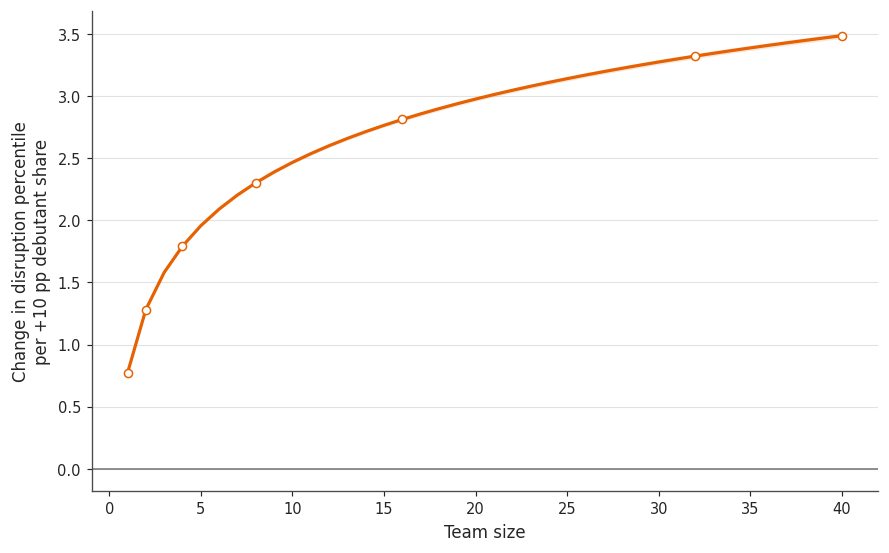

In [24]:
interaction_fe, interaction_cov, interaction_info = fit_two_way_fe_model_full(
    A,
    outcome="disruption_percentile",
    predictors=[
        "first_time_author_ratio",
        "beginner_x_log2teamsize",
    ],
)

display(interaction_fe)

interaction_fe.to_csv(
    OUTPUT_DIR / "additional_debutant_by_team_size_interaction.csv",
    index=False,
)

export_pub_table(
    interaction_fe,
    "T11_debutant_by_team_size_interaction",
)

team_slope_rows = []

for team_size in range(1, MAX_TEAM_SIZE + 1):
    log2_size = math.log2(team_size)

    row = linear_combo_from_model(
        interaction_fe,
        interaction_cov,
        weights={
            "first_time_author_ratio": 0.1,
            "beginner_x_log2teamsize": 0.1 * log2_size,
        },
        label=f"+10pp debutant-share effect at team size {team_size}",
    )

    row["team_size"] = team_size
    team_slope_rows.append(row)

team_size_simple_slopes = pd.DataFrame(team_slope_rows)

display(
    team_size_simple_slopes[
        team_size_simple_slopes["team_size"].isin(
            [1, 2, 4, 8, 16, 32, 40]
        )
    ]
)

export_pub_table(
    team_size_simple_slopes,
    "T11b_debutant_simple_slope_by_team_size",
)

fig, ax = plt.subplots(figsize=(7.5, 4.7))

ax.plot(
    team_size_simple_slopes["team_size"],
    team_size_simple_slopes["estimate"],
    color=ESTIMATE_COLOR,
    linewidth=1.9,
)

ax.fill_between(
    team_size_simple_slopes["team_size"],
    team_size_simple_slopes["ci95_low"],
    team_size_simple_slopes["ci95_high"],
    color=ESTIMATE_COLOR,
    alpha=0.15,
    linewidth=0,
)

key_sizes = [1, 2, 4, 8, 16, 32, 40]
key = team_size_simple_slopes[
    team_size_simple_slopes["team_size"].isin(key_sizes)
]

ax.scatter(
    key["team_size"],
    key["estimate"],
    s=24,
    facecolor="white",
    edgecolor=ESTIMATE_COLOR,
    linewidth=0.9,
    zorder=3,
)

add_zero_line(ax)
apply_science_axes(ax)

ax.set_xlabel("Team size")
ax.set_ylabel(
    "Change in disruption percentile\n"
    "per +10 pp debutant share"
)

plt.tight_layout()

save_pub_figure(
    fig,
    "adjusted_debutant_share_effect_by_team_size",
)
plt.show()

## Direct 0% versus 50% debutant-share comparisons

In [25]:
contrast = (
    pl.scan_parquet(ANALYSIS_CACHE)
    .filter(
        pl.col("first_time_author_ratio").is_in([0.0, 0.5])
        & pl.col("disruption_percentile").is_not_null()
    )
    .group_by(["team_size", "first_time_author_ratio"])
    .agg([
        pl.len().alias("n"),
        pl.col("disruption_percentile").mean().alias("mean"),
        pl.col("disruption_percentile").var().alias("var"),
    ])
    .collect()
    .to_pandas()
)

rows = []
for size, g in contrast.groupby("team_size"):
    a = g[g["first_time_author_ratio"] == 0.0]
    b = g[g["first_time_author_ratio"] == 0.5]

    if len(a) != 1 or len(b) != 1:
        continue

    a, b = a.iloc[0], b.iloc[0]

    if a["n"] < 100 or b["n"] < 100:
        continue

    diff = b["mean"] - a["mean"]
    se = math.sqrt(a["var"]/a["n"] + b["var"]/b["n"])

    rows.append({
        "team_size": size,
        "n_ratio_0": int(a["n"]),
        "n_ratio_0_5": int(b["n"]),
        "mean_ratio_0": a["mean"],
        "mean_ratio_0_5": b["mean"],
        "difference_0_5_minus_0": diff,
        "ci95_low": diff - 1.96*se,
        "ci95_high": diff + 1.96*se,
    })

contrast_50 = pd.DataFrame(rows)
display(contrast_50)
contrast_50.to_csv(
    OUTPUT_DIR / "additional_team_size_contrasts_ratio0_vs_0p5.csv",
    index=False,
)

,team_size,n_ratio_0,n_ratio_0_5,mean_ratio_0,mean_ratio_0_5,difference_0_5_minus_0,ci95_low,ci95_high
0,2,5336842,1560876,48.008953,54.541386,6.532433,6.480200,6.584665
1,4,2400122,327994,46.142151,54.726582,8.584431,8.476919,8.691942
2,6,822044,63821,43.698395,53.628445,9.930050,9.694655,10.165445
3,8,248466,11527,41.536385,52.733994,11.197609,10.660262,11.734956
4,10,82983,2756,40.421078,50.756950,10.335873,9.234253,11.437492
5,12,25184,714,39.506466,50.666016,11.159550,9.027495,13.291604
6,14,8778,206,38.918766,52.645844,13.727077,9.796029,17.658126


## Career-stage composition model

Senior count is the omitted compositional reference while exact team size is absorbed.

In [26]:
composition_fe, _ = fit_two_way_fe_model(
    A,
    outcome="disruption_percentile",
    predictors=[
        "first_time_author_count",
        "early_career_author_count_main",
    ],
)

display(composition_fe)
composition_fe.to_csv(
    OUTPUT_DIR / "additional_composition_aware_counts_FE.csv",
    index=False,
)

export_pub_table(composition_fe, "T12_composition_counts_FE")

,term,coef,robust_se_HC1,t,p,ci95_low,ci95_high,n
0,first_time_author_count,4.641148,0.007982,581.486235,0.0,4.625505,4.656792,29054261
1,early_career_author_count_main,1.134302,0.006192,183.202125,0.0,1.122167,1.146438,29054261


Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T12_composition_counts_FE.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T12_composition_counts_FE.tex


(WindowsPath('Reanalysis_Results_v9/tables/T12_composition_counts_FE.csv'),
 WindowsPath('Reanalysis_Results_v9/tables/T12_composition_counts_FE.tex'))

## Debutant, early-career, and senior composition

In [27]:
collab_stage_fe, _ = fit_two_way_fe_model(
    A,
    outcome="disruption_percentile",
    predictors=[
        "first_time_author_ratio",
        "early_career_author_ratio_main",
    ],
)

display(collab_stage_fe)
collab_stage_fe.to_csv(
    OUTPUT_DIR / "additional_collaborator_career_stage_FE.csv",
    index=False,
)

export_pub_table(collab_stage_fe, "T13_collaborator_stage_FE")

,term,coef,robust_se_HC1,t,p,ci95_low,ci95_high,n
0,first_time_author_ratio,13.463926,0.023475,573.544824,0.0,13.417916,13.509936,29054261
1,early_career_author_ratio_main,2.539076,0.017245,147.231783,0.0,2.505275,2.572876,29054261


Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T13_collaborator_stage_FE.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T13_collaborator_stage_FE.tex


(WindowsPath('Reanalysis_Results_v9/tables/T13_collaborator_stage_FE.csv'),
 WindowsPath('Reanalysis_Results_v9/tables/T13_collaborator_stage_FE.tex'))

## Collaborator prior-disruption records

In [28]:
prior_disruption_fe, _ = fit_two_way_fe_model(
    A,
    outcome="disruption_percentile",
    predictors=[
        "first_time_author_ratio",
        "avg_disruption_percentile",
        "beginner_x_prior_disruption",
    ],
)

display(prior_disruption_fe)
prior_disruption_fe.to_csv(
    OUTPUT_DIR / "additional_prior_collaborator_disruption_FE.csv",
    index=False,
)

export_pub_table(prior_disruption_fe, "T14_prior_collaborator_disruption_FE")

,term,coef,robust_se_HC1,t,p,ci95_low,ci95_high,n
0,first_time_author_ratio,11.990580,0.060047,199.688133,0.000000e+00,11.872891,12.108270,29054261
1,avg_disruption_percentile,0.208131,0.000207,1005.658593,0.000000e+00,0.207726,0.208537,29054261
2,beginner_x_prior_disruption,0.031130,0.001212,25.693527,1.385972e-145,0.028755,0.033505,29054261


Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T14_prior_collaborator_disruption_FE.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T14_prior_collaborator_disruption_FE.tex


(WindowsPath('Reanalysis_Results_v9/tables/T14_prior_collaborator_disruption_FE.csv'),
 WindowsPath('Reanalysis_Results_v9/tables/T14_prior_collaborator_disruption_FE.tex'))

### Career-stage-specific collaborator prior disruption

Prior disruptive track record is defined separately for early-career and senior
non-debutant collaborators.

The relevant prior-disruption mean is undefined when a paper contains no
collaborator from that career stage, so the two models are estimated on
different eligible samples:

- papers containing at least one early-career collaborator at career ages 1–10;
- papers containing at least one senior collaborator more than 10 years past debut.

Each model includes debutant share, publication-year fixed effects, and exact
team-size fixed effects.

In [29]:
# Early-career collaborator subset
mask_early_collab = (
    np.isfinite(A["early_1_10_author_avg_disruption_percentile"])
    & np.isfinite(A["first_time_author_ratio"])
)

early_collab_data = {
    "year": A["year"][mask_early_collab],
    "team_size": A["team_size"][mask_early_collab],
    "disruption_percentile": A["disruption_percentile"][mask_early_collab],
    "first_time_author_ratio": A["first_time_author_ratio"][mask_early_collab],
    "early_1_10_author_avg_disruption_percentile":
        A["early_1_10_author_avg_disruption_percentile"][mask_early_collab],
}

early_prior_fe, _ = fit_two_way_fe_model(
    early_collab_data,
    outcome="disruption_percentile",
    predictors=[
        "first_time_author_ratio",
        "early_1_10_author_avg_disruption_percentile",
    ],
)

early_prior_fe.insert(0, "collaborator_group", "1-10 years")


# Senior collaborator subset
mask_senior_collab = (
    np.isfinite(A["senior_author_avg_disruption_percentile"])
    & np.isfinite(A["first_time_author_ratio"])
)

senior_collab_data = {
    "year": A["year"][mask_senior_collab],
    "team_size": A["team_size"][mask_senior_collab],
    "disruption_percentile": A["disruption_percentile"][mask_senior_collab],
    "first_time_author_ratio": A["first_time_author_ratio"][mask_senior_collab],
    "senior_author_avg_disruption_percentile":
        A["senior_author_avg_disruption_percentile"][mask_senior_collab],
}

senior_prior_fe, _ = fit_two_way_fe_model(
    senior_collab_data,
    outcome="disruption_percentile",
    predictors=[
        "first_time_author_ratio",
        "senior_author_avg_disruption_percentile",
    ],
)

senior_prior_fe.insert(0, "collaborator_group", ">10 years")

stage_specific_prior_fe = pd.concat(
    [early_prior_fe, senior_prior_fe],
    ignore_index=True,
)

display(stage_specific_prior_fe)
stage_specific_prior_fe.to_csv(
    OUTPUT_DIR / "additional_stage_specific_collaborator_prior_disruption_FE.csv",
    index=False,
)

del early_collab_data, senior_collab_data
gc.collect()

export_pub_table(
    stage_specific_prior_fe,
    "T14b_stage_specific_collaborator_prior_disruption_FE",
)


,collaborator_group,term,coef,robust_se_HC1,t,p,ci95_low,ci95_high,n
0,1-10 years,first_time_author_ratio,15.934803,0.041875,380.528800,0.0,15.852729,16.016878,18526392
1,1-10 years,early_1_10_author_avg_disruption_percentile,0.232529,0.000238,976.312536,0.0,0.232062,0.232996,18526392
2,>10 years,first_time_author_ratio,14.307648,0.036376,393.324879,0.0,14.236352,14.378944,23336355
3,>10 years,senior_author_avg_disruption_percentile,0.191615,0.000208,921.455863,0.0,0.191207,0.192023,23336355


Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T14b_stage_specific_collaborator_prior_disruption_FE.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T14b_stage_specific_collaborator_prior_disruption_FE.tex


(WindowsPath('Reanalysis_Results_v9/tables/T14b_stage_specific_collaborator_prior_disruption_FE.csv'),
 WindowsPath('Reanalysis_Results_v9/tables/T14b_stage_specific_collaborator_prior_disruption_FE.tex'))

### Interaction between debutant share and collaborator prior disruption

For each collaborator career stage, we estimate whether the association between
debutant share and focal-paper disruption changes with collaborators' prior
records of disruptive work:

$D_i^{\mathrm{pct}}
=
\beta_B B_i
+
\beta_R R_i^c
+
\beta_{B\times R} B_i R_i^c
+
\alpha_{y(i)}
+
\gamma_{n(i)}
+
\varepsilon_i,
$

where \(B_i\) is debutant share and \(R_i^c\) is the collaborator
prior-disruption percentile centered at 50.

Models are estimated separately for papers containing early-career
collaborators and papers containing senior collaborators. Model-implied
debutant-share associations are also calculated at the 25th, 50th, and 75th
percentiles of collaborator prior disruption.

,collaborator_group,term,coef,robust_se_HC1,t,p,ci95_low,ci95_high,n
0,1-10 years,first_time_author_ratio,16.176995,0.042130,383.977353,0.000000e+00,16.094422,16.259568,18526392
1,1-10 years,prior_disruption_centered,0.238059,0.000268,888.319934,0.000000e+00,0.237534,0.238584,18526392
2,1-10 years,beginner_x_prior_centered,-0.064143,0.001513,-42.389477,0.000000e+00,-0.067109,-0.061177,18526392
3,>10 years,first_time_author_ratio,14.340108,0.036322,394.800549,0.000000e+00,14.268917,14.411298,23336355
4,>10 years,prior_disruption_centered,0.195685,0.000234,834.816146,0.000000e+00,0.195226,0.196145,23336355
5,>10 years,beginner_x_prior_centered,-0.044896,0.001265,-35.501747,4.699000e-276,-0.047374,-0.042417,23336355


,contrast,estimate,se,ci95_low,ci95_high,collaborator_group,prior_disruption_percentile
0,+10pp debutant-share effect at prior-disruptio...,1.778057,0.005975,1.766347,1.789768,1-10 years,25
1,+10pp debutant-share effect at prior-disruptio...,1.617699,0.004213,1.609442,1.625957,1-10 years,50
2,+10pp debutant-share effect at prior-disruptio...,1.457342,0.005331,1.446893,1.467791,1-10 years,75
3,+10pp debutant-share effect at prior-disruptio...,1.546250,0.004727,1.536984,1.555515,>10 years,25
4,+10pp debutant-share effect at prior-disruptio...,1.434011,0.003632,1.426892,1.441130,>10 years,50
5,+10pp debutant-share effect at prior-disruptio...,1.321772,0.004902,1.312164,1.331380,>10 years,75


Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T15_stage_specific_prior_disruption_interactions.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T15_stage_specific_prior_disruption_interactions.tex
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T16_stage_specific_prior_disruption_simple_slopes.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T16_stage_specific_prior_disruption_simple_slopes.tex
Saved figure: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\figures\debutant_share_effect_by_collaborator_prior_disruption.pdf


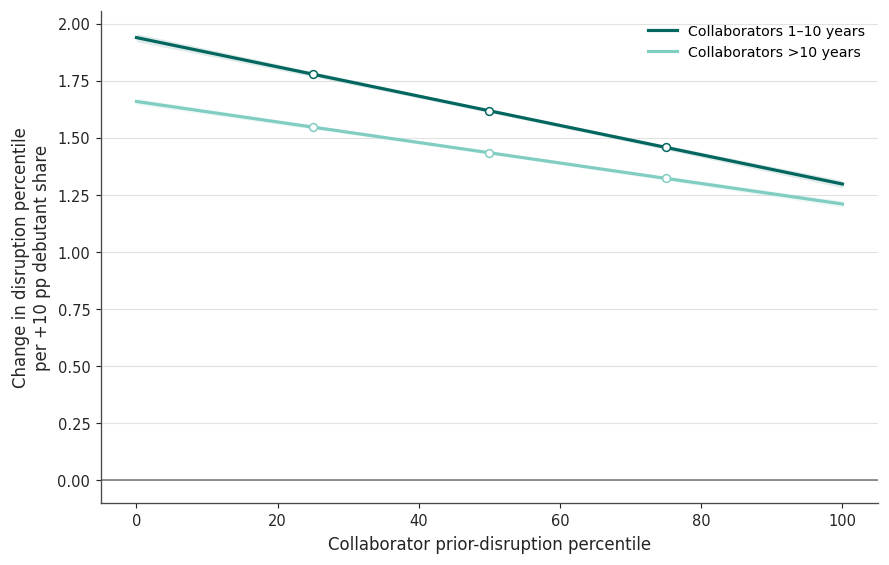

Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T17_stage_specific_prior_disruption_slope_curve.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T17_stage_specific_prior_disruption_slope_curve.tex


(WindowsPath('Reanalysis_Results_v9/tables/T17_stage_specific_prior_disruption_slope_curve.csv'),
 WindowsPath('Reanalysis_Results_v9/tables/T17_stage_specific_prior_disruption_slope_curve.tex'))

In [30]:
stage_interaction_results = []
stage_simple_slopes = []
stage_interaction_models = {}

stage_specs = [
    (
        "1-10 years",
        "early_1_10_author_avg_disruption_percentile",
    ),
    (
        ">10 years",
        "senior_author_avg_disruption_percentile",
    ),
]

for group_label, prior_col in stage_specs:
    mask = finite_mask(
        A["disruption_percentile"],
        A["first_time_author_ratio"],
        A[prior_col],
        A["year"],
        A["team_size"],
    )

    prior_centered = (
        A[prior_col][mask].astype(np.float64) - 50.0
    )

    sub = {
        "year": A["year"][mask],
        "team_size": A["team_size"][mask],
        "disruption_percentile":
            A["disruption_percentile"][mask],
        "first_time_author_ratio":
            A["first_time_author_ratio"][mask],
        "prior_disruption_centered":
            prior_centered,
        "beginner_x_prior_centered":
            (
                A["first_time_author_ratio"][mask].astype(np.float64)
                * prior_centered
            ),
    }

    fit, cov, info = fit_two_way_fe_model_full(
        sub,
        outcome="disruption_percentile",
        predictors=[
            "first_time_author_ratio",
            "prior_disruption_centered",
            "beginner_x_prior_centered",
        ],
    )

    fit.insert(0, "collaborator_group", group_label)
    stage_interaction_results.append(fit)

    stage_interaction_models[group_label] = {
        "fit": fit.copy(),
        "cov": cov.copy(),
    }

    for pctl in [25, 50, 75]:
        slope = linear_combo_from_model(
            fit.drop(columns=["collaborator_group"]),
            cov,
            weights={
                "first_time_author_ratio": 0.1,
                "beginner_x_prior_centered": 0.1 * (pctl - 50.0),
            },
            label=f"+10pp debutant-share effect at prior-disruption p{pctl}",
        )
        slope["collaborator_group"] = group_label
        slope["prior_disruption_percentile"] = pctl
        stage_simple_slopes.append(slope)

    del sub, prior_centered
    gc.collect()

stage_interaction_fe = pd.concat(
    stage_interaction_results,
    ignore_index=True,
)

stage_simple_slopes = pd.DataFrame(stage_simple_slopes)

display(stage_interaction_fe)
display(stage_simple_slopes)

export_pub_table(
    stage_interaction_fe,
    "T15_stage_specific_prior_disruption_interactions",
)
export_pub_table(
    stage_simple_slopes,
    "T16_stage_specific_prior_disruption_simple_slopes",
)

fig, ax = plt.subplots(figsize=(7.5, 4.8))

grid = np.linspace(0, 100, 101)
stage_slope_curve_rows = []

for group_label, model in stage_interaction_models.items():
    fit = model["fit"].drop(columns=["collaborator_group"])
    cov = model["cov"]

    names = fit["term"].tolist()
    beta = fit["coef"].to_numpy(float)

    for pctl in grid:
        w = np.array([
            0.1 if name == "first_time_author_ratio"
            else 0.1 * (pctl - 50.0) if name == "beginner_x_prior_centered"
            else 0.0
            for name in names
        ])

        est = float(w @ beta)
        se = math.sqrt(max(float(w @ cov @ w), 0.0))

        stage_slope_curve_rows.append({
            "collaborator_group": group_label,
            "prior_disruption_percentile": pctl,
            "beginner_effect": est,
            "ci95_low": est - 1.96 * se,
            "ci95_high": est + 1.96 * se,
        })

stage_slope_curve = pd.DataFrame(stage_slope_curve_rows)

# V7 used light/dark teal; feedback requested flipping those line colors.
stage_colors = {
    "1-10 years": COLORS["teal"],
    ">10 years": COLORS["mint"],
}
stage_labels = {
    "1-10 years": "Collaborators 1–10 years",
    ">10 years": "Collaborators >10 years",
}

for group_label, g in stage_slope_curve.groupby("collaborator_group"):
    color = stage_colors[group_label]

    ax.plot(
        g["prior_disruption_percentile"],
        g["beginner_effect"],
        color=color,
        linewidth=1.9,
        label=stage_labels[group_label],
    )

    ax.fill_between(
        g["prior_disruption_percentile"],
        g["ci95_low"],
        g["ci95_high"],
        color=color,
        alpha=0.13,
        linewidth=0,
    )

for group_label, g in stage_simple_slopes.groupby("collaborator_group"):
    color = stage_colors[group_label]
    ax.scatter(
        g["prior_disruption_percentile"],
        g["estimate"],
        s=22,
        facecolor="white",
        edgecolor=color,
        linewidth=0.9,
        zorder=3,
    )

add_zero_line(ax)
apply_science_axes(ax)

ax.set_xlabel("Collaborator prior-disruption percentile")
ax.set_ylabel(
    "Change in disruption percentile\n"
    "per +10 pp debutant share"
)
ax.legend(loc="best")

plt.tight_layout()

save_pub_figure(
    fig,
    "debutant_share_effect_by_collaborator_prior_disruption",
)
plt.show()

export_pub_table(
    stage_slope_curve,
    "T17_stage_specific_prior_disruption_slope_curve",
)

## Adjusted associations with knowledge recombination, reference use, and citation impact

In [31]:
secondary_outcomes = [
    "Atyp_Median_Z_percentile",
    "avg_reference_popularity_percentile",
    "avg_reference_age_percentile",
]

secondary_rows = []
for outcome in secondary_outcomes:
    r, _ = fit_two_way_fe_model(
        A,
        outcome=outcome,
        predictors=["first_time_author_ratio"],
    )
    r.insert(0, "outcome", outcome)
    secondary_rows.append(r)

secondary_models = pd.concat(secondary_rows, ignore_index=True)
secondary_models["p_holm"] = multipletests(
    secondary_models["p"], method="holm"
)[1]

display(secondary_models)
secondary_models.to_csv(
    OUTPUT_DIR / "additional_secondary_outcomes_FE.csv",
    index=False,
)

export_pub_table(secondary_models, "T20_secondary_outcomes_FE")

,outcome,term,coef,robust_se_HC1,t,p,ci95_low,ci95_high,n,p_holm
0,Atyp_Median_Z_percentile,first_time_author_ratio,-7.274194,0.026717,-272.264546,0.000000e+00,-7.326559,-7.221829,23656841,0.000000e+00
1,avg_reference_popularity_percentile,first_time_author_ratio,-6.866312,0.022436,-306.045194,0.000000e+00,-6.910285,-6.822339,29054261,0.000000e+00
2,avg_reference_age_percentile,first_time_author_ratio,0.520167,0.023064,22.552959,1.258806e-112,0.474962,0.565372,29054261,1.258806e-112


Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T20_secondary_outcomes_FE.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T20_secondary_outcomes_FE.tex


(WindowsPath('Reanalysis_Results_v9/tables/T20_secondary_outcomes_FE.csv'),
 WindowsPath('Reanalysis_Results_v9/tables/T20_secondary_outcomes_FE.tex'))

# Temporal robustness

## Within-year disruption ranking

In [32]:
within_year_fe, _ = fit_two_way_fe_model(
    A,
    outcome="disruption_percentile_within_year",
    predictors=["first_time_author_ratio"],
)

display(within_year_fe)
within_year_fe.to_csv(
    OUTPUT_DIR / "additional_within_year_disruption_percentile_FE.csv",
    index=False,
)

export_pub_table(within_year_fe, "T21_within_year_disruption_FE")

,term,coef,robust_se_HC1,t,p,ci95_low,ci95_high,n
0,first_time_author_ratio,12.657242,0.022075,573.385601,0.0,12.613976,12.700507,29054261


Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T21_within_year_disruption_FE.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T21_within_year_disruption_FE.tex


(WindowsPath('Reanalysis_Results_v9/tables/T21_within_year_disruption_FE.csv'),
 WindowsPath('Reanalysis_Results_v9/tables/T21_within_year_disruption_FE.tex'))

## Moving-start-year sensitivity analysis

,term,coef,robust_se_HC1,t,p,ci95_low,ci95_high,n,start_year
0,first_time_author_ratio,12.440429,0.022519,552.431159,0.0,12.396292,12.484567,29054261,1941
1,first_time_author_ratio,12.479153,0.022539,553.668495,0.0,12.434977,12.523329,29017755,1950
2,first_time_author_ratio,12.655313,0.022638,559.018721,0.0,12.610942,12.699683,28808736,1960
3,first_time_author_ratio,12.951580,0.022934,564.731929,0.0,12.906630,12.996530,28157573,1970
4,first_time_author_ratio,13.343157,0.023595,565.503926,0.0,13.296912,13.389403,26747654,1980
5,first_time_author_ratio,13.796228,0.024630,560.149762,0.0,13.747955,13.844501,24443124,1990


Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T30_left_boundary_sensitivity.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T30_left_boundary_sensitivity.tex
Saved figure: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\figures\left_boundary_sensitivity.pdf


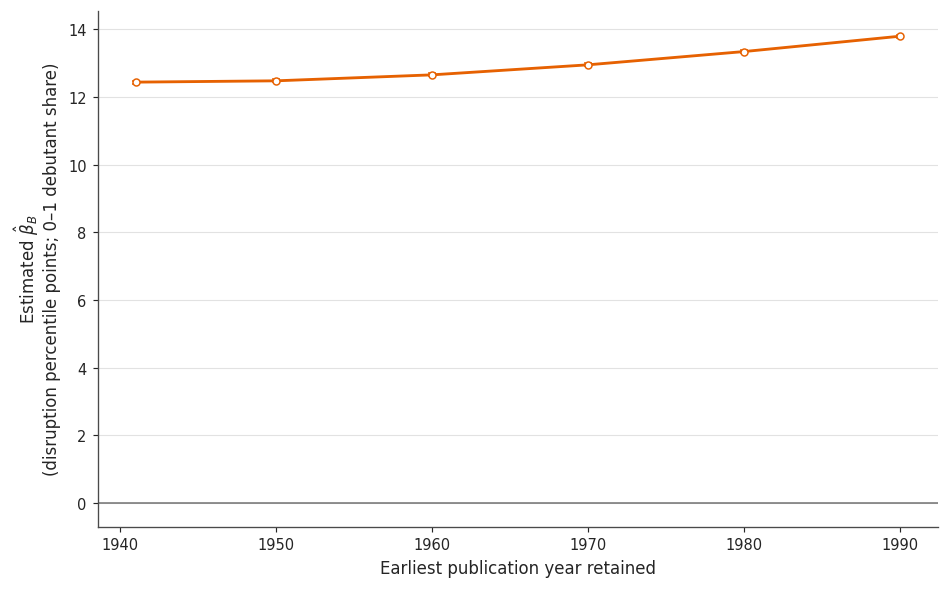

In [33]:
start_years = [1941, 1950, 1960, 1970, 1980, 1990]
left_rows = []

for sy in start_years:
    mask = A["year"] >= sy

    sub = {
        "year": A["year"][mask],
        "team_size": A["team_size"][mask],
        "disruption_percentile": A["disruption_percentile"][mask],
        "first_time_author_ratio": A["first_time_author_ratio"][mask],
    }

    r, _ = fit_two_way_fe_model(
        sub,
        outcome="disruption_percentile",
        predictors=["first_time_author_ratio"],
    )

    row = r.iloc[0].to_dict()
    row["start_year"] = sy
    left_rows.append(row)

    del sub
    gc.collect()

left_boundary = pd.DataFrame(left_rows)
display(left_boundary)

left_boundary.to_csv(
    OUTPUT_DIR / "left_boundary_sensitivity.csv",
    index=False,
)

export_pub_table(
    left_boundary,
    "T30_left_boundary_sensitivity",
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.errorbar(
    left_boundary["start_year"],
    left_boundary["coef"],
    yerr=[
        left_boundary["coef"] - left_boundary["ci95_low"],
        left_boundary["ci95_high"] - left_boundary["coef"],
    ],
    fmt="o-",
    color=ESTIMATE_COLOR,
    ecolor=ESTIMATE_COLOR,
    markerfacecolor="white",
    markeredgecolor=ESTIMATE_COLOR,
    markeredgewidth=0.9,
    linewidth=1.7,
    elinewidth=1.0,
    capsize=2.5,
)

add_zero_line(ax)
apply_science_axes(ax)

ax.set_xlabel("Earliest publication year retained")
ax.set_ylabel(
    "Estimated $\\hat{\\beta}_B$\n"
    "(disruption percentile points; 0–1 debutant share)"
)

plt.tight_layout()

save_pub_figure(
    fig,
    "left_boundary_sensitivity",
)
plt.show()

# Robustness across scientific fields

The manuscript field analysis uses the canonical SciSciNet-v2 Level-0
multi-membership file prepared by `01_prepare_sciscinet_fields.ipynb`:

```text
data/sciscinet_field_reconstruction_v2/
    analysis_level0_field_memberships.parquet
```

SciSciNet-v2 contains 19 Level-0 fields. Multidisciplinary papers retain all of
their Level-0 memberships, so field samples can overlap.

For each field, this section reports descriptive correlations and estimates the
debutant-share association with disruption percentile while controlling for
publication year and exact team size.

In [34]:
FIELD_BASE_REQUIRED = {
    "paperid",
    "year",
    "team_size",
    "first_time_author_ratio",
    "disruption_percentile",
}

FIELD_LONG_REQUIRED = {
    "level_0_field_name",
    "year",
    "team_size",
    "first_time_author_ratio",
    "disruption_percentile",
}

if RUN_CANONICAL_FIELD_ANALYSIS:
    if not LEVEL0_MEMBERSHIP_PATH.exists():
        raise FileNotFoundError(
            "Canonical Level-0 field membership file not found:\n"
            f"{LEVEL0_MEMBERSHIP_PATH.resolve()}\n\n"
            "Run the separate SciSciNet-v2 field reconstruction notebook first."
        )

    field_schema = pl.scan_parquet(
        LEVEL0_MEMBERSHIP_PATH
    ).collect_schema()

    required_membership_cols = {
        "paperid",
        "level_0_field_name",
    }

    missing_membership = (
        required_membership_cols - set(field_schema.names())
    )

    if missing_membership:
        raise ValueError(
            "Level-0 membership file is missing columns: "
            f"{sorted(missing_membership)}"
        )

    print("Canonical membership file:")
    print(" ", LEVEL0_MEMBERSHIP_PATH.resolve())
    print("Canonical membership schema:", field_schema)

    membership_audit = (
        pl.scan_parquet(LEVEL0_MEMBERSHIP_PATH)
        .select([
            pl.len().alias("membership_rows"),
            pl.col("paperid").n_unique().alias("unique_papers"),
            pl.col("level_0_field_name").n_unique().alias("unique_fields"),
        ])
        .collect()
    )

    display(membership_audit.to_pandas())

    if membership_audit["unique_fields"][0] != 19:
        raise RuntimeError(
            "Expected exactly 19 canonical Level-0 fields."
        )
else:
    print("RUN_CANONICAL_FIELD_ANALYSIS=False")

Canonical membership file:
  D:\beginners_charm\new_statistical_analysis\data\sciscinet_field_reconstruction_v2\analysis_level0_field_memberships.parquet
Canonical membership schema: Schema([('paperid', String), ('level_0_field_name', String)])


,membership_rows,unique_papers,unique_fields
0,91014730,32853369,19


## Build the field-analysis paper table

The main analysis cache omits `paperid`, so this step creates a minimal
paper-level table containing only the variables required to join the manuscript
sample to the canonical Level-0 memberships. The same paper-level sample
restrictions used in the main analysis are applied.

In [35]:
if RUN_CANONICAL_FIELD_ANALYSIS:
    remove_invalid_cache(
        FIELD_BASE_CACHE,
        FIELD_BASE_REQUIRED,
    )

    if not FIELD_BASE_CACHE.exists():
        t0 = perf_counter()

        field_base_cols = [
            "paperid",
            "doctype",
            "team_size",
            "year",
            "first_time_author_ratio",
            "avg_career_age",
            "senior_author_avg_disruption",
            "senior_author_ratio",
            "mid_career_author_ratio",
            "mid_author_avg_disruption",
            "early_career_author_ratio",
            "early_author_avg_disruption",
            "disruption",
        ]

        field_base = (
            pl.scan_csv(
                DATA_PATH,
                infer_schema_length=100_000,
                ignore_errors=False,
                try_parse_dates=False,
            )
            .select(field_base_cols)
            .with_columns([
                pl.col("paperid").cast(pl.String),
                pl.col("year").cast(pl.Int32, strict=False),
                pl.col("team_size").cast(pl.Int16, strict=False),
            ])
            .filter(pl.col("doctype") == "article")
            .filter(pl.col("team_size") <= MAX_TEAM_SIZE)
            .filter(pl.col("year") >= START_YEAR)
            .filter(~bad_all_beginner_expr())
            # Compute the global disruption percentile on the exact same
            # scoped population as the main analysis BEFORE excluding the
            # tiny number of rows without paper IDs.
            .with_columns(
                rank_pct("disruption")
            )
            .filter(
                pl.col("paperid").is_not_null()
                & (pl.col("paperid").str.len_chars() > 0)
            )
            .select([
                pl.col("paperid"),
                pl.col("year").cast(pl.Int16),
                pl.col("team_size").cast(pl.Int8),
                pl.col("first_time_author_ratio")
                  .cast(pl.Float32, strict=False),
                pl.col("disruption_percentile")
                  .cast(pl.Float32, strict=False),
            ])
        )

        print("Building field-base cache:")
        print(" ", FIELD_BASE_CACHE.resolve())

        field_base.sink_parquet(
            FIELD_BASE_CACHE,
            compression="zstd",
            compression_level=3,
            statistics=True,
            maintain_order=False,
        )

        print(
            f"Field base built in "
            f"{(perf_counter()-t0)/60:.2f} minutes."
        )
    else:
        print("Reusing field-base cache:")
        print(" ", FIELD_BASE_CACHE.resolve())

    field_base_audit = (
        pl.scan_parquet(FIELD_BASE_CACHE)
        .select([
            pl.len().alias("rows"),
            pl.col("paperid").n_unique().alias("unique_papers"),
            pl.col("paperid").null_count().alias("null_paperids"),
        ])
        .collect()
    )

    display(field_base_audit.to_pandas())

    print("Main analysis rows:", f"{len(A['year']):,}")
    print(
        "Field-base rows:",
        f"{field_base_audit['rows'][0]:,}",
    )
    print(
        "Difference is expected to be at most the tiny number of "
        "scoped rows lacking paper IDs."
    )

Reusing field-base cache:
  D:\beginners_charm\new_statistical_analysis\data\beginners_charm_cache_nov9_v3\04_field_base_with_paperid.parquet


,rows,unique_papers,null_paperids
0,29054261,29054261,0


Main analysis rows: 29,054,261
Field-base rows: 29,054,261
Difference is expected to be at most the tiny number of scoped rows lacking paper IDs.


## 7.2 Join scoped papers to all canonical Level-0 memberships

DuckDB performs this join with a 32-GB memory ceiling and disk spill. The output
contains only five analysis columns plus the field label, so later field models
do not touch the full public SciSciNet tables.

In [36]:
if RUN_CANONICAL_FIELD_ANALYSIS:
    remove_invalid_cache(
        FIELD_ANALYSIS_CACHE,
        FIELD_LONG_REQUIRED,
    )

    if not FIELD_ANALYSIS_CACHE.exists():
        t0 = perf_counter()

        temp_dir = str(
            FIELD_DUCKDB_TEMP.resolve()
        ).replace("\\", "/")

        base_path = str(
            FIELD_BASE_CACHE.resolve()
        ).replace("\\", "/")

        membership_path = str(
            LEVEL0_MEMBERSHIP_PATH.resolve()
        ).replace("\\", "/")

        out_path = str(
            FIELD_ANALYSIS_CACHE.resolve()
        ).replace("\\", "/")

        con = duckdb.connect()

        con.execute(
            f"SET memory_limit='{FIELD_JOIN_MEMORY_LIMIT}'"
        )
        con.execute(
            f"SET threads={FIELD_JOIN_THREADS}"
        )
        con.execute(
            "SET temp_directory=?",
            [temp_dir],
        )

        try:
            con.execute("SET preserve_insertion_order=false")
        except Exception:
            pass

        sql = f"""
        COPY (
            SELECT
                m.level_0_field_name,
                b.year,
                b.team_size,
                b.first_time_author_ratio,
                b.disruption_percentile
            FROM read_parquet('{base_path}') AS b
            INNER JOIN read_parquet('{membership_path}') AS m
                ON b.paperid = m.paperid
        )
        TO '{out_path}'
        (
            FORMAT PARQUET,
            COMPRESSION ZSTD,
            ROW_GROUP_SIZE 100000
        )
        """

        print("Building canonical Level-0 analysis cache with DuckDB")
        print("  memory limit:", FIELD_JOIN_MEMORY_LIMIT)
        print("  temp spill:", FIELD_DUCKDB_TEMP.resolve())
        print("  output:", FIELD_ANALYSIS_CACHE.resolve())

        try:
            con.execute(sql)
        finally:
            con.close()

        print(
            f"Canonical field join completed in "
            f"{(perf_counter()-t0)/60:.2f} minutes."
        )
    else:
        print("Reusing canonical field analysis cache:")
        print(" ", FIELD_ANALYSIS_CACHE.resolve())

    field_long_audit = (
        pl.scan_parquet(FIELD_ANALYSIS_CACHE)
        .select([
            pl.len().alias("membership_rows"),
            pl.col("level_0_field_name")
              .n_unique()
              .alias("unique_fields"),
        ])
        .collect()
    )

    display(field_long_audit.to_pandas())

    if field_long_audit["unique_fields"][0] != 19:
        raise RuntimeError(
            "Scoped field analysis cache does not contain all 19 fields."
        )

Reusing canonical field analysis cache:
  D:\beginners_charm\new_statistical_analysis\data\beginners_charm_cache_nov9_v3\05_canonical_level0_field_analysis_long.parquet


,membership_rows,unique_fields
0,81105257,19


## Descriptive correlations within the 19 broad fields

Pearson and Spearman correlations between debutant share and global disruption
percentile are calculated separately within each Level-0 field.

The adjusted field-specific models below provide the manuscript's primary
field-level robustness analysis.

In [37]:
if RUN_CANONICAL_FIELD_ANALYSIS:
    canonical_fields = (
        pl.scan_parquet(FIELD_ANALYSIS_CACHE)
        .select("level_0_field_name")
        .unique()
        .sort("level_0_field_name")
        .collect()["level_0_field_name"]
        .to_list()
    )

    if len(canonical_fields) != 19:
        raise RuntimeError(
            f"Expected 19 canonical fields, found {len(canonical_fields)}."
        )

    print(
        "Correlation and adjusted FE estimation will be performed "
        "jointly field-by-field in the next cell. This avoids a large "
        "all-fields grouped Spearman operation."
    )

Correlation and adjusted FE estimation will be performed jointly field-by-field in the next cell. This avoids a large all-fields grouped Spearman operation.


## Field-specific models with publication-year and exact team-size fixed effects

For each Level-0 field separately, estimate

$
D_i^{\mathrm{pct}}
=
\beta_B B_i
+
\alpha_{y(i)}
+
\gamma_{n(i)}
+
\varepsilon_i.
$

The resulting coefficients test whether the positive debutant-share association
with disruption appears within each broad scientific field after accounting for
publication year and exact team size.

In [38]:
canonical_field_corr_rows = []
canonical_field_fe_rows = []

if RUN_CANONICAL_FIELD_ANALYSIS:
    for j, field_name in enumerate(canonical_fields, start=1):
        t0 = perf_counter()

        fdf = (
            pl.scan_parquet(FIELD_ANALYSIS_CACHE)
            .filter(
                pl.col("level_0_field_name") == field_name
            )
            .select([
                "year",
                "team_size",
                "first_time_author_ratio",
                "disruption_percentile",
            ])
            .drop_nulls()
            .collect()
        )

        fd = {
            c: fdf[c].to_numpy()
            for c in fdf.columns
        }

        x = np.asarray(
            fd["first_time_author_ratio"],
            dtype=np.float64,
        )
        y = np.asarray(
            fd["disruption_percentile"],
            dtype=np.float64,
        )

        pearson = stats.pearsonr(x, y)
        spearman = stats.spearmanr(x, y)

        corr_row = {
            "level_0_field_name": field_name,
            "n": len(x),
            "pearson_r": float(pearson.statistic),
            "pearson_p": float(pearson.pvalue),
            "spearman_r": float(spearman.statistic),
            "spearman_p": float(spearman.pvalue),
        }

        if RUN_CANONICAL_FIELD_KENDALL:
            kt = kendalltau(x, y)
            corr_row["kendall_tau"] = float(kt.statistic)
            corr_row["kendall_p"] = float(kt.pvalue)

        canonical_field_corr_rows.append(corr_row)

        fit, _ = fit_two_way_fe_model(
            fd,
            outcome="disruption_percentile",
            predictors=["first_time_author_ratio"],
        )

        row = fit.iloc[0].to_dict()
        row["level_0_field_name"] = field_name
        canonical_field_fe_rows.append(row)

        print(
            f"[{j:02d}/19] {field_name}: "
            f"n={len(x):,}, "
            f"Pearson r={corr_row['pearson_r']:.4f}, "
            f"Spearman rho={corr_row['spearman_r']:.4f}, "
            f"FE beta={row['coef']:.4f}, "
            f"{perf_counter()-t0:.1f}s"
        )

        del fdf, fd, x, y
        gc.collect()

    canonical_field_corr = pd.DataFrame(
        canonical_field_corr_rows
    ).sort_values(
        "pearson_r",
        ascending=False,
    ).reset_index(drop=True)

    canonical_field_corr["pearson_p_fdr_bh"] = multipletests(
        canonical_field_corr["pearson_p"],
        method="fdr_bh",
    )[1]

    canonical_field_corr["spearman_p_fdr_bh"] = multipletests(
        canonical_field_corr["spearman_p"],
        method="fdr_bh",
    )[1]


if RUN_CANONICAL_FIELD_KENDALL:
    canonical_field_corr["kendall_p_fdr_bh"] = multipletests(
        canonical_field_corr["kendall_p"],
        method="fdr_bh",
    )[1]

    canonical_field_fe = pd.DataFrame(
        canonical_field_fe_rows
    )

    canonical_field_fe["p_fdr_bh"] = multipletests(
        canonical_field_fe["p"],
        method="fdr_bh",
    )[1]

    canonical_field_fe = canonical_field_fe.sort_values(
        "coef",
        ascending=False,
    ).reset_index(drop=True)

    print("\nCanonical field correlations:")
    display(canonical_field_corr)

    print("\nCanonical field adjusted FE results:")
    display(canonical_field_fe)

    export_pub_table(
        canonical_field_corr,
        "T30_canonical_19field_correlations",
    )

    export_pub_table(
        canonical_field_fe,
        "T31_canonical_19field_FE",
    )

    print(
        "Fields with positive Pearson r:",
        int((canonical_field_corr["pearson_r"] > 0).sum()),
        "of 19",
    )

    print(
        "Fields with positive Spearman rho:",
        int((canonical_field_corr["spearman_r"] > 0).sum()),
        "of 19",
    )

    print(
        "Positive adjusted beginner coefficients:",
        int((canonical_field_fe["coef"] > 0).sum()),
        "of 19",
    )

    print(
        "FDR-significant positive adjusted coefficients:",
        int(
            (
                (canonical_field_fe["coef"] > 0)
                & (canonical_field_fe["p_fdr_bh"] < 0.05)
            ).sum()
        ),
        "of 19",
    )

[01/19] Art: n=1,106,563, Pearson r=0.0850, Spearman rho=0.0751, FE beta=8.2784, 1.0s
[02/19] Biology: n=8,240,399, Pearson r=0.0972, Spearman rho=0.0679, FE beta=11.4095, 6.1s
[03/19] Business: n=1,721,427, Pearson r=0.1263, Spearman rho=0.1255, FE beta=11.0323, 1.3s
[04/19] Chemistry: n=7,740,170, Pearson r=0.0976, Spearman rho=0.0797, FE beta=12.4640, 6.1s
[05/19] Computer science: n=9,102,699, Pearson r=0.1193, Spearman rho=0.1118, FE beta=13.4520, 7.0s
[06/19] Economics: n=2,670,974, Pearson r=0.1196, Spearman rho=0.1115, FE beta=12.3398, 1.8s
[07/19] Engineering: n=5,735,626, Pearson r=0.1162, Spearman rho=0.1048, FE beta=13.9530, 4.3s
[08/19] Environmental science: n=1,418,544, Pearson r=0.1424, Spearman rho=0.1297, FE beta=15.9631, 1.0s
[09/19] Geography: n=1,710,299, Pearson r=0.1248, Spearman rho=0.1115, FE beta=12.3125, 1.1s
[10/19] Geology: n=1,875,846, Pearson r=0.1351, Spearman rho=0.1218, FE beta=16.1470, 1.4s
[11/19] History: n=713,100, Pearson r=0.0751, Spearman rho=0.

,level_0_field_name,n,pearson_r,pearson_p,spearman_r,spearman_p,kendall_tau,kendall_p,pearson_p_fdr_bh,spearman_p_fdr_bh,kendall_p_fdr_bh
0,Environmental science,1418544,0.142424,0.0,0.129691,0.0,0.099459,0.0,0.0,0.0,0.0
1,Geology,1875846,0.135085,0.0,0.121791,0.0,0.094262,0.0,0.0,0.0,0.0
2,Business,1721427,0.126272,0.0,0.125498,0.0,0.097444,0.0,0.0,0.0,0.0
3,Geography,1710299,0.124763,0.0,0.111490,0.0,0.086207,0.0,0.0,0.0,0.0
4,Economics,2670974,0.119581,0.0,0.111527,0.0,0.087004,0.0,0.0,0.0,0.0
5,Computer science,9102699,0.119307,0.0,0.111751,0.0,0.086484,0.0,0.0,0.0,0.0
6,Mathematics,5968273,0.118385,0.0,0.114001,0.0,0.089075,0.0,0.0,0.0,0.0
7,Engineering,5735626,0.116227,0.0,0.104844,0.0,0.080408,0.0,0.0,0.0,0.0
8,Physics,8476490,0.114069,0.0,0.099925,0.0,0.077384,0.0,0.0,0.0,0.0
9,Psychology,3472859,0.111939,0.0,0.087214,0.0,0.067176,0.0,0.0,0.0,0.0



Canonical field adjusted FE results:


,term,coef,robust_se_HC1,t,p,ci95_low,ci95_high,n,level_0_field_name,p_fdr_bh
0,first_time_author_ratio,16.146951,0.098240,164.362319,0.0,15.954404,16.339498,1875846,Geology,0.0
1,first_time_author_ratio,15.963085,0.099197,160.922637,0.0,15.768662,16.157508,1418544,Environmental science,0.0
2,first_time_author_ratio,14.966412,0.047420,315.614869,0.0,14.873471,15.059353,8476490,Physics,0.0
3,first_time_author_ratio,13.952989,0.052244,267.073528,0.0,13.850592,14.055385,5735626,Engineering,0.0
4,first_time_author_ratio,13.779459,0.065765,209.525321,0.0,13.650562,13.908356,5159780,Materials science,0.0
5,first_time_author_ratio,13.452020,0.038095,353.114539,0.0,13.377355,13.526686,9102699,Computer science,0.0
6,first_time_author_ratio,13.209494,0.050273,262.756172,0.0,13.110962,13.308027,5968273,Mathematics,0.0
7,first_time_author_ratio,12.463997,0.050107,248.746137,0.0,12.365788,12.562205,7740170,Chemistry,0.0
8,first_time_author_ratio,12.339825,0.063775,193.488772,0.0,12.214827,12.464823,2670974,Economics,0.0
9,first_time_author_ratio,12.312485,0.080098,153.717071,0.0,12.155495,12.469475,1710299,Geography,0.0


Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T30_canonical_19field_correlations.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T30_canonical_19field_correlations.tex
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T31_canonical_19field_FE.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T31_canonical_19field_FE.tex
Fields with positive Pearson r: 19 of 19
Fields with positive Spearman rho: 19 of 19
Positive adjusted beginner coefficients: 19 of 19
FDR-significant positive adjusted coefficients: 19 of 19


## Field-specific coefficient figure

Saved figure: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\figures\canonical_19field_debutant_share_effects.pdf


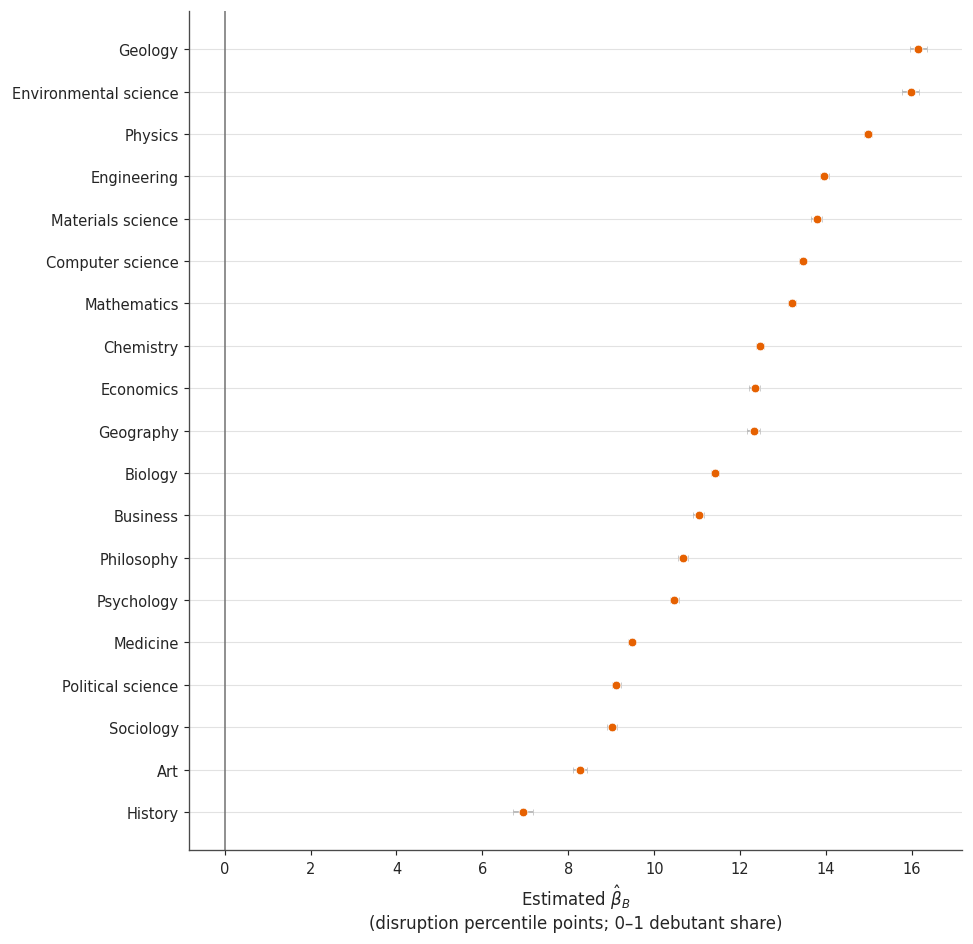

In [39]:
if RUN_CANONICAL_FIELD_ANALYSIS:
    plot_df = canonical_field_fe.sort_values("coef").copy()

    fig_height = max(5.5, 0.34 * len(plot_df) + 1.5)
    fig, ax = plt.subplots(
        figsize=(8.2, fig_height)
    )

    y = np.arange(len(plot_df))

    ax.errorbar(
        plot_df["coef"],
        y,
        xerr=[
            plot_df["coef"] - plot_df["ci95_low"],
            plot_df["ci95_high"] - plot_df["coef"],
        ],
        fmt="o",
        color=ESTIMATE_COLOR,
        ecolor=COLORS["neutral_light"],
        markerfacecolor=ESTIMATE_COLOR,
        markeredgecolor="white",
        markeredgewidth=0.45,
        markersize=5.2,
        elinewidth=1.2,
        capsize=2.0,
    )

    add_zero_line(ax, orientation="v")
    apply_science_axes(ax)

    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["level_0_field_name"])
    ax.set_xlabel(
        "Estimated $\\hat{\\beta}_B$\n"
        "(disruption percentile points; 0–1 debutant share)"
    )

    plt.tight_layout()

    save_pub_figure(
        fig,
        "canonical_19field_debutant_share_effects",
    )
    plt.show()

## Descriptive debutant-share gradients across fields

This preserves the visual idea of the existing broad-discipline figure.

For team sizes 1–7, actual beginner-share values are used. For team sizes 8+,
beginner share is grouped into ten equal-width bins, matching the logic of the
repository's field plotting function. Cells with fewer than 50 papers are not
drawn.

Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T32_canonical_19field_plot_data.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T32_canonical_19field_plot_data.tex
Saved figure data: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\FigureData_canonical_19field_descriptive_grid.csv
Saved figure: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\figures\canonical_19field_descriptive_grid.pdf


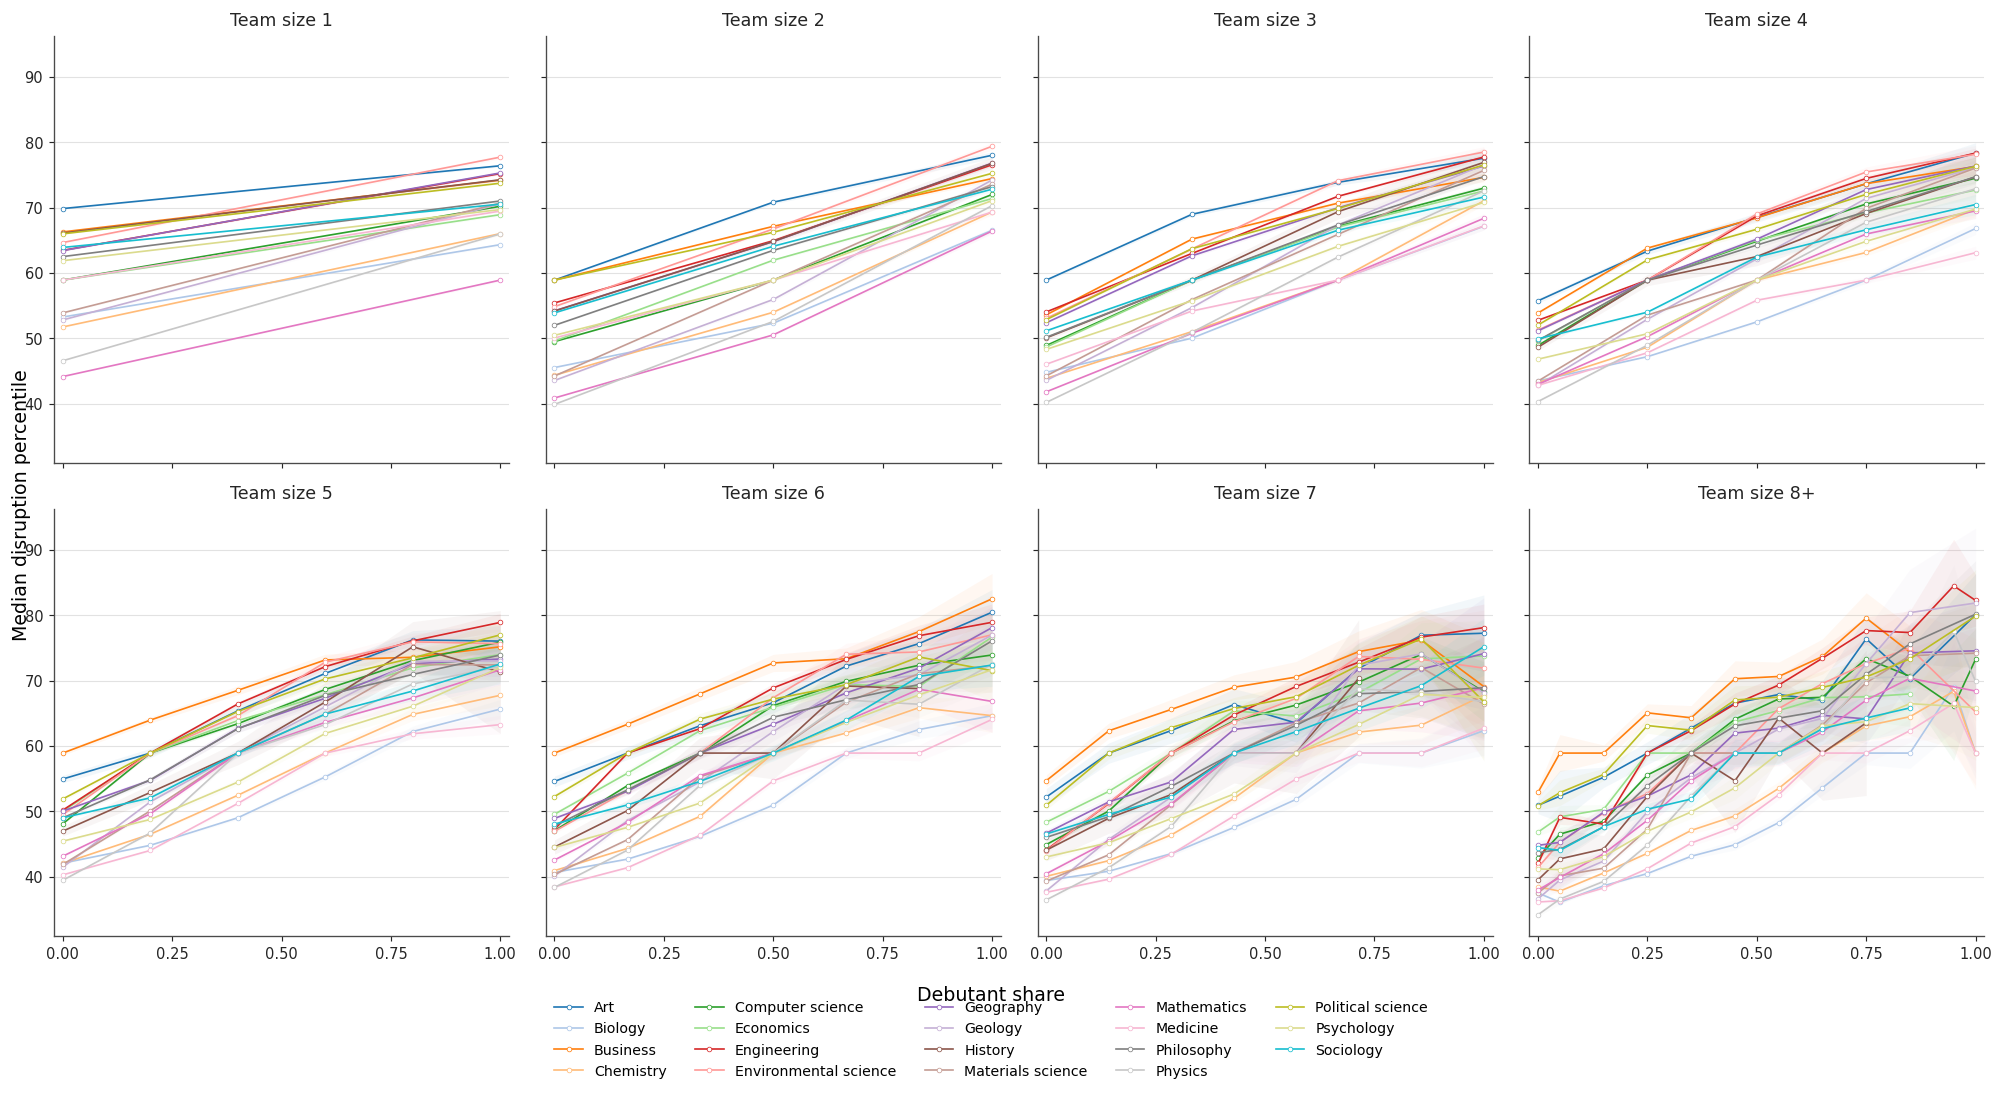

In [40]:
if RUN_CANONICAL_FIELD_ANALYSIS:
    field_plot_stats = (
        pl.scan_parquet(FIELD_ANALYSIS_CACHE)
        .drop_nulls([
            "level_0_field_name",
            "team_size",
            "first_time_author_ratio",
            "disruption_percentile",
        ])
        .with_columns([
            pl.when(pl.col("team_size") >= 8)
              .then(pl.lit("8+"))
              .otherwise(
                  pl.col("team_size").cast(pl.String)
              )
              .alias("team_group"),

            pl.when(pl.col("team_size") < 8)
              .then(
                  pl.col("first_time_author_ratio")
                    .round(3)
                    .cast(pl.Float64)
              )
              .when(pl.col("first_time_author_ratio") == 0)
              .then(pl.lit(0.0))
              .when(pl.col("first_time_author_ratio") == 1)
              .then(pl.lit(1.0))
              .otherwise(
                  (
                      (
                          pl.col("first_time_author_ratio")
                          .cast(pl.Float64)
                          * 10
                      ).floor()
                      / 10
                  )
                  + 0.05
              )
              .alias("x_plot"),
        ])
        .group_by([
            "level_0_field_name",
            "team_group",
            "x_plot",
        ])
        .agg([
            pl.len().alias("n"),
            pl.col("disruption_percentile")
              .median()
              .alias("median_disruption_percentile"),
            pl.col("disruption_percentile")
              .quantile(0.25)
              .alias("q25"),
            pl.col("disruption_percentile")
              .quantile(0.75)
              .alias("q75"),
        ])
        .filter(pl.col("n") >= 50)
        .with_columns(
            (
                1.57
                * (pl.col("q75") - pl.col("q25"))
                / pl.col("n").cast(pl.Float64).sqrt()
            ).alias("median_ci_halfwidth")
        )
        .with_columns([
            (
                pl.col("median_disruption_percentile")
                - pl.col("median_ci_halfwidth")
            ).alias("ci95_low"),
            (
                pl.col("median_disruption_percentile")
                + pl.col("median_ci_halfwidth")
            ).alias("ci95_high"),
        ])
        .collect()
        .to_pandas()
    )

    export_pub_table(
        field_plot_stats,
        "T32_canonical_19field_plot_data",
    )
    export_figure_data(
        field_plot_stats,
        "canonical_19field_descriptive_grid",
    )

    team_order = [
        "1", "2", "3", "4",
        "5", "6", "7", "8+",
    ]

    canonical_fields_sorted = sorted(
        field_plot_stats["level_0_field_name"].unique()
    )

    # Return to the earlier categorical-field treatment.
    cmap = plt.get_cmap("tab20")
    field_colors = {
        field_name: cmap(k % 20)
        for k, field_name in enumerate(canonical_fields_sorted)
    }

    fig, axes = plt.subplots(
        2,
        4,
        figsize=(17, 8.5),
        sharex=True,
        sharey=True,
    )

    axes = axes.ravel()

    for ax, team_group in zip(axes, team_order):
        sub = field_plot_stats[
            field_plot_stats["team_group"] == team_group
        ]

        for field_name in canonical_fields_sorted:
            g = (
                sub[
                    sub["level_0_field_name"] == field_name
                ]
                .sort_values("x_plot")
            )

            if len(g) == 0:
                continue

            color = field_colors[field_name]

            ax.plot(
                g["x_plot"],
                g["median_disruption_percentile"],
                marker="o",
                markersize=2.8,
                markerfacecolor="white",
                markeredgecolor=color,
                markeredgewidth=0.45,
                linewidth=1.0,
                color=color,
                label=field_name if team_group == "1" else None,
                zorder=3,
            )

            ax.fill_between(
                g["x_plot"],
                g["ci95_low"],
                g["ci95_high"],
                color=color,
                alpha=0.055,
                linewidth=0,
                zorder=2,
            )

        ax.set_title(
            f"Team size {team_group}"
            if team_group != "8+"
            else "Team size 8+"
        )
        ax.set_xlim(-0.02, 1.02)
        ax.set_xticks([0, 0.25, 0.50, 0.75, 1.0])
        apply_science_axes(ax)

    fig.supxlabel("Debutant share")
    fig.supylabel("Median disruption percentile")

    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.075),
        ncol=5,
        frameon=False,
    )

    plt.tight_layout()

    save_pub_figure(
        fig,
        "canonical_19field_descriptive_grid",
    )
    plt.show()

# Citation-impact analysis with a complete 10-year window

Citation analyses are restricted to papers published through 2010 so that every
included paper has a complete 10-year citation window. Citation impact is
measured using \(C_{10}\), ranked within publication year.

,term,coef,robust_se_HC1,t,p,ci95_low,ci95_high,n
0,disruption_percentile,-0.236878,0.000267,-888.759392,0.0,-0.237401,-0.236356,15956489
1,first_time_author_ratio,-13.804870,0.055334,-249.481562,0.0,-13.913323,-13.696417,15956489
2,disruption_x_beginner,0.053005,0.000854,62.056748,0.0,0.051331,0.054679,15956489


Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T50_complete_window_C10_interaction_FE.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T50_complete_window_C10_interaction_FE.tex


,contrast,estimate,se,ci95_low,ci95_high,disruption_percentile
0,+10pp debutant-share effect at disruption p10,-1.327482,0.004801,-1.336892,-1.318072,10
1,+10pp debutant-share effect at disruption p25,-1.247975,0.003799,-1.255422,-1.240529,25
2,+10pp debutant-share effect at disruption p50,-1.115464,0.002714,-1.120784,-1.110144,50
3,+10pp debutant-share effect at disruption p75,-0.982952,0.003069,-0.988968,-0.976936,75
4,+10pp debutant-share effect at disruption p90,-0.903445,0.003877,-0.911044,-0.895846,90
5,+10pp debutant-share effect at disruption p100,-0.850440,0.004538,-0.859335,-0.841546,100


Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T51_C10_debutant_simple_slopes.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T51_C10_debutant_simple_slopes.tex
Saved figure: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\figures\c10_debutant_share_effect_across_disruption.pdf


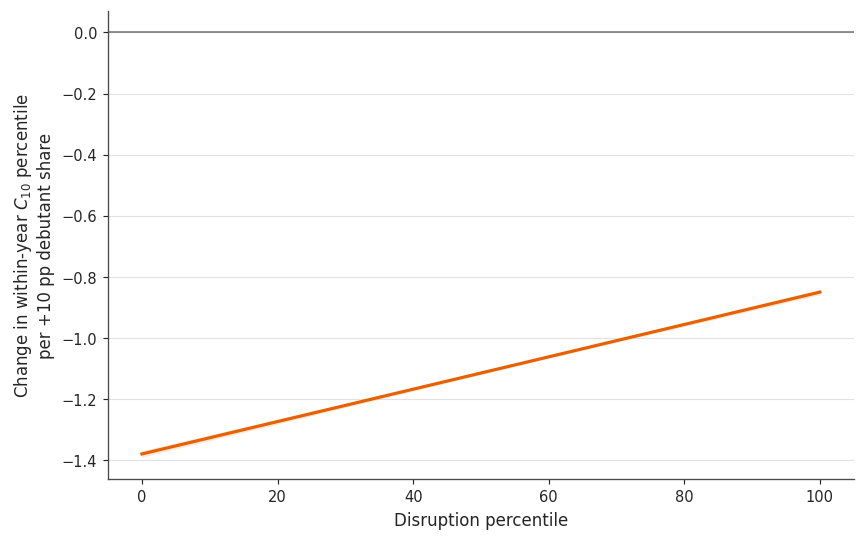

Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T52_C10_debutant_slope_curve.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T52_C10_debutant_slope_curve.tex


5958

In [43]:
mask = A["year"] <= C10_COMPLETE_THROUGH

c10_data = {
    "year": A["year"][mask],
    "team_size": A["team_size"][mask],
    "C10_percentile_within_year": A["C10_percentile_within_year"][mask],
    "disruption_percentile": A["disruption_percentile"][mask],
    "first_time_author_ratio": A["first_time_author_ratio"][mask],
    "disruption_x_beginner": A["disruption_x_beginner"][mask],
}

citation_fe, citation_cov, citation_info = fit_two_way_fe_model_full(
    c10_data,
    outcome="C10_percentile_within_year",
    predictors=[
        "disruption_percentile",
        "first_time_author_ratio",
        "disruption_x_beginner",
    ],
)

display(citation_fe)

citation_fe.to_csv(
    OUTPUT_DIR / "additional_complete_C10_interaction_FE.csv",
    index=False,
)

export_pub_table(
    citation_fe,
    "T50_complete_window_C10_interaction_FE",
)

citation_beginner_slopes = []

for d_pct in [10, 25, 50, 75, 90, 100]:
    row = linear_combo_from_model(
        citation_fe,
        citation_cov,
        weights={
            "first_time_author_ratio": 0.1,
            "disruption_x_beginner": 0.1 * float(d_pct),
        },
        label=f"+10pp debutant-share effect at disruption p{d_pct}",
    )
    row["disruption_percentile"] = d_pct
    citation_beginner_slopes.append(row)

citation_beginner_slopes = pd.DataFrame(
    citation_beginner_slopes
)

display(citation_beginner_slopes)

export_pub_table(
    citation_beginner_slopes,
    "T51_C10_debutant_simple_slopes",
)

citation_slope_curve = []

for d_pct in np.linspace(0, 100, 101):
    row = linear_combo_from_model(
        citation_fe,
        citation_cov,
        weights={
            "first_time_author_ratio": 0.1,
            "disruption_x_beginner": 0.1 * float(d_pct),
        },
        label="debutant effect",
    )
    row["disruption_percentile"] = d_pct
    citation_slope_curve.append(row)

citation_slope_curve = pd.DataFrame(
    citation_slope_curve
)

fig, ax = plt.subplots(figsize=(7.3, 4.6))

ax.plot(
    citation_slope_curve["disruption_percentile"],
    citation_slope_curve["estimate"],
    color=ESTIMATE_COLOR,
    linewidth=1.9,
)

ax.fill_between(
    citation_slope_curve["disruption_percentile"],
    citation_slope_curve["ci95_low"],
    citation_slope_curve["ci95_high"],
    color=ESTIMATE_COLOR,
    alpha=0.14,
    linewidth=0,
)

add_zero_line(ax)
apply_science_axes(ax)

ax.set_xlabel("Disruption percentile")
ax.set_ylabel(
    "Change in within-year $C_{10}$ percentile\n"
    "per +10 pp debutant share"
)

plt.tight_layout()

save_pub_figure(
    fig,
    "c10_debutant_share_effect_across_disruption",
)
plt.show()

export_pub_table(
    citation_slope_curve,
    "T52_C10_debutant_slope_curve",
)

del c10_data
gc.collect()

## 9.1 Citation effect sizes among the top 10% most disruptive papers

,beginner_group,count,mean,median,std,se,ci95_low_mean,ci95_high_mean
0,0.00 - 0.25,1362347,45.393841,42.430069,29.406408,0.025194,45.344460,45.443221
1,0.25 - 0.50,313390,45.045311,42.604206,28.163198,0.050308,44.946707,45.143915
2,0.50 - 0.75,53988,41.430260,37.713848,27.473995,0.118242,41.198505,41.662015
3,0.75 - 1.00,169098,33.481903,26.917900,26.397858,0.064195,33.356081,33.607725


Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T53_top10_disruption_C10_effect_sizes.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T53_top10_disruption_C10_effect_sizes.tex
Saved figure: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\figures\top10_disruption_c10_levels.pdf


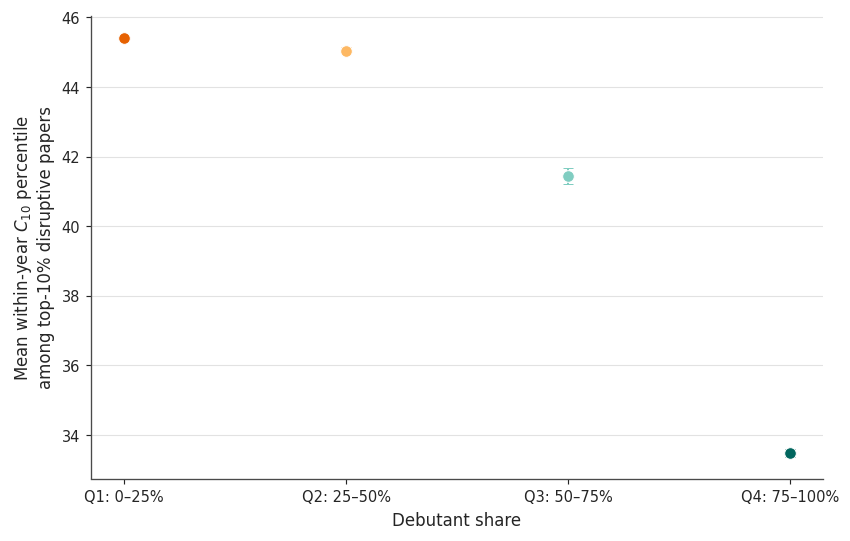

In [44]:
c10_tail = (
    pl.scan_parquet(ANALYSIS_CACHE)
    .filter(
        (pl.col("year") <= C10_COMPLETE_THROUGH)
        & (pl.col("disruption_percentile") >= 90)
        & pl.col("C10_percentile_within_year").is_not_null()
    )
    .with_columns(
        pl.when(pl.col("first_time_author_ratio") <= 0.25)
          .then(pl.lit("0.00 - 0.25"))
        .when(pl.col("first_time_author_ratio") <= 0.50)
          .then(pl.lit("0.25 - 0.50"))
        .when(pl.col("first_time_author_ratio") <= 0.75)
          .then(pl.lit("0.50 - 0.75"))
        .otherwise(pl.lit("0.75 - 1.00"))
        .alias("beginner_group")
    )
    .group_by("beginner_group")
    .agg([
        pl.len().alias("count"),
        pl.col("C10_percentile_within_year").mean().alias("mean"),
        pl.col("C10_percentile_within_year").median().alias("median"),
        pl.col("C10_percentile_within_year").std().alias("std"),
    ])
    .sort("beginner_group")
    .collect()
    .to_pandas()
)

c10_tail["se"] = c10_tail["std"] / np.sqrt(c10_tail["count"])
c10_tail["ci95_low_mean"] = c10_tail["mean"] - 1.96 * c10_tail["se"]
c10_tail["ci95_high_mean"] = c10_tail["mean"] + 1.96 * c10_tail["se"]

display(c10_tail)

c10_tail.to_csv(
    OUTPUT_DIR / "additional_top10_disruption_C10_effect_sizes.csv",
    index=False,
)

export_pub_table(
    c10_tail,
    "T53_top10_disruption_C10_effect_sizes",
)

fig, ax = plt.subplots(figsize=(7.2, 4.6))

ordered_groups = [
    "0.00 - 0.25",
    "0.25 - 0.50",
    "0.50 - 0.75",
    "0.75 - 1.00",
]

plot_tail = (
    c10_tail
    .set_index("beginner_group")
    .loc[ordered_groups]
    .reset_index()
)

x = np.arange(len(plot_tail))

for idx, row in plot_tail.iterrows():
    group = row["beginner_group"]
    color = DEBUT_QUARTILE_COLORS[group]

    ax.errorbar(
        idx,
        row["mean"],
        yerr=np.array([
            [row["mean"] - row["ci95_low_mean"]],
            [row["ci95_high_mean"] - row["mean"]],
        ]),
        fmt="o",
        color=color,
        ecolor=color,
        markerfacecolor=color,
        markeredgecolor="white",
        markeredgewidth=0.6,
        markersize=7,
        elinewidth=1.2,
        capsize=3,
        zorder=3,
    )

ax.set_xticks(x)
ax.set_xticklabels([
    DEBUT_QUARTILE_DISPLAY[g]
    for g in ordered_groups
])
ax.set_xlabel("Debutant share")
ax.set_ylabel(
    "Mean within-year $C_{10}$ percentile\n"
    "among top-10% disruptive papers"
)

apply_science_axes(ax)

plt.tight_layout()

save_pub_figure(
    fig,
    "top10_disruption_c10_levels",
)
plt.show()

## Disruption–citation relationship within nested disruptive tails

Papers are ordered by disruption percentile and included in nested cumulative
sets beginning with the top 10% most disruptive papers and expanding through
the full sample.

Within each cumulative set, papers are divided into four debutant-share groups.
For each group, the Spearman correlation between disruption percentile and
within-year \(C_{10}\) percentile is calculated.

This analysis corresponds to Supplementary Figure S11.

,beginner_group,n,spearman_r,top_disruption_percent,p_approx,spearman_ci95_low,spearman_ci95_high
0,0.00 - 0.25,1362347,-0.058149,10,0.000000e+00,-0.059822,-0.056475
1,0.25 - 0.50,313390,-0.042180,10,2.231893e-123,-0.045674,-0.038684
2,0.50 - 0.75,53988,-0.031415,10,2.854194e-13,-0.039840,-0.022986
3,0.75 - 1.00,169098,-0.001411,10,5.618741e-01,-0.006177,0.003356
4,0.00 - 0.25,2602252,-0.010361,20,1.039467e-62,-0.011576,-0.009146
5,0.25 - 0.50,584994,0.013288,20,2.877442e-24,0.010726,0.015850
6,0.50 - 0.75,97022,0.023802,20,1.217803e-13,0.017512,0.030090
7,0.75 - 1.00,275178,0.041051,20,6.144922e-103,0.037320,0.044780
8,0.00 - 0.25,3725509,0.043993,30,0.000000e+00,0.042980,0.045007
9,0.25 - 0.50,812396,0.066376,30,0.000000e+00,0.064211,0.068541


Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T54_fixed_window_C10_cumulative_curve.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T54_fixed_window_C10_cumulative_curve.tex
Saved figure: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\figures\fixed_window_c10_cumulative_correlation.pdf


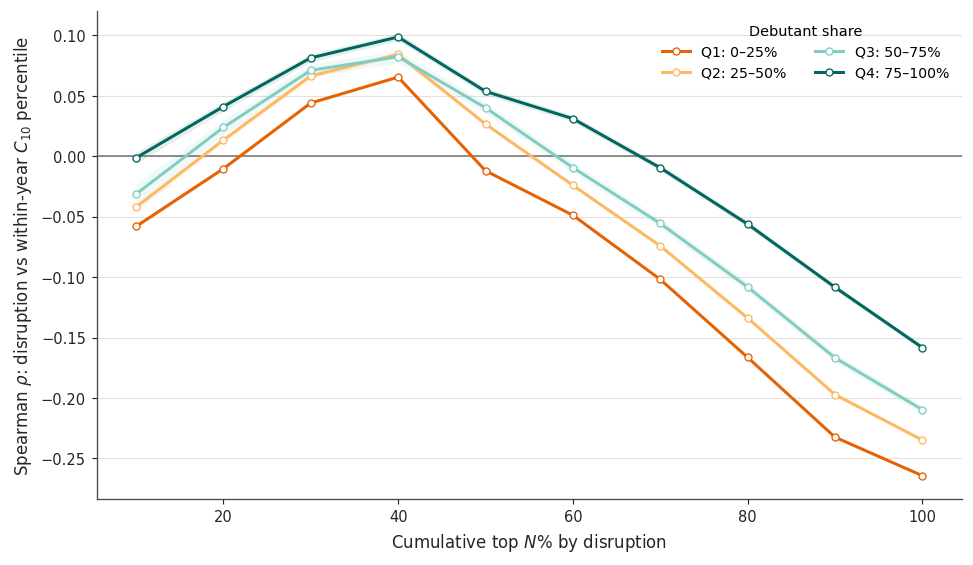

12618

In [45]:
c10_curve_source = (
    pl.read_parquet(
        ANALYSIS_CACHE,
        columns=[
            "year",
            "disruption_percentile",
            "C10_percentile_within_year",
            "first_time_author_ratio",
        ],
    )
    .filter(
        (pl.col("year") <= C10_COMPLETE_THROUGH)
        & pl.col("disruption_percentile").is_not_null()
        & pl.col("C10_percentile_within_year").is_not_null()
        & pl.col("first_time_author_ratio").is_not_null()
    )
    .with_columns([
        pl.col("disruption_percentile")
          .cast(pl.Float64)
          .alias("_d"),
        pl.col("C10_percentile_within_year")
          .cast(pl.Float64)
          .alias("_c10"),
    ])
    .with_columns(
        pl.when(pl.col("first_time_author_ratio") <= 0.25)
          .then(pl.lit("0.00 - 0.25"))
        .when(pl.col("first_time_author_ratio") <= 0.50)
          .then(pl.lit("0.25 - 0.50"))
        .when(pl.col("first_time_author_ratio") <= 0.75)
          .then(pl.lit("0.50 - 0.75"))
        .otherwise(pl.lit("0.75 - 1.00"))
        .alias("beginner_group")
    )
)

c10_curve_rows = []

for top_n in range(10, 101, 10):
    threshold = 100 - top_n

    tab = (
        c10_curve_source
        .filter(pl.col("disruption_percentile") >= threshold)
        .group_by("beginner_group")
        .agg([
            pl.len().alias("n"),
            pl.corr(
                "_d",
                "_c10",
                method="spearman",
            )
            .cast(pl.Float64)
            .alias("spearman_r"),
        ])
        .sort("beginner_group")
        .to_pandas()
    )

    tab["top_disruption_percent"] = top_n
    c10_curve_rows.append(tab)

c10_cumulative_corr = pd.concat(
    c10_curve_rows,
    ignore_index=True,
)

c10_cumulative_corr["p_approx"] = [
    corr_p_from_r(r, n)
    for r, n in zip(
        c10_cumulative_corr["spearman_r"],
        c10_cumulative_corr["n"],
    )
]
c10_cumulative_corr = add_fisher_ci_columns(
    c10_cumulative_corr,
    "spearman_r",
    prefix="spearman",
)

display(c10_cumulative_corr.head(20))

export_pub_table(
    c10_cumulative_corr,
    "T54_fixed_window_C10_cumulative_curve",
)

fig, ax = plt.subplots(figsize=(8.2, 4.8))

for group_name, g in c10_cumulative_corr.groupby(
    "beginner_group",
    sort=True,
):
    color = DEBUT_QUARTILE_COLORS[group_name]

    ax.plot(
        g["top_disruption_percent"],
        g["spearman_r"],
        marker="o",
        markerfacecolor="white",
        markeredgecolor=color,
        markeredgewidth=0.8,
        color=color,
        linewidth=1.8,
        label=DEBUT_QUARTILE_DISPLAY[group_name],
    )

    ax.fill_between(
        g["top_disruption_percent"],
        g["spearman_ci95_low"],
        g["spearman_ci95_high"],
        color=color,
        alpha=0.11,
        linewidth=0,
    )

add_zero_line(ax)
apply_science_axes(ax)

ax.set_xlabel("Cumulative top $N$% by disruption")
ax.set_ylabel(
    "Spearman $\\rho$: disruption vs within-year $C_{10}$ percentile"
)
ax.legend(
    title="Debutant share",
    ncol=2,
)

plt.tight_layout()

save_pub_figure(
    fig,
    "fixed_window_c10_cumulative_correlation",
)
plt.show()

del c10_curve_source
gc.collect()

# Part X — Alternative career-stage specification

In [46]:
alternative_stage_fe, _ = fit_two_way_fe_model(
    A,
    outcome="disruption_percentile",
    predictors=[
        "first_time_author_ratio",
        "early_1_5_author_ratio",
        "mid_6_10_author_ratio",
    ],
)

display(alternative_stage_fe)
alternative_stage_fe.to_csv(
    OUTPUT_DIR / "additional_alternative_career_stage_FE.csv",
    index=False,
)

export_pub_table(alternative_stage_fe, "T60_alternative_career_stage_FE")

,term,coef,robust_se_HC1,t,p,ci95_low,ci95_high,n
0,first_time_author_ratio,13.483646,0.023478,574.299113,0.0,13.437629,13.529663,29054261
1,early_1_5_author_ratio,3.092794,0.021472,144.038056,0.0,3.050709,3.134878,29054261
2,mid_6_10_author_ratio,1.924996,0.022104,87.089439,0.0,1.881673,1.968318,29054261


Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T60_alternative_career_stage_FE.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T60_alternative_career_stage_FE.tex


(WindowsPath('Reanalysis_Results_v9/tables/T60_alternative_career_stage_FE.csv'),
 WindowsPath('Reanalysis_Results_v9/tables/T60_alternative_career_stage_FE.tex'))

# Part XI — Adjusted nonlinearity diagnostic

A normality test is not useful at this sample size. Instead, inspect whether the adjusted beginner-share relationship is strongly nonlinear after removing year and team-size fixed effects.

,bin,beginner_ratio_mean,residual_disruption_mean,n,se,ci95_low,ci95_high
0,0,0.000003,-1.768112,20417160,0.006233,-1.780329,-1.755894
1,1,0.081401,-0.876452,64673,0.102509,-1.077369,-0.675535
2,2,0.128799,0.023728,499970,0.037863,-0.050484,0.097939
3,3,0.166999,0.660293,442594,0.041971,0.578029,0.742556
4,4,0.230742,1.690833,1824928,0.021189,1.649304,1.732363
5,5,0.284808,3.429904,105420,0.086697,3.259977,3.599831
6,6,0.333093,3.412795,1677693,0.022441,3.368810,3.456780
7,7,0.373713,5.995138,31151,0.160615,5.680332,6.309943
8,8,0.405094,5.516978,295883,0.053782,5.411564,5.622392
9,9,0.499947,5.110916,1970549,0.021036,5.069686,5.152145


Saved figure: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\figures\adjusted_nonlinearity_diagnostic.pdf


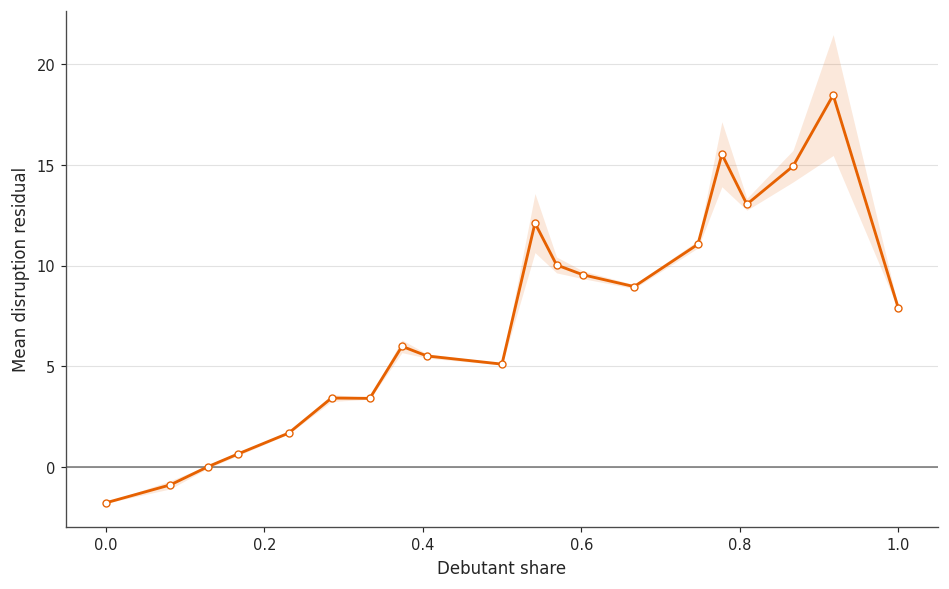

Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T61_adjusted_nonlinearity_diagnostic.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T61_adjusted_nonlinearity_diagnostic.tex


5686

In [47]:
mask = finite_mask(
    A["disruption_percentile"],
    A["first_time_author_ratio"],
    A["year"],
    A["team_size"],
)

Y = A["disruption_percentile"][mask].astype(np.float64)
B = A["first_time_author_ratio"][mask].astype(np.float64)
YR = A["year"][mask]
TS = A["team_size"][mask]

y_resid, _ = residualize_two_way_exact(Y, YR, TS)

edges = np.linspace(0, 1, 21)
bin_id = np.digitize(B, edges[1:-1], right=True)

curve_rows = []
for b in range(20):
    m = bin_id == b
    if not np.any(m):
        continue

    vals = y_resid[m]
    xvals = B[m]
    n = len(vals)
    mean = vals.mean()
    sd = vals.std(ddof=1)
    se = sd / np.sqrt(n)

    curve_rows.append({
        "bin": b,
        "beginner_ratio_mean": xvals.mean(),
        "residual_disruption_mean": mean,
        "n": n,
        "se": se,
        "ci95_low": mean - 1.96 * se,
        "ci95_high": mean + 1.96 * se,
    })

curve = pd.DataFrame(curve_rows)
display(curve)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    curve["beginner_ratio_mean"],
    curve["residual_disruption_mean"],
    color=ESTIMATE_COLOR,
    marker="o",
    markerfacecolor="white",
    markeredgecolor=ESTIMATE_COLOR,
    markeredgewidth=0.8,
    linewidth=1.7,
)

ax.fill_between(
    curve["beginner_ratio_mean"],
    curve["ci95_low"],
    curve["ci95_high"],
    color=ESTIMATE_COLOR,
    alpha=0.14,
    linewidth=0,
)

add_zero_line(ax)
apply_science_axes(ax)

ax.set_xlabel("Debutant share")
ax.set_ylabel("Mean disruption residual")

plt.tight_layout()

save_pub_figure(
    fig,
    "adjusted_nonlinearity_diagnostic",
)
plt.show()

export_pub_table(
    curve,
    "T61_adjusted_nonlinearity_diagnostic",
)

curve.to_csv(
    OUTPUT_DIR / "additional_adjusted_nonlinearity_diagnostic.csv",
    index=False,
)

del Y, B, YR, TS, y_resid, bin_id
gc.collect()

# Part XII — Consolidated manuscript-ready statistical table

For reporting, emphasize coefficients, 95% CIs, and interpretable contrasts rather than astronomically small p-values.

In [48]:
def tagged(df, analysis):
    z = df.copy()
    z.insert(0, "analysis", analysis)
    return z

master_parts = [
    tagged(main_fe, "Main FE model"),
    tagged(interaction_fe, "Beginner x team-size interaction"),
    tagged(composition_fe, "Composition-aware counts"),
    tagged(collab_stage_fe, "Collaborator career stage"),
    tagged(prior_disruption_fe, "Prior collaborator disruption"),
    tagged(stage_specific_prior_fe, "Stage-specific collaborator prior disruption"),
    tagged(stage_interaction_fe, "Stage-specific collaborator interaction"),
    tagged(within_year_fe, "Within-year disruption percentile"),
    tagged(citation_fe, "Complete-window C10"),
    tagged(alternative_stage_fe, "Alternative career stages"),
]

sec = secondary_models.copy()
sec["term"] = sec["outcome"] + ": " + sec["term"]

master_parts.append(
    tagged(
        sec.drop(columns=["outcome", "p_holm"]),
        "Secondary adjusted outcomes",
    )
)

if RUN_CANONICAL_FIELD_ANALYSIS:
    field_for_master = canonical_field_fe.copy()
    field_for_master["term"] = (
        "Beginner share: "
        + field_for_master["level_0_field_name"]
    )

    master_parts.append(
        tagged(
            field_for_master.drop(
                columns=[
                    "level_0_field_name",
                    "p_fdr_bh",
                ],
                errors="ignore",
            ),
            "Canonical Level-0 field FE",
        )
    )

master_results = pd.concat(master_parts, ignore_index=True, sort=False)
display(master_results)

master_path = OUTPUT_DIR / "MASTER_additional_statistical_tests.csv"
master_results.to_csv(master_path, index=False)
print("Saved:", master_path.resolve())
export_pub_table(
    master_results,
    "T99_MASTER_manuscript_statistical_tests",
)

,analysis,term,coef,robust_se_HC1,t,p,ci95_low,ci95_high,n,collaborator_group
0,Main FE model,first_time_author_ratio,12.440429,0.022519,552.431159,0.000000e+00,12.396292,12.484567,29054261,NaN
1,Beginner x team-size interaction,first_time_author_ratio,7.716091,0.032485,237.526591,0.000000e+00,7.652421,7.779761,29054261,NaN
2,Beginner x team-size interaction,beginner_x_log2teamsize,5.101470,0.024677,206.730458,0.000000e+00,5.053105,5.149836,29054261,NaN
3,Composition-aware counts,first_time_author_count,4.641148,0.007982,581.486235,0.000000e+00,4.625505,4.656792,29054261,NaN
4,Composition-aware counts,early_career_author_count_main,1.134302,0.006192,183.202125,0.000000e+00,1.122167,1.146438,29054261,NaN
5,Collaborator career stage,first_time_author_ratio,13.463926,0.023475,573.544824,0.000000e+00,13.417916,13.509936,29054261,NaN
6,Collaborator career stage,early_career_author_ratio_main,2.539076,0.017245,147.231783,0.000000e+00,2.505275,2.572876,29054261,NaN
7,Prior collaborator disruption,first_time_author_ratio,11.990580,0.060047,199.688133,0.000000e+00,11.872891,12.108270,29054261,NaN
8,Prior collaborator disruption,avg_disruption_percentile,0.208131,0.000207,1005.658593,0.000000e+00,0.207726,0.208537,29054261,NaN
9,Prior collaborator disruption,beginner_x_prior_disruption,0.031130,0.001212,25.693527,1.385972e-145,0.028755,0.033505,29054261,NaN


Saved: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\MASTER_additional_statistical_tests.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T99_MASTER_manuscript_statistical_tests.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T99_MASTER_manuscript_statistical_tests.tex


(WindowsPath('Reanalysis_Results_v9/tables/T99_MASTER_manuscript_statistical_tests.csv'),
 WindowsPath('Reanalysis_Results_v9/tables/T99_MASTER_manuscript_statistical_tests.tex'))

# Manuscript figures and supporting outputs

This section generates the descriptive figures and supporting numerical files
used in the manuscript and Supplementary Materials.

Atypicality figures use only finite `Atyp_Median_Z` observations. Citation
figures use complete-window \(C_{10}\) measures where applicable. Field figures
retain SciSciNet-v2 multi-membership, so a multidisciplinary paper can
contribute to more than one Level-0 field.

Figures are saved as vector PDFs, and the plotted statistics are exported as
CSV files.

## Plotting-statistic helpers

The legacy line plots used exact author-share values for team sizes 1--7 and
ten equal-width bins for team sizes 8+. V9 preserves that convention.

For continuity with the earlier visualizations, the shaded descriptive bands
are calculated as median \(\pm1.96\,s/\sqrt{n}\), where \(s\) is the
within-cell standard deviation of the outcome. These bands are descriptive
plotting aids; regression confidence intervals used for manuscript inference
come from the HC1 models reported elsewhere in the notebook.

In [49]:
from itertools import combinations
import hashlib

STAGE3 = [
    ("first_time_author_ratio", "Debutant"),
    ("early_career_author_ratio_main", "Early career (1–10)"),
    ("senior_author_ratio", "Senior (>10)"),
]

STAGE4 = [
    ("first_time_author_ratio", "Debutant"),
    ("early_1_5_author_ratio", "Early career (1–5)"),
    ("mid_6_10_author_ratio", "Mid career (6–10)"),
    ("senior_author_ratio", "Senior (>10)"),
]

def _team_group_expr():
    return (
        pl.when(pl.col("team_size") >= 8)
        .then(pl.lit("8+"))
        .otherwise(pl.col("team_size").cast(pl.String))
        .alias("team_group")
    )

def _ratio_plot_x_expr(colname):
    r = pl.col(colname).cast(pl.Float64)

    return (
        pl.when(pl.col("team_size") < 8)
        .then(r.round(4))
        .when(r <= 0)
        .then(pl.lit(0.0))
        .when(r >= 1)
        .then(pl.lit(1.0))
        .otherwise(
            ((r * 10).floor() / 10 + 0.05)
        )
        .alias("x")
    )

def build_team_ratio_summary(
    target_col,
    stage_specs,
    min_n=50,
    filter_expr=None,
):
    """
    Team-size grid with approximate 95% intervals for plotted medians.

    Uses the familiar large-sample notch approximation:
        median +/- 1.57 * IQR / sqrt(n)
    """
    out = []

    for colname, label in stage_specs:
        q = (
            pl.scan_parquet(ANALYSIS_CACHE)
            .select([
                "year",
                "team_size",
                colname,
                target_col,
            ])
        )

        if filter_expr is not None:
            q = q.filter(filter_expr)

        q = (
            q
            .drop_nulls([
                "team_size",
                colname,
                target_col,
            ])
            .with_columns([
                _team_group_expr(),
                _ratio_plot_x_expr(colname),
            ])
            .group_by([
                "team_group",
                "x",
            ])
            .agg([
                pl.len().alias("n"),
                pl.col(target_col).median().alias("median"),
                pl.col(target_col).mean().alias("mean"),
                pl.col(target_col).std().alias("std"),
                pl.col(target_col).quantile(0.25).alias("q25"),
                pl.col(target_col).quantile(0.75).alias("q75"),
            ])
            .filter(pl.col("n") >= min_n)
            .with_columns([
                pl.lit(label).alias("stage"),
                (
                    1.57
                    * (pl.col("q75") - pl.col("q25"))
                    / pl.col("n").cast(pl.Float64).sqrt()
                ).alias("median_ci_halfwidth"),
            ])
            .with_columns([
                (
                    pl.col("median")
                    - pl.col("median_ci_halfwidth")
                ).alias("ci95_low"),
                (
                    pl.col("median")
                    + pl.col("median_ci_halfwidth")
                ).alias("ci95_high"),
            ])
            .collect()
            .to_pandas()
        )

        out.append(q)

    ans = pd.concat(out, ignore_index=True)

    team_order = {str(i): i for i in range(1, 8)}
    team_order["8+"] = 8

    ans["_team_order"] = ans["team_group"].map(team_order)

    return ans.sort_values(
        ["_team_order", "stage", "x"]
    ).drop(columns="_team_order")

def plot_team_ratio_grid(
    summary,
    stage_order,
    ylabel,
    stem,
    ylim=None,
):
    team_groups = [str(i) for i in range(1, 8)] + ["8+"]

    if len(stage_order) == 3:
        palette = CAREER3_COLORS
        markers = CAREER3_MARKERS
    else:
        palette = CAREER4_COLORS
        markers = CAREER4_MARKERS

    fig, axes = plt.subplots(
        2,
        4,
        figsize=(14.6, 7.8),
        sharex=True,
        sharey=True,
    )
    axes = axes.ravel()

    legend_handles = []
    legend_labels = []

    for ax, team_group in zip(axes, team_groups):
        sub = summary[
            summary["team_group"] == team_group
        ]

        for stage in stage_order:
            g = (
                sub[sub["stage"] == stage]
                .sort_values("x")
            )

            if g.empty:
                continue

            color = palette[stage]
            marker = markers[stage]

            line, = ax.plot(
                g["x"],
                g["median"],
                color=color,
                marker=marker,
                markersize=4.0,
                markerfacecolor="white",
                markeredgecolor=color,
                markeredgewidth=0.75,
                linewidth=1.55,
                label=stage,
                zorder=3,
            )

            ax.fill_between(
                g["x"],
                g["ci95_low"],
                g["ci95_high"],
                color=color,
                alpha=0.11,
                linewidth=0,
                zorder=2,
            )

            if team_group == "1":
                legend_handles.append(line)
                legend_labels.append(stage)

        ax.set_title(
            f"Team size {team_group}"
            if team_group != "8+"
            else "Team size 8+"
        )
        ax.set_xlim(-0.02, 1.02)
        ax.set_xticks([0, 0.25, 0.50, 0.75, 1.0])

        if ylim is not None:
            ax.set_ylim(*ylim)

        apply_science_axes(ax)

    fig.supxlabel("Author share")
    fig.supylabel(ylabel)

    if legend_handles:
        fig.legend(
            legend_handles,
            legend_labels,
            loc="lower center",
            bbox_to_anchor=(0.5, -0.015),
            ncol=max(1, min(4, len(legend_labels))),
            frameon=False,
        )

    plt.tight_layout(rect=[0, 0.055, 1, 1])
    save_pub_figure(fig, stem)
    plt.show()

    return fig

def _heatmap_bin_expr(colname):
    return (
        (pl.col(colname).cast(pl.Float64) * 11)
        .floor()
        .clip(0, 10)
        .cast(pl.Int8)
    )

def build_pair_heatmap_data(
    target_col,
    stage_specs,
    min_n=100,
    filter_expr=None,
):
    """
    Heatmap point estimates plus cellwise median-CI data.

    CI columns are exported with the figure data but deliberately are NOT
    overlaid on the heatmap: the user requested empty, uncluttered grid cells.
    """
    rows = []

    for (x_col, x_label), (y_col, y_label) in combinations(stage_specs, 2):
        q = (
            pl.scan_parquet(ANALYSIS_CACHE)
            .select([
                x_col,
                y_col,
                target_col,
                "year",
            ])
        )

        if filter_expr is not None:
            q = q.filter(filter_expr)

        q = (
            q
            .drop_nulls([x_col, y_col, target_col])
            .with_columns([
                _heatmap_bin_expr(x_col).alias("x_bin"),
                _heatmap_bin_expr(y_col).alias("y_bin"),
            ])
            .group_by(["x_bin", "y_bin"])
            .agg([
                pl.len().alias("n"),
                pl.col(target_col).median().alias("value"),
                pl.col(target_col).mean().alias("mean"),
                pl.col(target_col).quantile(0.25).alias("q25"),
                pl.col(target_col).quantile(0.75).alias("q75"),
            ])
            .filter(pl.col("n") >= min_n)
            .with_columns(
                (
                    1.57
                    * (pl.col("q75") - pl.col("q25"))
                    / pl.col("n").cast(pl.Float64).sqrt()
                ).alias("median_ci_halfwidth")
            )
            .with_columns([
                (
                    pl.col("value")
                    - pl.col("median_ci_halfwidth")
                ).alias("ci95_low"),
                (
                    pl.col("value")
                    + pl.col("median_ci_halfwidth")
                ).alias("ci95_high"),
                pl.lit(x_col).alias("x_variable"),
                pl.lit(y_col).alias("y_variable"),
                pl.lit(x_label).alias("x_label"),
                pl.lit(y_label).alias("y_label"),
            ])
            .collect()
            .to_pandas()
        )

        rows.append(q)

    return pd.concat(rows, ignore_index=True)

def plot_pair_heatmaps(
    heatmap_df,
    stem,
    colorbar_label,
    annotate=False,
):
    """
    Clean v7 heatmap palette, with intentionally empty cells.

    Cellwise CIs remain in FigureData_<stem>.csv rather than being drawn.
    """
    panels = (
        heatmap_df[
            ["x_variable", "y_variable", "x_label", "y_label"]
        ]
        .drop_duplicates()
        .reset_index(drop=True)
    )

    n_panels = len(panels)

    if n_panels <= 3:
        nrows, ncols = 1, n_panels
        figsize = (4.65 * ncols, 4.25)
    else:
        ncols = 3
        nrows = math.ceil(n_panels / ncols)
        figsize = (13.9, 4.15 * nrows)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=figsize,
        squeeze=False,
    )
    axes = axes.ravel()

    vmin = heatmap_df["value"].min()
    vmax = heatmap_df["value"].max()

    last_mesh = None

    for ax_idx, row in panels.iterrows():
        ax = axes[ax_idx]

        sub = heatmap_df[
            (heatmap_df["x_variable"] == row["x_variable"])
            & (heatmap_df["y_variable"] == row["y_variable"])
        ]

        matrix = np.full((11, 11), np.nan)

        for _, r in sub.iterrows():
            matrix[int(r["y_bin"]), int(r["x_bin"])] = r["value"]

        last_mesh = ax.pcolormesh(
            np.arange(12),
            np.arange(12),
            matrix,
            shading="flat",
            vmin=vmin,
            vmax=vmax,
            cmap=HEATMAP_CMAP,
            edgecolors="white",
            linewidth=0.55,
        )

        # annotate remains in the signature for compatibility but v9 calls
        # this function with annotate=False for every manuscript heatmap.
        if annotate:
            for _, r in sub.iterrows():
                ax.text(
                    float(r["x_bin"]) + 0.5,
                    float(r["y_bin"]) + 0.5,
                    f"{r['value']:.1f}",
                    ha="center",
                    va="center",
                    fontsize=5.4,
                    color=COLORS["text"],
                )

        tick_bins = [0, 2, 4, 6, 8, 10]
        tick_labs = ["0", ".2", ".4", ".6", ".8", "1"]

        ax.set_xticks(np.array(tick_bins) + 0.5)
        ax.set_yticks(np.array(tick_bins) + 0.5)
        ax.set_xticklabels(tick_labs)
        ax.set_yticklabels(tick_labs)

        ax.set_xlabel(f"{row['x_label']} share")
        ax.set_ylabel(f"{row['y_label']} share")
        ax.set_aspect("equal")

        for spine in ax.spines.values():
            spine.set_visible(False)

        ax.tick_params(length=0)

    for ax in axes[n_panels:]:
        ax.axis("off")

    if last_mesh is not None:
        cbar = fig.colorbar(
            last_mesh,
            ax=list(axes[:n_panels]),
            shrink=0.76,
            pad=0.025,
            label=colorbar_label,
        )
        cbar.outline.set_linewidth(0.5)

    plt.tight_layout(rect=[0, 0.04, 1, 1])
    save_pub_figure(fig, stem)
    plt.show()

    return fig

def bootstrap_kendall_plot_points(
    x,
    y,
    n_boot=LEGACY_KENDALL_BOOTSTRAPS,
    rng=None,
):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(x) < 2:
        return np.nan, np.nan

    if rng is None:
        rng = np.random.default_rng(LEGACY_KENDALL_SEED)

    idx = np.arange(len(x))
    vals = []

    for _ in range(n_boot):
        take = rng.choice(idx, size=len(idx), replace=True)
        tau, _ = kendalltau(
            x[take],
            y[take],
            variant="b",
            nan_policy="omit",
        )
        if np.isfinite(tau):
            vals.append(tau)

    if not vals:
        return np.nan, np.nan

    return (
        float(np.percentile(vals, 2.5)),
        float(np.percentile(vals, 97.5)),
    )

def kendall_table_from_plot_summary(summary, stage_order):
    rng = np.random.default_rng(LEGACY_KENDALL_SEED)
    rows = []

    for team_group in [str(i) for i in range(1, 8)] + ["8+"]:
        for stage in stage_order:
            g = (
                summary[
                    (summary["team_group"] == team_group)
                    & (summary["stage"] == stage)
                ]
                .sort_values("x")
            )

            if len(g) < 2:
                tau = p = ci_lo = ci_hi = np.nan
            else:
                tau, p = kendalltau(
                    g["x"].to_numpy(),
                    g["median"].to_numpy(),
                    variant="b",
                    nan_policy="omit",
                )

                ci_lo, ci_hi = bootstrap_kendall_plot_points(
                    g["x"].to_numpy(),
                    g["median"].to_numpy(),
                    rng=rng,
                )

            rows.append({
                "team_group": team_group,
                "stage": stage,
                "n_plot_points": len(g),
                "kendall_tau": tau,
                "p_raw": p,
                "ci95_low": ci_lo,
                "ci95_high": ci_hi,
            })

    out = pd.DataFrame(rows)

    mask = out["p_raw"].notna()

    if mask.any():
        out.loc[mask, "p_fdr_bh"] = multipletests(
            out.loc[mask, "p_raw"],
            method="fdr_bh",
        )[1]

    return out

def sha256_file(path, chunk_size=1024*1024):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()

## Career-stage composition and disruption across team sizes

This reproduces the earlier three-stage team-size grid using the corrected
analysis cache. It remains useful descriptively even though the revised paper
can place greater inferential weight on the fixed-effect model and the formal
team-size interaction.

,team_group,x,n,median,mean,std,q25,q75,stage,median_ci_halfwidth,ci95_low,ci95_high
30,1,0.0000,5579272,58.923691,54.950626,29.543404,30.067364,80.808868,Debutant,0.033727,58.889964,58.957418
10,1,1.0000,828448,70.102936,62.585339,30.106121,40.601986,88.392319,Debutant,0.082434,70.020502,70.185370
74,1,0.0000,4113276,58.923691,56.655727,29.678932,31.947876,82.684311,Early career (1–10),0.039276,58.884415,58.962967
52,1,1.0000,2294444,58.923691,54.650513,29.770580,29.442596,80.883064,Early career (1–10),0.053317,58.870374,58.977008
110,1,0.0000,3122892,58.923691,56.755482,30.064741,31.616722,83.406837,Senior (>10),0.046012,58.877679,58.969702
138,1,1.0000,3284828,58.923691,55.160255,29.381866,30.505199,80.764977,Senior (>10),0.043538,58.880153,58.967228
43,2,0.0000,5336842,47.161797,48.008953,28.195921,23.906364,71.497330,Debutant,0.032343,47.129453,47.194140
41,2,0.5000,1560876,58.923691,54.541386,29.597282,29.114315,80.591789,Debutant,0.064689,58.859001,58.988380
16,2,1.0000,172021,71.348228,63.202568,30.019415,42.100601,88.509125,Debutant,0.175674,71.172555,71.523902
93,2,0.0000,2991818,50.591789,50.212990,28.861721,25.316229,74.997627,Early career (1–10),0.045095,50.546695,50.636884


Saved figure data: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\FigureData_career_stage_disruption_by_team_size.csv
Saved figure: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\figures\career_stage_disruption_by_team_size.pdf


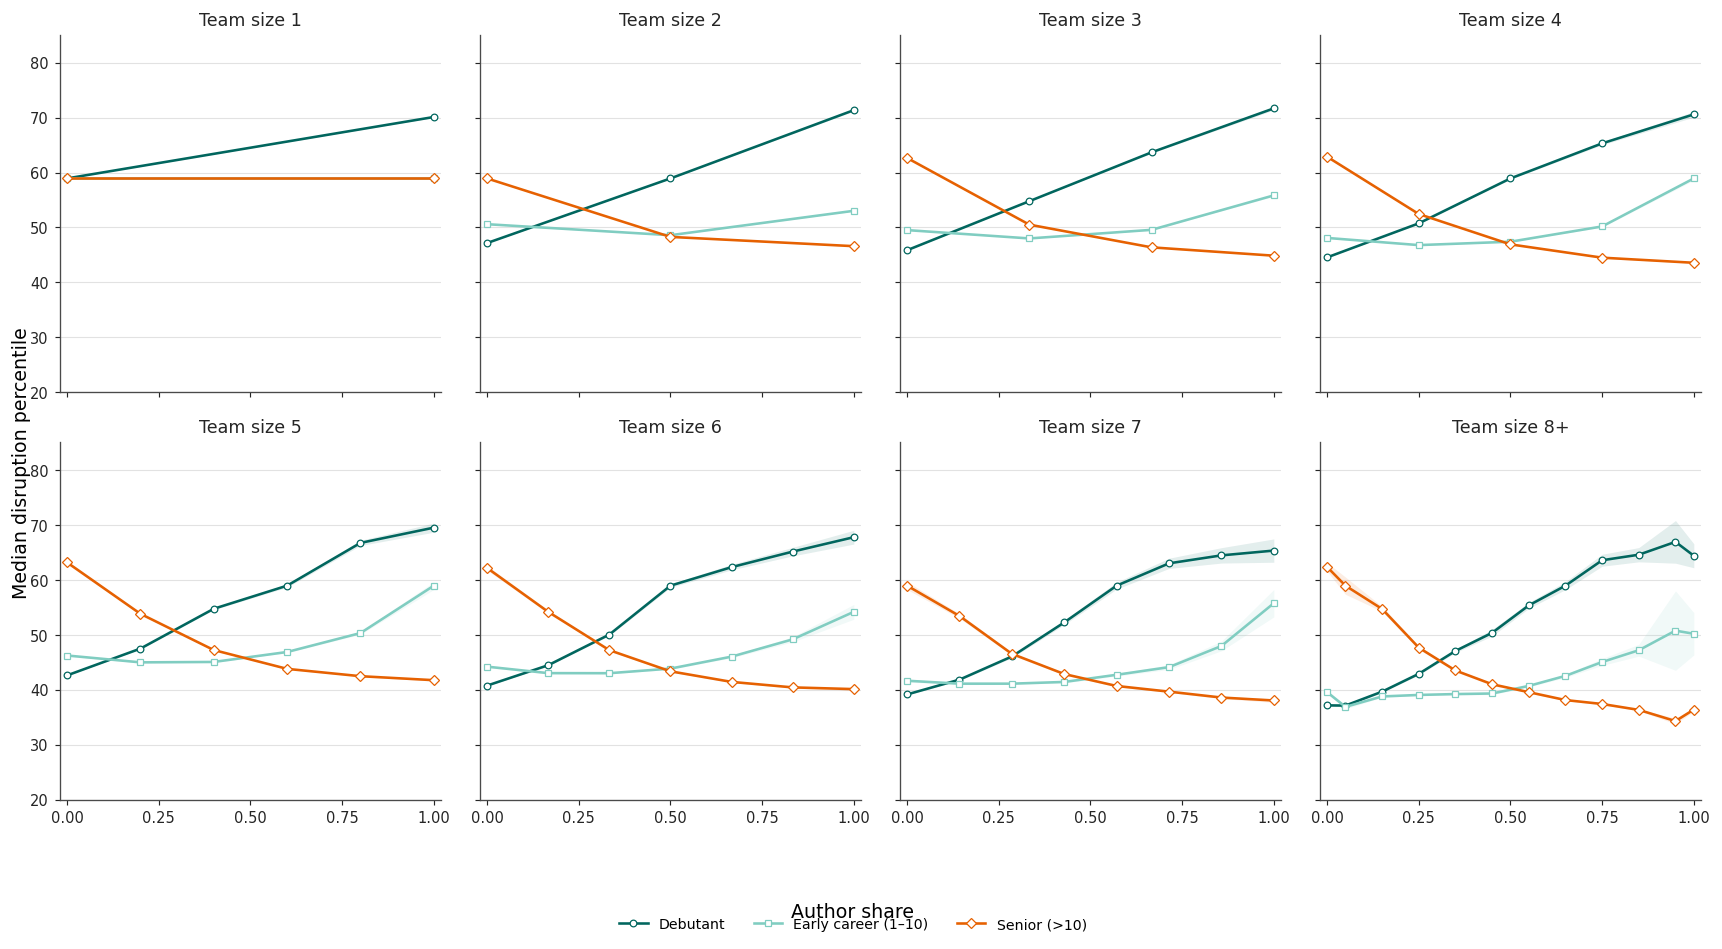

Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T70_legacy_plotpoint_Kendall_disruption_3stage.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T70_legacy_plotpoint_Kendall_disruption_3stage.tex


(WindowsPath('Reanalysis_Results_v9/tables/T70_legacy_plotpoint_Kendall_disruption_3stage.csv'),
 WindowsPath('Reanalysis_Results_v9/tables/T70_legacy_plotpoint_Kendall_disruption_3stage.tex'))

In [50]:
main01_stats = build_team_ratio_summary(
    "disruption_percentile",
    STAGE3,
    min_n=50,
)

display(main01_stats.head(20))

export_figure_data(
    main01_stats,
    "career_stage_disruption_by_team_size",
)

plot_team_ratio_grid(
    main01_stats,
    [label for _, label in STAGE3],
    ylabel="Median disruption percentile",
    stem="career_stage_disruption_by_team_size",
    ylim=(20, 85),
)

legacy_kendall_disruption_3stage = kendall_table_from_plot_summary(
    main01_stats,
    [label for _, label in STAGE3],
)

export_pub_table(
    legacy_kendall_disruption_3stage,
    "T70_legacy_plotpoint_Kendall_disruption_3stage",
)

## Debutant-share gradients across team-size categories

The older supplement grouped team sizes into 1--5, 6--10, 11--15, and 16--30
and plotted median disruption across 20 debutant-share bins. V9 reproduces that
descriptive calculation and saves the plotted statistics.

Saved figure data: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\FigureData_debutant_disruption_by_team_size_categories.csv
Saved figure: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\figures\debutant_disruption_by_team_size_categories.pdf


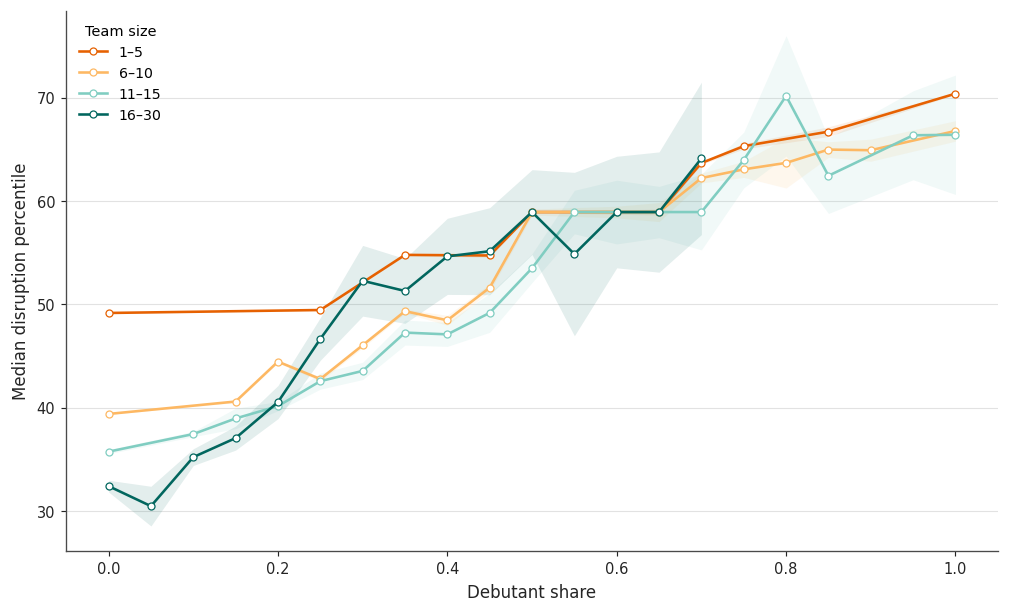

In [51]:
supp01_stats = (
    pl.scan_parquet(ANALYSIS_CACHE)
    .select([
        "team_size",
        "first_time_author_ratio",
        "disruption_percentile",
    ])
    .drop_nulls()
    .with_columns([
        pl.when(pl.col("team_size") <= 5)
          .then(pl.lit("1–5"))
        .when(pl.col("team_size") <= 10)
          .then(pl.lit("6–10"))
        .when(pl.col("team_size") <= 15)
          .then(pl.lit("11–15"))
        .when(pl.col("team_size") <= 30)
          .then(pl.lit("16–30"))
        .otherwise(None)
        .alias("team_category"),

        pl.when(pl.col("first_time_author_ratio") <= 0.001)
          .then(pl.lit(0.0))
        .otherwise(
            (
                pl.col("first_time_author_ratio")
                  .cast(pl.Float64)
                * 20
            )
            .ceil()
            / 20
        )
        .alias("x"),
    ])
    .drop_nulls(["team_category"])
    .group_by(["team_category", "x"])
    .agg([
        pl.len().alias("n"),
        pl.col("disruption_percentile")
          .median()
          .alias("median"),
        pl.col("disruption_percentile")
          .quantile(0.25)
          .alias("q25"),
        pl.col("disruption_percentile")
          .quantile(0.75)
          .alias("q75"),
    ])
    .filter(pl.col("n") >= 100)
    .with_columns(
        (
            1.57
            * (pl.col("q75") - pl.col("q25"))
            / pl.col("n").cast(pl.Float64).sqrt()
        ).alias("median_ci_halfwidth")
    )
    .with_columns([
        (
            pl.col("median")
            - pl.col("median_ci_halfwidth")
        ).alias("band_low"),
        (
            pl.col("median")
            + pl.col("median_ci_halfwidth")
        ).alias("band_high"),
    ])
    .collect()
    .to_pandas()
)

export_figure_data(
    supp01_stats,
    "debutant_disruption_by_team_size_categories",
)

fig, ax = plt.subplots(figsize=(8.5, 5.2))

team_order = ["1–5", "6–10", "11–15", "16–30"]
team_colors = {
    "1–5": DEBUT_QUARTILE_COLORS["0.00 - 0.25"],
    "6–10": DEBUT_QUARTILE_COLORS["0.25 - 0.50"],
    "11–15": DEBUT_QUARTILE_COLORS["0.50 - 0.75"],
    "16–30": DEBUT_QUARTILE_COLORS["0.75 - 1.00"],
}

for team_cat in team_order:
    g = (
        supp01_stats[
            supp01_stats["team_category"] == team_cat
        ]
        .sort_values("x")
    )

    if g.empty:
        continue

    color = team_colors[team_cat]

    ax.plot(
        g["x"],
        g["median"],
        marker="o",
        markerfacecolor="white",
        markeredgecolor=color,
        markeredgewidth=0.75,
        linewidth=1.55,
        color=color,
        label=team_cat,
    )

    ax.fill_between(
        g["x"],
        g["band_low"],
        g["band_high"],
        alpha=0.11,
        color=color,
        linewidth=0,
    )

apply_science_axes(ax)

ax.set_xlabel("Debutant share")
ax.set_ylabel("Median disruption percentile")
ax.legend(title="Team size")

plt.tight_layout()

save_pub_figure(
    fig,
    "debutant_disruption_by_team_size_categories",
)
plt.show()

## Debutant-share gradients across decades and team sizes

This reproduces the decade-by-team-size descriptive figure using the manuscript
decades 1941--1950, ..., 2011--2020.

Saved figure data: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\FigureData_debutant_disruption_by_decade.csv
Saved figure: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\figures\debutant_disruption_by_decade.pdf


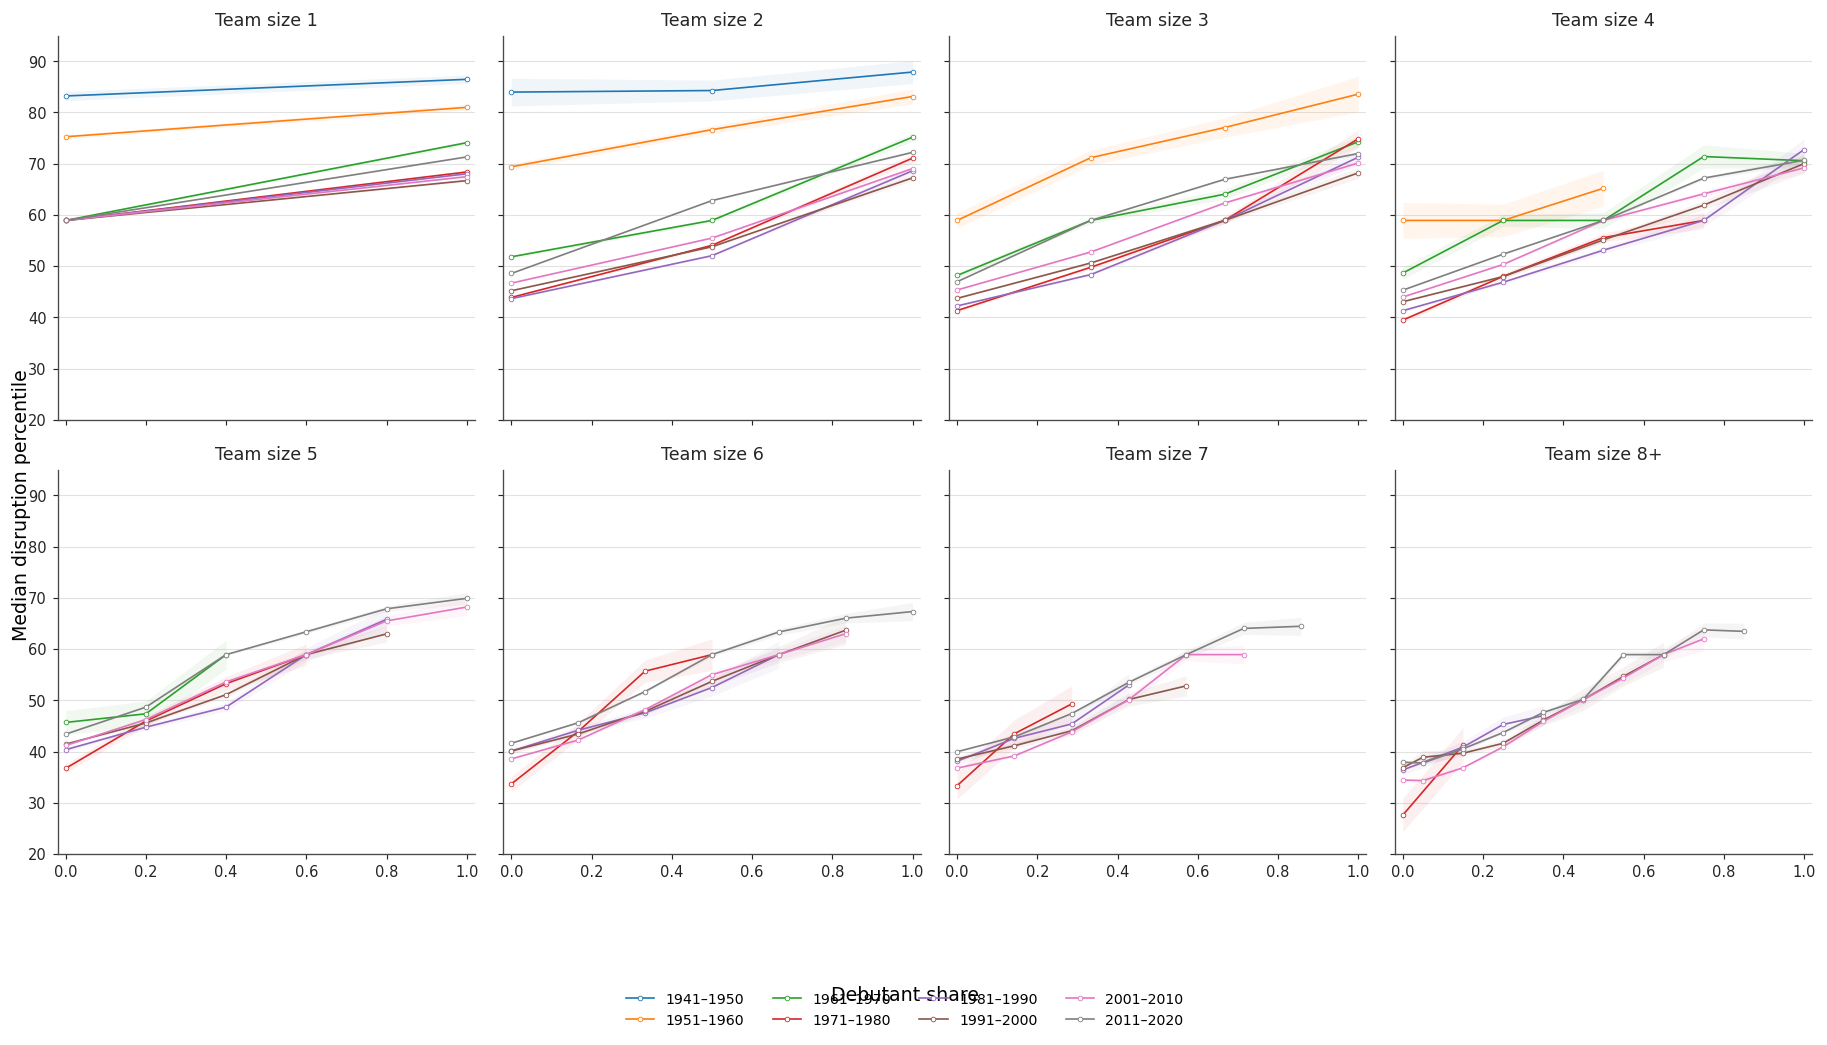

Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T71_legacy_decade_correlations_with_Kendall.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T71_legacy_decade_correlations_with_Kendall.tex


In [52]:
decade_plot_stats = (
    pl.scan_parquet(ANALYSIS_CACHE)
    .select([
        "year",
        "team_size",
        "first_time_author_ratio",
        "disruption_percentile",
    ])
    .drop_nulls()
    .with_columns([
        (
            ((pl.col("year") - 1) // 10) * 10 + 1
        ).alias("decade_start"),
        _team_group_expr(),
        _ratio_plot_x_expr("first_time_author_ratio"),
    ])
    .with_columns(
        (
            pl.col("decade_start").cast(pl.String)
            + pl.lit("–")
            + (pl.col("decade_start") + 9).cast(pl.String)
        ).alias("decade")
    )
    .group_by([
        "team_group",
        "decade",
        "x",
    ])
    .agg([
        pl.len().alias("n"),
        pl.col("disruption_percentile")
          .median()
          .alias("median"),
        pl.col("disruption_percentile")
          .quantile(0.25)
          .alias("q25"),
        pl.col("disruption_percentile")
          .quantile(0.75)
          .alias("q75"),
    ])
    .filter(pl.col("n") >= 1000)
    .with_columns(
        (
            1.57
            * (pl.col("q75") - pl.col("q25"))
            / pl.col("n").cast(pl.Float64).sqrt()
        ).alias("median_ci_halfwidth")
    )
    .with_columns([
        (
            pl.col("median")
            - pl.col("median_ci_halfwidth")
        ).alias("band_low"),
        (
            pl.col("median")
            + pl.col("median_ci_halfwidth")
        ).alias("band_high"),
    ])
    .collect()
    .to_pandas()
)

export_figure_data(
    decade_plot_stats,
    "debutant_disruption_by_decade",
)

fig, axes = plt.subplots(
    2,
    4,
    figsize=(15.5, 8.5),
    sharex=True,
    sharey=True,
)

axes = axes.ravel()
team_groups = [str(i) for i in range(1, 8)] + ["8+"]
decades = sorted(decade_plot_stats["decade"].unique())

# Categorical palette: deliberately not ordinal.
tab10 = list(plt.get_cmap("tab10").colors)
decade_colors = {
    decade: tab10[i % len(tab10)]
    for i, decade in enumerate(decades)
}

legend_handles = []
legend_labels = []

for ax, team_group in zip(axes, team_groups):
    sub = decade_plot_stats[
        decade_plot_stats["team_group"] == team_group
    ]

    for decade in decades:
        g = (
            sub[sub["decade"] == decade]
            .sort_values("x")
        )

        if g.empty:
            continue

        color = decade_colors[decade]

        line, = ax.plot(
            g["x"],
            g["median"],
            marker="o",
            markersize=2.8,
            markerfacecolor="white",
            markeredgecolor=color,
            markeredgewidth=0.5,
            linewidth=1.0,
            color=color,
            label=decade,
            zorder=3,
        )

        ax.fill_between(
            g["x"],
            g["band_low"],
            g["band_high"],
            color=color,
            alpha=0.07,
            linewidth=0,
            zorder=2,
        )

        if team_group == "1":
            legend_handles.append(line)
            legend_labels.append(decade)

    ax.set_title(
        f"Team size {team_group}"
        if team_group != "8+"
        else "Team size 8+"
    )
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(20, 95)
    apply_science_axes(ax)

fig.supxlabel("Debutant share")
fig.supylabel("Median disruption percentile")

fig.legend(
    legend_handles,
    legend_labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.025),
    ncol=4,
    frameon=False,
)

plt.tight_layout(rect=[0, 0.08, 1, 1])

save_pub_figure(
    fig,
    "debutant_disruption_by_decade",
)
plt.show()

# Full-paper decade correlations, including legacy Kendall tau.
if RUN_LEGACY_RAW_KENDALL:
    decade_raw_rows = []

    year_arr = A["year"]
    x_all = A["first_time_author_ratio"].astype(np.float64)
    y_all = A["disruption_percentile"].astype(np.float64)

    decade_ranges = [
        (1941, 1950),
        (1951, 1960),
        (1961, 1970),
        (1971, 1980),
        (1981, 1990),
        (1991, 2000),
        (2001, 2010),
        (2011, 2020),
    ]

    for lo, hi in decade_ranges:
        m = (
            (year_arr >= lo)
            & (year_arr <= hi)
            & np.isfinite(x_all)
            & np.isfinite(y_all)
        )

        xx = x_all[m]
        yy = y_all[m]

        pr = stats.pearsonr(xx, yy)
        sr = stats.spearmanr(xx, yy)
        kt = stats.kendalltau(xx, yy)

        decade_raw_rows.append({
            "decade": f"{lo}–{hi}",
            "n": len(xx),
            "pearson_r": pr.statistic,
            "pearson_p": pr.pvalue,
            "spearman_r": sr.statistic,
            "spearman_p": sr.pvalue,
            "kendall_tau": kt.statistic,
            "kendall_p": kt.pvalue,
        })

    decade_raw_corr = pd.DataFrame(decade_raw_rows)

    export_pub_table(
        decade_raw_corr,
        "T71_legacy_decade_correlations_with_Kendall",
    )

## Atypical knowledge-combination distributions

The earlier main ECDF is retained, but non-finite atypicality values are
excluded before plotting. To keep the PDF compact, the curve stores 2,000
order-statistic points per debutant-share quartile; each plotted point is an
exact empirical-CDF point from the complete finite sample.

Saved figure data: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\FigureData_atypicality_ecdf_by_debutant_share.csv
Saved figure: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\figures\atypicality_ecdf_by_debutant_share.pdf


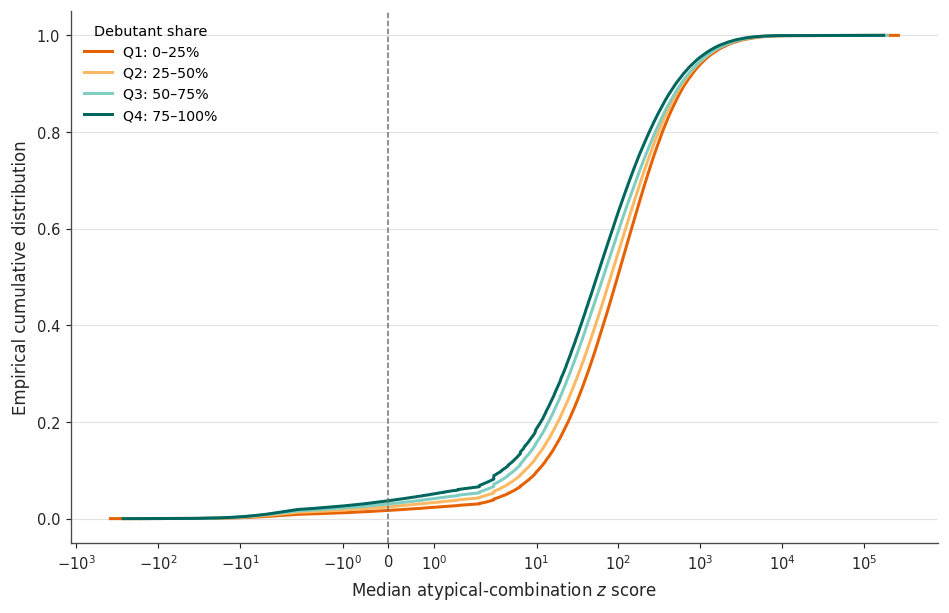

3013

In [53]:
atyp_ecdf_frame = (
    pl.read_parquet(
        ANALYSIS_CACHE,
        columns=[
            "first_time_author_ratio",
            "Atyp_Median_Z",
        ],
    )
    .filter(
        pl.col("first_time_author_ratio").is_not_null()
        & pl.col("Atyp_Median_Z").is_not_null()
        & pl.col("Atyp_Median_Z").is_finite()
    )
)

atyp_ratio = (
    atyp_ecdf_frame["first_time_author_ratio"]
    .to_numpy()
    .astype(np.float64)
)

atyp_value = (
    atyp_ecdf_frame["Atyp_Median_Z"]
    .to_numpy()
    .astype(np.float64)
)

quartile_id = np.digitize(
    atyp_ratio,
    [0.25, 0.50, 0.75],
    right=True,
)

quartile_labels = [
    "0.00–0.25",
    "0.25–0.50",
    "0.50–0.75",
    "0.75–1.00",
]

ecdf_rows = []

for q, label in enumerate(quartile_labels):
    vals = np.sort(
        atyp_value[quartile_id == q]
    )

    n = len(vals)

    if n == 0:
        continue

    idx = np.unique(
        np.linspace(
            0,
            n - 1,
            min(2000, n),
            dtype=np.int64,
        )
    )

    ecdf = (idx + 1) / n
    eps = np.sqrt(np.log(2 / 0.05) / (2 * n))

    ecdf_rows.append(
        pd.DataFrame({
            "beginner_group": label,
            "Atyp_Median_Z": vals[idx],
            "ecdf": ecdf,
            "group_n": n,
            "ci95_low": np.maximum(0.0, ecdf - eps),
            "ci95_high": np.minimum(1.0, ecdf + eps),
        })
    )

atyp_ecdf_curve = pd.concat(
    ecdf_rows,
    ignore_index=True,
)

export_figure_data(
    atyp_ecdf_curve,
    "atypicality_ecdf_by_debutant_share",
)

fig, ax = plt.subplots(figsize=(8.0, 5.2))

for label in quartile_labels:
    g = atyp_ecdf_curve[
        atyp_ecdf_curve["beginner_group"] == label
    ]

    color = DEBUT_QUARTILE_COLORS[label]

    ax.plot(
        g["Atyp_Median_Z"],
        g["ecdf"],
        color=color,
        linewidth=1.8,
        label=DEBUT_QUARTILE_DISPLAY[label],
    )

    ax.fill_between(
        g["Atyp_Median_Z"],
        g["ci95_low"],
        g["ci95_high"],
        color=color,
        alpha=0.09,
        linewidth=0,
    )

ax.set_xscale("symlog")
ax.axvline(
    0,
    color=COLORS["neutral"],
    linewidth=0.9,
    linestyle="--",
)
apply_science_axes(ax)

ax.set_xlabel("Median atypical-combination $z$ score")
ax.set_ylabel("Empirical cumulative distribution")
ax.legend(
    title="Debutant share",
    loc="best",
)

plt.tight_layout()

save_pub_figure(
    fig,
    "atypicality_ecdf_by_debutant_share",
)
plt.show()

del atyp_ecdf_frame, atyp_ratio, atyp_value, quartile_id
gc.collect()

## Career-stage composition heatmaps

These reproduce the visually useful collaborator-composition heatmaps. The
atypicality version uses the finite-only atypicality percentile; lower values
mean more atypical combinations.

Saved figure data: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\FigureData_career_stage_disruption_heatmaps.csv


C:\Users\Raiyan Abdul Baten\AppData\Local\Temp\ipykernel_2472\3275861038.py:425: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.04, 1, 1])


Saved figure: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\figures\career_stage_disruption_heatmaps.pdf


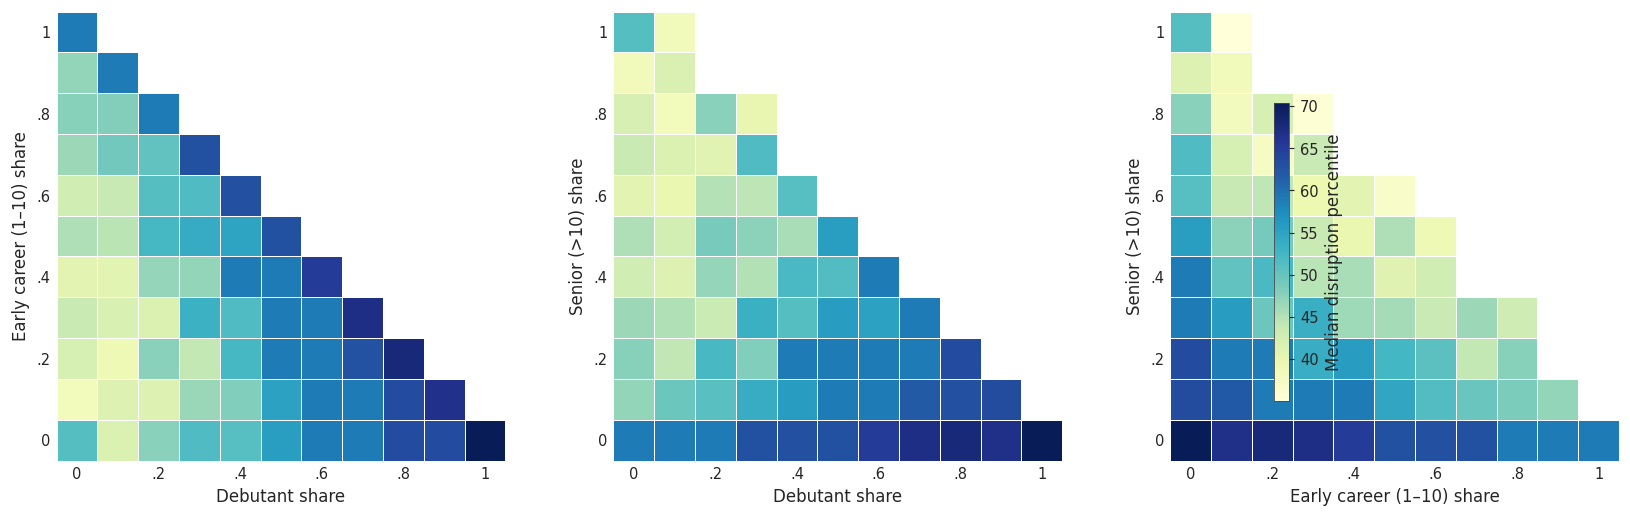

Saved figure data: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\FigureData_career_stage_atypicality_heatmaps.csv


C:\Users\Raiyan Abdul Baten\AppData\Local\Temp\ipykernel_2472\3275861038.py:425: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.04, 1, 1])


Saved figure: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\figures\career_stage_atypicality_heatmaps.pdf


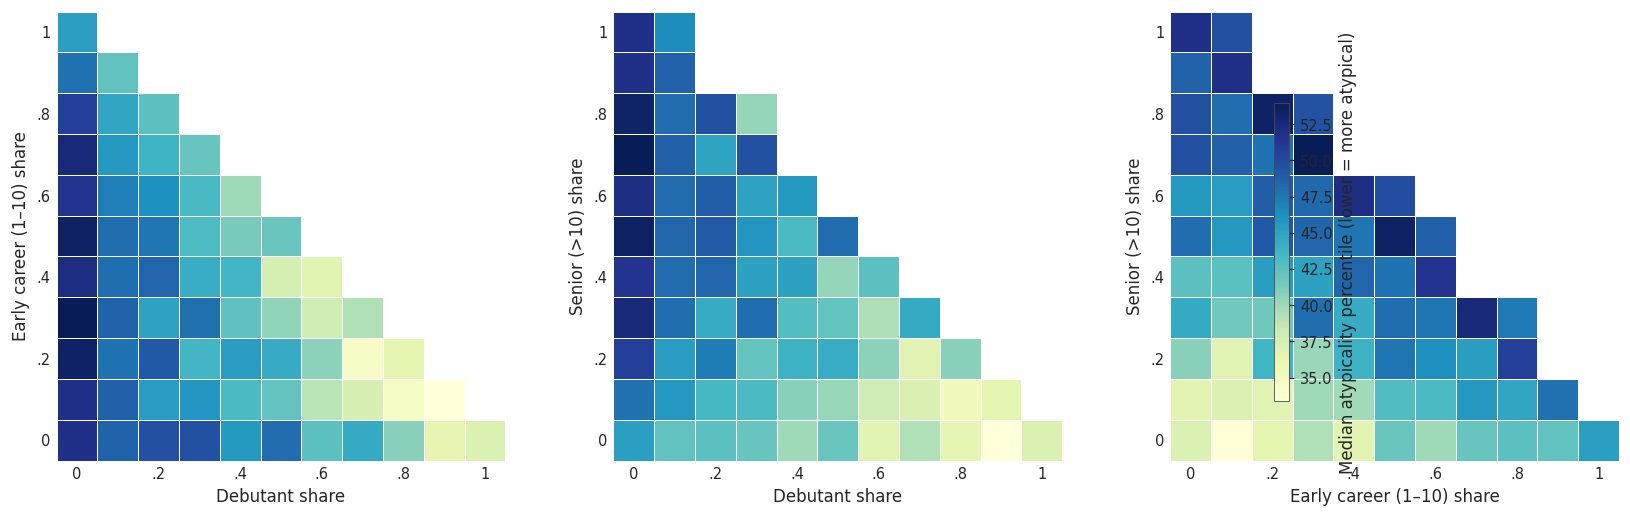

Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T72_heatmap_cells_disruption_3stage.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T72_heatmap_cells_disruption_3stage.tex
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T73_heatmap_cells_atypicality_3stage.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T73_heatmap_cells_atypicality_3stage.tex


(WindowsPath('Reanalysis_Results_v9/tables/T73_heatmap_cells_atypicality_3stage.csv'),
 WindowsPath('Reanalysis_Results_v9/tables/T73_heatmap_cells_atypicality_3stage.tex'))

In [54]:
heatmap_disruption_3 = build_pair_heatmap_data(
    "disruption_percentile",
    STAGE3,
    min_n=100,
)

export_figure_data(
    heatmap_disruption_3,
    "career_stage_disruption_heatmaps",
)

plot_pair_heatmaps(
    heatmap_disruption_3,
    stem="career_stage_disruption_heatmaps",
    colorbar_label="Median disruption percentile",
    annotate=False,
)

heatmap_atyp_3 = build_pair_heatmap_data(
    "Atyp_Median_Z_percentile",
    STAGE3,
    min_n=100,
)

export_figure_data(
    heatmap_atyp_3,
    "career_stage_atypicality_heatmaps",
)

plot_pair_heatmaps(
    heatmap_atyp_3,
    stem="career_stage_atypicality_heatmaps",
    colorbar_label=(
        "Median atypicality percentile "
        "(lower = more atypical)"
    ),
    annotate=False,
)

export_pub_table(
    heatmap_disruption_3,
    "T72_heatmap_cells_disruption_3stage",
)

export_pub_table(
    heatmap_atyp_3,
    "T73_heatmap_cells_atypicality_3stage",
)

## Recurring exact team compositions

Exact team compositions are defined by counts of debutant, early-career, and
senior authors. The figure retains compositions observed in at least 10,000
papers and orders them by median disruption percentile.

Saved figure data: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\FigureData_top_team_compositions.csv


C:\Users\Raiyan Abdul Baten\AppData\Local\Temp\ipykernel_2472\1937412018.py:115: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\Raiyan Abdul Baten\AppData\Local\Temp\ipykernel_2472\2378071161.py:184: UserWarning: Glyph 127793 (\N{SEEDLING}) missing from font(s) DejaVu Sans.
  fig.savefig(
C:\Users\Raiyan Abdul Baten\AppData\Local\Temp\ipykernel_2472\2378071161.py:184: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  fig.savefig(
C:\Users\Raiyan Abdul Baten\AppData\Local\Temp\ipykernel_2472\2378071161.py:184: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.savefig(
C:\anaconda\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 127793 (\N{SEEDLING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\anaconda\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128640 (\N{ROCKET

Saved figure: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\figures\top_team_compositions.pdf


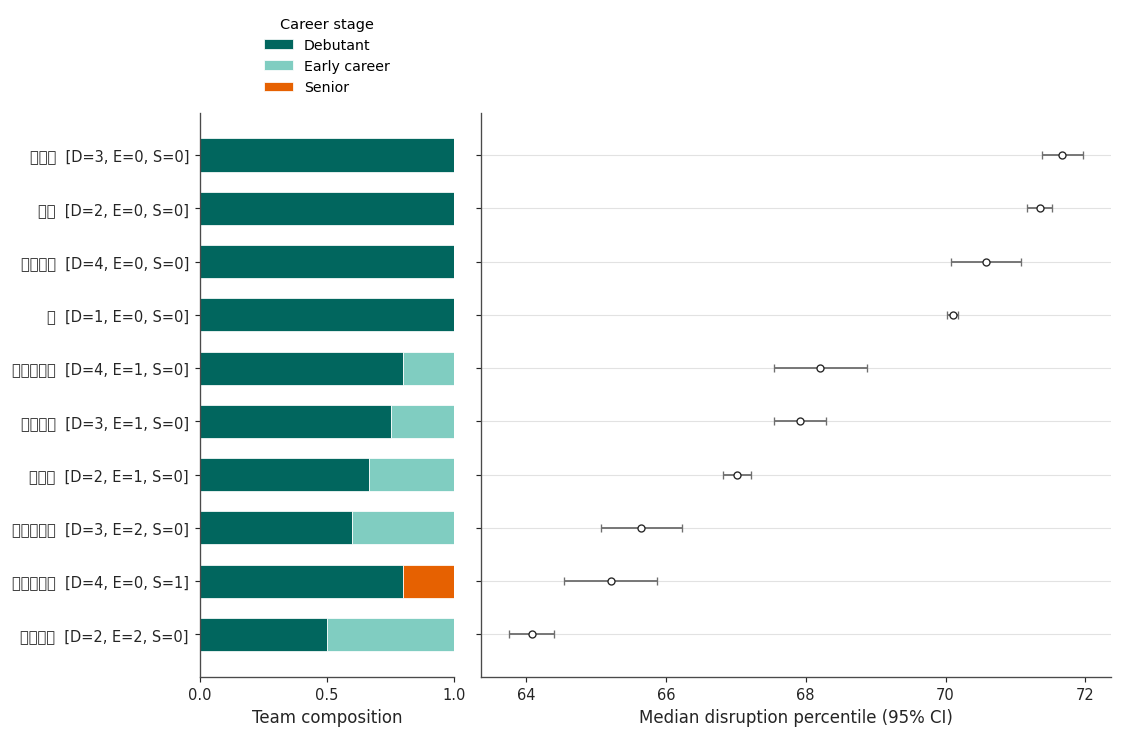

In [55]:
top_team_plot = composition.head(10).copy()

def composition_label(row):
    d = int(row["first_time_author_count"])
    e = int(row["early_career_author_count_main"])
    s = int(row["senior_author_count"])

    emoji = (
        "🌱" * d
        + "🚀" * e
        + "🧠" * s
    )

    return (
        f"{emoji}  [D={d}, E={e}, S={s}]"
    )

top_team_plot["composition_label"] = top_team_plot.apply(
    composition_label,
    axis=1,
)

top_team_plot["p_debut"] = (
    top_team_plot["first_time_author_count"]
    / top_team_plot["team_size_from_counts"]
)
top_team_plot["p_early"] = (
    top_team_plot["early_career_author_count_main"]
    / top_team_plot["team_size_from_counts"]
)
top_team_plot["p_senior"] = (
    top_team_plot["senior_author_count"]
    / top_team_plot["team_size_from_counts"]
)

export_figure_data(
    top_team_plot,
    "top_team_compositions",
)

fig = plt.figure(figsize=(9.8, 6.1))
gs = fig.add_gridspec(
    1,
    2,
    width_ratios=[1.15, 2.85],
    wspace=0.06,
)

ax_comp = fig.add_subplot(gs[0, 0])
ax_eff = fig.add_subplot(gs[0, 1], sharey=ax_comp)

y = np.arange(len(top_team_plot))
left = np.zeros(len(top_team_plot))

for col, label, color in [
    ("p_debut", "Debutant", CAREER3_COLORS["Debutant"]),
    ("p_early", "Early career", CAREER3_COLORS["Early career (1–10)"]),
    ("p_senior", "Senior", CAREER3_COLORS["Senior (>10)"]),
]:
    vals = top_team_plot[col].to_numpy(float)

    ax_comp.barh(
        y,
        vals,
        left=left,
        height=0.62,
        color=color,
        edgecolor="white",
        linewidth=0.45,
        label=label,
    )

    left += vals

ax_eff.errorbar(
    top_team_plot["median"],
    y,
    xerr=[
        top_team_plot["median"] - top_team_plot["median_ci95_low"],
        top_team_plot["median_ci95_high"] - top_team_plot["median"],
    ],
    fmt="o",
    color=COLORS["text"],
    ecolor=COLORS["neutral"],
    markerfacecolor="white",
    markeredgecolor=COLORS["text"],
    markeredgewidth=0.8,
    elinewidth=1.1,
    capsize=2.5,
)

ax_comp.set_yticks(y)
ax_comp.set_yticklabels(
    top_team_plot["composition_label"]
)
ax_comp.invert_yaxis()

ax_comp.set_xlim(0, 1)
ax_comp.set_xticks([0, .5, 1])
ax_comp.set_xlabel("Team composition")

ax_eff.set_xlabel("Median disruption percentile (95% CI)")
ax_eff.tick_params(labelleft=False)

apply_science_axes(ax_comp, grid=None)
apply_science_axes(ax_eff)

ax_comp.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=1,
    title="Career stage",
)

plt.tight_layout()

save_pub_figure(
    fig,
    "top_team_compositions",
)
plt.show()

## 13.8 Team-size grids for atypicality and reference use

These reproduce the earlier supplementary career-stage grids for atypical
combination percentile and average reference-popularity percentile. The
reference-age plot-point Kendall table is also exported even though reference
age is not emphasized in the revised narrative.

Saved figure data: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\FigureData_atypicality_by_career_stage_and_team_size.csv
Saved figure: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\figures\atypicality_by_career_stage_and_team_size.pdf


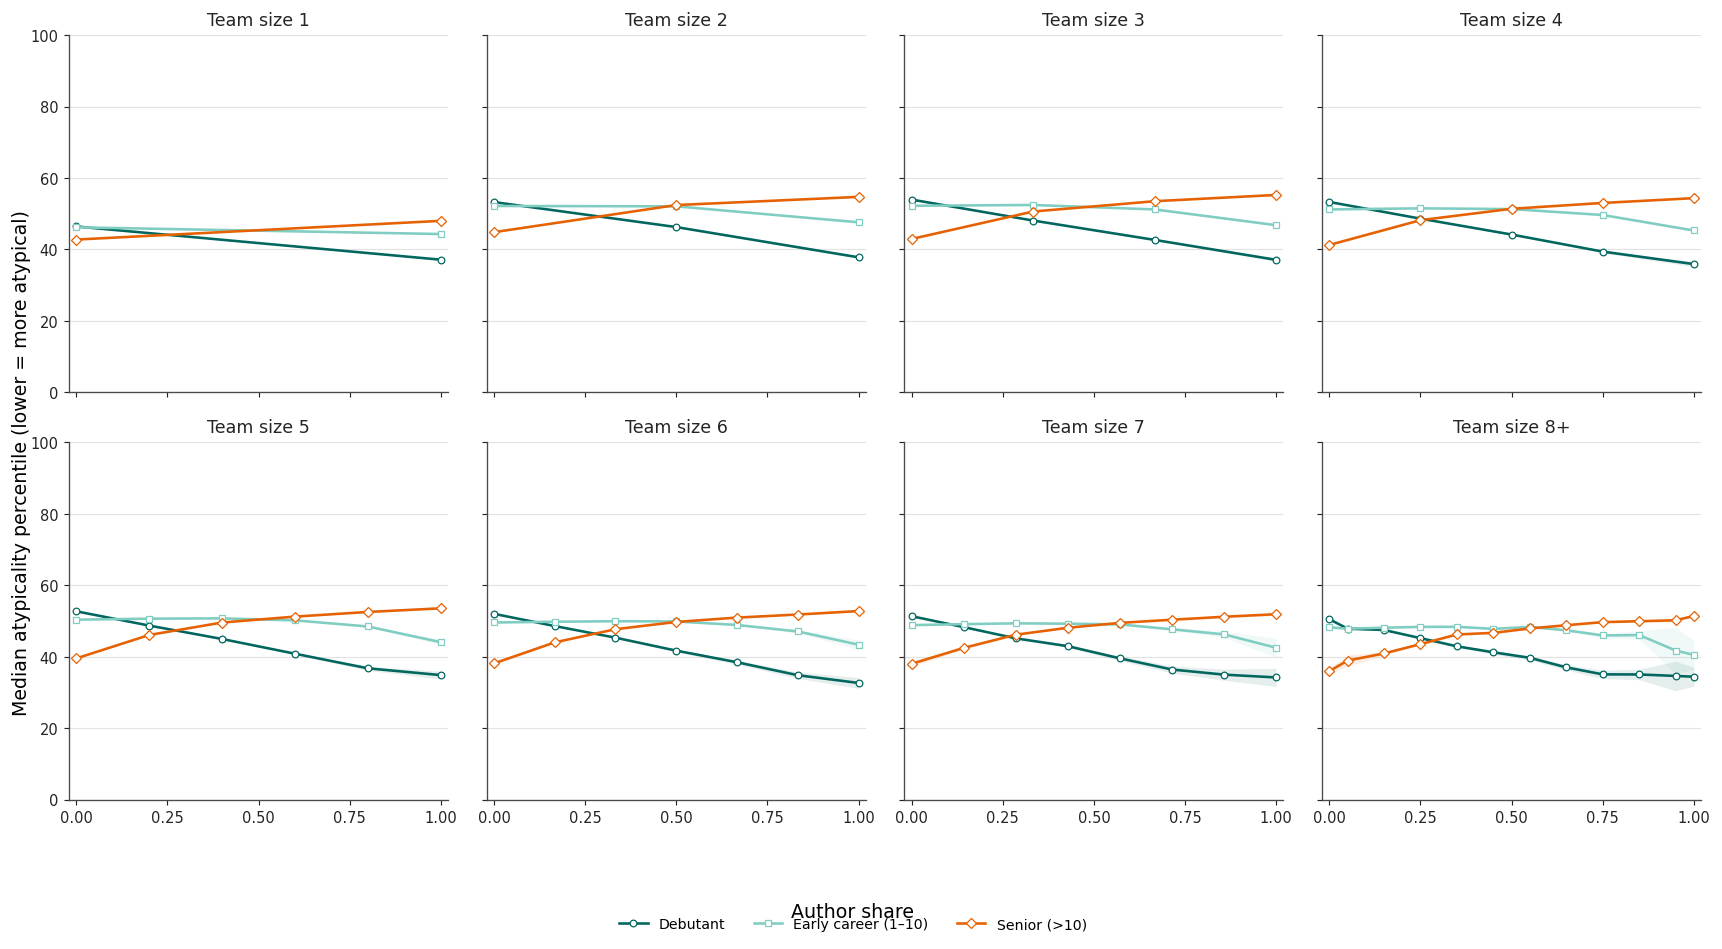

Saved figure data: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\FigureData_reference_popularity_by_career_stage_and_team_size.csv
Saved figure: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\figures\reference_popularity_by_career_stage_and_team_size.pdf


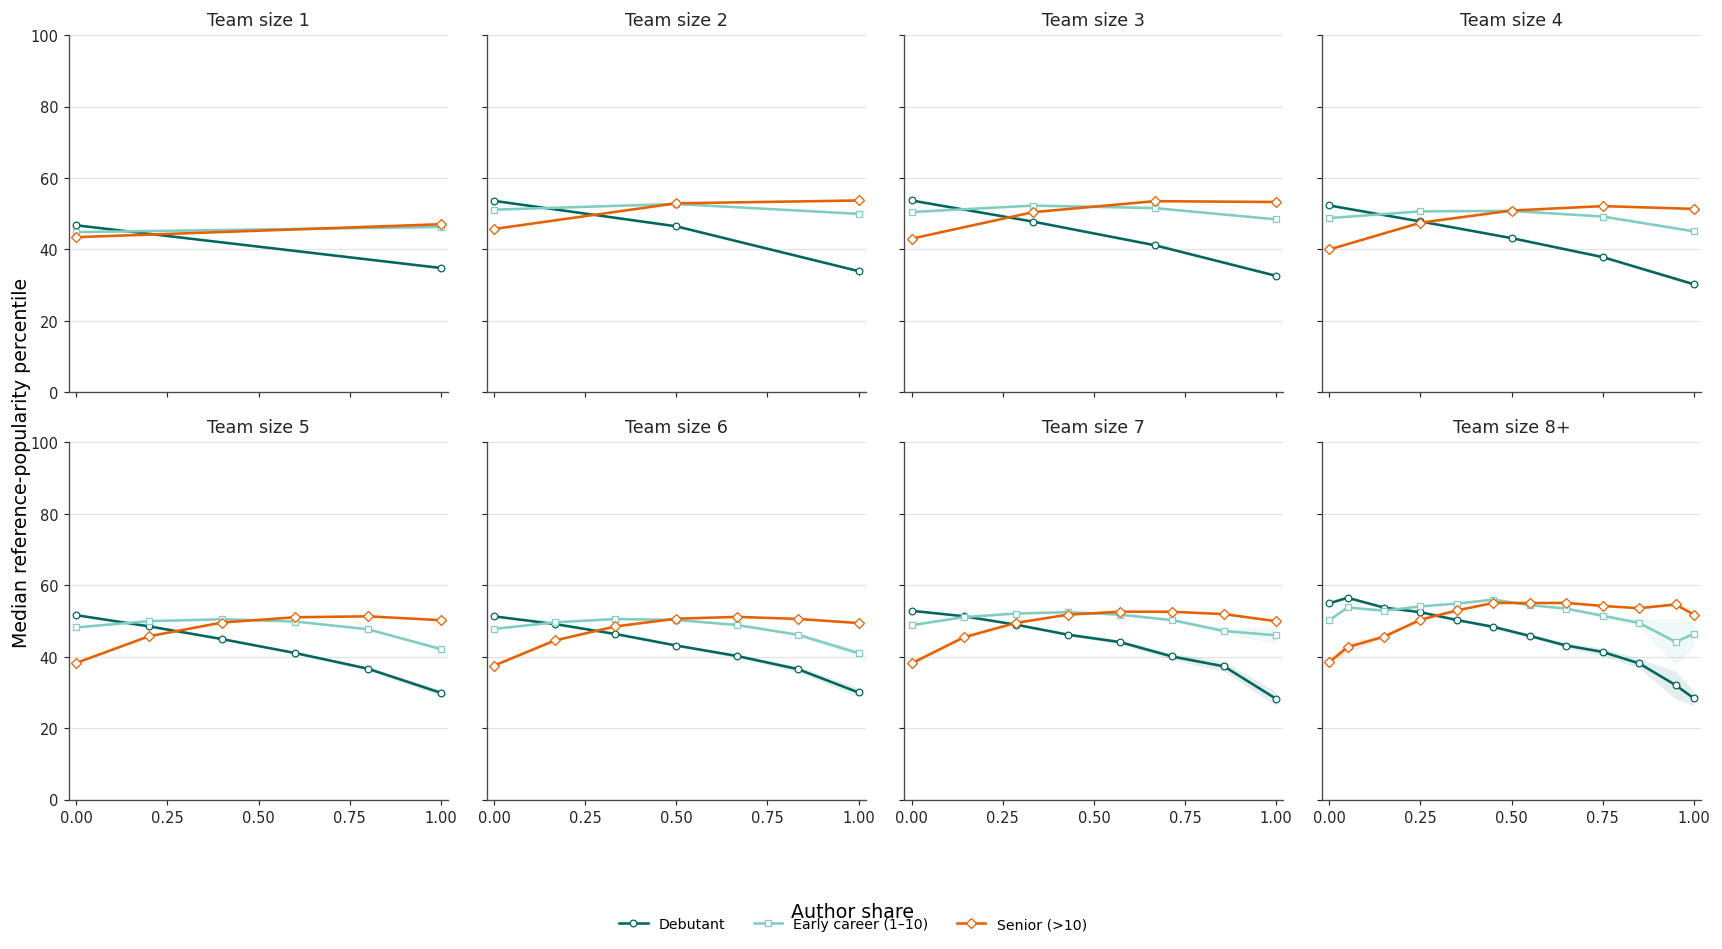

Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T74_legacy_plotpoint_Kendall_reference_popularity.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T74_legacy_plotpoint_Kendall_reference_popularity.tex
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T75_legacy_plotpoint_Kendall_reference_age.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T75_legacy_plotpoint_Kendall_reference_age.tex


(WindowsPath('Reanalysis_Results_v9/tables/T75_legacy_plotpoint_Kendall_reference_age.csv'),
 WindowsPath('Reanalysis_Results_v9/tables/T75_legacy_plotpoint_Kendall_reference_age.tex'))

In [56]:
supp04_atyp_stats = build_team_ratio_summary(
    "Atyp_Median_Z_percentile",
    STAGE3,
    min_n=50,
)

export_figure_data(
    supp04_atyp_stats,
    "atypicality_by_career_stage_and_team_size",
)

plot_team_ratio_grid(
    supp04_atyp_stats,
    [label for _, label in STAGE3],
    ylabel=(
        "Median atypicality percentile "
        "(lower = more atypical)"
    ),
    stem="atypicality_by_career_stage_and_team_size",
    ylim=(0, 100),
)

supp05_refpop_stats = build_team_ratio_summary(
    "avg_reference_popularity_percentile",
    STAGE3,
    min_n=50,
)

export_figure_data(
    supp05_refpop_stats,
    "reference_popularity_by_career_stage_and_team_size",
)

plot_team_ratio_grid(
    supp05_refpop_stats,
    [label for _, label in STAGE3],
    ylabel="Median reference-popularity percentile",
    stem="reference_popularity_by_career_stage_and_team_size",
    ylim=(0, 100),
)

legacy_kendall_refpop = kendall_table_from_plot_summary(
    supp05_refpop_stats,
    [label for _, label in STAGE3],
)

export_pub_table(
    legacy_kendall_refpop,
    "T74_legacy_plotpoint_Kendall_reference_popularity",
)

reference_age_stats = build_team_ratio_summary(
    "avg_reference_age_percentile",
    STAGE3,
    min_n=50,
)

legacy_kendall_refage = kendall_table_from_plot_summary(
    reference_age_stats,
    [label for _, label in STAGE3],
)

export_pub_table(
    legacy_kendall_refage,
    "T75_legacy_plotpoint_Kendall_reference_age",
)

## 13.9 Debutant share across collaborators' prior-disruption strata

This reproduces the earlier collaborator-history grid as a descriptive figure.
The revised inferential result is the stage-specific interaction model reported
earlier in the notebook.

Saved figure data: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\FigureData_debutant_disruption_by_collaborator_history_and_team_size.csv
Saved figure: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\figures\debutant_disruption_by_collaborator_history_and_team_size.pdf


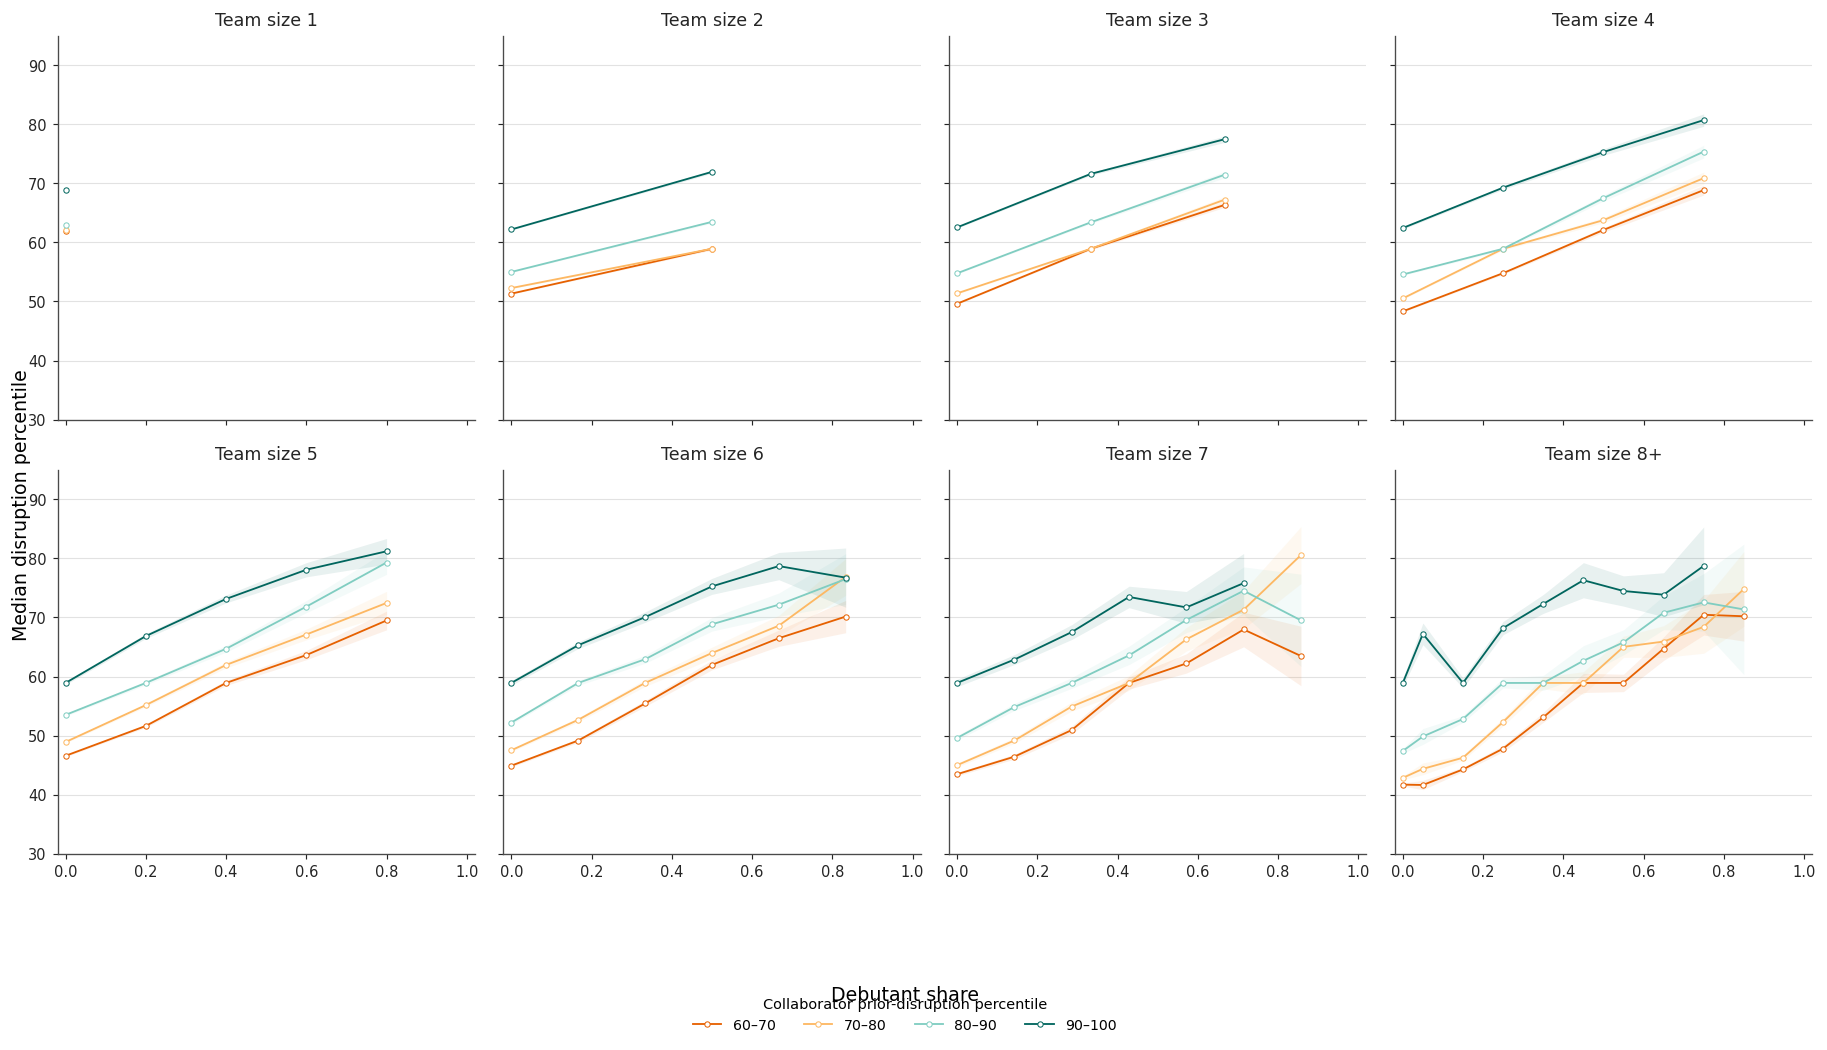

In [57]:
supp08_stats = (
    pl.scan_parquet(ANALYSIS_CACHE)
    .select([
        "team_size",
        "first_time_author_ratio",
        "avg_disruption_percentile",
        "disruption_percentile",
    ])
    .drop_nulls()
    .filter(
        pl.col("avg_disruption_percentile") >= 60
    )
    .with_columns([
        _team_group_expr(),
        _ratio_plot_x_expr("first_time_author_ratio"),

        pl.when(pl.col("avg_disruption_percentile") < 70)
          .then(pl.lit("60–70"))
        .when(pl.col("avg_disruption_percentile") < 80)
          .then(pl.lit("70–80"))
        .when(pl.col("avg_disruption_percentile") < 90)
          .then(pl.lit("80–90"))
        .otherwise(pl.lit("90–100"))
        .alias("collaborator_prior_disruption_group"),
    ])
    .group_by([
        "team_group",
        "collaborator_prior_disruption_group",
        "x",
    ])
    .agg([
        pl.len().alias("n"),
        pl.col("disruption_percentile")
          .median()
          .alias("median"),
        pl.col("disruption_percentile")
          .quantile(0.25)
          .alias("q25"),
        pl.col("disruption_percentile")
          .quantile(0.75)
          .alias("q75"),
    ])
    .filter(pl.col("n") >= 50)
    .with_columns(
        (
            1.57
            * (pl.col("q75") - pl.col("q25"))
            / pl.col("n").cast(pl.Float64).sqrt()
        ).alias("median_ci_halfwidth")
    )
    .with_columns([
        (
            pl.col("median")
            - pl.col("median_ci_halfwidth")
        ).alias("ci95_low"),
        (
            pl.col("median")
            + pl.col("median_ci_halfwidth")
        ).alias("ci95_high"),
    ])
    .collect()
    .to_pandas()
)

# Explicit runtime guard against the exact v7 failure.
required_ci_cols = {"ci95_low", "ci95_high"}
missing_ci_cols = required_ci_cols - set(supp08_stats.columns)
if missing_ci_cols:
    raise RuntimeError(
        "Collaborator-history figure is missing CI columns: "
        f"{sorted(missing_ci_cols)}"
    )

export_figure_data(
    supp08_stats,
    "debutant_disruption_by_collaborator_history_and_team_size",
)

fig, axes = plt.subplots(
    2,
    4,
    figsize=(15.5, 8.5),
    sharex=True,
    sharey=True,
)

axes = axes.ravel()

team_groups = [str(i) for i in range(1, 8)] + ["8+"]
history_groups = ["60–70", "70–80", "80–90", "90–100"]

history_colors = {
    "60–70": DEBUT_QUARTILE_COLORS["0.00 - 0.25"],
    "70–80": DEBUT_QUARTILE_COLORS["0.25 - 0.50"],
    "80–90": DEBUT_QUARTILE_COLORS["0.50 - 0.75"],
    "90–100": DEBUT_QUARTILE_COLORS["0.75 - 1.00"],
}

legend_handles = []
legend_labels = []

for ax, team_group in zip(axes, team_groups):
    sub = supp08_stats[
        supp08_stats["team_group"] == team_group
    ]

    for hist in history_groups:
        g = (
            sub[
                sub["collaborator_prior_disruption_group"] == hist
            ]
            .sort_values("x")
        )

        if g.empty:
            continue

        color = history_colors[hist]

        line, = ax.plot(
            g["x"],
            g["median"],
            color=color,
            marker="o",
            markersize=3.2,
            markerfacecolor="white",
            markeredgecolor=color,
            markeredgewidth=0.6,
            linewidth=1.1,
            label=hist,
            zorder=3,
        )

        ax.fill_between(
            g["x"],
            g["ci95_low"],
            g["ci95_high"],
            color=color,
            alpha=0.09,
            linewidth=0,
            zorder=2,
        )

        if team_group == "1":
            legend_handles.append(line)
            legend_labels.append(hist)

    ax.set_title(
        f"Team size {team_group}"
        if team_group != "8+"
        else "Team size 8+"
    )
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(30, 95)
    apply_science_axes(ax)

fig.supxlabel("Debutant share")
fig.supylabel("Median disruption percentile")

fig.legend(
    legend_handles,
    legend_labels,
    title="Collaborator prior-disruption percentile",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.03),
    ncol=4,
    frameon=False,
)

plt.tight_layout(rect=[0, 0.08, 1, 1])

save_pub_figure(
    fig,
    "debutant_disruption_by_collaborator_history_and_team_size",
)
plt.show()

## 13.10 Complete-window citation figures

The earlier citation supplement is regenerated with a complete 10-year window.

- The career-stage grid uses within-year \(C_{10}\) percentiles for papers
  through 2010.
- The non-overlapping disruption-band figure uses raw \(C_{10}\) counts through
  2010 and reports each beginner-share quartile's contribution to the global
  10-year citation total.

This preserves the visual questions while removing unequal citation windows.

Saved figure data: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\FigureData_c10_by_career_stage_and_team_size.csv
Saved figure: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\figures\c10_by_career_stage_and_team_size.pdf


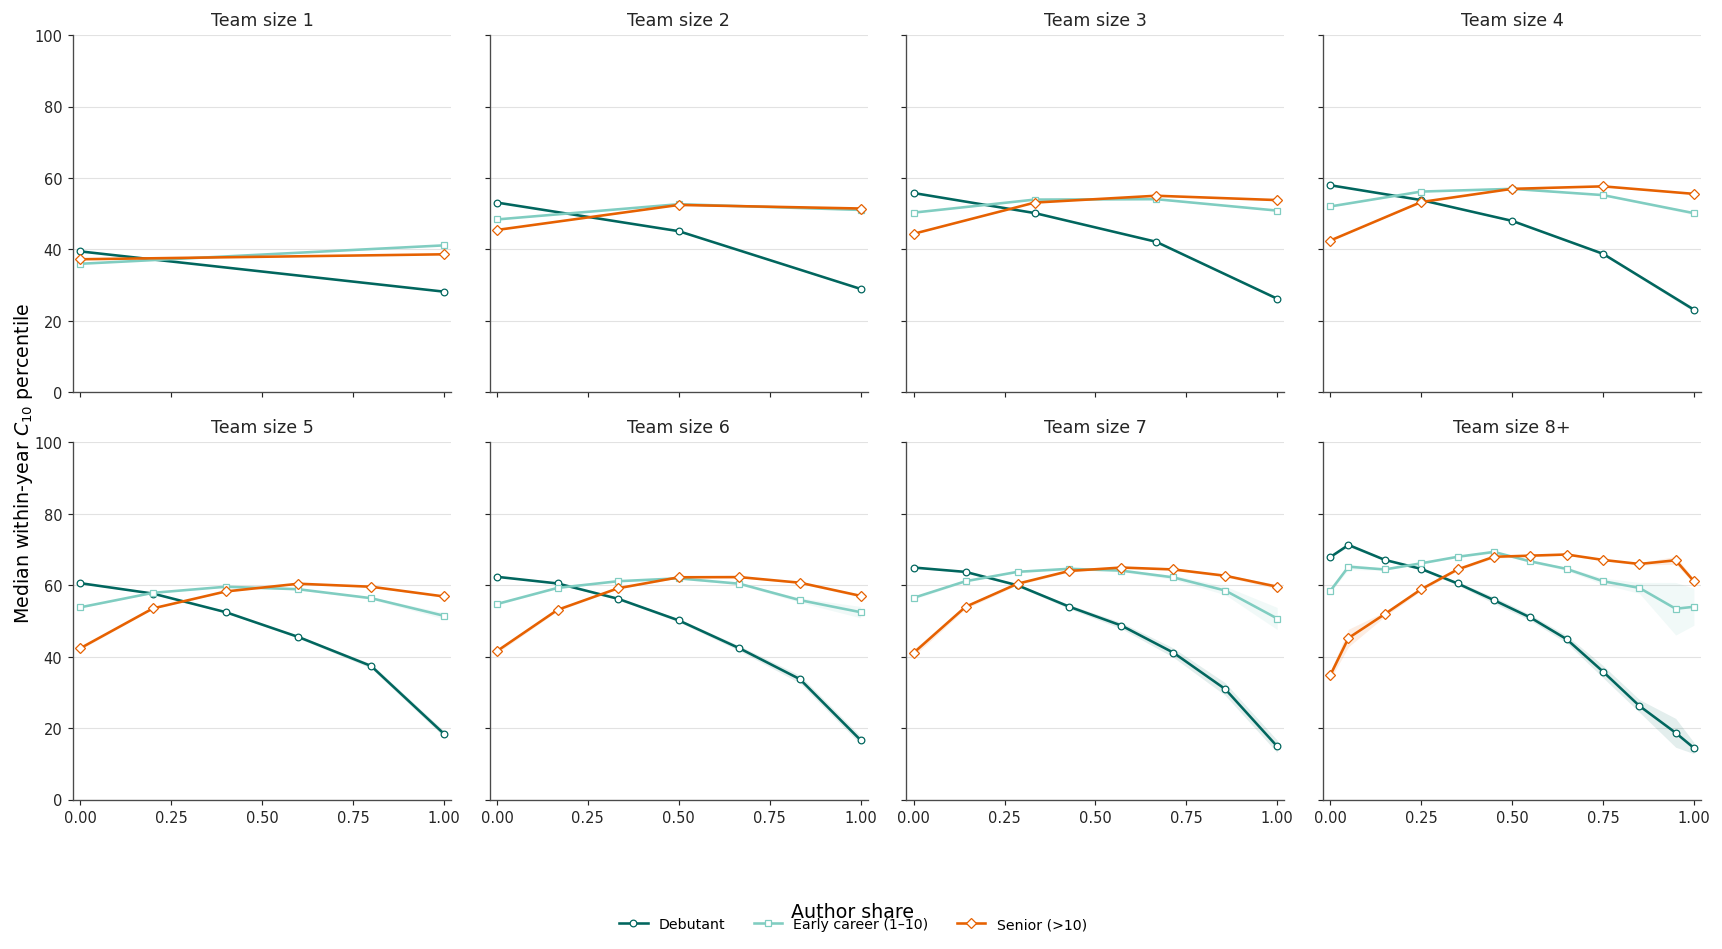

Saved figure data: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\FigureData_c10_share_by_nonoverlapping_disruption_band.csv
Saved figure: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\figures\c10_share_by_nonoverlapping_disruption_band.pdf


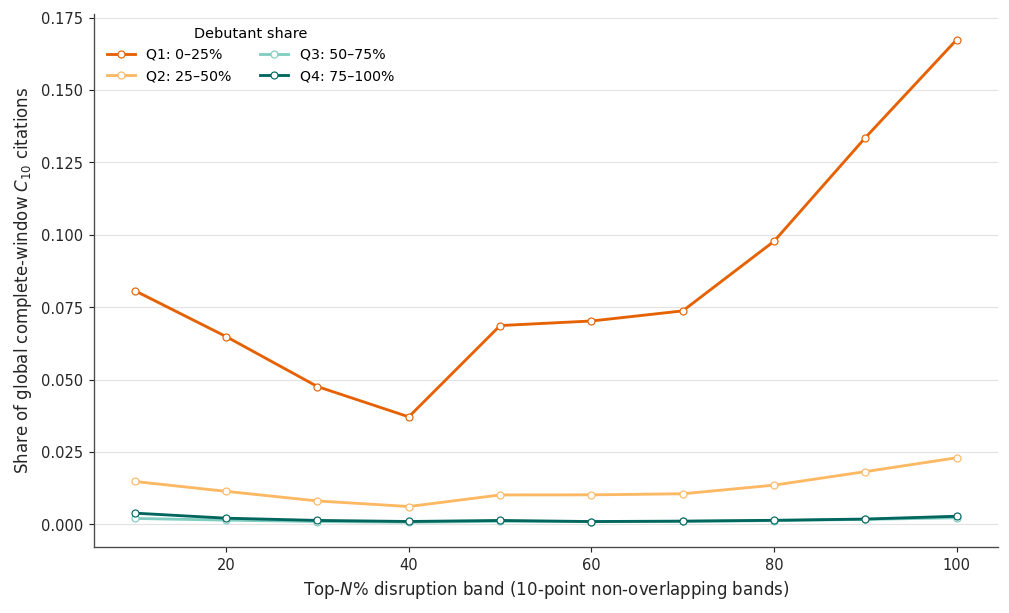

In [58]:
supp09_c10_stats = build_team_ratio_summary(
    "C10_percentile_within_year",
    STAGE3,
    min_n=50,
    filter_expr=(pl.col("year") <= C10_COMPLETE_THROUGH),
)

export_figure_data(
    supp09_c10_stats,
    "c10_by_career_stage_and_team_size",
)

plot_team_ratio_grid(
    supp09_c10_stats,
    [label for _, label in STAGE3],
    ylabel="Median within-year $C_{10}$ percentile",
    stem="c10_by_career_stage_and_team_size",
    ylim=(0, 100),
)

citation_band_source = (
    pl.scan_parquet(ANALYSIS_CACHE)
    .select([
        "year",
        "disruption_percentile",
        "C10",
        "first_time_author_ratio",
    ])
    .filter(
        (pl.col("year") <= C10_COMPLETE_THROUGH)
        & pl.col("disruption_percentile").is_not_null()
        & pl.col("C10").is_not_null()
        & pl.col("first_time_author_ratio").is_not_null()
    )
    .with_columns([
        (
            (
                (100 - pl.col("disruption_percentile"))
                / 10
            )
            .ceil()
            * 10
        )
        .clip(10, 100)
        .cast(pl.Int16)
        .alias("top_band_N"),

        pl.when(pl.col("first_time_author_ratio") <= 0.25)
          .then(pl.lit("0.00–0.25"))
        .when(pl.col("first_time_author_ratio") <= 0.50)
          .then(pl.lit("0.25–0.50"))
        .when(pl.col("first_time_author_ratio") <= 0.75)
          .then(pl.lit("0.50–0.75"))
        .otherwise(pl.lit("0.75–1.00"))
        .alias("beginner_group"),
    ])
)

global_c10_total = (
    citation_band_source
    .select(
        pl.col("C10").sum().alias("total_C10")
    )
    .collect()
    .item()
)

citation_band_share = (
    citation_band_source
    .group_by([
        "top_band_N",
        "beginner_group",
    ])
    .agg([
        pl.len().alias("n_papers"),
        pl.col("C10").sum().alias("C10_in_band"),
        pl.col("C10").std().alias("C10_sd"),
    ])
    .with_columns([
        (
            pl.col("C10_in_band")
            / pl.lit(float(global_c10_total))
        ).alias("global_C10_share"),
        (
            pl.col("C10_sd")
            * pl.col("n_papers").cast(pl.Float64).sqrt()
            / pl.lit(float(global_c10_total))
        ).alias("global_C10_share_se"),
    ])
    .with_columns([
        (
            pl.col("global_C10_share")
            - 1.96 * pl.col("global_C10_share_se")
        ).clip(0, 1).alias("ci95_low"),
        (
            pl.col("global_C10_share")
            + 1.96 * pl.col("global_C10_share_se")
        ).clip(0, 1).alias("ci95_high"),
    ])
    .sort([
        "top_band_N",
        "beginner_group",
    ])
    .collect()
    .to_pandas()
)

export_figure_data(
    citation_band_share,
    "c10_share_by_nonoverlapping_disruption_band",
)

fig, ax = plt.subplots(figsize=(8.5, 5.2))

for group_name, g in citation_band_share.groupby(
    "beginner_group",
    sort=True,
):
    color = DEBUT_QUARTILE_COLORS[group_name]

    ax.plot(
        g["top_band_N"],
        g["global_C10_share"],
        color=color,
        marker="o",
        markerfacecolor="white",
        markeredgecolor=color,
        markeredgewidth=0.7,
        linewidth=1.7,
        label=DEBUT_QUARTILE_DISPLAY[group_name],
    )

    ax.fill_between(
        g["top_band_N"],
        g["ci95_low"],
        g["ci95_high"],
        color=color,
        alpha=0.10,
        linewidth=0,
    )

apply_science_axes(ax)

ax.set_xlabel(
    "Top-$N$% disruption band "
    "(10-point non-overlapping bands)"
)
ax.set_ylabel(
    "Share of global complete-window $C_{10}$ citations"
)
ax.legend(
    title="Debutant share",
    ncol=2,
)

plt.tight_layout()

save_pub_figure(
    fig,
    "c10_share_by_nonoverlapping_disruption_band",
)
plt.show()

## 13.11 Four-stage robustness figures

The earlier four-way split is regenerated using:

- debutant;
- 1--5 years;
- 6--10 years;
- >10 years.

The corresponding adjusted regression is reported in Part X; these figures
retain the earlier descriptive team-size and pairwise-composition views.

Saved figure data: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\FigureData_four_stage_disruption_by_team_size.csv
Saved figure: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\figures\four_stage_disruption_by_team_size.pdf


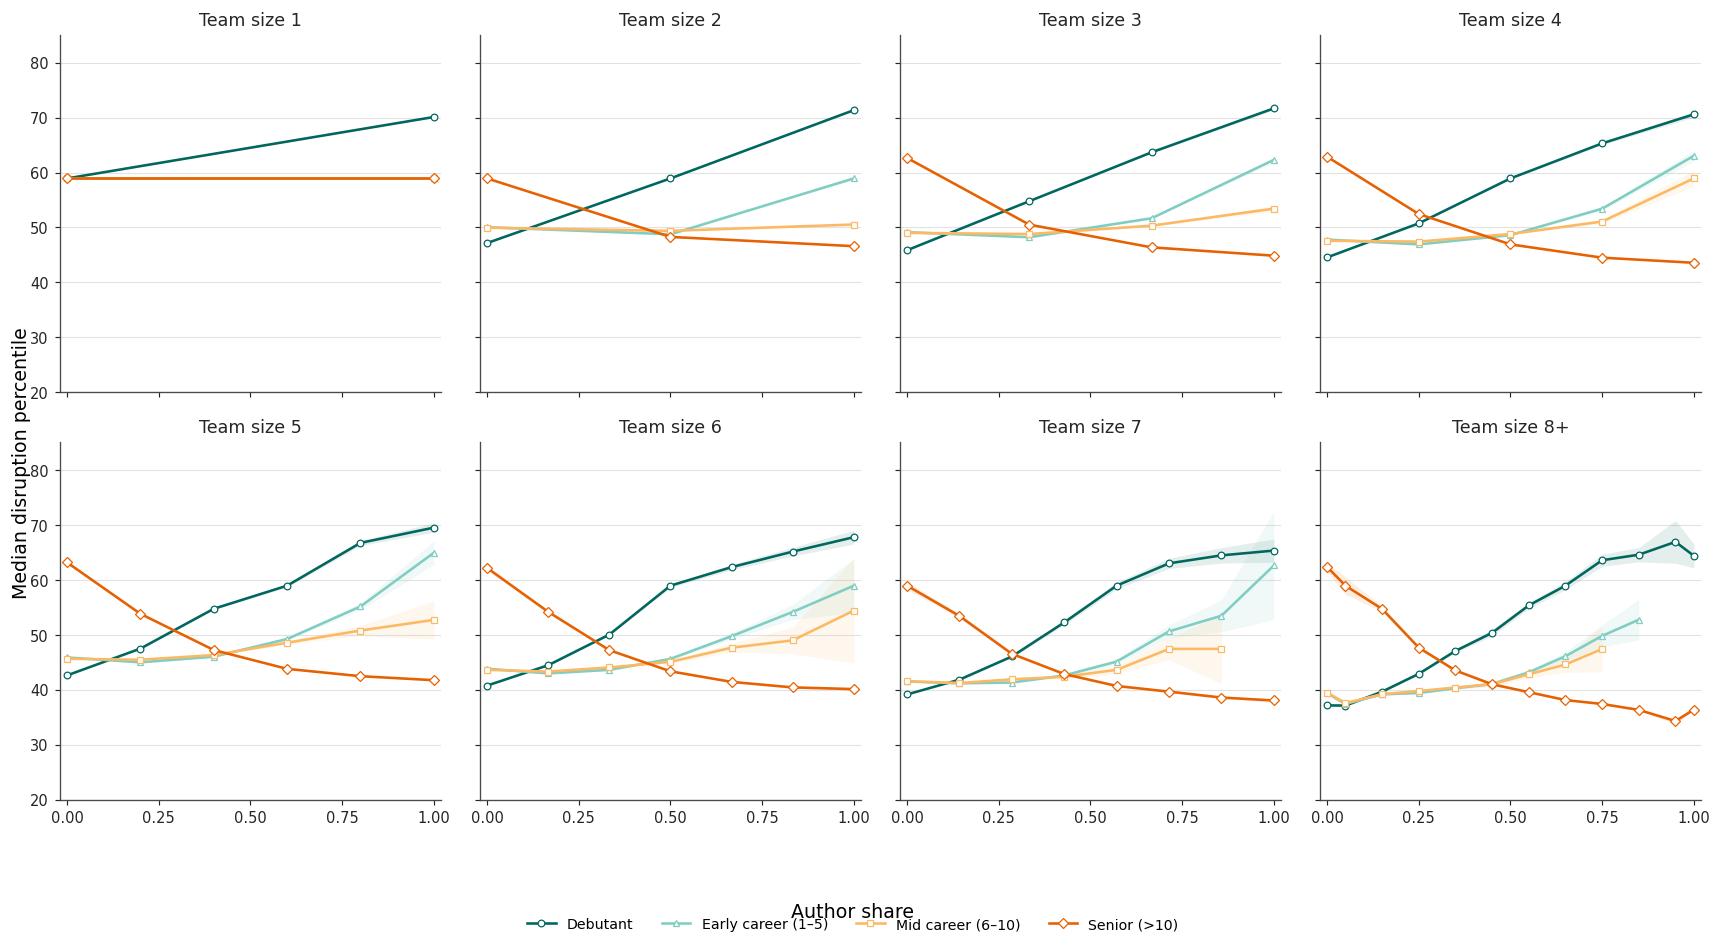

Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T76_legacy_plotpoint_Kendall_disruption_4stage.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T76_legacy_plotpoint_Kendall_disruption_4stage.tex
Saved figure data: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\FigureData_four_stage_disruption_heatmaps.csv


C:\Users\Raiyan Abdul Baten\AppData\Local\Temp\ipykernel_2472\3275861038.py:425: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.04, 1, 1])


Saved figure: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\figures\four_stage_disruption_heatmaps.pdf


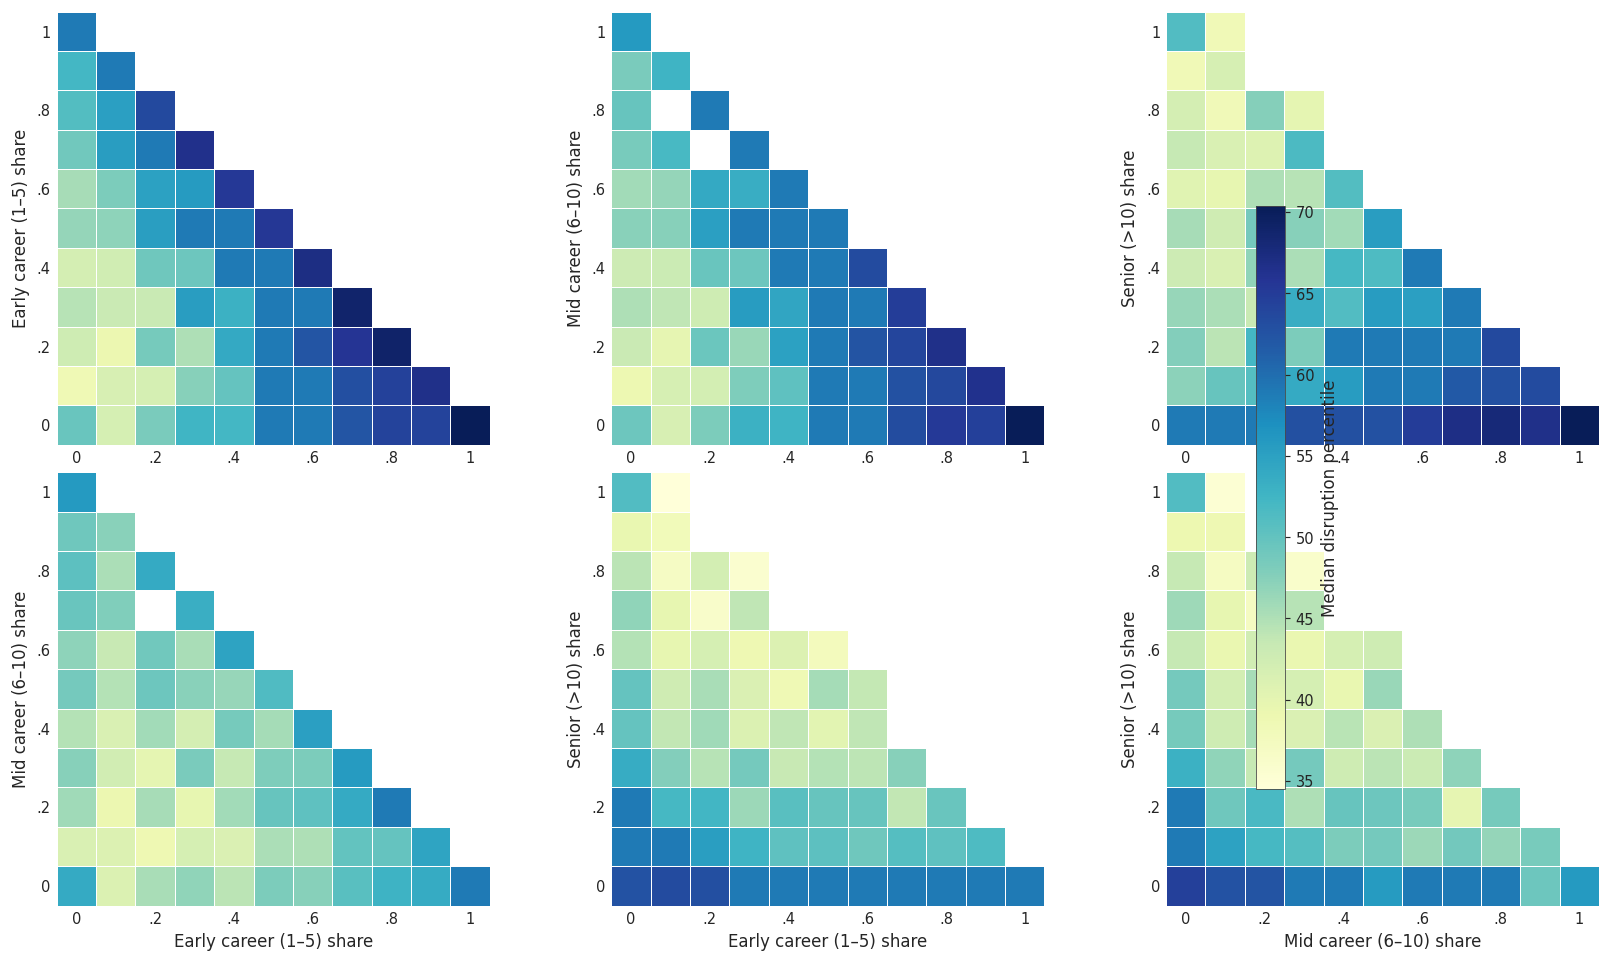

Saved figure data: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\FigureData_four_stage_atypicality_heatmaps.csv


C:\Users\Raiyan Abdul Baten\AppData\Local\Temp\ipykernel_2472\3275861038.py:425: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.04, 1, 1])


Saved figure: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\figures\four_stage_atypicality_heatmaps.pdf


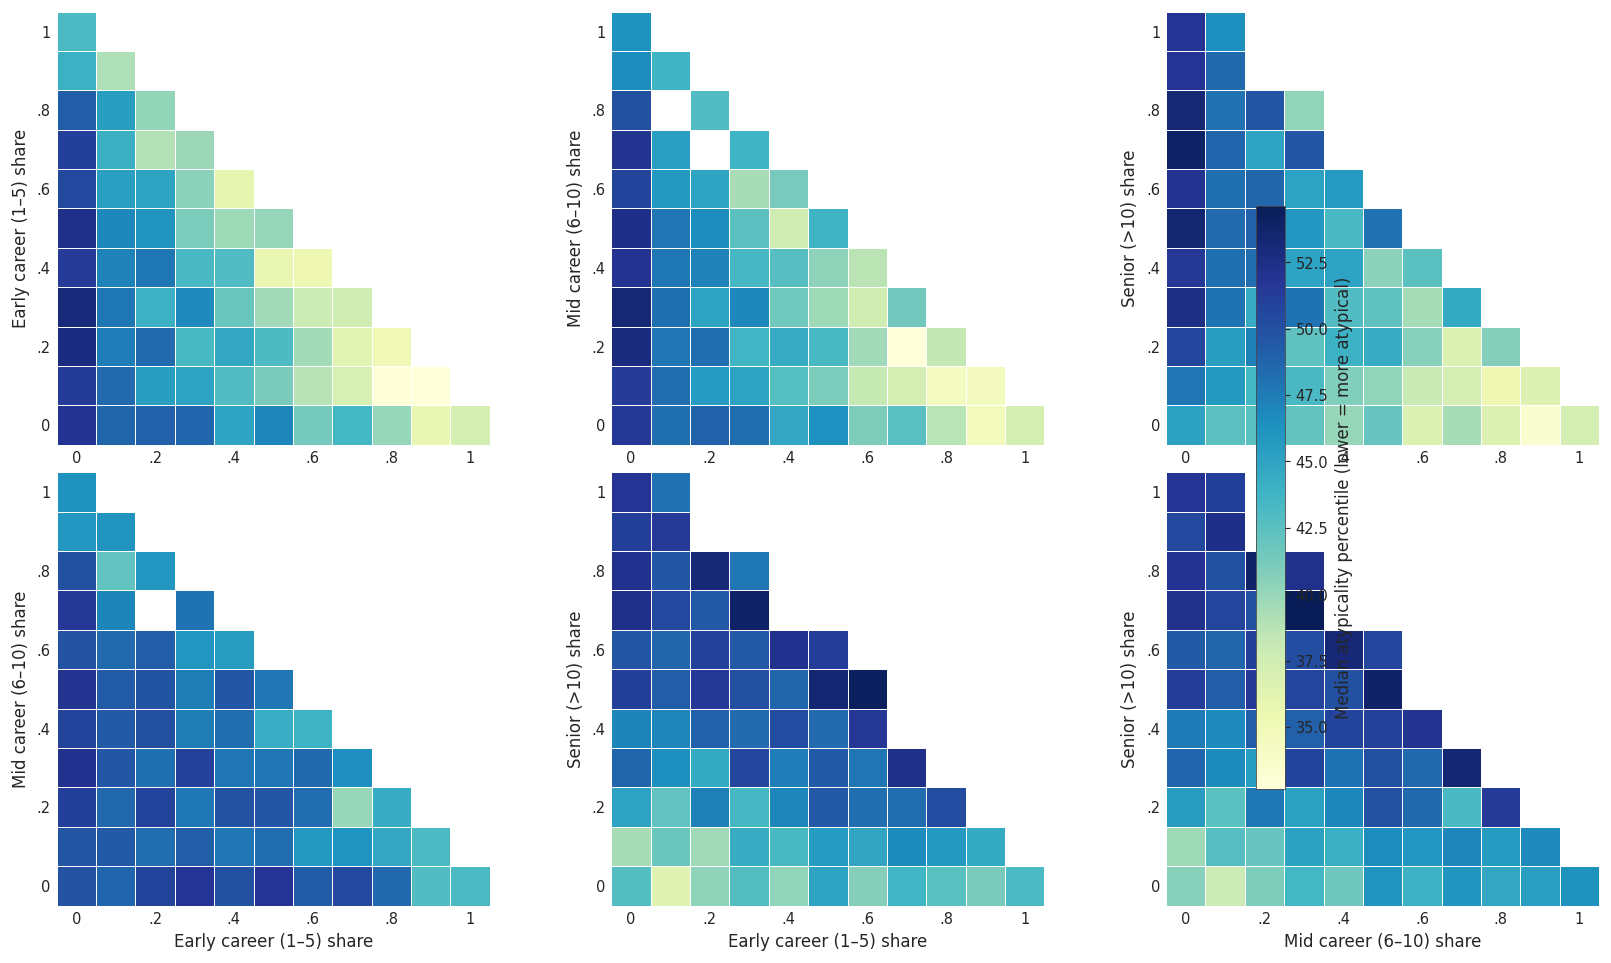

Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T77_heatmap_cells_disruption_4stage.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T77_heatmap_cells_disruption_4stage.tex
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T78_heatmap_cells_atypicality_4stage.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T78_heatmap_cells_atypicality_4stage.tex


(WindowsPath('Reanalysis_Results_v9/tables/T78_heatmap_cells_atypicality_4stage.csv'),
 WindowsPath('Reanalysis_Results_v9/tables/T78_heatmap_cells_atypicality_4stage.tex'))

In [59]:
supp11_four_stage = build_team_ratio_summary(
    "disruption_percentile",
    STAGE4,
    min_n=50,
)

export_figure_data(
    supp11_four_stage,
    "four_stage_disruption_by_team_size",
)

plot_team_ratio_grid(
    supp11_four_stage,
    [label for _, label in STAGE4],
    ylabel="Median disruption percentile",
    stem="four_stage_disruption_by_team_size",
    ylim=(20, 85),
)

legacy_kendall_disruption_4stage = kendall_table_from_plot_summary(
    supp11_four_stage,
    [label for _, label in STAGE4],
)

export_pub_table(
    legacy_kendall_disruption_4stage,
    "T76_legacy_plotpoint_Kendall_disruption_4stage",
)

heatmap_disruption_4 = build_pair_heatmap_data(
    "disruption_percentile",
    STAGE4,
    min_n=100,
)

export_figure_data(
    heatmap_disruption_4,
    "four_stage_disruption_heatmaps",
)

plot_pair_heatmaps(
    heatmap_disruption_4,
    stem="four_stage_disruption_heatmaps",
    colorbar_label="Median disruption percentile",
    annotate=False,
)

heatmap_atyp_4 = build_pair_heatmap_data(
    "Atyp_Median_Z_percentile",
    STAGE4,
    min_n=100,
)

export_figure_data(
    heatmap_atyp_4,
    "four_stage_atypicality_heatmaps",
)

plot_pair_heatmaps(
    heatmap_atyp_4,
    stem="four_stage_atypicality_heatmaps",
    colorbar_label=(
        "Median atypicality percentile "
        "(lower = more atypical)"
    ),
    annotate=False,
)

export_pub_table(
    heatmap_disruption_4,
    "T77_heatmap_cells_disruption_4stage",
)

export_pub_table(
    heatmap_atyp_4,
    "T78_heatmap_cells_atypicality_4stage",
)

## 13.12 Legacy full-data rank-correlation tables

For completeness, V9 also regenerates the earlier full-paper Kendall
correlations for the three career-stage shares. These are descriptive
correlations; the revised paper's inferential spine remains the fixed-effect
models.

In [60]:
if RUN_LEGACY_RAW_KENDALL:
    legacy_overall_rows = []

    yy = A["disruption_percentile"].astype(np.float64)

    for colname, label in STAGE3:
        xx = A[colname].astype(np.float64)

        m = (
            np.isfinite(xx)
            & np.isfinite(yy)
        )

        pr = stats.pearsonr(xx[m], yy[m])
        sr = stats.spearmanr(xx[m], yy[m])
        kt = stats.kendalltau(xx[m], yy[m])

        legacy_overall_rows.append({
            "career_stage": label,
            "n": int(m.sum()),
            "pearson_r": pr.statistic,
            "pearson_p": pr.pvalue,
            "spearman_r": sr.statistic,
            "spearman_p": sr.pvalue,
            "kendall_tau": kt.statistic,
            "kendall_p": kt.pvalue,
        })

    legacy_overall_corr = pd.DataFrame(
        legacy_overall_rows
    )

    export_pub_table(
        legacy_overall_corr,
        "T79_legacy_overall_correlations_with_Kendall",
    )

Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T79_legacy_overall_correlations_with_Kendall.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T79_legacy_overall_correlations_with_Kendall.tex


## Figure-output audit

The notebook now verifies the complete figure inventory. A missing figure causes
the run to fail here rather than silently producing an incomplete manuscript
bundle.

In [61]:
EXPECTED_FIGURE_STEMS = [
    "career_stage_disruption_by_team_size",
    "adjusted_debutant_share_effect_by_team_size",
    "atypicality_ecdf_by_debutant_share",
    "career_stage_disruption_heatmaps",
    "top_team_compositions",
    "canonical_19field_debutant_share_effects",
    "debutant_share_effect_by_collaborator_prior_disruption",
    "top10_disruption_c10_levels",
    "fixed_window_c10_cumulative_correlation",
    "debutant_disruption_by_team_size_categories",
    "debutant_disruption_by_decade",
    "canonical_19field_descriptive_grid",
    "atypicality_by_career_stage_and_team_size",
    "reference_popularity_by_career_stage_and_team_size",
    "productivity_by_career_age",
    "career_stage_atypicality_heatmaps",
    "debutant_disruption_by_collaborator_history_and_team_size",
    "c10_by_career_stage_and_team_size",
    "c10_share_by_nonoverlapping_disruption_band",
    "four_stage_disruption_by_team_size",
    "four_stage_disruption_heatmaps",
    "four_stage_atypicality_heatmaps",
    "raw_debutant_disruption_correlation_by_team_size",
    "left_boundary_sensitivity",
    "c10_debutant_share_effect_across_disruption",
    "adjusted_nonlinearity_diagnostic",
    "diagnostic_lifetime_citation_cumulative_correlation",
]

figure_audit_rows = []

for stem in EXPECTED_FIGURE_STEMS:
    path = FIGURE_DIR / f"{stem}.pdf"

    figure_audit_rows.append({
        "stem": stem,
        "path": str(path.resolve()),
        "exists": path.exists(),
        "size_bytes": path.stat().st_size if path.exists() else 0,
        "sha256": sha256_file(path) if path.exists() else None,
    })

figure_audit = pd.DataFrame(figure_audit_rows)

display(figure_audit)

missing_figures = figure_audit.loc[
    ~figure_audit["exists"],
    "stem",
].tolist()

if missing_figures:
    raise RuntimeError(
        "V9 figure audit failed. Missing figures:\n"
        + "\n".join(f"  - {x}" for x in missing_figures)
    )

png_files = list(FIGURE_DIR.glob("*.png"))

if png_files:
    raise RuntimeError(
        "V9 is PDF-only, but PNG files were found in the v9 figure directory:\n"
        + "\n".join(str(p) for p in png_files)
    )

figure_audit_path = LOG_DIR / "V9_FIGURE_AUDIT.csv"
figure_audit.to_csv(
    figure_audit_path,
    index=False,
)

print(
    f"PASS: all {len(EXPECTED_FIGURE_STEMS)} expected PDF figures exist."
)
print("PASS: no PNG files were created by v9.")
print("Saved:", figure_audit_path.resolve())

,stem,path,exists,size_bytes,sha256
0,career_stage_disruption_by_team_size,D:\beginners_charm\new_statistical_analysis\Re...,True,25366,4f8c1609af5859d33b9ab326c1275f0fc41d7983e1dc73...
1,adjusted_debutant_share_effect_by_team_size,D:\beginners_charm\new_statistical_analysis\Re...,True,11667,52db4cc78f27290779b604dab1a9e1759893eef5116e38...
2,atypicality_ecdf_by_debutant_share,D:\beginners_charm\new_statistical_analysis\Re...,True,173187,d51a3d0302104a55c817e0771261c7d5748cbbf9250be6...
3,career_stage_disruption_heatmaps,D:\beginners_charm\new_statistical_analysis\Re...,True,21458,a3161711b154503ef8876fef37237e47064d7f686f7b72...
4,top_team_compositions,D:\beginners_charm\new_statistical_analysis\Re...,True,15584,f9bbbc69962257adcc8b87003594bc6dc47522c7ce415b...
5,canonical_19field_debutant_share_effects,D:\beginners_charm\new_statistical_analysis\Re...,True,18748,339f933f3a1e4c304dab7dd9cfec7e4e33d61aac08c258...
6,debutant_share_effect_by_collaborator_prior_di...,D:\beginners_charm\new_statistical_analysis\Re...,True,16728,b45b4cd6172d8ad06ad41b6774125e560653eea1e21e5d...
7,top10_disruption_c10_levels,D:\beginners_charm\new_statistical_analysis\Re...,True,16477,41b1f296ad6364494d9341f52618ea0cb10d15c8ea72b5...
8,fixed_window_c10_cumulative_correlation,D:\beginners_charm\new_statistical_analysis\Re...,True,19636,ac127f73877f67b44f35428c88be4eab52febc41ea2042...
9,debutant_disruption_by_team_size_categories,D:\beginners_charm\new_statistical_analysis\Re...,True,14519,8c5ab41474b9b712d1a650fea897997104958390bd071f...


PASS: all 27 expected PDF figures exist.
PASS: no PNG files were created by v9.
Saved: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\logs\V9_FIGURE_AUDIT.csv


# Analysis provenance

In [62]:
field_summary = None
if RUN_CANONICAL_FIELD_ANALYSIS:
    field_summary = {
        "membership_source": str(
            LEVEL0_MEMBERSHIP_PATH.resolve()
        ),
        "scoped_membership_rows": int(
            field_long_audit["membership_rows"][0]
        ),
        "number_of_fields": int(
            field_long_audit["unique_fields"][0]
        ),
        "positive_raw_pearson_fields": int(
            (canonical_field_corr["pearson_r"] > 0).sum()
        ),
        "positive_adjusted_FE_fields": int(
            (canonical_field_fe["coef"] > 0).sum()
        ),
        "fdr_significant_positive_FE_fields": int(
            (
                (canonical_field_fe["coef"] > 0)
                & (canonical_field_fe["p_fdr_bh"] < 0.05)
            ).sum()
        ),
        "min_field_FE_coef": float(
            canonical_field_fe["coef"].min()
        ),
        "max_field_FE_coef": float(
            canonical_field_fe["coef"].max()
        ),
    }

productivity_summary = {
    "source": str(PRODUCTIVITY_PATH.resolve()),
    "debut_year_mean_papers": float(age0),
    "career_age_1_mean_papers": float(age1),
    "absolute_increase": float(debut_to_year1_abs),
    "percent_increase": float(debut_to_year1_pct),
}

stage_interaction_summary = {}

for group_label in stage_interaction_fe[
    "collaborator_group"
].unique():
    row = stage_interaction_fe[
        (stage_interaction_fe["collaborator_group"] == group_label)
        & (
            stage_interaction_fe["term"]
            == "beginner_x_prior_centered"
        )
    ].iloc[0]

    stage_interaction_summary[group_label] = {
        "interaction_coef_per_prior_percentile": float(row["coef"]),
        "ci95_low": float(row["ci95_low"]),
        "ci95_high": float(row["ci95_high"]),
        "p": float(row["p"]),
        "n": int(row["n"]),
    }

citation_interaction_row = citation_fe[
    citation_fe["term"] == "disruption_x_beginner"
].iloc[0]

log = {
    "notebook_version": "v9 complete manuscript analysis + corrected final figures",

    "inputs": {
        "main_csv": str(DATA_PATH.resolve()),
        "productivity_csv": str(PRODUCTIVITY_PATH.resolve()),
        "canonical_level0_memberships": str(
            LEVEL0_MEMBERSHIP_PATH.resolve()
        ),
        "filtered_cache": str(FILTERED_CACHE.resolve()),
        "analysis_cache": str(ANALYSIS_CACHE.resolve()),
        "field_base_cache": str(FIELD_BASE_CACHE.resolve()),
        "field_analysis_cache": str(
            FIELD_ANALYSIS_CACHE.resolve()
        ),
    },

    "software": {
        "polars_version": pl.__version__,
        "duckdb_version": duckdb.__version__,
        "polars_threads": pl.thread_pool_size(),
        "logical_cpus": os.cpu_count(),
    },

    "main_analysis_rows": int(len(A["year"])),

    "data_treatment": {
        "article_only": True,
        "start_year": START_YEAR,
        "max_team_size": MAX_TEAM_SIZE,
        "atypicality": (
            "Null and non-finite Atyp_Median_Z values excluded "
            "before rank/test."
        ),
        "field_membership": (
            "Canonical SciSciNet-v2 Level-0 multi-membership; "
            "papers may appear in multiple fields."
        ),
        "C10_complete_through": C10_COMPLETE_THROUGH,
        "early_1_10_prior_disruption": (
            "Count-weighted merge of 1-5 and 6-10 stage means; "
            "one stage may be absent when its count is zero."
        ),
    },

    "primary_model": (
        "disruption percentile ~ beginner share "
        "+ publication-year FE + exact team-size FE; HC1 SE"
    ),

    "new_v6_analyses_and_outputs": [
        "complete legacy + revised figure regeneration",
        "PDF-only publication bundle with output audit",
        "canonical 19-field raw correlation replication",
        "canonical 19-field year + exact-team-size FE models",
        "productivity trajectory replication from saved aggregate CSV",
        "1-10 collaborator beginner-share x prior-disruption interaction",
        ">10 collaborator beginner-share x prior-disruption interaction",
        "complete-window C10 cumulative correlation figure",
        "C10 beginner-share simple slopes across disruption percentile",
    ],

    "field_summary": field_summary,
    "productivity_summary": productivity_summary,
    "stage_specific_interactions": stage_interaction_summary,

    "citation_interaction": {
        "coef": float(citation_interaction_row["coef"]),
        "ci95_low": float(citation_interaction_row["ci95_low"]),
        "ci95_high": float(citation_interaction_row["ci95_high"]),
        "p": float(citation_interaction_row["p"]),
        "n": int(citation_interaction_row["n"]),
    },

    "not_identifiable_or_not_done": [
        "alternative forward windows for disruption from this CSV",
        "author-clustered standard errors without author IDs",
        "causal effects",
    ],

    "publication_output_dirs": {
        "figures": str(FIGURE_DIR.resolve()),
        "tables": str(TABLE_DIR.resolve()),
        "logs": str(LOG_DIR.resolve()),
    },
}

log_path = LOG_DIR / "ANALYSIS_LOG_v5.json"
log_path.write_text(
    json.dumps(log, indent=2),
    encoding="utf-8",
)

print(json.dumps(log, indent=2))
print("Saved:", log_path.resolve())

{
  "notebook_version": "v9 complete manuscript analysis + corrected final figures",
  "inputs": {
    "main_csv": "D:\\beginners_charm\\new_statistical_analysis\\data\\disruption_analysis_nov9.csv",
    "productivity_csv": "D:\\beginners_charm\\new_statistical_analysis\\data\\average_num_of_papers_by_career_age.csv",
    "canonical_level0_memberships": "D:\\beginners_charm\\new_statistical_analysis\\data\\sciscinet_field_reconstruction_v2\\analysis_level0_field_memberships.parquet",
    "filtered_cache": "D:\\beginners_charm\\new_statistical_analysis\\data\\beginners_charm_cache_nov9_v3\\01_filtered_raw.parquet",
    "analysis_cache": "D:\\beginners_charm\\new_statistical_analysis\\data\\beginners_charm_cache_nov9_v3\\02_analysis_with_percentiles.parquet",
    "field_base_cache": "D:\\beginners_charm\\new_statistical_analysis\\data\\beginners_charm_cache_nov9_v3\\04_field_base_with_paperid.parquet",
    "field_analysis_cache": "D:\\beginners_charm\\new_statistical_analysis\\data\\begi

# Output summary

This section prints the principal sample sizes, model estimates, robustness
results, source-file information, and output locations from the completed
analysis. It provides a compact audit of the executed manuscript workflow.

In [63]:
def _term_row(df, term):
    z = df[df["term"] == term]
    if len(z) == 0:
        return None
    return z.iloc[0]

main_row = _term_row(
    main_fe,
    "first_time_author_ratio",
)

team_interaction_row = _term_row(
    interaction_fe,
    "beginner_x_log2teamsize",
)

early_vs_senior_row = _term_row(
    collab_stage_fe,
    "early_career_author_ratio_main",
)

beginner_vs_senior_row = _term_row(
    collab_stage_fe,
    "first_time_author_ratio",
)

print("=" * 88)
print("BEGINNER'S CHARM — V9 COMPLETE ANALYSIS/FIGURE REPRODUCTION FINISHED")
print("=" * 88)

print("\nCORE DATA")
print(f"  Main analysis rows: {len(A['year']):,}")
print(f"  Years: {int(np.nanmin(A['year']))}–{int(np.nanmax(A['year']))}")
print(f"  Team sizes: 1–{int(np.nanmax(A['team_size']))}")
print("  Atypicality: finite values only")
print(f"  Complete C10 window: through {C10_COMPLETE_THROUGH}")

print("\nPRIMARY RESULT")
print(
    "  Beginner-share FE coefficient:",
    f"{main_row['coef']:.4f}",
    f"[{main_row['ci95_low']:.4f}, {main_row['ci95_high']:.4f}]",
)
print(
    "  Interpretation: +10 percentage points beginner share ≈",
    f"{main_row['coef']/10:.3f}",
    "disruption percentile points, conditional on year and exact team size."
)

print("\nTEAM-SIZE INTERACTION")
print(
    "  Beginner × log2(team size):",
    f"{team_interaction_row['coef']:.4f}",
    f"[{team_interaction_row['ci95_low']:.4f}, "
    f"{team_interaction_row['ci95_high']:.4f}]",
)

print("\nCAREER-STAGE DECOMPOSITION")
print(
    "  Beginner vs senior coefficient:",
    f"{beginner_vs_senior_row['coef']:.4f}",
)
print(
    "  Early-career vs senior coefficient:",
    f"{early_vs_senior_row['coef']:.4f}",
)

print("\nCANONICAL 19-FIELD ROBUSTNESS")
if RUN_CANONICAL_FIELD_ANALYSIS:
    print(
        "  Positive raw Pearson correlations:",
        f"{(canonical_field_corr['pearson_r'] > 0).sum()}/19",
    )
    print(
        "  Positive adjusted FE coefficients:",
        f"{(canonical_field_fe['coef'] > 0).sum()}/19",
    )
    print(
        "  FDR-significant positive adjusted coefficients:",
        int(
            (
                (canonical_field_fe["coef"] > 0)
                & (canonical_field_fe["p_fdr_bh"] < 0.05)
            ).sum()
        ),
        "/19",
    )

print("\nPRODUCTIVITY")
print(f"  Debut-year papers: {age0:.4f}")
print(f"  Career-age-1 papers: {age1:.4f}")
print(f"  Increase: {debut_to_year1_pct:.1f}%")

print("\nSTAGE-SPECIFIC COLLABORATOR-HISTORY INTERACTIONS")
for group_label in stage_interaction_fe["collaborator_group"].unique():
    row = stage_interaction_fe[
        (stage_interaction_fe["collaborator_group"] == group_label)
        & (
            stage_interaction_fe["term"]
            == "beginner_x_prior_centered"
        )
    ].iloc[0]

    print(
        f"  {group_label}: beta_interaction={row['coef']:.6f}, "
        f"95% CI [{row['ci95_low']:.6f}, {row['ci95_high']:.6f}], "
        f"p={row['p']:.3g}"
    )

print("\nFIXED-WINDOW C10")
for _, row in citation_fe.iterrows():
    print(
        f"  {row['term']}: "
        f"beta={row['coef']:.6f}, "
        f"95% CI [{row['ci95_low']:.6f}, {row['ci95_high']:.6f}], "
        f"p={row['p']:.3g}"
    )

print("\nPUBLICATION OUTPUTS")
print("  Figures:", FIGURE_DIR.resolve())
print("  Tables:", TABLE_DIR.resolve())
print("  Logs:", LOG_DIR.resolve())

# Capture the actual files that exist at the end rather than relying only on
# the in-memory list.
publication_files_on_disk = sorted(
    [
        str(p.resolve())
        for directory in [FIGURE_DIR, TABLE_DIR, LOG_DIR]
        for p in directory.glob("*")
        if p.is_file()
    ]
)

for path in publication_files_on_disk:
    print("  -", path)

handoff = {
    "status": "completed",
    "notebook": "debutants_statistical_reanalysis_v9_figures_fixed.ipynb",
    "analysis_log": str(log_path.resolve()),
    "publication_files": publication_files_on_disk,
    "headline_values": {
        "main_beginner_FE_coef": float(main_row["coef"]),
        "team_size_interaction_coef": float(
            team_interaction_row["coef"]
        ),
        "beginner_vs_senior_coef": float(
            beginner_vs_senior_row["coef"]
        ),
        "early_vs_senior_coef": float(
            early_vs_senior_row["coef"]
        ),
        "productivity_debut": float(age0),
        "productivity_age1": float(age1),
        "productivity_debut_to_age1_pct": float(
            debut_to_year1_pct
        ),
    },
}

handoff_path = LOG_DIR / "V9_HANDOFF_SUMMARY.json"
handoff_path.write_text(
    json.dumps(handoff, indent=2),
    encoding="utf-8",
)

print("\nSaved handoff:", handoff_path.resolve())
print("=" * 88)

BEGINNER'S CHARM — V9 COMPLETE ANALYSIS/FIGURE REPRODUCTION FINISHED

CORE DATA
  Main analysis rows: 29,054,261
  Years: 1941–2020
  Team sizes: 1–40
  Atypicality: finite values only
  Complete C10 window: through 2010

PRIMARY RESULT
  Beginner-share FE coefficient: 12.4404 [12.3963, 12.4846]
  Interpretation: +10 percentage points beginner share ≈ 1.244 disruption percentile points, conditional on year and exact team size.

TEAM-SIZE INTERACTION
  Beginner × log2(team size): 5.1015 [5.0531, 5.1498]

CAREER-STAGE DECOMPOSITION
  Beginner vs senior coefficient: 13.4639
  Early-career vs senior coefficient: 2.5391

CANONICAL 19-FIELD ROBUSTNESS
  Positive raw Pearson correlations: 19/19
  Positive adjusted FE coefficients: 19/19
  FDR-significant positive adjusted coefficients: 19 /19

PRODUCTIVITY
  Debut-year papers: 1.1768
  Career-age-1 papers: 1.6796
  Increase: 42.7%

STAGE-SPECIFIC COLLABORATOR-HISTORY INTERACTIONS
  1-10 years: beta_interaction=-0.064143, 95% CI [-0.067109, -0

# Exact career-age analyses

The broad career-stage analyses distinguish debutants, early-career authors,
and senior authors. Here, the first decade after publication debut is resolved
year by year.

The exact-career-age handoff contains one row for every paper in the main
analysis sample. Sixty papers have incomplete author linkage in the underlying
SciSciNet-v2 author-paper mapping and are excluded only from analyses requiring
complete exact-career-age composition, leaving 29,054,201 papers.

For each paper, author shares at career ages 0 through 10 enter jointly, with
authors more than 10 years past publication debut as the reference category.
The analyses examine disruption, atypical knowledge recombination, reference
popularity, citation impact, and interactions with team size.

In [ ]:
# ============================================================
# EXACT CAREER-AGE DECOMPOSITION: 0, 1, ..., 10, >10
# Append this cell at the END of the fully executed v9 notebook.
#
# Uses the locally reconstructed SciSciNet-v2 handoff.
# The 60 papers with incomplete author linkage are excluded ONLY
# from this new exact-age analysis.
# ============================================================

EXACT_AGE_PATH = Path(
    r"data\sciscinet_exact_career_age_v2\v9_exact_career_age_handoff.parquet"
)

if not EXACT_AGE_PATH.exists():
    raise FileNotFoundError(
        "Exact-career-age handoff not found:\n"
        f"{EXACT_AGE_PATH.resolve()}"
    )


# ------------------------------------------------------------
# 1. Load handoff and verify row alignment with v9
# ------------------------------------------------------------

exact_count_cols = [
    f"career_age_{a}_count" for a in range(11)
] + ["career_age_11plus_count"]

exact_share_cols = [
    f"career_age_{a}_share" for a in range(11)
] + ["career_age_11plus_share"]

exact_age = pl.read_parquet(
    EXACT_AGE_PATH,
    columns=[
        "target_row",
        "year",
        "team_size",
        "first_time_author_ratio",
        "early_career_author_ratio",
        "mid_career_author_ratio",
        "senior_author_ratio",
        *exact_count_cols,
        *exact_share_cols,
    ],
).sort("target_row")

if exact_age.height != len(A["year"]):
    raise RuntimeError(
        f"Handoff has {exact_age.height:,} rows but v9 A has "
        f"{len(A['year']):,} rows."
    )

target_row_np = exact_age["target_row"].to_numpy()

if not np.array_equal(
    target_row_np,
    np.arange(
        exact_age.height,
        dtype=target_row_np.dtype,
    ),
):
    raise RuntimeError(
        "target_row is not a complete 0...(N-1) sequence."
    )

if not np.array_equal(
    exact_age["year"].to_numpy(),
    np.asarray(A["year"]),
):
    raise RuntimeError(
        "Exact-age handoff is not row-aligned with v9: "
        "year mismatch."
    )

if not np.array_equal(
    exact_age["team_size"].to_numpy(),
    np.asarray(A["team_size"]),
):
    raise RuntimeError(
        "Exact-age handoff is not row-aligned with v9: "
        "team-size mismatch."
    )

if not np.allclose(
    exact_age["first_time_author_ratio"].to_numpy(),
    np.asarray(A["first_time_author_ratio"]),
    atol=1e-6,
    rtol=0,
    equal_nan=True,
):
    raise RuntimeError(
        "Exact-age handoff is not row-aligned with v9: "
        "stored debutant-share mismatch."
    )


# Complete exact-age reconstruction = reconstructed author counts
# sum to the manuscript team size.
#
# This excludes the known 60 papers for which the downloaded
# SciSciNet author-paper mapping is missing one author.
count_sum = np.zeros(
    exact_age.height,
    dtype=np.int16,
)

for c in exact_count_cols:
    count_sum += (
        exact_age[c]
        .to_numpy()
        .astype(np.int16, copy=False)
    )

valid_exact_age = (
    count_sum
    == exact_age["team_size"]
       .to_numpy()
       .astype(np.int16, copy=False)
)

n_valid = int(valid_exact_age.sum())
n_invalid = int((~valid_exact_age).sum())

print("=" * 88)
print("EXACT CAREER-AGE HANDOFF")
print("=" * 88)
print(f"Rows in v9:                    {exact_age.height:,}")
print(f"Complete exact-age papers:     {n_valid:,}")
print(f"Excluded linkage mismatches:   {n_invalid:,}")

if n_invalid != 60:
    raise RuntimeError(
        f"Expected the 60 known incomplete-linkage papers, "
        f"found {n_invalid:,}. "
        "Stop and inspect the reconstruction before proceeding."
    )


# ------------------------------------------------------------
# 1b. Strong reconciliation against v9's existing broad stages
# ------------------------------------------------------------

age0_share = (
    exact_age["career_age_0_share"]
    .to_numpy()
)

age1_5_share = np.zeros(
    exact_age.height,
    dtype=np.float64,
)

age6_10_share = np.zeros(
    exact_age.height,
    dtype=np.float64,
)

for a in range(1, 6):
    age1_5_share += (
        exact_age[f"career_age_{a}_share"]
        .to_numpy()
    )

for a in range(6, 11):
    age6_10_share += (
        exact_age[f"career_age_{a}_share"]
        .to_numpy()
    )

senior_share_reconstructed = (
    exact_age["career_age_11plus_share"]
    .to_numpy()
)

reconciliation_checks = {
    "age 0 == v9 debutant share":
        np.allclose(
            age0_share[valid_exact_age],
            np.asarray(
                A["first_time_author_ratio"]
            )[valid_exact_age],
            atol=1e-6,
            rtol=0,
            equal_nan=True,
        ),

    "ages 1-5 == v9 1-5 share":
        np.allclose(
            age1_5_share[valid_exact_age],
            np.asarray(
                A["early_1_5_author_ratio"]
            )[valid_exact_age],
            atol=1e-6,
            rtol=0,
            equal_nan=True,
        ),

    "ages 6-10 == v9 6-10 share":
        np.allclose(
            age6_10_share[valid_exact_age],
            np.asarray(
                A["mid_6_10_author_ratio"]
            )[valid_exact_age],
            atol=1e-6,
            rtol=0,
            equal_nan=True,
        ),

    "age 11+ == v9 senior share":
        np.allclose(
            senior_share_reconstructed[
                valid_exact_age
            ],
            np.asarray(
                A["senior_author_ratio"]
            )[valid_exact_age],
            atol=1e-6,
            rtol=0,
            equal_nan=True,
        ),
}

for label, passed in reconciliation_checks.items():
    print(
        f"  {'PASS' if passed else 'FAIL'} — {label}"
    )

if not all(reconciliation_checks.values()):
    raise RuntimeError(
        "Exact-age shares do not collapse back to the "
        "v9 broad-stage variables on the complete-linkage sample."
    )

print(
    "PASS: exact-age handoff is aligned and internally reconciled."
)


# ------------------------------------------------------------
# 2. Build the exact-age regression bundle
#
# Joint composition model:
# age 0, 1, ..., 10 included
# >10 omitted as the reference category
# ------------------------------------------------------------

EXACT_PREDICTORS = [
    f"career_age_{a}_ratio"
    for a in range(11)
]

exact_model_data = {
    "year":
        np.asarray(A["year"])[valid_exact_age],

    "team_size":
        np.asarray(A["team_size"])[valid_exact_age],

    "disruption_percentile":
        np.asarray(
            A["disruption_percentile"]
        )[valid_exact_age],
}

for a in range(11):
    exact_model_data[
        f"career_age_{a}_ratio"
    ] = (
        exact_age[
            f"career_age_{a}_share"
        ]
        .to_numpy()[valid_exact_age]
        .astype(
            np.float32,
            copy=False,
        )
    )

senior_exact_valid = (
    exact_age[
        "career_age_11plus_share"
    ]
    .to_numpy()[valid_exact_age]
    .astype(
        np.float32,
        copy=False,
    )
)


exact_age_fe, exact_age_cov, exact_age_info = (
    fit_two_way_fe_model_full(
        exact_model_data,
        outcome="disruption_percentile",
        predictors=EXACT_PREDICTORS,
    )
)

exact_age_fe["career_age"] = (
    exact_age_fe["term"]
    .str.extract(
        r"career_age_(\d+)_ratio",
        expand=False,
    )
    .astype(int)
)

exact_age_fe["career_stage"] = (
    exact_age_fe["career_age"]
    .astype(str)
)

# Report 10-percentage-point substitutions from >10 share.
exact_age_fe["change_per_10pp"] = (
    0.10
    * exact_age_fe["coef"]
)

exact_age_fe[
    "change_per_10pp_ci95_low"
] = (
    0.10
    * exact_age_fe["ci95_low"]
)

exact_age_fe[
    "change_per_10pp_ci95_high"
] = (
    0.10
    * exact_age_fe["ci95_high"]
)

exact_age_fe = (
    exact_age_fe
    .sort_values("career_age")
    .reset_index(drop=True)
)


# Add omitted senior reference for a manuscript-ready 12-stage table.
senior_reference_row = pd.DataFrame([{
    "term":
        "career_age_11plus_ratio",

    "coef":
        0.0,

    "robust_se_HC1":
        np.nan,

    "t":
        np.nan,

    "p":
        np.nan,

    "ci95_low":
        np.nan,

    "ci95_high":
        np.nan,

    "n":
        n_valid,

    "career_age":
        11,

    "career_stage":
        ">10 (reference)",

    "change_per_10pp":
        0.0,

    "change_per_10pp_ci95_low":
        np.nan,

    "change_per_10pp_ci95_high":
        np.nan,
}])

exact_age_table = pd.concat(
    [
        exact_age_fe,
        senior_reference_row,
    ],
    ignore_index=True,
)

display(
    exact_age_table[
        [
            "career_stage",
            "coef",
            "ci95_low",
            "ci95_high",
            "change_per_10pp",
            "change_per_10pp_ci95_low",
            "change_per_10pp_ci95_high",
            "p",
            "n",
        ]
    ]
)

export_pub_table(
    exact_age_table,
    "T80_exact_career_age_composition_FE",
)


# ------------------------------------------------------------
# 3. Direct tests:
#    publication debut (age 0) versus each exact age 1...10
#
# These directly test whether replacing 10 pp of senior share
# with debutant share differs from replacing the same 10 pp
# with authors exactly a years past debut.
# ------------------------------------------------------------

contrast_rows = []

df_resid = (
    exact_age_info["df_resid"]
)

for a in range(1, 11):

    row = linear_combo_from_model(
        exact_age_fe,
        exact_age_cov,
        weights={
            "career_age_0_ratio":
                0.10,

            f"career_age_{a}_ratio":
                -0.10,
        },
        label=(
            f"Debut vs career age {a}"
        ),
    )

    t_stat = (
        row["estimate"]
        / row["se"]
    )

    p_raw = (
        2
        * stats.t.sf(
            abs(t_stat),
            df=df_resid,
        )
    )

    contrast_rows.append({
        "comparison":
            f"Age 0 vs age {a}",

        "other_career_age":
            a,

        "difference_per_10pp":
            row["estimate"],

        "se":
            row["se"],

        "ci95_low":
            row["ci95_low"],

        "ci95_high":
            row["ci95_high"],

        "t":
            t_stat,

        "p_raw":
            p_raw,

        "n":
            n_valid,
    })

debut_vs_exact_age = pd.DataFrame(
    contrast_rows
)

debut_vs_exact_age["p_holm"] = (
    multipletests(
        debut_vs_exact_age[
            "p_raw"
        ].to_numpy(),
        method="holm",
    )[1]
)

display(
    debut_vs_exact_age
)

export_pub_table(
    debut_vs_exact_age,
    "T81_debut_vs_each_exact_career_age",
)


# ------------------------------------------------------------
# 4. Omnibus test
#
# H0:
# beta_age0 = beta_age1 = ... = beta_age10
# ------------------------------------------------------------

names = (
    exact_age_fe["term"]
    .tolist()
)

name_to_idx = {
    name: i
    for i, name in enumerate(names)
}

R = np.zeros(
    (
        10,
        len(names),
    ),
    dtype=np.float64,
)

for r, a in enumerate(
    range(1, 11)
):
    R[
        r,
        name_to_idx[
            "career_age_0_ratio"
        ],
    ] = 1.0

    R[
        r,
        name_to_idx[
            f"career_age_{a}_ratio"
        ],
    ] = -1.0

b = exact_age_fe[
    "coef"
].to_numpy(
    dtype=float
)

Rb = R @ b

RVRT = (
    R
    @ exact_age_cov
    @ R.T
)

RVRT_inv = np.linalg.pinv(
    RVRT
)

wald_chi2 = float(
    Rb.T
    @ RVRT_inv
    @ Rb
)

wald_df = int(
    np.linalg.matrix_rank(R)
)

wald_p = float(
    stats.chi2.sf(
        wald_chi2,
        df=wald_df,
    )
)

omnibus_exact_age = pd.DataFrame([{
    "test":
        "beta_age0 = beta_age1 = ... = beta_age10",

    "wald_chi2":
        wald_chi2,

    "df":
        wald_df,

    "p":
        wald_p,

    "n":
        n_valid,
}])

display(
    omnibus_exact_age
)

export_pub_table(
    omnibus_exact_age,
    "T82_exact_career_age_omnibus",
)


# ------------------------------------------------------------
# 5. Smooth-youth extrapolation diagnostics
#
# These target the conceptual question:
#
# Is age 0 simply the extrapolated endpoint of a smooth
# career-age trajectory among already-publishing scientists?
#
# Diagnostic 1:
#   fit a GLS linear trend to beta_1 ... beta_5
#
# Diagnostic 2:
#   fit a GLS linear trend to beta_1 ... beta_10
#
# Then extrapolate that trajectory back to career age 0
# and compare the extrapolated value with the observed beta_0.
#
# These are diagnostics conditional on a linear smooth-age
# trajectory. The unrestricted exact-age model remains primary.
# ------------------------------------------------------------

def exact_age_linear_extrapolation_test(
    max_age
):
    subset_ages = np.arange(
        1,
        max_age + 1,
        dtype=float,
    )

    subset_terms = [
        f"career_age_{a}_ratio"
        for a in range(
            1,
            max_age + 1,
        )
    ]

    idx = np.array(
        [
            name_to_idx[t]
            for t in subset_terms
        ],
        dtype=int,
    )

    beta_sub = b[idx]

    V_sub = (
        exact_age_cov[
            np.ix_(
                idx,
                idx,
            )
        ]
    )

    V_inv = np.linalg.pinv(
        V_sub
    )

    Xtrend = np.column_stack([
        np.ones(
            len(subset_ages)
        ),
        subset_ages,
    ])

    H = (
        np.linalg.pinv(
            Xtrend.T
            @ V_inv
            @ Xtrend
        )
        @ Xtrend.T
        @ V_inv
    )

    # At career age 0,
    # predicted beta = trend intercept.
    extrap_weights_sub = (
        H[0, :]
    )

    c = np.zeros(
        len(names),
        dtype=float,
    )

    c[
        name_to_idx[
            "career_age_0_ratio"
        ]
    ] = 1.0

    c[idx] -= (
        extrap_weights_sub
    )

    estimate_native = float(
        c @ b
    )

    variance_native = float(
        c
        @ exact_age_cov
        @ c
    )

    se_native = math.sqrt(
        max(
            variance_native,
            0.0,
        )
    )

    t_stat = (
        estimate_native
        / se_native
    )

    p_value = float(
        2
        * stats.t.sf(
            abs(t_stat),
            df=df_resid,
        )
    )

    observed_beta0 = float(
        b[
            name_to_idx[
                "career_age_0_ratio"
            ]
        ]
    )

    extrapolated_beta0 = (
        observed_beta0
        - estimate_native
    )

    return {
        "trajectory_used":
            f"career ages 1-{max_age}",

        "observed_beta_age0":
            observed_beta0,

        "extrapolated_beta_at_age0":
            extrapolated_beta0,

        "age0_minus_extrapolated_per_10pp":
            0.10
            * estimate_native,

        "se_per_10pp":
            0.10
            * se_native,

        "ci95_low_per_10pp":
            0.10
            * (
                estimate_native
                - 1.96 * se_native
            ),

        "ci95_high_per_10pp":
            0.10
            * (
                estimate_native
                + 1.96 * se_native
            ),

        "t":
            t_stat,

        "p":
            p_value,

        "n":
            n_valid,
    }


smooth_extrapolation = pd.DataFrame([
    exact_age_linear_extrapolation_test(
        5
    ),
    exact_age_linear_extrapolation_test(
        10
    ),
])

display(
    smooth_extrapolation
)

export_pub_table(
    smooth_extrapolation,
    "T83_exact_career_age_linear_extrapolation_diagnostics",
)


# ------------------------------------------------------------
# 6. Inferential coefficient-profile figure
#
# Ages 0...10 are jointly estimated relative to >10.
# >10 is plotted at zero because it is the omitted reference.
# ------------------------------------------------------------

coef_plot = (
    exact_age_fe.copy()
)

fig, ax = plt.subplots(
    figsize=(8.2, 5.0)
)

x = (
    coef_plot[
        "career_age"
    ]
    .to_numpy()
)

y = (
    coef_plot[
        "change_per_10pp"
    ]
    .to_numpy()
)

yerr = np.vstack([
    (
        y
        - coef_plot[
            "change_per_10pp_ci95_low"
        ].to_numpy()
    ),
    (
        coef_plot[
            "change_per_10pp_ci95_high"
        ].to_numpy()
        - y
    ),
])

ax.errorbar(
    x,
    y,
    yerr=yerr,
    fmt="o-",
    color=ESTIMATE_COLOR,
    ecolor=ESTIMATE_COLOR,
    linewidth=1.7,
    elinewidth=1.0,
    capsize=2.3,
    markersize=4.8,
    markerfacecolor="white",
    markeredgecolor=ESTIMATE_COLOR,
    markeredgewidth=0.8,
    zorder=3,
)

# Highlight publication debut.
age0_row = (
    coef_plot[
        coef_plot[
            "career_age"
        ] == 0
    ]
    .iloc[0]
)

ax.scatter(
    [0],
    [
        age0_row[
            "change_per_10pp"
        ]
    ],
    s=42,
    color=COLORS["teal"],
    edgecolor="white",
    linewidth=0.7,
    zorder=4,
)

# Omitted senior reference.
ax.scatter(
    [11],
    [0],
    s=34,
    color=COLORS["orange"],
    edgecolor="white",
    linewidth=0.7,
    zorder=4,
)

add_zero_line(
    ax
)

apply_science_axes(
    ax
)

ax.set_xticks(
    np.arange(12)
)

ax.set_xticklabels(
    [str(a) for a in range(11)]
    + [">10"]
)

ax.set_xlabel(
    "Career age (years since first publication)"
)

ax.set_ylabel(
    "Change in disruption percentile per +10 pp author share\n"
    "(relative to authors >10 years past debut)"
)

plt.tight_layout()

save_pub_figure(
    fig,
    "exact_career_age_disruption_coefficients",
)

plt.show()

export_figure_data(
    exact_age_table[
        [
            "career_stage",
            "career_age",
            "change_per_10pp",
            "change_per_10pp_ci95_low",
            "change_per_10pp_ci95_high",
            "n",
        ]
    ],
    "exact_career_age_disruption_coefficients",
)


# ------------------------------------------------------------
# 7. Supplementary analogue of Figure 1
#
# 12 lines:
#   age 0, age 1, ..., age 10, >10
#
# No confidence bands, deliberately, to avoid clutter.
# ------------------------------------------------------------

team_valid = (
    np.asarray(
        A["team_size"]
    )[valid_exact_age]
    .astype(
        np.int8,
        copy=False,
    )
)

disruption_valid = (
    np.asarray(
        A["disruption_percentile"]
    )[valid_exact_age]
    .astype(
        np.float32,
        copy=False,
    )
)

stage_arrays = {
    f"{a}":
        exact_model_data[
            f"career_age_{a}_ratio"
        ]
    for a in range(11)
}

stage_arrays[">10"] = (
    senior_exact_valid
)

summary_rows = []

for (
    stage_label,
    share_values,
) in stage_arrays.items():

    tmp = pl.DataFrame({
        "team_size":
            team_valid,

        "share":
            share_values,

        "disruption_percentile":
            disruption_valid,
    })

    tmp_summary = (
        tmp.lazy()
        .with_columns([
            pl.when(
                pl.col(
                    "team_size"
                ) >= 8
            )
            .then(
                pl.lit("8+")
            )
            .otherwise(
                pl.col(
                    "team_size"
                ).cast(
                    pl.String
                )
            )
            .alias(
                "team_group"
            ),

            pl.when(
                pl.col(
                    "team_size"
                ) < 8
            )
            .then(
                pl.col(
                    "share"
                )
                .cast(
                    pl.Float64
                )
                .round(4)
            )
            .when(
                pl.col(
                    "share"
                ) <= 0
            )
            .then(
                pl.lit(0.0)
            )
            .when(
                pl.col(
                    "share"
                ) >= 1
            )
            .then(
                pl.lit(1.0)
            )
            .otherwise(
                (
                    (
                        pl.col(
                            "share"
                        )
                        .cast(
                            pl.Float64
                        )
                        * 10
                    )
                    .floor()
                    / 10
                    + 0.05
                )
            )
            .alias("x"),
        ])
        .group_by([
            "team_group",
            "x",
        ])
        .agg([
            pl.len().alias(
                "n"
            ),

            pl.col(
                "disruption_percentile"
            )
            .median()
            .alias(
                "median"
            ),
        ])
        .filter(
            pl.col("n")
            >= 50
        )
        .with_columns(
            pl.lit(
                stage_label
            ).alias(
                "career_age"
            )
        )
        .collect()
        .to_pandas()
    )

    summary_rows.append(
        tmp_summary
    )

    del tmp, tmp_summary
    gc.collect()


exact_age_ratio_summary = pd.concat(
    summary_rows,
    ignore_index=True,
)

team_order = {
    str(i): i
    for i in range(
        1,
        8,
    )
}
team_order["8+"] = 8

stage_order = [
    str(a)
    for a in range(11)
] + [">10"]

stage_order_map = {
    label: i
    for i, label in enumerate(
        stage_order
    )
}

exact_age_ratio_summary[
    "_team_order"
] = (
    exact_age_ratio_summary[
        "team_group"
    ]
    .map(
        team_order
    )
)

exact_age_ratio_summary[
    "_stage_order"
] = (
    exact_age_ratio_summary[
        "career_age"
    ]
    .map(
        stage_order_map
    )
)

exact_age_ratio_summary = (
    exact_age_ratio_summary
    .sort_values([
        "_team_order",
        "_stage_order",
        "x",
    ])
    .drop(
        columns=[
            "_team_order",
            "_stage_order",
        ]
    )
)

export_figure_data(
    exact_age_ratio_summary,
    "exact_career_age_disruption_by_team_size",
)


# Continuous career-age progression using only the established
# v7 palette endpoints/intermediates.
career_age_cmap = (
    mpl.colors.LinearSegmentedColormap.from_list(
        "exact_career_age_v7",
        [
            COLORS["teal"],
            COLORS["mint"],
            COLORS["pale_orange"],
            COLORS["orange"],
        ],
    )
)

stage_colors = {
    label:
        career_age_cmap(
            i
            / (
                len(stage_order)
                - 1
            )
        )
    for i, label
    in enumerate(
        stage_order
    )
}


fig, axes = plt.subplots(
    2,
    4,
    figsize=(15.2, 8.2),
    sharex=True,
    sharey=True,
)

axes = axes.ravel()

legend_handles = []
legend_labels = []

for (
    ax,
    team_group,
) in zip(
    axes,
    [
        str(i)
        for i in range(
            1,
            8,
        )
    ] + ["8+"],
):

    sub = (
        exact_age_ratio_summary[
            exact_age_ratio_summary[
                "team_group"
            ] == team_group
        ]
    )

    for stage_label in stage_order:

        g = (
            sub[
                sub[
                    "career_age"
                ] == stage_label
            ]
            .sort_values(
                "x"
            )
        )

        if g.empty:
            continue

        line, = ax.plot(
            g["x"],
            g["median"],
            color=stage_colors[
                stage_label
            ],
            linewidth=1.25,
            marker="o",
            markersize=2.7,
            markerfacecolor="white",
            markeredgecolor=
                stage_colors[
                    stage_label
                ],
            markeredgewidth=0.55,
            label=stage_label,
            zorder=3,
        )

        if team_group == "1":
            legend_handles.append(
                line
            )
            legend_labels.append(
                stage_label
            )

    ax.set_title(
        f"Team size {team_group}"
        if team_group != "8+"
        else "Team size 8+"
    )

    ax.set_xlim(
        -0.02,
        1.02,
    )

    ax.set_xticks([
        0,
        0.25,
        0.50,
        0.75,
        1.0,
    ])

    ax.set_ylim(
        20,
        85,
    )

    apply_science_axes(
        ax
    )


fig.supxlabel(
    "Author share"
)

fig.supylabel(
    "Median disruption percentile"
)

fig.legend(
    legend_handles,
    legend_labels,
    title="Career age",
    loc="lower center",
    bbox_to_anchor=(
        0.5,
        -0.015,
    ),
    ncol=6,
    frameon=False,
)

plt.tight_layout(
    rect=[
        0,
        0.085,
        1,
        1,
    ]
)

save_pub_figure(
    fig,
    "exact_career_age_disruption_by_team_size",
)

plt.show()


# ------------------------------------------------------------
# 8. Compact decision summary
# ------------------------------------------------------------

print(
    "\n"
    + "=" * 88
)

print(
    "EXACT CAREER-AGE DISRUPTION ANALYSIS COMPLETE"
)

print(
    "=" * 88
)

print(
    f"N used: {n_valid:,} "
    "(60 incomplete-linkage papers excluded)"
)


print(
    "\nAdjusted +10-pp association "
    "relative to >10-year authors:"
)

print(
    exact_age_table[
        [
            "career_stage",
            "change_per_10pp",
            "change_per_10pp_ci95_low",
            "change_per_10pp_ci95_high",
        ]
    ]
    .round(4)
    .to_string(
        index=False
    )
)


print(
    "\nDebut vs exact ages 1-10:"
)

print(
    debut_vs_exact_age[
        [
            "other_career_age",
            "difference_per_10pp",
            "ci95_low",
            "ci95_high",
            "p_holm",
        ]
    ]
    .round(6)
    .to_string(
        index=False
    )
)


print(
    "\nSmooth-youth extrapolation diagnostics:"
)

print(
    smooth_extrapolation[
        [
            "trajectory_used",
            "age0_minus_extrapolated_per_10pp",
            "ci95_low_per_10pp",
            "ci95_high_per_10pp",
            "p",
        ]
    ]
    .round(6)
    .to_string(
        index=False
    )
)


print(
    "\nSaved figures:"
)

print(
    " ",
    (
        FIGURE_DIR
        / "exact_career_age_disruption_coefficients.pdf"
    ).resolve(),
)

print(
    " ",
    (
        FIGURE_DIR
        / "exact_career_age_disruption_by_team_size.pdf"
    ).resolve(),
)

print(
    "=" * 88
)


# Optional memory cleanup after outputs are complete.
del age0_share
del age1_5_share
del age6_10_share
del senior_share_reconstructed
del count_sum

gc.collect()

## Exact-age profiles across four scientific measures

The same joint exact-career-age composition model is estimated for:

1. disruption percentile;
2. atypicality percentile;
3. average reference-popularity percentile;
4. within-year \(C_{10}\) percentile.

For each measure, the analysis reports the exact-age coefficient profile,
direct debut-versus-post-debut contrasts, and the age-0 departure from linear
trajectories fitted across subsequent early-career ages.

In [65]:
# ============================================================
# EXACT-AGE EXTENSION HELPERS
# For the four planned analyses:
#   1) recombinational innovation
#   2) team-size amplification
#   3) reference popularity
#   4) citation impact
#
# Run AFTER the existing exact-career-age decomposition cell.
# ============================================================

required_exact_objects = [
    "exact_age",
    "valid_exact_age",
    "EXACT_PREDICTORS",
    "fit_two_way_fe_model_full",
    "linear_combo_from_model",
]

missing_exact_objects = [
    name
    for name in required_exact_objects
    if name not in globals()
]

if missing_exact_objects:
    raise RuntimeError(
        "Run the existing exact-career-age decomposition cell first. "
        f"Missing: {missing_exact_objects}"
    )

EXACT_SHARE_FULL = {
    a: (
        exact_age[f"career_age_{a}_share"]
        .to_numpy()
        .astype(np.float32, copy=False)
    )
    for a in range(11)
}

EXACT_SENIOR_SHARE_FULL = (
    exact_age["career_age_11plus_share"]
    .to_numpy()
    .astype(np.float32, copy=False)
)

if int(valid_exact_age.sum()) != 29_054_201:
    raise RuntimeError(
        "Expected 29,054,201 complete exact-age papers in the current "
        f"handoff, found {int(valid_exact_age.sum()):,}."
    )


def _exact_age_composition_model(
    outcome,
    base_mask=None,
):
    """
    Joint composition model:
        outcome ~ shares at exact ages 0..10
                + publication-year FE
                + exact team-size FE
    with age >10 omitted.

    base_mask can impose an additional sample restriction, e.g. year <= 2010.
    """

    mask = valid_exact_age.copy()

    if base_mask is not None:
        mask &= np.asarray(base_mask, dtype=bool)

    mask &= np.isfinite(
        np.asarray(A[outcome], dtype=np.float64)
    )

    data = {
        "year": np.asarray(A["year"])[mask],
        "team_size": np.asarray(A["team_size"])[mask],
        outcome: np.asarray(A[outcome])[mask],
    }

    for a in range(11):
        data[
            f"career_age_{a}_ratio"
        ] = EXACT_SHARE_FULL[a][mask]

    model, cov, info = fit_two_way_fe_model_full(
        data,
        outcome=outcome,
        predictors=EXACT_PREDICTORS,
    )

    model = model.copy()

    model["career_age"] = (
        model["term"]
        .str.extract(
            r"career_age_(\d+)_ratio",
            expand=False,
        )
        .astype(int)
    )

    model = (
        model.sort_values("career_age")
        .reset_index(drop=True)
    )

    model["change_per_10pp"] = (
        0.10 * model["coef"]
    )

    model["change_per_10pp_ci95_low"] = (
        0.10 * model["ci95_low"]
    )

    model["change_per_10pp_ci95_high"] = (
        0.10 * model["ci95_high"]
    )

    return model, cov, info, mask


def _exact_age_debut_contrasts(
    model,
    cov,
    info,
):
    """
    Direct age-0 versus age-a comparisons, a=1..10.
    Values are expressed per 10 percentage points of author share.
    """

    rows = []

    for a in range(1, 11):
        z = linear_combo_from_model(
            model,
            cov,
            weights={
                "career_age_0_ratio": 0.10,
                f"career_age_{a}_ratio": -0.10,
            },
            label=f"Age 0 vs age {a}",
        )

        t_stat = (
            z["estimate"] / z["se"]
            if z["se"] > 0
            else np.nan
        )

        p_raw = (
            float(
                2
                * stats.t.sf(
                    abs(t_stat),
                    df=info["df_resid"],
                )
            )
            if np.isfinite(t_stat)
            else np.nan
        )

        rows.append({
            "comparison": f"Age 0 vs age {a}",
            "other_career_age": a,
            "difference_per_10pp": z["estimate"],
            "se": z["se"],
            "ci95_low": z["ci95_low"],
            "ci95_high": z["ci95_high"],
            "t": t_stat,
            "p_raw": p_raw,
            "n": int(model["n"].iloc[0]),
        })

    out = pd.DataFrame(rows)

    finite_p = np.isfinite(
        out["p_raw"].to_numpy(float)
    )

    out["p_holm"] = np.nan

    if finite_p.any():
        out.loc[
            finite_p,
            "p_holm",
        ] = multipletests(
            out.loc[
                finite_p,
                "p_raw",
            ].to_numpy(float),
            method="holm",
        )[1]

    return out


def _exact_age_linear_extrapolation(
    model,
    cov,
    info,
    max_age,
):
    """
    GLS linear trend through coefficients at ages 1..max_age,
    extrapolated to age 0. Returns +10pp-scale quantities.
    """

    names = model["term"].tolist()
    name_to_idx = {
        name: i
        for i, name in enumerate(names)
    }

    b = model["coef"].to_numpy(float)

    ages = np.arange(
        1,
        max_age + 1,
        dtype=float,
    )

    terms = [
        f"career_age_{a}_ratio"
        for a in range(
            1,
            max_age + 1,
        )
    ]

    idx = np.array(
        [
            name_to_idx[t]
            for t in terms
        ],
        dtype=int,
    )

    beta_sub = b[idx]

    V_sub = cov[
        np.ix_(
            idx,
            idx,
        )
    ]

    V_inv = np.linalg.pinv(
        V_sub
    )

    Xtrend = np.column_stack([
        np.ones(
            len(ages)
        ),
        ages,
    ])

    H = (
        np.linalg.pinv(
            Xtrend.T
            @ V_inv
            @ Xtrend
        )
        @ Xtrend.T
        @ V_inv
    )

    extrap_weights = H[0, :]

    c = np.zeros(
        len(names),
        dtype=float,
    )

    c[
        name_to_idx[
            "career_age_0_ratio"
        ]
    ] = 1.0

    c[idx] -= extrap_weights

    observed_age0_native = float(
        b[
            name_to_idx[
                "career_age_0_ratio"
            ]
        ]
    )

    diff_native = float(
        c @ b
    )

    se_native = math.sqrt(
        max(
            float(
                c @ cov @ c
            ),
            0.0,
        )
    )

    extrapolated_age0_native = (
        observed_age0_native
        - diff_native
    )

    t_stat = (
        diff_native / se_native
        if se_native > 0
        else np.nan
    )

    p_value = (
        float(
            2
            * stats.t.sf(
                abs(t_stat),
                df=info["df_resid"],
            )
        )
        if np.isfinite(t_stat)
        else np.nan
    )

    return {
        "trajectory_used":
            f"career ages 1-{max_age}",
        "observed_age0_per_10pp":
            0.10 * observed_age0_native,
        "extrapolated_age0_per_10pp":
            0.10 * extrapolated_age0_native,
        "observed_minus_extrapolated_per_10pp":
            0.10 * diff_native,
        "se_per_10pp":
            0.10 * se_native,
        "ci95_low_per_10pp":
            0.10
            * (
                diff_native
                - 1.96 * se_native
            ),
        "ci95_high_per_10pp":
            0.10
            * (
                diff_native
                + 1.96 * se_native
            ),
        "t": t_stat,
        "p": p_value,
        "n": int(model["n"].iloc[0]),
    }


def _plot_exact_age_profile(
    model,
    ylabel,
    stem,
):
    """Inferential profile for ages 0..10, with >10 shown as zero reference."""

    x = model[
        "career_age"
    ].to_numpy()

    y = model[
        "change_per_10pp"
    ].to_numpy()

    yerr = np.vstack([
        (
            y
            - model[
                "change_per_10pp_ci95_low"
            ].to_numpy()
        ),
        (
            model[
                "change_per_10pp_ci95_high"
            ].to_numpy()
            - y
        ),
    ])

    fig, ax = plt.subplots(
        figsize=(8.2, 5.0)
    )

    ax.errorbar(
        x,
        y,
        yerr=yerr,
        fmt="o-",
        color=ESTIMATE_COLOR,
        ecolor=ESTIMATE_COLOR,
        linewidth=1.7,
        elinewidth=1.0,
        capsize=2.3,
        markersize=4.8,
        markerfacecolor="white",
        markeredgecolor=ESTIMATE_COLOR,
        markeredgewidth=0.8,
        zorder=3,
    )

    age0 = model[
        model["career_age"] == 0
    ].iloc[0]

    ax.scatter(
        [0],
        [
            age0[
                "change_per_10pp"
            ]
        ],
        s=42,
        color=COLORS["teal"],
        edgecolor="white",
        linewidth=0.7,
        zorder=4,
    )

    ax.scatter(
        [11],
        [0],
        s=34,
        color=COLORS["orange"],
        edgecolor="white",
        linewidth=0.7,
        zorder=4,
    )

    add_zero_line(
        ax
    )

    apply_science_axes(
        ax
    )

    ax.set_xticks(
        np.arange(12)
    )

    ax.set_xticklabels(
        [str(a) for a in range(11)]
        + [">10"]
    )

    ax.set_xlabel(
        "Career age (years since first publication)"
    )

    ax.set_ylabel(
        ylabel
    )

    plt.tight_layout()

    save_pub_figure(
        fig,
        stem,
    )

    plt.show()


def run_exact_age_secondary(
    outcome,
    label,
    ylabel,
    table_prefix,
    figure_stem,
    base_mask=None,
):
    """
    Run one exact-age outcome analysis and export:
      - exact-age profile,
      - age-0 vs ages 1..10 contrasts,
      - 1..5 and 1..10 smooth extrapolation diagnostics,
      - coefficient-profile figure.
    """

    model, cov, info, mask = (
        _exact_age_composition_model(
            outcome=outcome,
            base_mask=base_mask,
        )
    )

    contrasts = (
        _exact_age_debut_contrasts(
            model,
            cov,
            info,
        )
    )

    extrapolation = pd.DataFrame([
        _exact_age_linear_extrapolation(
            model,
            cov,
            info,
            5,
        ),
        _exact_age_linear_extrapolation(
            model,
            cov,
            info,
            10,
        ),
    ])

    export_pub_table(
        model,
        f"{table_prefix}_profile",
    )

    export_pub_table(
        contrasts,
        f"{table_prefix}_debut_contrasts",
    )

    export_pub_table(
        extrapolation,
        f"{table_prefix}_extrapolation",
    )

    export_figure_data(
        model[
            [
                "career_age",
                "change_per_10pp",
                "change_per_10pp_ci95_low",
                "change_per_10pp_ci95_high",
                "n",
            ]
        ],
        figure_stem,
    )

    _plot_exact_age_profile(
        model,
        ylabel=ylabel,
        stem=figure_stem,
    )

    age0 = model[
        model["career_age"] == 0
    ].iloc[0]

    age1 = model[
        model["career_age"] == 1
    ].iloc[0]

    c01 = contrasts[
        contrasts["other_career_age"] == 1
    ].iloc[0]

    print(
        "\n" + "=" * 88
    )
    print(label.upper())
    print("=" * 88)
    print(
        f"N = {int(model['n'].iloc[0]):,}"
    )
    print(
        "Age 0, +10pp:",
        f"{age0['change_per_10pp']:.4f}",
        f"[{age0['change_per_10pp_ci95_low']:.4f}, "
        f"{age0['change_per_10pp_ci95_high']:.4f}]",
    )
    print(
        "Age 1, +10pp:",
        f"{age1['change_per_10pp']:.4f}",
        f"[{age1['change_per_10pp_ci95_low']:.4f}, "
        f"{age1['change_per_10pp_ci95_high']:.4f}]",
    )
    print(
        "Age 0 - age 1, +10pp:",
        f"{c01['difference_per_10pp']:.4f}",
        f"[{c01['ci95_low']:.4f}, "
        f"{c01['ci95_high']:.4f}]",
    )

    return {
        "model": model,
        "cov": cov,
        "info": info,
        "mask": mask,
        "contrasts": contrasts,
        "extrapolation": extrapolation,
    }


print("PASS: exact-age extension helpers ready.")


PASS: exact-age extension helpers ready.


Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T84_exact_age_atypicality_profile.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T84_exact_age_atypicality_profile.tex
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T84_exact_age_atypicality_debut_contrasts.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T84_exact_age_atypicality_debut_contrasts.tex
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T84_exact_age_atypicality_extrapolation.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T84_exact_age_atypicality_extrapolation.tex
Saved figure data: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\FigureData_exact_career_age_atypicality_coefficients.csv
Saved figure: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9

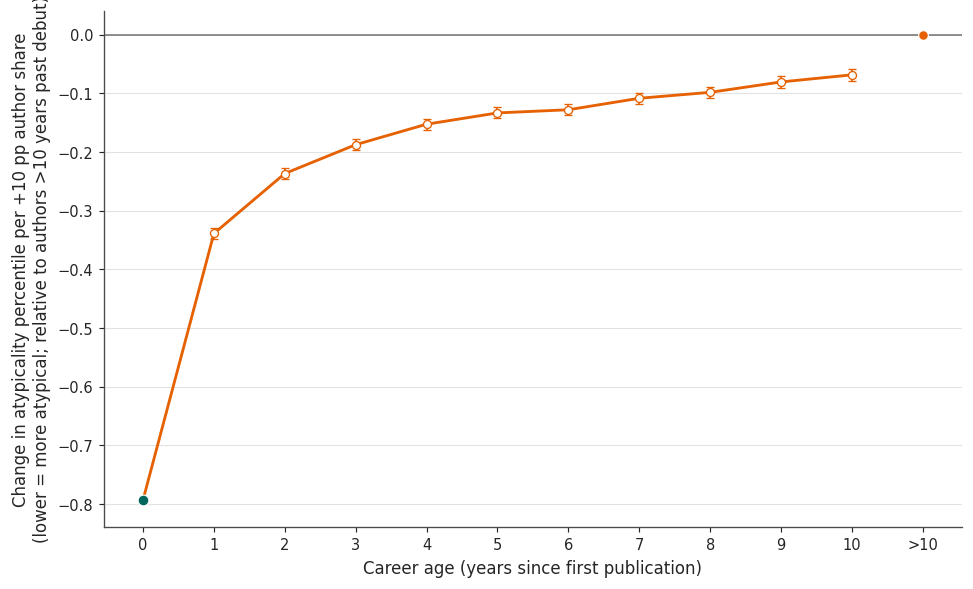


EXACT-AGE RECOMBINATIONAL INNOVATION
N = 23,656,798
Age 0, +10pp: -0.7931 [-0.7986, -0.7876]
Age 1, +10pp: -0.3390 [-0.3482, -0.3298]
Age 0 - age 1, +10pp: -0.4541 [-0.4642, -0.4441]


,term,coef,robust_se_HC1,t,p,ci95_low,ci95_high,n,career_age,change_per_10pp,change_per_10pp_ci95_low,change_per_10pp_ci95_high
0,career_age_0_ratio,-7.931079,0.027900,-284.266433,0.000000e+00,-7.985763,-7.876396,23656798,0,-0.793108,-0.798576,-0.787640
1,career_age_1_ratio,-3.389957,0.046774,-72.475240,0.000000e+00,-3.481632,-3.298282,23656798,1,-0.338996,-0.348163,-0.329828
2,career_age_2_ratio,-2.367960,0.046371,-51.065201,0.000000e+00,-2.458846,-2.277074,23656798,2,-0.236796,-0.245885,-0.227707
3,career_age_3_ratio,-1.876029,0.046631,-40.231653,0.000000e+00,-1.967423,-1.784634,23656798,3,-0.187603,-0.196742,-0.178463
4,career_age_4_ratio,-1.526873,0.046997,-32.488490,1.568829e-231,-1.618986,-1.434760,23656798,4,-0.152687,-0.161899,-0.143476
5,career_age_5_ratio,-1.334616,0.047372,-28.173246,1.252533e-174,-1.427463,-1.241769,23656798,5,-0.133462,-0.142746,-0.124177
6,career_age_6_ratio,-1.280652,0.047843,-26.767750,7.715906e-158,-1.374423,-1.186881,23656798,6,-0.128065,-0.137442,-0.118688
7,career_age_7_ratio,-1.085096,0.048507,-22.369838,7.762246e-111,-1.180168,-0.990024,23656798,7,-0.108510,-0.118017,-0.099002
8,career_age_8_ratio,-0.983876,0.049213,-19.992196,6.450793e-89,-1.080331,-0.887420,23656798,8,-0.098388,-0.108033,-0.088742
9,career_age_9_ratio,-0.806754,0.050135,-16.091629,2.922591e-58,-0.905017,-0.708491,23656798,9,-0.080675,-0.090502,-0.070849


,comparison,other_career_age,difference_per_10pp,se,ci95_low,ci95_high,t,p_raw,n,p_holm
0,Age 0 vs age 1,1,-0.454112,0.005128,-0.464162,-0.444062,-88.563281,0.0,23656798,0.0
1,Age 0 vs age 2,2,-0.556312,0.005086,-0.566281,-0.546343,-109.371552,0.0,23656798,0.0
2,Age 0 vs age 3,3,-0.605505,0.005116,-0.615533,-0.595477,-118.352281,0.0,23656798,0.0
3,Age 0 vs age 4,4,-0.640421,0.005158,-0.650530,-0.630312,-124.169358,0.0,23656798,0.0
4,Age 0 vs age 5,5,-0.659646,0.005201,-0.669840,-0.649452,-126.829505,0.0,23656798,0.0
5,Age 0 vs age 6,6,-0.665043,0.005255,-0.675342,-0.654744,-126.562041,0.0,23656798,0.0
6,Age 0 vs age 7,7,-0.684598,0.005324,-0.695034,-0.674163,-128.584643,0.0,23656798,0.0
7,Age 0 vs age 8,8,-0.694720,0.005396,-0.705296,-0.684144,-128.747986,0.0,23656798,0.0
8,Age 0 vs age 9,9,-0.712433,0.005486,-0.723186,-0.701679,-129.854328,0.0,23656798,0.0
9,Age 0 vs age 10,10,-0.724544,0.005573,-0.735467,-0.713620,-130.005997,0.0,23656798,0.0


,trajectory_used,observed_age0_per_10pp,extrapolated_age0_per_10pp,observed_minus_extrapolated_per_10pp,se_per_10pp,ci95_low_per_10pp,ci95_high_per_10pp,t,p,n
0,career ages 1-5,-0.793108,-0.358597,-0.434511,0.00532,-0.444938,-0.424083,-81.673689,0.0,23656798
1,career ages 1-10,-0.793108,-0.292477,-0.500630,0.00398,-0.508431,-0.492830,-125.786378,0.0,23656798


In [66]:
# ============================================================
# 1) RECOMBINATIONAL INNOVATION AT EXACT CAREER AGES
# Outcome: Atyp_Median_Z percentile
# Lower percentile = more atypical knowledge combinations.
# ============================================================

exact_atypicality = run_exact_age_secondary(
    outcome="Atyp_Median_Z_percentile",
    label="Exact-age recombinational innovation",
    ylabel=(
        "Change in atypicality percentile per +10 pp author share\n"
        "(lower = more atypical; relative to authors >10 years past debut)"
    ),
    table_prefix="T84_exact_age_atypicality",
    figure_stem="exact_career_age_atypicality_coefficients",
)

display(exact_atypicality["model"])
display(exact_atypicality["contrasts"])
display(exact_atypicality["extrapolation"])


## Exact career age × team size

Each exact career-age share is interacted with \(\log_2\) team size while
retaining exact team-size fixed effects. The resulting interaction coefficients
measure how each career-age association changes when team size doubles.

Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T85_exact_age_by_team_size_full_model.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T85_exact_age_by_team_size_full_model.tex
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T85b_exact_age_team_size_amplification.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T85b_exact_age_team_size_amplification.tex
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T85c_debut_vs_exact_age_team_size_amplification.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T85c_debut_vs_exact_age_team_size_amplification.tex
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T85d_exact_age_simple_slopes_by_team_size.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9

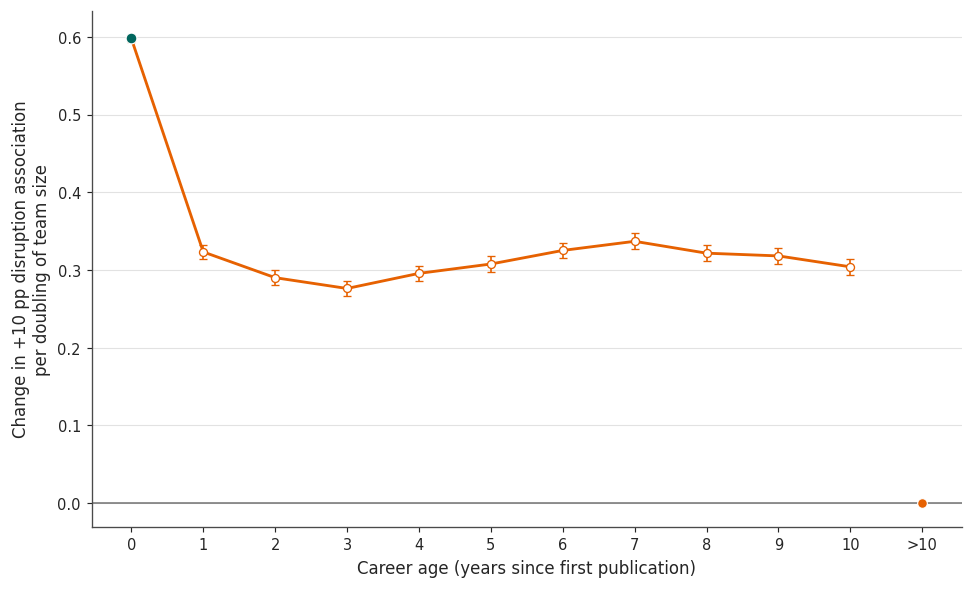

Saved figure data: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\FigureData_exact_career_age_team_size_amplification.csv
Saved figure: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\figures\selected_exact_career_age_effects_by_team_size.pdf


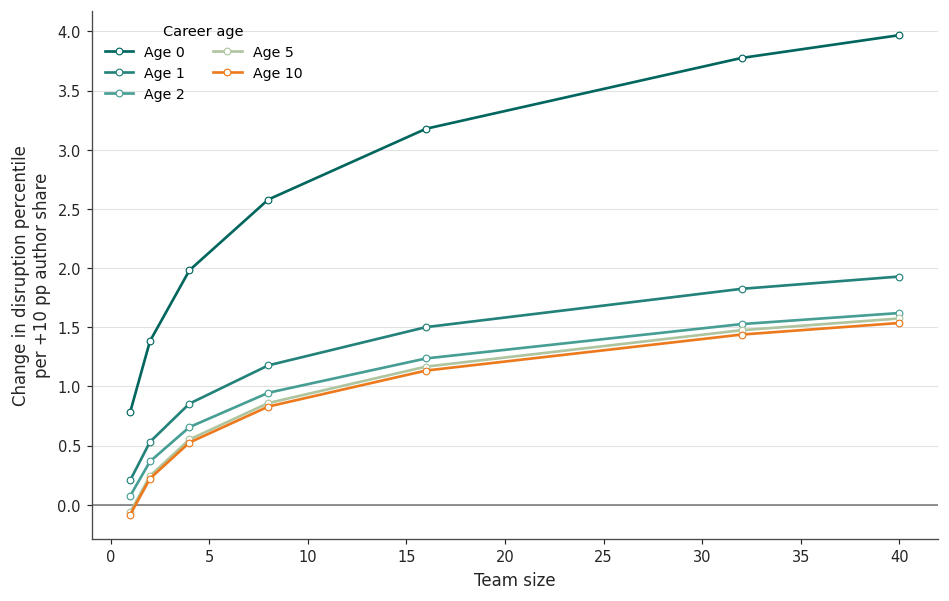

Saved figure data: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\FigureData_selected_exact_career_age_effects_by_team_size.csv


,career_age,amplification_per_doubling_per_10pp,ci95_low,ci95_high,p,n
0,0,0.598074,0.593087,0.603060,0.0,29054201
1,1,0.323302,0.314025,0.332580,0.0,29054201
2,2,0.290159,0.280759,0.299559,0.0,29054201
3,3,0.276270,0.266719,0.285820,0.0,29054201
4,4,0.295707,0.286011,0.305402,0.0,29054201
5,5,0.307756,0.297935,0.317576,0.0,29054201
6,6,0.325241,0.315295,0.335186,0.0,29054201
7,7,0.336978,0.326901,0.347056,0.0,29054201
8,8,0.321703,0.311474,0.331932,0.0,29054201
9,9,0.318178,0.307802,0.328554,0.0,29054201


,comparison,other_career_age,difference_in_amplification_per_doubling_per_10pp,se,ci95_low,ci95_high,t,p_raw,n,p_holm
0,Age 0 vs age 1,1,0.274771,0.005171,0.264637,0.284906,53.139176,0.0,29054201,0.0
1,Age 0 vs age 2,2,0.307914,0.005213,0.297697,0.318132,59.066088,0.0,29054201,0.0
2,Age 0 vs age 3,3,0.321804,0.005275,0.311464,0.332143,61.002303,0.0,29054201,0.0
3,Age 0 vs age 4,4,0.302367,0.005341,0.291898,0.312835,56.611914,0.0,29054201,0.0
4,Age 0 vs age 5,5,0.290318,0.005399,0.279736,0.300900,53.772106,0.0,29054201,0.0
5,Age 0 vs age 6,6,0.272833,0.005460,0.262131,0.283534,49.969330,0.0,29054201,0.0
6,Age 0 vs age 7,7,0.261095,0.005523,0.250270,0.271920,47.274341,0.0,29054201,0.0
7,Age 0 vs age 8,8,0.276371,0.005595,0.265404,0.287337,49.393402,0.0,29054201,0.0
8,Age 0 vs age 9,9,0.279896,0.005664,0.268794,0.290997,49.416385,0.0,29054201,0.0
9,Age 0 vs age 10,10,0.293940,0.005735,0.282699,0.305182,51.251007,0.0,29054201,0.0


,team_size,age0_minus_age1_per_10pp,se,ci95_low,ci95_high,n
0,1,0.577026,0.006591,0.564107,0.589945,29054201
1,2,0.851797,0.004529,0.842921,0.860673,29054201
2,4,1.126568,0.007145,1.112565,1.140572,29054201
3,8,1.401340,0.011621,1.378562,1.424118,29054201
4,16,1.676111,0.016509,1.643754,1.708468,29054201
5,32,1.950882,0.021529,1.908685,1.993079,29054201
6,40,2.039339,0.023159,1.993947,2.084731,29054201


In [67]:
# ============================================================
# 2) DOES TEAM-SIZE AMPLIFICATION CONCENTRATE AT PUBLICATION DEBUT?
# ============================================================

team_mask = (
    valid_exact_age.copy()
    & np.isfinite(
        np.asarray(
            A["disruption_percentile"],
            dtype=np.float64,
        )
    )
)

log2_team_full = np.log2(
    np.asarray(
        A["team_size"],
        dtype=np.float64,
    )
).astype(np.float32, copy=False)

team_exact_data = {
    "year": np.asarray(A["year"])[team_mask],
    "team_size": np.asarray(A["team_size"])[team_mask],
    "disruption_percentile": np.asarray(A["disruption_percentile"])[team_mask],
}

TEAM_EXACT_MAIN = []
TEAM_EXACT_INTERACTIONS = []

for a in range(11):
    main_name = f"career_age_{a}_ratio"
    int_name = f"career_age_{a}_x_log2teamsize"

    TEAM_EXACT_MAIN.append(main_name)
    TEAM_EXACT_INTERACTIONS.append(int_name)

    share = EXACT_SHARE_FULL[a][team_mask]

    team_exact_data[main_name] = share
    team_exact_data[int_name] = (
        share * log2_team_full[team_mask]
    ).astype(np.float32, copy=False)

team_exact_fe, team_exact_cov, team_exact_info = (
    fit_two_way_fe_model_full(
        team_exact_data,
        outcome="disruption_percentile",
        predictors=TEAM_EXACT_MAIN + TEAM_EXACT_INTERACTIONS,
    )
)

export_pub_table(
    team_exact_fe,
    "T85_exact_age_by_team_size_full_model",
)

amplification_rows = []

for a in range(11):
    term = f"career_age_{a}_x_log2teamsize"
    row = team_exact_fe[team_exact_fe["term"] == term].iloc[0]

    amplification_rows.append({
        "career_age": a,
        "amplification_per_doubling_per_10pp": 0.10 * row["coef"],
        "ci95_low": 0.10 * row["ci95_low"],
        "ci95_high": 0.10 * row["ci95_high"],
        "p": row["p"],
        "n": int(row["n"]),
    })

team_exact_amplification = pd.DataFrame(amplification_rows)

export_pub_table(
    team_exact_amplification,
    "T85b_exact_age_team_size_amplification",
)

amplification_contrast_rows = []

for a in range(1, 11):
    z = linear_combo_from_model(
        team_exact_fe,
        team_exact_cov,
        weights={
            "career_age_0_x_log2teamsize": 0.10,
            f"career_age_{a}_x_log2teamsize": -0.10,
        },
        label=f"Age 0 vs age {a}: amplification difference",
    )

    t_stat = z["estimate"] / z["se"]

    amplification_contrast_rows.append({
        "comparison": f"Age 0 vs age {a}",
        "other_career_age": a,
        "difference_in_amplification_per_doubling_per_10pp": z["estimate"],
        "se": z["se"],
        "ci95_low": z["ci95_low"],
        "ci95_high": z["ci95_high"],
        "t": t_stat,
        "p_raw": float(
            2 * stats.t.sf(
                abs(t_stat),
                df=team_exact_info["df_resid"],
            )
        ),
        "n": int(team_exact_fe["n"].iloc[0]),
    })

team_exact_amplification_contrasts = pd.DataFrame(
    amplification_contrast_rows
)

team_exact_amplification_contrasts["p_holm"] = multipletests(
    team_exact_amplification_contrasts["p_raw"].to_numpy(float),
    method="holm",
)[1]

export_pub_table(
    team_exact_amplification_contrasts,
    "T85c_debut_vs_exact_age_team_size_amplification",
)

key_team_sizes = [1, 2, 4, 8, 16, 32, 40]
simple_slope_rows = []

for a in range(11):
    for n_team in key_team_sizes:
        z = linear_combo_from_model(
            team_exact_fe,
            team_exact_cov,
            weights={
                f"career_age_{a}_ratio": 0.10,
                f"career_age_{a}_x_log2teamsize":
                    0.10 * math.log2(n_team),
            },
            label=f"Age {a}, team size {n_team}",
        )

        simple_slope_rows.append({
            "career_age": a,
            "team_size": n_team,
            "change_per_10pp": z["estimate"],
            "se": z["se"],
            "ci95_low": z["ci95_low"],
            "ci95_high": z["ci95_high"],
            "n": int(team_exact_fe["n"].iloc[0]),
        })

team_exact_simple_slopes = pd.DataFrame(simple_slope_rows)

export_pub_table(
    team_exact_simple_slopes,
    "T85d_exact_age_simple_slopes_by_team_size",
)

debut_vs_age1_by_team = []

for n_team in key_team_sizes:
    log2_n = math.log2(n_team)

    z = linear_combo_from_model(
        team_exact_fe,
        team_exact_cov,
        weights={
            "career_age_0_ratio": 0.10,
            "career_age_1_ratio": -0.10,
            "career_age_0_x_log2teamsize": 0.10 * log2_n,
            "career_age_1_x_log2teamsize": -0.10 * log2_n,
        },
        label=f"Age 0 vs age 1 at team size {n_team}",
    )

    debut_vs_age1_by_team.append({
        "team_size": n_team,
        "age0_minus_age1_per_10pp": z["estimate"],
        "se": z["se"],
        "ci95_low": z["ci95_low"],
        "ci95_high": z["ci95_high"],
        "n": int(team_exact_fe["n"].iloc[0]),
    })

team_exact_age0_vs_age1 = pd.DataFrame(debut_vs_age1_by_team)

export_pub_table(
    team_exact_age0_vs_age1,
    "T85e_age0_vs_age1_by_team_size",
)

fig, ax = plt.subplots(figsize=(8.2, 5.0))

x = team_exact_amplification["career_age"].to_numpy()
y = team_exact_amplification[
    "amplification_per_doubling_per_10pp"
].to_numpy()

yerr = np.vstack([
    y - team_exact_amplification["ci95_low"].to_numpy(),
    team_exact_amplification["ci95_high"].to_numpy() - y,
])

ax.errorbar(
    x,
    y,
    yerr=yerr,
    fmt="o-",
    color=ESTIMATE_COLOR,
    ecolor=ESTIMATE_COLOR,
    linewidth=1.7,
    elinewidth=1.0,
    capsize=2.3,
    markersize=4.8,
    markerfacecolor="white",
    markeredgecolor=ESTIMATE_COLOR,
    markeredgewidth=0.8,
    zorder=3,
)

age0_amp = team_exact_amplification[
    team_exact_amplification["career_age"] == 0
].iloc[0]

ax.scatter(
    [0],
    [age0_amp["amplification_per_doubling_per_10pp"]],
    s=42,
    color=COLORS["teal"],
    edgecolor="white",
    linewidth=0.7,
    zorder=4,
)

ax.scatter(
    [11],
    [0],
    s=34,
    color=COLORS["orange"],
    edgecolor="white",
    linewidth=0.7,
    zorder=4,
)

add_zero_line(ax)
apply_science_axes(ax)

ax.set_xticks(np.arange(12))
ax.set_xticklabels([str(a) for a in range(11)] + [">10"])
ax.set_xlabel("Career age (years since first publication)")
ax.set_ylabel(
    "Change in +10 pp disruption association\n"
    "per doubling of team size"
)

plt.tight_layout()

save_pub_figure(
    fig,
    "exact_career_age_team_size_amplification",
)

plt.show()

export_figure_data(
    team_exact_amplification,
    "exact_career_age_team_size_amplification",
)

selected_ages = [0, 1, 2, 5, 10]

if "career_age_cmap" in globals():
    selected_colors = {
        a: career_age_cmap(a / 11)
        for a in selected_ages
    }
else:
    fallback_cmap = mpl.colors.LinearSegmentedColormap.from_list(
        "exact_age_team_size",
        [
            COLORS["teal"],
            COLORS["mint"],
            COLORS["pale_orange"],
            COLORS["orange"],
        ],
    )
    selected_colors = {
        a: fallback_cmap(a / 11)
        for a in selected_ages
    }

fig, ax = plt.subplots(figsize=(8.0, 5.1))

for a in selected_ages:
    g = (
        team_exact_simple_slopes[
            team_exact_simple_slopes["career_age"] == a
        ]
        .sort_values("team_size")
    )

    ax.plot(
        g["team_size"],
        g["change_per_10pp"],
        marker="o",
        markersize=4.0,
        markerfacecolor="white",
        markeredgecolor=selected_colors[a],
        markeredgewidth=0.7,
        linewidth=1.6,
        color=selected_colors[a],
        label=f"Age {a}",
    )

add_zero_line(ax)
apply_science_axes(ax)

ax.set_xlabel("Team size")
ax.set_ylabel(
    "Change in disruption percentile\n"
    "per +10 pp author share"
)
ax.legend(title="Career age", ncol=2)

plt.tight_layout()

save_pub_figure(
    fig,
    "selected_exact_career_age_effects_by_team_size",
)

plt.show()

export_figure_data(
    team_exact_simple_slopes[
        team_exact_simple_slopes["career_age"].isin(selected_ages)
    ],
    "selected_exact_career_age_effects_by_team_size",
)

display(team_exact_amplification)
display(team_exact_amplification_contrasts)
display(team_exact_age0_vs_age1)


Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T86_exact_age_reference_popularity_profile.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T86_exact_age_reference_popularity_profile.tex
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T86_exact_age_reference_popularity_debut_contrasts.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T86_exact_age_reference_popularity_debut_contrasts.tex
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T86_exact_age_reference_popularity_extrapolation.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T86_exact_age_reference_popularity_extrapolation.tex
Saved figure data: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\FigureData_exact_career_age_reference_popularity_coefficients.csv
Saved figure: D:

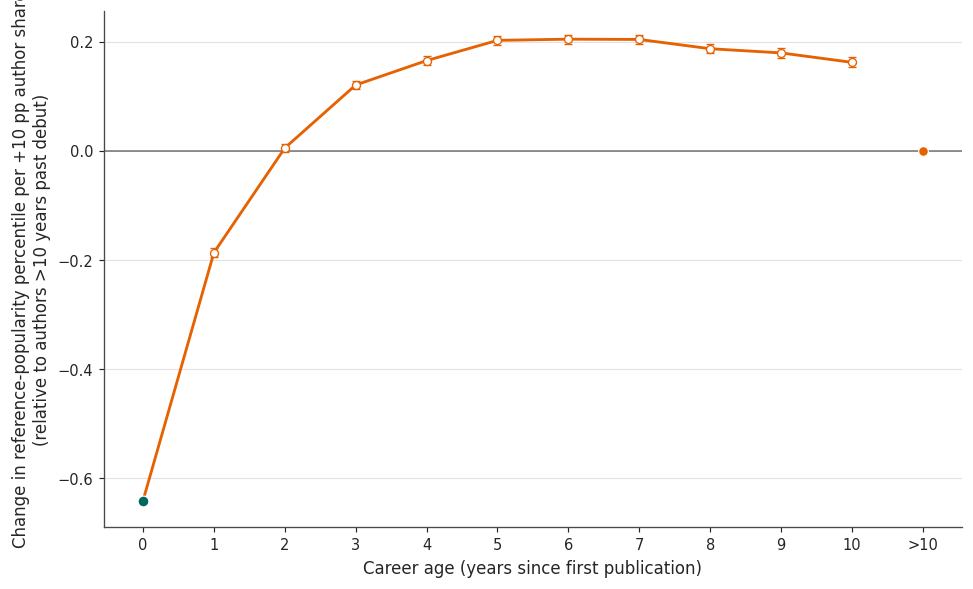


EXACT-AGE REFERENCE POPULARITY
N = 29,054,201
Age 0, +10pp: -0.6416 [-0.6463, -0.6370]
Age 1, +10pp: -0.1870 [-0.1950, -0.1790]
Age 0 - age 1, +10pp: -0.4547 [-0.4634, -0.4460]


,term,coef,robust_se_HC1,t,p,ci95_low,ci95_high,n,career_age,change_per_10pp,change_per_10pp_ci95_low,change_per_10pp_ci95_high
0,career_age_0_ratio,-6.416499,0.023535,-272.632531,0.000000e+00,-6.462627,-6.370370,29054201,0,-0.641650,-0.646263,-0.637037
1,career_age_1_ratio,-1.869680,0.040812,-45.811578,0.000000e+00,-1.949671,-1.789689,29054201,1,-0.186968,-0.194967,-0.178969
2,career_age_2_ratio,0.048563,0.040884,1.187812,2.349074e-01,-0.031569,0.128694,29054201,2,0.004856,-0.003157,0.012869
3,career_age_3_ratio,1.203780,0.041307,29.142046,1.060219e-186,1.122819,1.284741,29054201,3,0.120378,0.112282,0.128474
4,career_age_4_ratio,1.651473,0.041680,39.622308,0.000000e+00,1.569781,1.733165,29054201,4,0.165147,0.156978,0.173317
5,career_age_5_ratio,2.022269,0.042155,47.972111,0.000000e+00,1.939647,2.104892,29054201,5,0.202227,0.193965,0.210489
6,career_age_6_ratio,2.044168,0.042540,48.053126,0.000000e+00,1.960792,2.127545,29054201,6,0.204417,0.196079,0.212754
7,career_age_7_ratio,2.039162,0.043165,47.241469,0.000000e+00,1.954561,2.123764,29054201,7,0.203916,0.195456,0.212376
8,career_age_8_ratio,1.868964,0.043850,42.621678,0.000000e+00,1.783019,1.954908,29054201,8,0.186896,0.178302,0.195491
9,career_age_9_ratio,1.792332,0.044566,40.217911,0.000000e+00,1.704985,1.879678,29054201,9,0.179233,0.170498,0.187968


,comparison,other_career_age,difference_per_10pp,se,ci95_low,ci95_high,t,p_raw,n,p_holm
0,Age 0 vs age 1,1,-0.454682,0.004426,-0.463357,-0.446007,-102.726889,0.0,29054201,0.0
1,Age 0 vs age 2,2,-0.646506,0.004430,-0.655188,-0.637824,-145.953227,0.0,29054201,0.0
2,Age 0 vs age 3,3,-0.762028,0.004473,-0.770795,-0.753261,-170.367196,0.0,29054201,0.0
3,Age 0 vs age 4,4,-0.806797,0.004514,-0.815645,-0.797950,-178.732826,0.0,29054201,0.0
4,Age 0 vs age 5,5,-0.843877,0.004566,-0.852826,-0.834928,-184.824614,0.0,29054201,0.0
5,Age 0 vs age 6,6,-0.846067,0.004610,-0.855102,-0.837031,-183.534527,0.0,29054201,0.0
6,Age 0 vs age 7,7,-0.845566,0.004675,-0.854729,-0.836403,-180.864178,0.0,29054201,0.0
7,Age 0 vs age 8,8,-0.828546,0.004745,-0.837846,-0.819247,-174.626867,0.0,29054201,0.0
8,Age 0 vs age 9,9,-0.820883,0.004815,-0.830321,-0.811445,-170.475697,0.0,29054201,0.0
9,Age 0 vs age 10,10,-0.803584,0.004888,-0.813165,-0.794003,-164.387413,0.0,29054201,0.0


,trajectory_used,observed_age0_per_10pp,extrapolated_age0_per_10pp,observed_minus_extrapolated_per_10pp,se_per_10pp,ci95_low_per_10pp,ci95_high_per_10pp,t,p,n
0,career ages 1-5,-0.64165,-0.222390,-0.419260,0.004620,-0.428314,-0.410206,-90.757007,0.0,29054201
1,career ages 1-10,-0.64165,-0.045611,-0.596039,0.003435,-0.602771,-0.589307,-173.534409,0.0,29054201


In [68]:
# ============================================================
# 3) REFERENCE POPULARITY AT EXACT CAREER AGES
# Lower percentile = less-popular / less-canonical cited sources.
# ============================================================

exact_reference_popularity = run_exact_age_secondary(
    outcome="avg_reference_popularity_percentile",
    label="Exact-age reference popularity",
    ylabel=(
        "Change in reference-popularity percentile per +10 pp author share\n"
        "(relative to authors >10 years past debut)"
    ),
    table_prefix="T86_exact_age_reference_popularity",
    figure_stem="exact_career_age_reference_popularity_coefficients",
)

display(exact_reference_popularity["model"])
display(exact_reference_popularity["contrasts"])
display(exact_reference_popularity["extrapolation"])


Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T87_exact_age_C10_profile.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T87_exact_age_C10_profile.tex
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T87_exact_age_C10_debut_contrasts.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T87_exact_age_C10_debut_contrasts.tex
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T87_exact_age_C10_extrapolation.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T87_exact_age_C10_extrapolation.tex
Saved figure data: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\FigureData_exact_career_age_C10_coefficients.csv
Saved figure: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\figures\exact_career_age_C10_coefficients.pdf


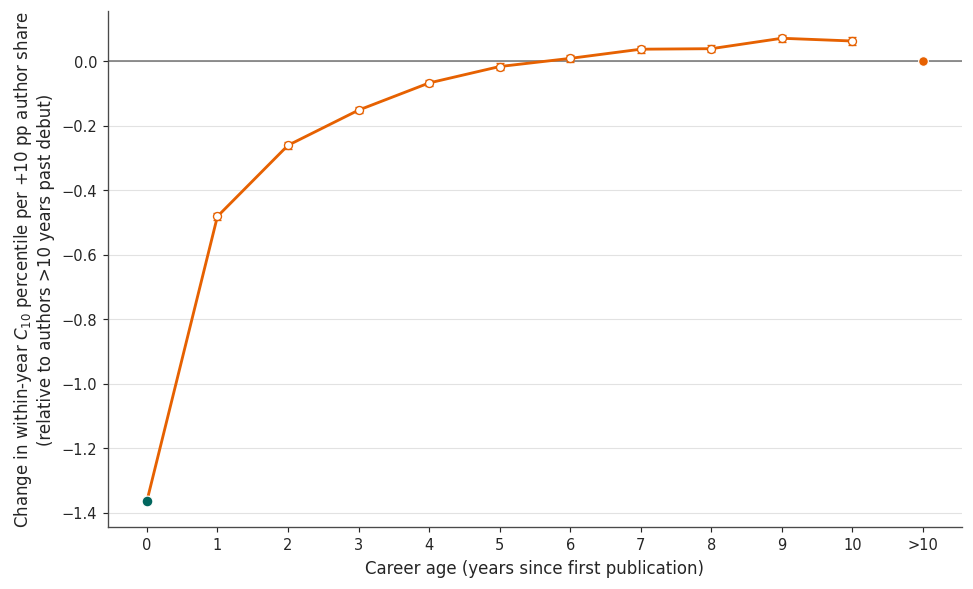


EXACT-AGE FIXED-WINDOW CITATION IMPACT
N = 15,956,458
Age 0, +10pp: -1.3646 [-1.3702, -1.3589]
Age 1, +10pp: -0.4818 [-0.4917, -0.4719]
Age 0 - age 1, +10pp: -0.8828 [-0.8933, -0.8722]


,term,coef,robust_se_HC1,t,p,ci95_low,ci95_high,n,career_age,change_per_10pp,change_per_10pp_ci95_low,change_per_10pp_ci95_high
0,career_age_0_ratio,-13.645634,0.028846,-473.046179,0.000000e+00,-13.702171,-13.589096,15956458,0,-1.364563,-1.370217,-1.358910
1,career_age_1_ratio,-4.817895,0.050609,-95.199048,0.000000e+00,-4.917086,-4.718704,15956458,1,-0.481789,-0.491709,-0.471870
2,career_age_2_ratio,-2.614288,0.050631,-51.634534,0.000000e+00,-2.713522,-2.515053,15956458,2,-0.261429,-0.271352,-0.251505
3,career_age_3_ratio,-1.523590,0.051579,-29.539182,9.152287e-192,-1.624682,-1.422497,15956458,3,-0.152359,-0.162468,-0.142250
4,career_age_4_ratio,-0.680750,0.052475,-12.972794,1.746279e-38,-0.783600,-0.577901,15956458,4,-0.068075,-0.078360,-0.057790
5,career_age_5_ratio,-0.171896,0.053392,-3.219500,1.284148e-03,-0.276543,-0.067249,15956458,5,-0.017190,-0.027654,-0.006725
6,career_age_6_ratio,0.080791,0.054225,1.489926,1.362436e-01,-0.025488,0.187069,15956458,6,0.008079,-0.002549,0.018707
7,career_age_7_ratio,0.365425,0.055282,6.610246,3.836951e-11,0.257075,0.473775,15956458,7,0.036542,0.025708,0.047377
8,career_age_8_ratio,0.381268,0.056338,6.767523,1.310099e-11,0.270848,0.491688,15956458,8,0.038127,0.027085,0.049169
9,career_age_9_ratio,0.704405,0.057579,12.233773,2.052548e-34,0.591553,0.817258,15956458,9,0.070441,0.059155,0.081726


,comparison,other_career_age,difference_per_10pp,se,ci95_low,ci95_high,t,p_raw,n,p_holm
0,Age 0 vs age 1,1,-0.882774,0.005394,-0.893346,-0.872202,-163.667522,0.0,15956458,0.0
1,Age 0 vs age 2,2,-1.103135,0.005398,-1.113714,-1.092555,-204.364276,0.0,15956458,0.0
2,Age 0 vs age 3,3,-1.212204,0.005495,-1.222975,-1.201434,-220.591561,0.0,15956458,0.0
3,Age 0 vs age 4,4,-1.296488,0.005591,-1.307446,-1.285530,-231.895225,0.0,15956458,0.0
4,Age 0 vs age 5,5,-1.347374,0.005687,-1.358521,-1.336226,-236.900946,0.0,15956458,0.0
5,Age 0 vs age 6,6,-1.372642,0.005778,-1.383967,-1.361318,-237.568390,0.0,15956458,0.0
6,Age 0 vs age 7,7,-1.401106,0.005887,-1.412644,-1.389568,-238.009616,0.0,15956458,0.0
7,Age 0 vs age 8,8,-1.402690,0.005994,-1.414439,-1.390942,-234.013505,0.0,15956458,0.0
8,Age 0 vs age 9,9,-1.435004,0.006118,-1.446995,-1.423013,-234.562339,0.0,15956458,0.0
9,Age 0 vs age 10,10,-1.426500,0.006222,-1.438694,-1.414306,-229.285464,0.0,15956458,0.0


,trajectory_used,observed_age0_per_10pp,extrapolated_age0_per_10pp,observed_minus_extrapolated_per_10pp,se_per_10pp,ci95_low_per_10pp,ci95_high_per_10pp,t,p,n
0,career ages 1-5,-1.364563,-0.535729,-0.828834,0.005655,-0.839919,-0.817750,-146.558313,0.0,15956458
1,career ages 1-10,-1.364563,-0.372731,-0.991832,0.004191,-1.000047,-0.983618,-236.651507,0.0,15956458


,outcome,n,age0_per_10pp,age1_per_10pp,age0_minus_age1_per_10pp,age0_minus_age1_ci95_low,age0_minus_age1_ci95_high,age0_minus_1to5_extrapolated_per_10pp,extrapolation_ci95_low,extrapolation_ci95_high
0,Disruption percentile,29054201,1.348950,0.509749,0.839201,0.830327,0.848076,0.820592,0.811344,0.829841
1,Atypicality percentile,23656798,-0.793108,-0.338996,-0.454112,-0.464162,-0.444062,-0.434511,-0.444938,-0.424083
2,Reference-popularity percentile,29054201,-0.641650,-0.186968,-0.454682,-0.463357,-0.446007,-0.419260,-0.428314,-0.410206
3,Within-year C10 percentile,15956458,-1.364563,-0.481789,-0.882774,-0.893346,-0.872202,-0.828834,-0.839919,-0.817750


Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T88_cross_outcome_exact_age_debut_boundary_summary.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T88_cross_outcome_exact_age_debut_boundary_summary.tex
All four planned exact-age extensions are complete.


In [69]:
# ============================================================
# 4) FIXED-WINDOW CITATION IMPACT AT EXACT CAREER AGES
# Outcome: within-year C10 percentile; publication years <= 2010.
# ============================================================

c10_exact_mask = (
    np.asarray(A["year"])
    <= C10_COMPLETE_THROUGH
)

exact_c10 = run_exact_age_secondary(
    outcome="C10_percentile_within_year",
    label="Exact-age fixed-window citation impact",
    ylabel=(
        "Change in within-year $C_{10}$ percentile per +10 pp author share\n"
        "(relative to authors >10 years past debut)"
    ),
    table_prefix="T87_exact_age_C10",
    figure_stem="exact_career_age_C10_coefficients",
    base_mask=c10_exact_mask,
)

display(exact_c10["model"])
display(exact_c10["contrasts"])
display(exact_c10["extrapolation"])


def _age01_summary(result, outcome_label):
    model = result["model"]
    contrasts = result["contrasts"]
    extrap = result["extrapolation"]

    age0 = model[
        model["career_age"] == 0
    ].iloc[0]

    age1 = model[
        model["career_age"] == 1
    ].iloc[0]

    c01 = contrasts[
        contrasts["other_career_age"] == 1
    ].iloc[0]

    x15 = extrap[
        extrap["trajectory_used"] == "career ages 1-5"
    ].iloc[0]

    return {
        "outcome": outcome_label,
        "n": int(model["n"].iloc[0]),
        "age0_per_10pp": age0["change_per_10pp"],
        "age1_per_10pp": age1["change_per_10pp"],
        "age0_minus_age1_per_10pp": c01["difference_per_10pp"],
        "age0_minus_age1_ci95_low": c01["ci95_low"],
        "age0_minus_age1_ci95_high": c01["ci95_high"],
        "age0_minus_1to5_extrapolated_per_10pp":
            x15["observed_minus_extrapolated_per_10pp"],
        "extrapolation_ci95_low": x15["ci95_low_per_10pp"],
        "extrapolation_ci95_high": x15["ci95_high_per_10pp"],
    }


disruption_extrap_for_summary = smooth_extrapolation.rename(
    columns={
        "age0_minus_extrapolated_per_10pp":
            "observed_minus_extrapolated_per_10pp"
    }
)

cross_outcome_exact_age_summary = pd.DataFrame([
    _age01_summary(
        {
            "model": exact_age_fe,
            "contrasts": debut_vs_exact_age,
            "extrapolation": disruption_extrap_for_summary,
        },
        "Disruption percentile",
    ),
    _age01_summary(
        exact_atypicality,
        "Atypicality percentile",
    ),
    _age01_summary(
        exact_reference_popularity,
        "Reference-popularity percentile",
    ),
    _age01_summary(
        exact_c10,
        "Within-year C10 percentile",
    ),
])

display(cross_outcome_exact_age_summary)

export_pub_table(
    cross_outcome_exact_age_summary,
    "T88_cross_outcome_exact_age_debut_boundary_summary",
)

print("All four planned exact-age extensions are complete.")


# Structure-preserving randomization tests

The exact-age shares are constrained by integer author counts, team size, and
the requirement that all career-age shares sum to one. Two matched
randomization tests examine whether these compositional constraints alone can
produce the sharp difference between publication debut and career age 1.

**Null 1** preserves publication year, exact team size, each paper's combined
age-0/age-1 representation, and exact shares at ages 2–10, while randomizing
how the fixed age-0/age-1 total is divided between debutants and age-1 authors
within matched strata.

**Null 2** preserves publication year, exact team size, and the total number of
authors at career ages 0–10, while reassigning complete observed age-0–10
composition vectors within matched strata.

For the family-wise adjacent-age test, all ten adjacent career-age contrasts
from 0–1 through 9–10 are evaluated together. The Monte Carlo procedure tests
whether the observed standardized 0–1 transition exceeds the largest absolute
adjacent transition expected anywhere along the first post-debut decade.

In [70]:
# ============================================================
# STRUCTURE-PRESERVING CAREER-AGE NULL MODELS
#
# Append after the fully executed v9 notebook.
#
# Null 1:
#   Is the age-0 vs age-1 distinction meaningful once we preserve
#   publication year, exact team size, each paper's combined number
#   of age-{0,1} authors, all older exact-age composition, and the
#   empirical distribution of age-0 counts?
#
# Null 2:
#   Is the age-0 "cliff" unusual once we preserve publication year,
#   exact team size, each paper's total number of age-0...10 authors,
#   and the complete empirical distribution of exact-age composition
#   vectors within those matched strata?
#
# Both nulls leave all scientific outcomes untouched.
#
# Computational note:
#   With ~29 million papers, literal thousands of full-data shuffles
#   would be wasteful. The code uses the exact first two moments of
#   the corresponding matched permutation distributions. For the
#   max-adjacent-jump test in Null 2, it draws from the multivariate
#   Gaussian limit implied by that exact permutation covariance.
# ============================================================

import gc
from time import perf_counter

NULL_RANDOM_SEED = 20260927
NULL2_GAUSSIAN_DRAWS = 200_000

required_null_objects = [
    "A",
    "exact_age",
    "valid_exact_age",
    "EXACT_SHARE_FULL",
    "residualize_two_way_exact",
    "export_pub_table",
    "save_pub_figure",
    "export_figure_data",
]

missing_null_objects = [
    name for name in required_null_objects
    if name not in globals()
]

if missing_null_objects:
    raise RuntimeError(
        "Run the complete v9 notebook, including the exact-age extension "
        f"cells, before these null models. Missing: {missing_null_objects}"
    )

if int(valid_exact_age.sum()) != 29_054_201:
    raise RuntimeError(
        "These cells assume the current exact-age handoff with "
        "29,054,201 complete papers."
    )

EXACT_COUNT_FULL = {
    a: (
        exact_age[f"career_age_{a}_count"]
        .to_numpy()
        .astype(np.int16, copy=False)
    )
    for a in range(11)
}

EXACT_11PLUS_COUNT_FULL = (
    exact_age["career_age_11plus_count"]
    .to_numpy()
    .astype(np.int16, copy=False)
)

YEAR_FULL = np.asarray(A["year"])
TEAM_FULL = np.asarray(A["team_size"]).astype(np.int16, copy=False)

_NULL_YEAR_MIN = int(np.nanmin(YEAR_FULL))
_NULL_TEAM_BASE = int(MAX_TEAM_SIZE) + 1


NULL_OUTCOMES = [
    {
        "label": "Disruption",
        "outcome": "disruption_percentile",
        "base_mask": None,
        "main_result": {
            "age01": float(
                debut_vs_exact_age.loc[
                    debut_vs_exact_age["other_career_age"] == 1,
                    "difference_per_10pp",
                ].iloc[0]
            ),
            "extrap_1_5": float(
                smooth_extrapolation.loc[
                    smooth_extrapolation["trajectory_used"] == "career ages 1-5",
                    "age0_minus_extrapolated_per_10pp",
                ].iloc[0]
            ),
        },
    },
    {
        "label": "Atypicality",
        "outcome": "Atyp_Median_Z_percentile",
        "base_mask": None,
        "main_result": {
            "age01": float(
                exact_atypicality["contrasts"].loc[
                    exact_atypicality["contrasts"]["other_career_age"] == 1,
                    "difference_per_10pp",
                ].iloc[0]
            ),
            "extrap_1_5": float(
                exact_atypicality["extrapolation"].loc[
                    exact_atypicality["extrapolation"]["trajectory_used"]
                    == "career ages 1-5",
                    "observed_minus_extrapolated_per_10pp",
                ].iloc[0]
            ),
        },
    },
    {
        "label": "Reference popularity",
        "outcome": "avg_reference_popularity_percentile",
        "base_mask": None,
        "main_result": {
            "age01": float(
                exact_reference_popularity["contrasts"].loc[
                    exact_reference_popularity["contrasts"]["other_career_age"] == 1,
                    "difference_per_10pp",
                ].iloc[0]
            ),
            "extrap_1_5": float(
                exact_reference_popularity["extrapolation"].loc[
                    exact_reference_popularity["extrapolation"]["trajectory_used"]
                    == "career ages 1-5",
                    "observed_minus_extrapolated_per_10pp",
                ].iloc[0]
            ),
        },
    },
    {
        "label": "Citation impact",
        "outcome": "C10_percentile_within_year",
        "base_mask": (YEAR_FULL <= C10_COMPLETE_THROUGH),
        "main_result": {
            "age01": float(
                exact_c10["contrasts"].loc[
                    exact_c10["contrasts"]["other_career_age"] == 1,
                    "difference_per_10pp",
                ].iloc[0]
            ),
            "extrap_1_5": float(
                exact_c10["extrapolation"].loc[
                    exact_c10["extrapolation"]["trajectory_used"]
                    == "career ages 1-5",
                    "observed_minus_extrapolated_per_10pp",
                ].iloc[0]
            ),
        },
    },
]


def _two_sided_normal_log10p(z):
    z = abs(float(z))
    logp = np.log(2.0) + stats.norm.logsf(z)
    return float(logp / np.log(10.0))


def _matched_stratum_code(year, team_size, matched_count):
    """
    Unique integer code for:
        publication year x exact team size x matched author count.
    """
    return (
        (
            (year.astype(np.int64) - _NULL_YEAR_MIN)
            * _NULL_TEAM_BASE
            + team_size.astype(np.int64)
        )
        * _NULL_TEAM_BASE
        + matched_count.astype(np.int64)
    )


def _null1_nuisance_residual(outcome, base_mask=None):
    """
    Residualize the outcome against:
      - publication-year FE
      - exact-team-size FE
      - combined share at career ages {0,1}
      - exact shares at ages 2,...,10

    This reparameterizes the main exact-age model so that the remaining
    age-0-vs-age-1 contrast is isolated from all older exact-age shares.
    """
    mask = valid_exact_age.copy()

    if base_mask is not None:
        mask &= np.asarray(base_mask, dtype=bool)

    y_full = np.asarray(A[outcome], dtype=np.float64)
    mask &= np.isfinite(y_full)

    idx = np.flatnonzero(mask)

    team = TEAM_FULL[idx].astype(np.float64, copy=False)
    year = YEAR_FULL[idx]

    s01 = (
        EXACT_SHARE_FULL[0][idx].astype(np.float64, copy=False)
        + EXACT_SHARE_FULL[1][idx].astype(np.float64, copy=False)
    )

    n = len(idx)

    # y + 10 nuisance predictors:
    # S_{0+1}, then S_2,...,S_10
    M = np.empty((n, 11), dtype=np.float64)
    M[:, 0] = y_full[idx]
    M[:, 1] = s01

    for j, age in enumerate(range(2, 11), start=2):
        M[:, j] = EXACT_SHARE_FULL[age][idx]

    R, _ = residualize_two_way_exact(
        M,
        year,
        TEAM_FULL[idx],
    )

    y_r = R[:, 0]
    X_r = R[:, 1:]

    XtX = X_r.T @ X_r
    Xty = X_r.T @ y_r
    beta = np.linalg.pinv(XtX) @ Xty

    resid = (
        y_r - X_r @ beta
    ).astype(np.float64, copy=False)

    del M, R, X_r, y_r, XtX, Xty, beta
    gc.collect()

    return idx, resid


def _null1_one_outcome(spec):
    """
    Matched age-0/age-1 permutation null.

    Matching strata:
        publication year x exact team size x (n_age0 + n_age1)

    Within every stratum, the observed age-0 counts are exchangeable
    across papers. Age-1 count is then m01 - age0 count.

    This exactly preserves:
      * year
      * team size
      * each paper's total age-{0,1} mass
      * each paper's ages 2...10 and >10 composition
      * the full empirical distribution of age-0 counts within stratum

    The test statistic is the matched slope for age-0 share after
    nuisance residualization. Because m01 is fixed in each stratum,
    it is directly an age-0-versus-age-1 contrast.
    """
    t0 = perf_counter()

    idx, resid = _null1_nuisance_residual(
        spec["outcome"],
        spec["base_mask"],
    )

    c0 = EXACT_COUNT_FULL[0][idx].astype(np.int16, copy=False)
    c1 = EXACT_COUNT_FULL[1][idx].astype(np.int16, copy=False)
    m01 = (c0 + c1).astype(np.int16, copy=False)

    eligible = m01 > 0

    idx = idx[eligible]
    resid = resid[eligible]
    c0 = c0[eligible]
    m01 = m01[eligible]

    year = YEAR_FULL[idx]
    team = TEAM_FULL[idx]

    x = (
        c0.astype(np.float64)
        / team.astype(np.float64)
    )

    code = _matched_stratum_code(
        year,
        team,
        m01,
    )

    n_bins = int(code.max()) + 1

    n_g = np.bincount(
        code,
        minlength=n_bins,
    ).astype(np.float64)

    sx = np.bincount(
        code,
        weights=x,
        minlength=n_bins,
    )

    sy = np.bincount(
        code,
        weights=resid,
        minlength=n_bins,
    )

    sxx_raw = np.bincount(
        code,
        weights=x * x,
        minlength=n_bins,
    )

    syy_raw = np.bincount(
        code,
        weights=resid * resid,
        minlength=n_bins,
    )

    sxy_raw = np.bincount(
        code,
        weights=x * resid,
        minlength=n_bins,
    )

    valid_g = n_g >= 2

    Sxx = np.zeros(n_bins, dtype=np.float64)
    Syy = np.zeros(n_bins, dtype=np.float64)
    Sxy = np.zeros(n_bins, dtype=np.float64)

    Sxx[valid_g] = (
        sxx_raw[valid_g]
        - sx[valid_g] ** 2 / n_g[valid_g]
    )

    Syy[valid_g] = (
        syy_raw[valid_g]
        - sy[valid_g] ** 2 / n_g[valid_g]
    )

    Sxy[valid_g] = (
        sxy_raw[valid_g]
        - sx[valid_g] * sy[valid_g] / n_g[valid_g]
    )

    permutable_g = (
        valid_g
        & (Sxx > 1e-14)
    )

    denom = float(
        Sxx[permutable_g].sum()
    )

    numerator_obs = float(
        Sxy[permutable_g].sum()
    )

    if denom <= 0:
        raise RuntimeError(
            f"Null 1 has no identifying variation for {spec['label']}."
        )

    # Exact finite-population permutation variance of the matched
    # cross-product under within-stratum permutation of x.
    var_numerator = float(
        np.sum(
            (
                Sxx[permutable_g]
                * Syy[permutable_g]
                / (n_g[permutable_g] - 1.0)
            )
        )
    )

    beta_obs = numerator_obs / denom
    se_null = math.sqrt(
        max(var_numerator, 0.0)
    ) / denom

    effect10 = 0.10 * beta_obs
    se10 = 0.10 * se_null

    z = (
        effect10 / se10
        if se10 > 0
        else np.nan
    )

    result = {
        "outcome": spec["label"],
        "n_complete_outcome": int(len(idx)),
        "n_permutable_strata": int(permutable_g.sum()),
        "n_papers_in_permutable_strata": int(
            n_g[permutable_g].sum()
        ),
        "main_model_age0_minus_age1_per_10pp":
            spec["main_result"]["age01"],
        "matched_null_stat_age0_minus_age1_per_10pp":
            effect10,
        "null_mean": 0.0,
        "null_se": se10,
        "null_ci95_low": -1.96 * se10,
        "null_ci95_high": 1.96 * se10,
        "z_against_null": z,
        "log10_p_two_sided": (
            _two_sided_normal_log10p(z)
            if np.isfinite(z)
            else np.nan
        ),
        "runtime_seconds": perf_counter() - t0,
    }

    del idx, resid, c0, m01, year, team, x, code
    del n_g, sx, sy, sxx_raw, syy_raw, sxy_raw, Sxx, Syy, Sxy
    gc.collect()

    return result


def _null2_one_outcome(spec, n_draws=NULL2_GAUSSIAN_DRAWS):
    """
    Full exact-age composition null.

    Matching strata:
        publication year x exact team size x total number of authors
        at career ages 0,...,10.

    Within each stratum, the *entire observed 11-dimensional exact-age
    composition vector* is exchangeable across papers.

    This is deliberately conservative:
      * each paper retains year and team size;
      * each paper retains its total age-0...10 author count;
      * the empirical multivariate distribution of exact-age composition
        vectors is preserved exactly within every matched stratum;
      * only the pairing between exact-age composition and scientific
        outcome is broken.

    Because X'X is invariant to row permutation, the permutation
    covariance of the coefficient profile can be obtained from matched
    within-stratum cross-products without materializing thousands of
    29-million-row shuffles.
    """
    t0 = perf_counter()

    mask = valid_exact_age.copy()

    if spec["base_mask"] is not None:
        mask &= np.asarray(
            spec["base_mask"],
            dtype=bool,
        )

    y_full = np.asarray(
        A[spec["outcome"]],
        dtype=np.float64,
    )

    mask &= np.isfinite(y_full)

    early_total_full = np.zeros(
        len(mask),
        dtype=np.int16,
    )

    for age in range(11):
        early_total_full += EXACT_COUNT_FULL[age]

    mask &= early_total_full > 0

    idx = np.flatnonzero(mask)

    y = y_full[idx]
    year = YEAR_FULL[idx]
    team = TEAM_FULL[idx]
    early_total = early_total_full[idx]

    code = _matched_stratum_code(
        year,
        team,
        early_total,
    )

    n_bins = int(code.max()) + 1

    n_g = np.bincount(
        code,
        minlength=n_bins,
    ).astype(np.float64)

    sy = np.bincount(
        code,
        weights=y,
        minlength=n_bins,
    )

    syy_raw = np.bincount(
        code,
        weights=y * y,
        minlength=n_bins,
    )

    mean_y_g = np.zeros(
        n_bins,
        dtype=np.float64,
    )

    nonempty = n_g > 0

    mean_y_g[nonempty] = (
        sy[nonempty]
        / n_g[nonempty]
    )

    y_c = (
        y - mean_y_g[code]
    )

    Syy_g = np.zeros(
        n_bins,
        dtype=np.float64,
    )

    valid_g = n_g >= 2

    Syy_g[valid_g] = (
        syy_raw[valid_g]
        - sy[valid_g] ** 2 / n_g[valid_g]
    )

    # Build and within-stratum-center the exact-age share matrix.
    n = len(idx)
    Xc = np.empty(
        (n, 11),
        dtype=np.float64,
    )

    for age in range(11):
        x = (
            EXACT_COUNT_FULL[age][idx].astype(np.float64)
            / team.astype(np.float64)
        )

        sx = np.bincount(
            code,
            weights=x,
            minlength=n_bins,
        )

        mean_x_g = np.zeros(
            n_bins,
            dtype=np.float64,
        )

        mean_x_g[nonempty] = (
            sx[nonempty]
            / n_g[nonempty]
        )

        Xc[:, age] = (
            x - mean_x_g[code]
        )

    # Observed matched exact-age profile.
    G = Xc.T @ Xc
    h = Xc.T @ y_c

    G_inv = np.linalg.pinv(
        G,
        rcond=1e-12,
    )

    beta = G_inv @ h

    # Exact first-two-moment permutation covariance:
    #
    # Var(X_s' P_s y_s | X_s, y_s)
    #   = [Syy_s / (n_s - 1)] X_s'X_s
    #
    # summed over independent matched strata.
    q_g = np.zeros(
        n_bins,
        dtype=np.float64,
    )

    q_g[valid_g] = (
        Syy_g[valid_g]
        / (n_g[valid_g] - 1.0)
    )

    Vh = np.zeros(
        (11, 11),
        dtype=np.float64,
    )

    chunk = 1_000_000

    for start in range(0, n, chunk):
        stop = min(
            start + chunk,
            n,
        )

        Xch = Xc[start:stop]
        q = q_g[
            code[start:stop]
        ]

        Vh += (
            Xch.T
            @ (
                Xch
                * q[:, None]
            )
        )

    cov_beta = (
        G_inv
        @ Vh
        @ G_inv.T
    )

    cov_beta = (
        cov_beta
        + cov_beta.T
    ) / 2.0

    # --------------------------------------------------------
    # A. Direct age-0 vs age-1 contrast
    # --------------------------------------------------------
    c01 = np.zeros(
        11,
        dtype=np.float64,
    )
    c01[0] = 0.10
    c01[1] = -0.10

    age01_obs = float(
        c01 @ beta
    )

    age01_se = math.sqrt(
        max(
            float(
                c01
                @ cov_beta
                @ c01
            ),
            0.0,
        )
    )

    age01_z = (
        age01_obs / age01_se
        if age01_se > 0
        else np.nan
    )

    # --------------------------------------------------------
    # B. Age-0 excess beyond a smooth ages-1...5 trajectory
    #
    # GLS is defined from the null covariance of beta_1...beta_5.
    # The resulting contrast sums to zero, so it is invariant to
    # the arbitrary generalized-inverse location of beta.
    # --------------------------------------------------------
    ages15 = np.arange(
        1,
        6,
        dtype=float,
    )

    idx15 = np.arange(
        1,
        6,
        dtype=int,
    )

    V15 = cov_beta[
        np.ix_(
            idx15,
            idx15,
        )
    ]

    V15_inv = np.linalg.pinv(
        V15,
        rcond=1e-12,
    )

    Xtrend = np.column_stack([
        np.ones(5),
        ages15,
    ])

    H = (
        np.linalg.pinv(
            Xtrend.T
            @ V15_inv
            @ Xtrend,
            rcond=1e-12,
        )
        @ Xtrend.T
        @ V15_inv
    )

    intercept_weights = H[0, :]

    c_extrap = np.zeros(
        11,
        dtype=np.float64,
    )

    c_extrap[0] = 0.10
    c_extrap[1:6] = (
        -0.10
        * intercept_weights
    )

    extrap_obs = float(
        c_extrap @ beta
    )

    extrap_se = math.sqrt(
        max(
            float(
                c_extrap
                @ cov_beta
                @ c_extrap
            ),
            0.0,
        )
    )

    extrap_z = (
        extrap_obs / extrap_se
        if extrap_se > 0
        else np.nan
    )

    # --------------------------------------------------------
    # C. Strong family-wise falsification:
    #
    # Compare the observed standardized 0->1 jump with the null
    # distribution of the LARGEST standardized adjacent-age jump
    # anywhere from 0->1 through 9->10.
    # --------------------------------------------------------
    C_adj = np.zeros(
        (10, 11),
        dtype=np.float64,
    )

    for a in range(10):
        C_adj[a, a] = 0.10
        C_adj[a, a + 1] = -0.10

    adj_obs = (
        C_adj @ beta
    )

    adj_cov = (
        C_adj
        @ cov_beta
        @ C_adj.T
    )

    adj_cov = (
        adj_cov
        + adj_cov.T
    ) / 2.0

    adj_sd = np.sqrt(
        np.clip(
            np.diag(adj_cov),
            0.0,
            None,
        )
    )

    adj_z = np.divide(
        adj_obs,
        adj_sd,
        out=np.full(
            10,
            np.nan,
            dtype=np.float64,
        ),
        where=adj_sd > 0,
    )

    # Draw from the Gaussian limit using an eigen-decomposition,
    # robust to the mild singularity induced by compositional data.
    evals, evecs = np.linalg.eigh(
        adj_cov
    )

    evals = np.clip(
        evals,
        0.0,
        None,
    )

    L = (
        evecs
        * np.sqrt(evals)[None, :]
    )

    rng = np.random.default_rng(
        NULL_RANDOM_SEED
        + sum(ord(c) for c in spec["label"])
    )

    zraw = rng.standard_normal(
        (
            n_draws,
            10,
        )
    )

    adj_draws = (
        zraw @ L.T
    )

    adj_draw_z = np.divide(
        adj_draws,
        adj_sd[None, :],
        out=np.zeros_like(
            adj_draws
        ),
        where=adj_sd[None, :] > 0,
    )

    max_abs_z_null = np.max(
        np.abs(adj_draw_z),
        axis=1,
    )

    observed_abs_z01 = abs(
        float(adj_z[0])
    )

    p_max_adj = float(
        (
            1
            + np.sum(
                max_abs_z_null
                >= observed_abs_z01
            )
        )
        / (
            n_draws
            + 1
        )
    )

    profile = pd.DataFrame({
        "outcome": spec["label"],
        "career_age": np.arange(11),
        "matched_profile_coef_per_10pp":
            0.10 * beta,
        "null_se_per_10pp":
            0.10
            * np.sqrt(
                np.clip(
                    np.diag(cov_beta),
                    0.0,
                    None,
                )
            ),
    })

    adjacent = pd.DataFrame({
        "outcome": spec["label"],
        "transition": [
            f"{a} vs {a+1}"
            for a in range(10)
        ],
        "adjacent_difference_per_10pp":
            adj_obs,
        "null_se":
            adj_sd,
        "z_against_null":
            adj_z,
    })

    summary = {
        "outcome": spec["label"],
        "n_papers": int(n),
        "n_matched_strata": int(
            np.sum(
                valid_g
            )
        ),
        "design_rank": int(
            np.linalg.matrix_rank(
                G
            )
        ),
        "main_model_age0_minus_age1_per_10pp":
            spec["main_result"]["age01"],
        "matched_age0_minus_age1_per_10pp":
            age01_obs,
        "age01_null_se":
            age01_se,
        "age01_null_ci95_low":
            -1.96 * age01_se,
        "age01_null_ci95_high":
            1.96 * age01_se,
        "age01_z_against_null":
            age01_z,
        "age01_log10_p_two_sided": (
            _two_sided_normal_log10p(
                age01_z
            )
            if np.isfinite(age01_z)
            else np.nan
        ),
        "main_model_age0_minus_ages1_5_extrap_per_10pp":
            spec["main_result"]["extrap_1_5"],
        "matched_age0_minus_ages1_5_extrap_per_10pp":
            extrap_obs,
        "extrap_null_se":
            extrap_se,
        "extrap_null_ci95_low":
            -1.96 * extrap_se,
        "extrap_null_ci95_high":
            1.96 * extrap_se,
        "extrap_z_against_null":
            extrap_z,
        "extrap_log10_p_two_sided": (
            _two_sided_normal_log10p(
                extrap_z
            )
            if np.isfinite(extrap_z)
            else np.nan
        ),
        "observed_standardized_age0_age1_jump":
            float(adj_z[0]),
        "largest_observed_abs_adjacent_z":
            float(
                np.nanmax(
                    np.abs(adj_z)
                )
            ),
        "transition_with_largest_observed_abs_z":
            adjacent.loc[
                np.nanargmax(
                    np.abs(adj_z)
                ),
                "transition",
            ],
        "max_adjacent_familywise_p":
            p_max_adj,
        "gaussian_draws_for_max_test":
            int(n_draws),
        "runtime_seconds":
            perf_counter() - t0,
    }

    del early_total_full
    del idx, y, year, team, early_total, code
    del n_g, sy, syy_raw, mean_y_g, y_c, Syy_g
    del Xc, G, h, G_inv, beta, q_g, Vh, cov_beta
    del adj_draws, adj_draw_z, zraw
    gc.collect()

    return summary, profile, adjacent


print("PASS: null-model helpers are ready.")


PASS: null-model helpers are ready.



NULL 1: Disruption


,outcome,n_complete_outcome,n_permutable_strata,n_papers_in_permutable_strata,main_model_age0_minus_age1_per_10pp,matched_null_stat_age0_minus_age1_per_10pp,null_mean,null_se,null_ci95_low,null_ci95_high,z_against_null,log10_p_two_sided,runtime_seconds
0,Disruption,10920586,6917,10915768,0.839201,0.808959,0.0,0.004546,-0.00891,0.00891,177.948704,-6878.476695,18.455415



NULL 1: Atypicality


,outcome,n_complete_outcome,n_permutable_strata,n_papers_in_permutable_strata,main_model_age0_minus_age1_per_10pp,matched_null_stat_age0_minus_age1_per_10pp,null_mean,null_se,null_ci95_low,null_ci95_high,z_against_null,log10_p_two_sided,runtime_seconds
0,Atypicality,8726129,6514,8721781,-0.454112,-0.423233,0.0,0.005168,-0.010129,0.010129,-81.900203,-1458.557644,15.888728



NULL 1: Reference popularity


,outcome,n_complete_outcome,n_permutable_strata,n_papers_in_permutable_strata,main_model_age0_minus_age1_per_10pp,matched_null_stat_age0_minus_age1_per_10pp,null_mean,null_se,null_ci95_low,null_ci95_high,z_against_null,log10_p_two_sided,runtime_seconds
0,Reference popularity,10920586,6917,10915768,-0.454682,-0.416657,0.0,0.004486,-0.008793,0.008793,-92.879655,-1875.314983,18.521037



NULL 1: Citation impact


,outcome,n_complete_outcome,n_permutable_strata,n_papers_in_permutable_strata,main_model_age0_minus_age1_per_10pp,matched_null_stat_age0_minus_age1_per_10pp,null_mean,null_se,null_ci95_low,null_ci95_high,z_against_null,log10_p_two_sided,runtime_seconds
0,Citation impact,5970349,4795,5966947,-0.882774,-0.816498,0.0,0.005344,-0.010475,0.010475,-152.776847,-5070.664855,10.558367


,outcome,n_complete_outcome,n_permutable_strata,n_papers_in_permutable_strata,main_model_age0_minus_age1_per_10pp,matched_null_stat_age0_minus_age1_per_10pp,null_mean,null_se,null_ci95_low,null_ci95_high,z_against_null,log10_p_two_sided,runtime_seconds
0,Disruption,10920586,6917,10915768,0.839201,0.808959,0.0,0.004546,-0.008910,0.008910,177.948704,-6878.476695,18.455415
1,Atypicality,8726129,6514,8721781,-0.454112,-0.423233,0.0,0.005168,-0.010129,0.010129,-81.900203,-1458.557644,15.888728
2,Reference popularity,10920586,6917,10915768,-0.454682,-0.416657,0.0,0.004486,-0.008793,0.008793,-92.879655,-1875.314983,18.521037
3,Citation impact,5970349,4795,5966947,-0.882774,-0.816498,0.0,0.005344,-0.010475,0.010475,-152.776847,-5070.664855,10.558367


Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T89_null1_matched_age0_age1_randomization.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T89_null1_matched_age0_age1_randomization.tex
Saved figure: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\figures\null1_matched_age0_age1_randomization.pdf


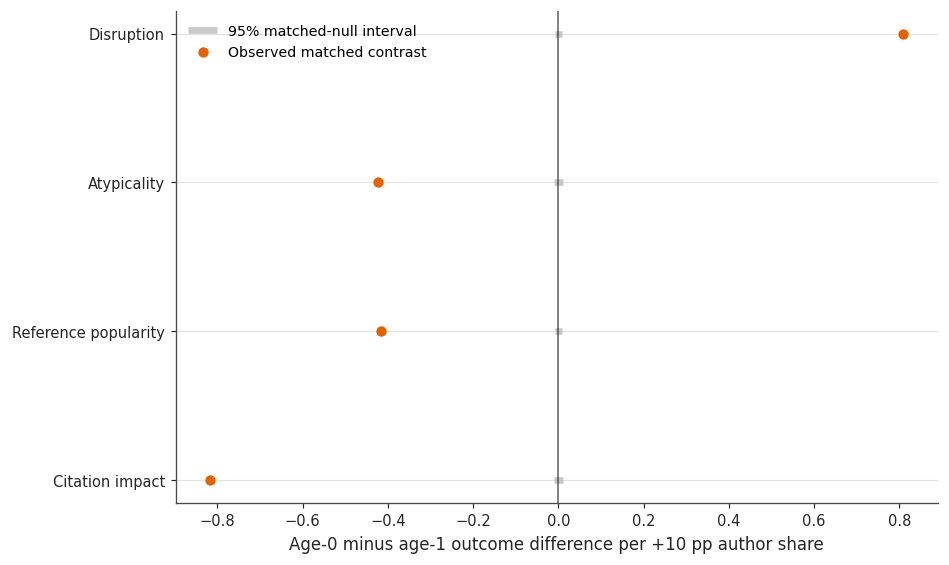

Saved figure data: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\FigureData_null1_matched_age0_age1_randomization.csv

Interpretation: Null 1 preserves year, exact team size, each paper's total age-{0,1} mass, all ages 2-10, and the empirical age-0-count distribution within matched strata. Only the allocation of age 0 versus age 1 across otherwise matched papers is randomized.


In [73]:
# ============================================================
# NULL 1
# RANDOMLY EXCHANGE THE AGE-0 / AGE-1 ALLOCATION WITHIN
# TIGHTLY MATCHED PAPER STRATA
# ============================================================

null1_results = []

for spec in NULL_OUTCOMES:
    print(
        "\n" + "=" * 92
    )
    print(
        "NULL 1:",
        spec["label"],
    )
    print("=" * 92)

    result = _null1_one_outcome(
        spec
    )

    null1_results.append(
        result
    )

    display(
        pd.DataFrame(
            [result]
        )
    )

null1_results = pd.DataFrame(
    null1_results
)

display(
    null1_results
)

export_pub_table(
    null1_results,
    "T89_null1_matched_age0_age1_randomization",
)

null1_results.to_csv(
    OUTPUT_DIR
    / "null1_matched_age0_age1_randomization.csv",
    index=False,
)


# Publication-style null figure.
fig, ax = plt.subplots(
    figsize=(8.0, 4.8)
)

plot_df = (
    null1_results
    .iloc[::-1]
    .reset_index(drop=True)
)

ypos = np.arange(
    len(plot_df)
)

ax.hlines(
    ypos,
    plot_df["null_ci95_low"],
    plot_df["null_ci95_high"],
    color="0.72",
    linewidth=4.0,
    alpha=0.75,
    label="95% matched-null interval",
)

ax.scatter(
    plot_df[
        "matched_null_stat_age0_minus_age1_per_10pp"
    ],
    ypos,
    s=48,
    color=ESTIMATE_COLOR,
    edgecolor="white",
    linewidth=0.7,
    zorder=3,
    label="Observed matched contrast",
)

ax.axvline(
    0,
    color="0.15",
    linewidth=0.9,
    alpha=0.75,
)

apply_science_axes(
    ax
)

ax.set_yticks(
    ypos
)

ax.set_yticklabels(
    plot_df["outcome"]
)

ax.set_xlabel(
    "Age-0 minus age-1 outcome difference per +10 pp author share"
)

ax.legend(
    frameon=False,
    loc="best",
)

plt.tight_layout()

save_pub_figure(
    fig,
    "null1_matched_age0_age1_randomization",
)

plt.show()

export_figure_data(
    null1_results,
    "null1_matched_age0_age1_randomization",
)

print(
    "\nInterpretation: Null 1 preserves year, exact team size, "
    "each paper's total age-{0,1} mass, all ages 2-10, and the "
    "empirical age-0-count distribution within matched strata. "
    "Only the allocation of age 0 versus age 1 across otherwise "
    "matched papers is randomized."
)



NULL 2: Disruption


,outcome,n_papers,n_matched_strata,design_rank,main_model_age0_minus_age1_per_10pp,matched_age0_minus_age1_per_10pp,age01_null_se,age01_null_ci95_low,age01_null_ci95_high,age01_z_against_null,...,extrap_null_ci95_low,extrap_null_ci95_high,extrap_z_against_null,extrap_log10_p_two_sided,observed_standardized_age0_age1_jump,largest_observed_abs_adjacent_z,transition_with_largest_observed_abs_z,max_adjacent_familywise_p,gaussian_draws_for_max_test,runtime_seconds
0,Disruption,22181945,8895,10,0.839201,0.791696,0.004493,-0.008806,0.008806,176.20972,...,-0.009222,0.009222,163.954026,-5839.431012,176.20972,176.20972,0 vs 1,0.000005,200000,7.689777



NULL 2: Atypicality


,outcome,n_papers,n_matched_strata,design_rank,main_model_age0_minus_age1_per_10pp,matched_age0_minus_age1_per_10pp,age01_null_se,age01_null_ci95_low,age01_null_ci95_high,age01_z_against_null,...,extrap_null_ci95_low,extrap_null_ci95_high,extrap_z_against_null,extrap_log10_p_two_sided,observed_standardized_age0_age1_jump,largest_observed_abs_adjacent_z,transition_with_largest_observed_abs_z,max_adjacent_familywise_p,gaussian_draws_for_max_test,runtime_seconds
0,Atypicality,18221198,8526,10,-0.454112,-0.413094,0.005073,-0.009943,0.009943,-81.432848,...,-0.010357,0.010357,-73.98848,-1190.695381,-81.432848,81.432848,0 vs 1,0.000005,200000,6.890358



NULL 2: Reference popularity


...


NULL 2: Citation impact


,outcome,n_papers,n_matched_strata,design_rank,main_model_age0_minus_age1_per_10pp,matched_age0_minus_age1_per_10pp,age01_null_se,age01_null_ci95_low,age01_null_ci95_high,age01_z_against_null,...,extrap_null_ci95_low,extrap_null_ci95_high,extrap_z_against_null,extrap_log10_p_two_sided,observed_standardized_age0_age1_jump,largest_observed_abs_adjacent_z,transition_with_largest_observed_abs_z,max_adjacent_familywise_p,gaussian_draws_for_max_test,runtime_seconds
0,Citation impact,12065039,5968,10,-0.882774,-0.838599,0.005503,-0.010787,0.010787,-152.378016,...,-0.01126,0.01126,-136.051124,-4021.607294,-152.378016,152.378016,0 vs 1,0.000005,200000,4.593375


,outcome,n_papers,n_matched_strata,design_rank,main_model_age0_minus_age1_per_10pp,matched_age0_minus_age1_per_10pp,age01_null_se,age01_null_ci95_low,age01_null_ci95_high,age01_z_against_null,...,extrap_null_ci95_low,extrap_null_ci95_high,extrap_z_against_null,extrap_log10_p_two_sided,observed_standardized_age0_age1_jump,largest_observed_abs_adjacent_z,transition_with_largest_observed_abs_z,max_adjacent_familywise_p,gaussian_draws_for_max_test,runtime_seconds
0,Disruption,22181945,8895,10,0.839201,0.791696,0.004493,-0.008806,0.008806,176.209720,...,-0.009222,0.009222,163.954026,-5839.431012,176.209720,176.209720,0 vs 1,0.000005,200000,7.689777
1,Atypicality,18221198,8526,10,-0.454112,-0.413094,0.005073,-0.009943,0.009943,-81.432848,...,-0.010357,0.010357,-73.988480,-1190.695381,-81.432848,81.432848,0 vs 1,0.000005,200000,6.890358
2,Reference popularity,22181945,8895,10,-0.454682,-0.413091,0.004382,-0.008589,0.008589,-94.270785,...,-0.009006,0.009006,-81.830044,-1456.062861,-94.270785,94.270785,0 vs 1,0.000005,200000,8.196312
3,Citation impact,12065039,5968,10,-0.882774,-0.838599,0.005503,-0.010787,0.010787,-152.378016,...,-0.011260,0.011260,-136.051124,-4021.607294,-152.378016,152.378016,0 vs 1,0.000005,200000,4.593375


,outcome,transition,adjacent_difference_per_10pp,null_se,z_against_null
0,Disruption,0 vs 1,0.791696,0.004493,176.209720
1,Disruption,1 vs 2,0.143725,0.005647,25.449591
2,Disruption,2 vs 3,0.063742,0.005715,11.153115
3,Disruption,3 vs 4,0.037589,0.005798,6.482919
4,Disruption,4 vs 5,0.023226,0.005874,3.954055
5,Disruption,5 vs 6,0.002409,0.005945,0.405258
6,Disruption,6 vs 7,0.008435,0.006028,1.399415
7,Disruption,7 vs 8,0.007538,0.006125,1.230729
8,Disruption,8 vs 9,0.017886,0.006229,2.871370
9,Disruption,9 vs 10,0.006265,0.006340,0.988187


Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T90_null2_exact_age_composition_randomization.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T90_null2_exact_age_composition_randomization.tex
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T90b_null2_adjacent_age_diagnostics.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T90b_null2_adjacent_age_diagnostics.tex
Saved figure: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\figures\null2_exact_age_age0_age1_randomization.pdf


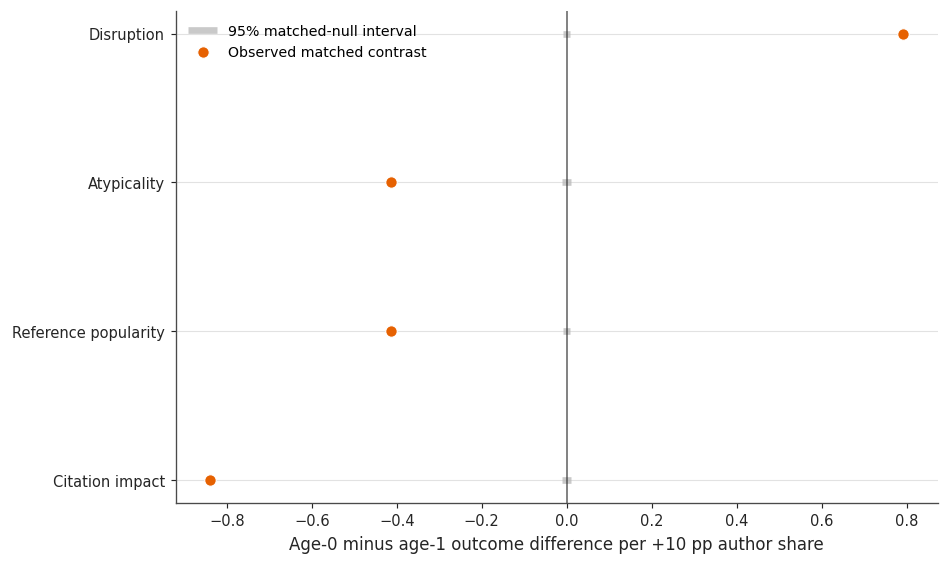

Saved figure data: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\FigureData_null2_exact_age_age0_age1_randomization.csv
Saved figure: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\figures\null2_exact_age_debut_extrapolation_randomization.pdf


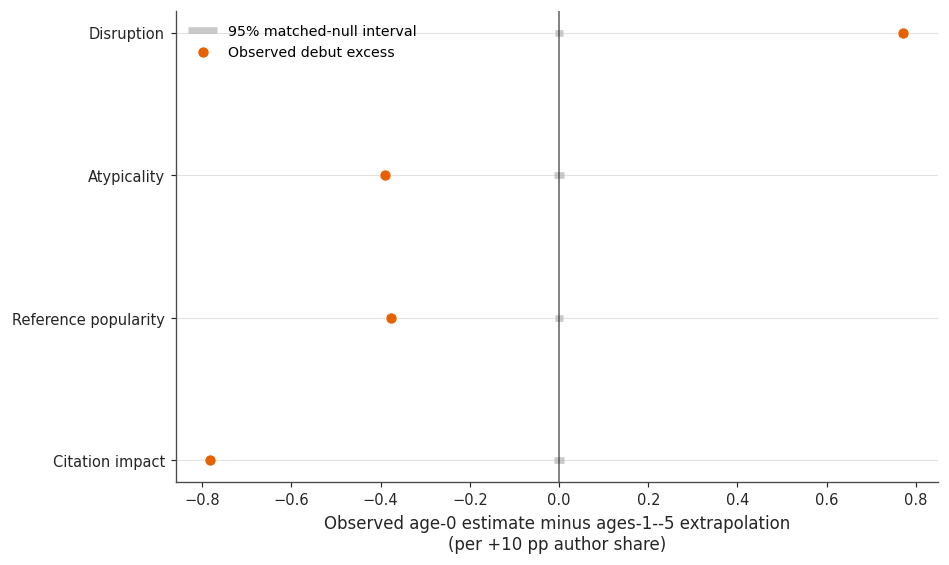

Saved figure data: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\FigureData_null2_exact_age_debut_extrapolation_randomization.csv

The max-adjacent family-wise p-value asks a stricter question: under the matched null, how often would the largest standardized adjacent-age jump anywhere from 0->1 through 9->10 be at least as large as the observed 0->1 jump?


In [75]:
# ============================================================
# NULL 2
# RANDOMIZE THE COMPLETE EXACT-AGE COMPOSITION VECTOR
# WITHIN YEAR x TEAM SIZE x TOTAL AGE-0...10 COUNT STRATA
# ============================================================

null2_summaries = []
null2_profiles = []
null2_adjacent = []

for spec in NULL_OUTCOMES:
    print(
        "\n" + "=" * 92
    )
    print(
        "NULL 2:",
        spec["label"],
    )
    print("=" * 92)

    summary, profile, adjacent = (
        _null2_one_outcome(
            spec,
            n_draws=NULL2_GAUSSIAN_DRAWS,
        )
    )

    null2_summaries.append(
        summary
    )
    null2_profiles.append(
        profile
    )
    null2_adjacent.append(
        adjacent
    )

    display(
        pd.DataFrame(
            [summary]
        )
    )

null2_summary = pd.DataFrame(
    null2_summaries
)

null2_profile = pd.concat(
    null2_profiles,
    ignore_index=True,
)

null2_adjacent = pd.concat(
    null2_adjacent,
    ignore_index=True,
)

display(
    null2_summary
)

display(
    null2_adjacent
)

export_pub_table(
    null2_summary,
    "T90_null2_exact_age_composition_randomization",
)

export_pub_table(
    null2_adjacent,
    "T90b_null2_adjacent_age_diagnostics",
)

null2_summary.to_csv(
    OUTPUT_DIR
    / "null2_exact_age_composition_randomization.csv",
    index=False,
)

null2_profile.to_csv(
    OUTPUT_DIR
    / "null2_exact_age_matched_profiles.csv",
    index=False,
)

null2_adjacent.to_csv(
    OUTPUT_DIR
    / "null2_adjacent_age_diagnostics.csv",
    index=False,
)


# ------------------------------------------------------------
# Figure A:
# direct age-0 vs age-1 contrast under the broader null.
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8.0, 4.8)
)

plot_df = (
    null2_summary
    .iloc[::-1]
    .reset_index(drop=True)
)

ypos = np.arange(
    len(plot_df)
)

ax.hlines(
    ypos,
    plot_df["age01_null_ci95_low"],
    plot_df["age01_null_ci95_high"],
    color="0.72",
    linewidth=4.0,
    alpha=0.75,
    label="95% matched-null interval",
)

ax.scatter(
    plot_df[
        "matched_age0_minus_age1_per_10pp"
    ],
    ypos,
    s=48,
    color=ESTIMATE_COLOR,
    edgecolor="white",
    linewidth=0.7,
    zorder=3,
    label="Observed matched contrast",
)

ax.axvline(
    0,
    color="0.15",
    linewidth=0.9,
    alpha=0.75,
)

apply_science_axes(
    ax
)

ax.set_yticks(
    ypos
)

ax.set_yticklabels(
    plot_df["outcome"]
)

ax.set_xlabel(
    "Age-0 minus age-1 outcome difference per +10 pp author share"
)

ax.legend(
    frameon=False,
    loc="best",
)

plt.tight_layout()

save_pub_figure(
    fig,
    "null2_exact_age_age0_age1_randomization",
)

plt.show()

export_figure_data(
    null2_summary,
    "null2_exact_age_age0_age1_randomization",
)


# ------------------------------------------------------------
# Figure B:
# age-0 excess beyond the ages-1...5 smooth trajectory.
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8.0, 4.8)
)

ypos = np.arange(
    len(plot_df)
)

ax.hlines(
    ypos,
    plot_df["extrap_null_ci95_low"],
    plot_df["extrap_null_ci95_high"],
    color="0.72",
    linewidth=4.0,
    alpha=0.75,
    label="95% matched-null interval",
)

ax.scatter(
    plot_df[
        "matched_age0_minus_ages1_5_extrap_per_10pp"
    ],
    ypos,
    s=48,
    color=ESTIMATE_COLOR,
    edgecolor="white",
    linewidth=0.7,
    zorder=3,
    label="Observed debut excess",
)

ax.axvline(
    0,
    color="0.15",
    linewidth=0.9,
    alpha=0.75,
)

apply_science_axes(
    ax
)

ax.set_yticks(
    ypos
)

ax.set_yticklabels(
    plot_df["outcome"]
)

ax.set_xlabel(
    "Observed age-0 estimate minus ages-1--5 extrapolation\n"
    "(per +10 pp author share)"
)

ax.legend(
    frameon=False,
    loc="best",
)

plt.tight_layout()

save_pub_figure(
    fig,
    "null2_exact_age_debut_extrapolation_randomization",
)

plt.show()

export_figure_data(
    null2_summary,
    "null2_exact_age_debut_extrapolation_randomization",
)

print(
    "\nThe max-adjacent family-wise p-value asks a stricter question: "
    "under the matched null, how often would the largest standardized "
    "adjacent-age jump anywhere from 0->1 through 9->10 be at least as "
    "large as the observed 0->1 jump?"
)


In [76]:
# ============================================================
# NULL-MODEL SUMMARY FOR MANUSCRIPT INTERPRETATION
# ============================================================

null_robustness_summary = (
    null1_results[
        [
            "outcome",
            "main_model_age0_minus_age1_per_10pp",
            "matched_null_stat_age0_minus_age1_per_10pp",
            "null_ci95_low",
            "null_ci95_high",
            "z_against_null",
            "log10_p_two_sided",
        ]
    ]
    .rename(columns={
        "matched_null_stat_age0_minus_age1_per_10pp":
            "null1_matched_age0_minus_age1_per_10pp",
        "null_ci95_low":
            "null1_ci95_low",
        "null_ci95_high":
            "null1_ci95_high",
        "z_against_null":
            "null1_z",
        "log10_p_two_sided":
            "null1_log10_p",
    })
    .merge(
        null2_summary[
            [
                "outcome",
                "matched_age0_minus_age1_per_10pp",
                "age01_null_ci95_low",
                "age01_null_ci95_high",
                "age01_z_against_null",
                "matched_age0_minus_ages1_5_extrap_per_10pp",
                "extrap_null_ci95_low",
                "extrap_null_ci95_high",
                "extrap_z_against_null",
                "max_adjacent_familywise_p",
                "transition_with_largest_observed_abs_z",
            ]
        ],
        on="outcome",
        how="left",
    )
)

display(
    null_robustness_summary
)

export_pub_table(
    null_robustness_summary,
    "T91_career_age_null_model_summary",
)

null_robustness_summary.to_csv(
    OUTPUT_DIR
    / "career_age_null_model_summary.csv",
    index=False,
)

print("\n" + "=" * 96)
print("CAREER-AGE NULL MODELS COMPLETE")
print("=" * 96)

for row in null_robustness_summary.itertuples(index=False):
    print()
    print(row.outcome)
    print(
        "  Main-model age0-age1 contrast:",
        f"{row.main_model_age0_minus_age1_per_10pp:+.4f}",
    )
    print(
        "  Null 1 matched contrast:",
        f"{row.null1_matched_age0_minus_age1_per_10pp:+.4f}",
        "vs null 95% ["
        f"{row.null1_ci95_low:+.4f}, "
        f"{row.null1_ci95_high:+.4f}]",
    )
    print(
        "  Null 2 matched age0-age1:",
        f"{row.matched_age0_minus_age1_per_10pp:+.4f}",
        "vs null 95% ["
        f"{row.age01_null_ci95_low:+.4f}, "
        f"{row.age01_null_ci95_high:+.4f}]",
    )
    print(
        "  Null 2 debut excess beyond ages1-5:",
        f"{row.matched_age0_minus_ages1_5_extrap_per_10pp:+.4f}",
        "vs null 95% ["
        f"{row.extrap_null_ci95_low:+.4f}, "
        f"{row.extrap_null_ci95_high:+.4f}]",
    )
    print(
        "  Family-wise max-adjacent p:",
        f"{row.max_adjacent_familywise_p:.6g}",
        "| strongest observed transition:",
        row.transition_with_largest_observed_abs_z,
    )

print(
    "\nThese nulls are designed for a final robustness subsection. "
    "They do not replace the main fixed-effect estimates; they ask whether "
    "the debut boundary survives constrained randomization that preserves "
    "the major structural features of the exact-age data."
)


,outcome,main_model_age0_minus_age1_per_10pp,null1_matched_age0_minus_age1_per_10pp,null1_ci95_low,null1_ci95_high,null1_z,null1_log10_p,matched_age0_minus_age1_per_10pp,age01_null_ci95_low,age01_null_ci95_high,age01_z_against_null,matched_age0_minus_ages1_5_extrap_per_10pp,extrap_null_ci95_low,extrap_null_ci95_high,extrap_z_against_null,max_adjacent_familywise_p,transition_with_largest_observed_abs_z
0,Disruption,0.839201,0.808959,-0.008910,0.008910,177.948704,-6878.476695,0.791696,-0.008806,0.008806,176.209720,0.771381,-0.009222,0.009222,163.954026,0.000005,0 vs 1
1,Atypicality,-0.454112,-0.423233,-0.010129,0.010129,-81.900203,-1458.557644,-0.413094,-0.009943,0.009943,-81.432848,-0.390956,-0.010357,0.010357,-73.988480,0.000005,0 vs 1
2,Reference popularity,-0.454682,-0.416657,-0.008793,0.008793,-92.879655,-1875.314983,-0.413091,-0.008589,0.008589,-94.270785,-0.375981,-0.009006,0.009006,-81.830044,0.000005,0 vs 1
3,Citation impact,-0.882774,-0.816498,-0.010475,0.010475,-152.776847,-5070.664855,-0.838599,-0.010787,0.010787,-152.378016,-0.781594,-0.011260,0.011260,-136.051124,0.000005,0 vs 1


Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T91_career_age_null_model_summary.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T91_career_age_null_model_summary.tex

CAREER-AGE NULL MODELS COMPLETE

Disruption
  Main-model age0-age1 contrast: +0.8392
  Null 1 matched contrast: +0.8090 vs null 95% [-0.0089, +0.0089]
  Null 2 matched age0-age1: +0.7917 vs null 95% [-0.0088, +0.0088]
  Null 2 debut excess beyond ages1-5: +0.7714 vs null 95% [-0.0092, +0.0092]
  Family-wise max-adjacent p: 4.99998e-06 | strongest observed transition: 0 vs 1

Atypicality
  Main-model age0-age1 contrast: -0.4541
  Null 1 matched contrast: -0.4232 vs null 95% [-0.0101, +0.0101]
  Null 2 matched age0-age1: -0.4131 vs null 95% [-0.0099, +0.0099]
  Null 2 debut excess beyond ages1-5: -0.3910 vs null 95% [-0.0104, +0.0104]
  Family-wise max-adjacent p: 4.99998e-06 | strongest observed transition: 0 vs 1

Reference popularity
  Main

# Robustness after excluding one-publication debutants

A debutant whose debut paper is also their only observed publication may differ
from an author who continues to publish. As a stricter sensitivity analysis,
we remove every focal paper containing at least one debutant who appears on
only one paper anywhere in the observed SciSciNet-v2 author-paper history.

The four exact-age outcome models are then re-estimated, together with the
exact-age × team-size interaction. The analysis asks whether the
debut-versus-post-debut differences persist after this restriction.

In [79]:
# ============================================================
# ROBUSTNESS: REMOVE ONE-PAPER DEBUTANTS
#
# Exclude focal papers containing any debutant author who
# appears on exactly one paper anywhere in the observed
# SciSciNet author-paper history.
#
# Key observation:
#   If an author appears on exactly one observed paper, that
#   paper is necessarily their observed debut paper.
#
# Therefore we:
#   1. identify target authors with exactly one observed paper;
#   2. retain that author's sole observed paper ID;
#   3. match those sole-paper IDs directly to focal papers;
#   4. remove flagged papers from the complete exact-age sample.
#
# This avoids the much larger four-way join through focal
# author-paper links, debut years, singleton authors, and target
# papers that previously produced hundreds of GB of spill.
# ============================================================

import gc
import shutil
from pathlib import Path
from time import perf_counter

import duckdb
import numpy as np
import polars as pl


# ------------------------------------------------------------
# 0. Preconditions
# ------------------------------------------------------------

required_objects = [
    "A",
    "exact_age",
    "valid_exact_age",
    "EXACT_SHARE_FULL",
    "run_exact_age_secondary",
    "fit_two_way_fe_model_full",
    "linear_combo_from_model",
    "export_pub_table",
]

missing = [
    name for name in required_objects
    if name not in globals()
]

if missing:
    raise RuntimeError(
        "Run the complete v9 notebook before this robustness "
        f"analysis. Missing objects: {missing}"
    )

N_EXACT_EXPECTED = 29_054_201

if int(valid_exact_age.sum()) != N_EXACT_EXPECTED:
    raise RuntimeError(
        "Unexpected number of papers with complete exact-age "
        f"reconstruction: {int(valid_exact_age.sum()):,} "
        f"(expected {N_EXACT_EXPECTED:,})."
    )


# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------

EXACT_RECON_DIR = Path(
    r"data\sciscinet_exact_career_age_v2"
)

TARGET_PAPERS_PATH = (
    EXACT_RECON_DIR
    / "01_target_papers_v9_sample.parquet"
)

AUTHOR_DEBUT_PATH = (
    EXACT_RECON_DIR
    / "04_target_author_debut_year.parquet"
)

AUTHOR_PAPER_PATH = Path(
    r"data\sciscinet_v2_public\sciscinet_authors_paperid.parquet"
)

PERSIST_DIR = Path(
    r"data\sciscinet_exact_career_age_persistent_debutant_robustness"
)

PERSIST_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

SINGLETON_AUTHORS_PATH = (
    PERSIST_DIR
    / "01_singleton_target_authors.parquet"
)

SINGLETON_DEBUTANT_PAPERS_PATH = (
    PERSIST_DIR
    / "02_papers_with_singleton_debutants.parquet"
)

DUCKDB_TEMP_DIR = (
    PERSIST_DIR
    / "_duckdb_temp"
)


for path in [
    TARGET_PAPERS_PATH,
    AUTHOR_DEBUT_PATH,
    AUTHOR_PAPER_PATH,
]:
    if not path.exists():
        raise FileNotFoundError(
            f"Required input not found:\n{path.resolve()}"
        )


# ------------------------------------------------------------
# 2. Helpers
# ------------------------------------------------------------

def _qpath(path):
    """DuckDB-safe absolute path."""
    return (
        str(Path(path).resolve())
        .replace("\\", "/")
        .replace("'", "''")
    )


def _qident(name):
    """SQL-safe quoted identifier."""
    return '"' + str(name).replace('"', '""') + '"'


def _resolve_col(
    schema,
    candidates,
    label,
    required=True,
):
    names = list(schema.names())

    lower = {
        name.lower(): name
        for name in names
    }

    for candidate in candidates:
        hit = lower.get(
            candidate.lower()
        )
        if hit is not None:
            return hit

    if required:
        raise RuntimeError(
            f"Could not resolve {label}. "
            f"Available columns: {names}"
        )

    return None


# ------------------------------------------------------------
# 3. Resolve author-paper schema
#
# Supports either:
#   - one row per author-paper pair, or
#   - one row per author with a list of paper IDs.
# ------------------------------------------------------------

ap_schema = (
    pl.scan_parquet(
        AUTHOR_PAPER_PATH
    )
    .collect_schema()
)

AP_AUTHOR_ID = _resolve_col(
    ap_schema,
    [
        "authorid",
        "author_id",
        "id",
    ],
    "author ID",
)

AP_PAPER_ID = _resolve_col(
    ap_schema,
    [
        "paperid",
        "paper_id",
        "workid",
        "work_id",
    ],
    "scalar paper ID",
    required=False,
)

AP_PAPER_IDS = _resolve_col(
    ap_schema,
    [
        "paperids",
        "paper_ids",
        "workids",
        "work_ids",
    ],
    "paper-ID list",
    required=False,
)

if (
    AP_PAPER_ID is None
    and AP_PAPER_IDS is None
):
    raise RuntimeError(
        "No paper-ID field found in "
        "sciscinet_authors_paperid.parquet."
    )


if AP_PAPER_ID is not None:

    AP_FLAT_SQL = f"""
        SELECT
            CAST(
                {_qident(AP_AUTHOR_ID)}
                AS VARCHAR
            ) AS authorid,

            CAST(
                {_qident(AP_PAPER_ID)}
                AS VARCHAR
            ) AS paperid

        FROM read_parquet(
            '{_qpath(AUTHOR_PAPER_PATH)}'
        )

        WHERE
            {_qident(AP_AUTHOR_ID)} IS NOT NULL
            AND
            {_qident(AP_PAPER_ID)} IS NOT NULL
    """

else:

    AP_FLAT_SQL = f"""
        SELECT
            CAST(
                {_qident(AP_AUTHOR_ID)}
                AS VARCHAR
            ) AS authorid,

            CAST(
                UNNEST(
                    {_qident(AP_PAPER_IDS)}
                )
                AS VARCHAR
            ) AS paperid

        FROM read_parquet(
            '{_qpath(AUTHOR_PAPER_PATH)}'
        )

        WHERE
            {_qident(AP_AUTHOR_ID)} IS NOT NULL
            AND
            {_qident(AP_PAPER_IDS)} IS NOT NULL
    """


# ------------------------------------------------------------
# 4. Clean up any connection/temp files left by an interrupted
#    previous run
# ------------------------------------------------------------

try:
    if "con" in globals():
        con.close()
except Exception:
    pass

gc.collect()

# This directory is dedicated only to this robustness analysis,
# so stale DuckDB spill files from a failed/interrupted run can
# safely be removed before opening a fresh connection.
if DUCKDB_TEMP_DIR.exists():
    shutil.rmtree(
        DUCKDB_TEMP_DIR,
        ignore_errors=True,
    )

DUCKDB_TEMP_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ------------------------------------------------------------
# 5. DuckDB configuration
#
# Machine used for the manuscript analysis:
#   64 GB RAM
#   20 CPU cores
#   >600 GB free on project drive
#
# We deliberately leave headroom for:
#   - Windows,
#   - the Jupyter kernel,
#   - large NumPy arrays already resident from v9.
# ------------------------------------------------------------

DUCKDB_THREADS = 12
DUCKDB_MEMORY = "38GB"
DUCKDB_TEMP_MAX = "500GB"

con = duckdb.connect()

con.execute(
    "SET preserve_insertion_order=false"
)

con.execute(
    f"SET threads={DUCKDB_THREADS}"
)

con.execute(
    f"SET memory_limit='{DUCKDB_MEMORY}'"
)

con.execute(
    "SET temp_directory=?",
    [
        str(
            DUCKDB_TEMP_DIR.resolve()
        )
    ],
)

con.execute(
    f"SET max_temp_directory_size='{DUCKDB_TEMP_MAX}'"
)

try:
    con.execute(
        "SET enable_progress_bar=true"
    )
except Exception:
    pass


print("DuckDB settings:")
print(
    f"  threads:       {DUCKDB_THREADS}"
)
print(
    f"  memory limit:  {DUCKDB_MEMORY}"
)
print(
    f"  temp dir:      {DUCKDB_TEMP_DIR.resolve()}"
)
print(
    f"  temp max:      {DUCKDB_TEMP_MAX}"
)


# ------------------------------------------------------------
# 6. Derive singleton target authors
#
# Cache columns:
#   authorid
#   observed_paper_count
#   only_paperid
#
# If a compatible cache already exists, reuse it.
# ------------------------------------------------------------

rebuild_singletons = True

if SINGLETON_AUTHORS_PATH.exists():
    try:
        singleton_schema = (
            pl.scan_parquet(
                SINGLETON_AUTHORS_PATH
            )
            .collect_schema()
        )

        required_cache_cols = {
            "authorid",
            "observed_paper_count",
            "only_paperid",
        }

        if required_cache_cols.issubset(
            set(singleton_schema.names())
        ):
            rebuild_singletons = False

    except Exception:
        rebuild_singletons = True


if rebuild_singletons:

    if SINGLETON_AUTHORS_PATH.exists():
        SINGLETON_AUTHORS_PATH.unlink()

    print()
    print(
        "Deriving one-paper target authors "
        "and their sole observed paper..."
    )

    t0 = perf_counter()

    con.execute(f"""
    COPY (
        WITH target_authors AS (
            SELECT DISTINCT
                CAST(
                    authorid AS VARCHAR
                ) AS authorid

            FROM read_parquet(
                '{_qpath(AUTHOR_DEBUT_PATH)}'
            )
        ),

        productivity AS (
            SELECT
                ap.authorid,

                COUNT(
                    DISTINCT ap.paperid
                ) AS observed_paper_count,

                MIN(
                    ap.paperid
                ) AS only_paperid

            FROM (
                {AP_FLAT_SQL}
            ) AS ap

            INNER JOIN target_authors AS ta
                USING(authorid)

            GROUP BY
                ap.authorid

            HAVING
                COUNT(
                    DISTINCT ap.paperid
                ) = 1
        )

        SELECT
            authorid,
            observed_paper_count,
            only_paperid

        FROM productivity
    )
    TO '{_qpath(SINGLETON_AUTHORS_PATH)}'
    (
        FORMAT PARQUET,
        COMPRESSION ZSTD,
        ROW_GROUP_SIZE 100000
    );
    """)

    elapsed = (
        perf_counter() - t0
    ) / 60

    print(
        "Derived one-paper target authors in "
        f"{elapsed:.2f} min."
    )

else:

    print()
    print(
        "Reusing cached one-paper target authors:"
    )
    print(
        f"  {SINGLETON_AUTHORS_PATH.resolve()}"
    )


# ------------------------------------------------------------
# 7. Singleton-author audit
# ------------------------------------------------------------

singleton_audit = con.execute(f"""
SELECT
    COUNT(*) AS one_paper_target_authors,

    COUNT(
        DISTINCT only_paperid
    ) AS distinct_only_papers

FROM read_parquet(
    '{_qpath(SINGLETON_AUTHORS_PATH)}'
)
""").fetchdf()

display(
    singleton_audit
)


# ------------------------------------------------------------
# 8. Identify focal papers containing a singleton debutant
#
# A one-paper author's sole observed paper is necessarily their
# observed debut. Therefore this only requires a paper-ID join.
# ------------------------------------------------------------

if SINGLETON_DEBUTANT_PAPERS_PATH.exists():
    SINGLETON_DEBUTANT_PAPERS_PATH.unlink()

gc.collect()

print()
print(
    "Matching singleton authors' sole papers "
    "to the v9 target-paper sample..."
)

t0 = perf_counter()

con.execute(f"""
COPY (
    SELECT DISTINCT
        p.target_row,
        p.paperid

    FROM read_parquet(
        '{_qpath(SINGLETON_AUTHORS_PATH)}'
    ) AS s

    INNER JOIN read_parquet(
        '{_qpath(TARGET_PAPERS_PATH)}'
    ) AS p

        ON
            s.only_paperid
            =
            CAST(
                p.paperid
                AS VARCHAR
            )
)
TO '{_qpath(SINGLETON_DEBUTANT_PAPERS_PATH)}'
(
    FORMAT PARQUET,
    COMPRESSION ZSTD,
    ROW_GROUP_SIZE 100000
);
""")

elapsed = (
    perf_counter() - t0
) / 60

print(
    "Flagged singleton-debutant papers in "
    f"{elapsed:.2f} min."
)


# ------------------------------------------------------------
# 9. Full-target-sample audit
#
# Note:
#   TARGET_PAPERS_PATH contains 29,054,261 papers.
#   Exact-age reconstruction is complete for 29,054,201.
#
# Therefore the count here is intentionally over the full
# target sample; exact-age alignment is checked below.
# ------------------------------------------------------------

audit = con.execute(f"""
WITH singleton_authors AS (
    SELECT
        COUNT(*) AS n_authors

    FROM read_parquet(
        '{_qpath(SINGLETON_AUTHORS_PATH)}'
    )
),

flagged AS (
    SELECT
        COUNT(*) AS n_papers

    FROM read_parquet(
        '{_qpath(SINGLETON_DEBUTANT_PAPERS_PATH)}'
    )
),

slots AS (
    SELECT
        COUNT(*) AS n_slots

    FROM read_parquet(
        '{_qpath(SINGLETON_AUTHORS_PATH)}'
    ) AS s

    INNER JOIN read_parquet(
        '{_qpath(TARGET_PAPERS_PATH)}'
    ) AS p

        ON
            s.only_paperid
            =
            CAST(
                p.paperid
                AS VARCHAR
            )
)

SELECT
    singleton_authors.n_authors
        AS one_paper_target_authors,

    flagged.n_papers
        AS papers_with_one_paper_debutant,

    slots.n_slots
        AS one_paper_debutant_slots

FROM singleton_authors
CROSS JOIN flagged
CROSS JOIN slots
""").fetchdf()

display(
    audit
)


# ------------------------------------------------------------
# 10. Close DuckDB before returning to NumPy-heavy analyses
#
# This also releases DuckDB spill files immediately.
# ------------------------------------------------------------

con.close()
del con

gc.collect()


# ------------------------------------------------------------
# 11. Build paper-level singleton-debutant indicator
# ------------------------------------------------------------

singleton_target_rows = (
    pl.read_parquet(
        SINGLETON_DEBUTANT_PAPERS_PATH,
        columns=[
            "target_row",
        ],
    )["target_row"]
    .to_numpy()
    .astype(
        np.int64,
        copy=False,
    )
)


if singleton_target_rows.size:

    if singleton_target_rows.min() < 0:
        raise RuntimeError(
            "Negative target_row encountered."
        )

    if (
        singleton_target_rows.max()
        >= len(A["year"])
    ):
        raise RuntimeError(
            "Singleton-paper target_row exceeds "
            "the v9 paper-array bounds."
        )


has_singleton_debutant = np.zeros(
    len(A["year"]),
    dtype=bool,
)

has_singleton_debutant[
    singleton_target_rows
] = True


# ------------------------------------------------------------
# 12. Restrict to the complete exact-age sample
# ------------------------------------------------------------

persistent_debutant_mask = (
    valid_exact_age
    & ~has_singleton_debutant
)

n_exact = int(
    valid_exact_age.sum()
)

n_keep = int(
    persistent_debutant_mask.sum()
)

n_drop = (
    n_exact
    - n_keep
)


# ------------------------------------------------------------
# 13. Correct alignment audit
#
# The flagged-paper parquet is defined over the full v9 target
# sample, whereas the robustness models use only papers with
# complete exact-age reconstruction.
#
# Hence:
#
#   full-sample flagged papers
#       =
#   flagged papers inside exact-age sample
#       +
#   flagged papers already excluded from exact-age analyses
#
# This avoids incorrectly requiring the first two quantities
# to be identical.
# ------------------------------------------------------------

n_flagged_all = int(
    audit[
        "papers_with_one_paper_debutant"
    ].iloc[0]
)

n_flagged_exact = int(
    np.count_nonzero(
        has_singleton_debutant
        & valid_exact_age
    )
)

n_flagged_outside_exact = (
    n_flagged_all
    - n_flagged_exact
)

n_incomplete_exact = int(
    (~valid_exact_age).sum()
)


if n_drop != n_flagged_exact:
    raise RuntimeError(
        "Singleton-debutant mask is not aligned with the "
        "complete exact-age sample: "
        f"mask excludes {n_drop:,} papers, while "
        f"{n_flagged_exact:,} flagged papers have complete "
        "exact-age reconstruction."
    )


if n_flagged_outside_exact < 0:
    raise RuntimeError(
        "Exact-age flagged count exceeds full-sample "
        "flagged count."
    )


if n_flagged_outside_exact > n_incomplete_exact:
    raise RuntimeError(
        "More flagged papers fall outside the exact-age "
        "sample than there are incomplete exact-age papers."
    )


# ------------------------------------------------------------
# 14. Final summary
# ------------------------------------------------------------

print()
print("=" * 92)
print(
    "ONE-PAPER DEBUTANT EXCLUSION"
)
print("=" * 92)

print(
    f"Complete exact-age papers:                    "
    f"{n_exact:,}"
)

print(
    f"Excluded papers with >=1 one-paper debutant: "
    f"{n_drop:,}"
)

print(
    f"Retained papers:                              "
    f"{n_keep:,}"
)

print(
    f"Retained share:                               "
    f"{n_keep / n_exact:.3%}"
)

print()

print(
    "Alignment audit:"
)

print(
    f"  Flagged papers in full target sample:      "
    f"{n_flagged_all:,}"
)

print(
    f"  Flagged papers with complete exact age:    "
    f"{n_flagged_exact:,}"
)

print(
    f"  Flagged papers already outside exact age:  "
    f"{n_flagged_outside_exact:,}"
)

print(
    f"  Total papers outside exact-age sample:      "
    f"{n_incomplete_exact:,}"
)

print()

print(
    "PASS: singleton-debutant exclusion is correctly "
    "aligned to the complete exact-age sample."
)

print(
    "PASS: every age-0 author on every retained "
    "exact-age paper is observed on at least two papers "
    "in SciSciNet."
)

DuckDB settings:
  threads:       12
  memory limit:  38GB
  temp dir:      D:\beginners_charm\new_statistical_analysis\data\sciscinet_exact_career_age_persistent_debutant_robustness\_duckdb_temp
  temp max:      500GB

Reusing cached one-paper target authors:
  D:\beginners_charm\new_statistical_analysis\data\sciscinet_exact_career_age_persistent_debutant_robustness\01_singleton_target_authors.parquet


,one_paper_target_authors,distinct_only_papers
0,3880813,3136464



Matching singleton authors' sole papers to the v9 target-paper sample...
Flagged singleton-debutant papers in 0.03 min.


,one_paper_target_authors,papers_with_one_paper_debutant,one_paper_debutant_slots
0,3880813,3136464,3880813



ONE-PAPER DEBUTANT EXCLUSION
Complete exact-age papers:                    29,054,201
Excluded papers with >=1 one-paper debutant: 3,136,458
Retained papers:                              25,917,743
Retained share:                               89.205%

Alignment audit:
  Flagged papers in full target sample:      3,136,464
  Flagged papers with complete exact age:    3,136,458
  Flagged papers already outside exact age:  6
  Total papers outside exact-age sample:      60

PASS: singleton-debutant exclusion is correctly aligned to the complete exact-age sample.
PASS: every age-0 author on every retained exact-age paper is observed on at least two papers in SciSciNet.


Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T92_persistent_debutant_disruption_profile.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T92_persistent_debutant_disruption_profile.tex
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T92_persistent_debutant_disruption_debut_contrasts.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T92_persistent_debutant_disruption_debut_contrasts.tex
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T92_persistent_debutant_disruption_extrapolation.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T92_persistent_debutant_disruption_extrapolation.tex
Saved figure data: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\FigureData_persistent_debutant_exact_age_disruption.csv
Saved figure: D:\beginners

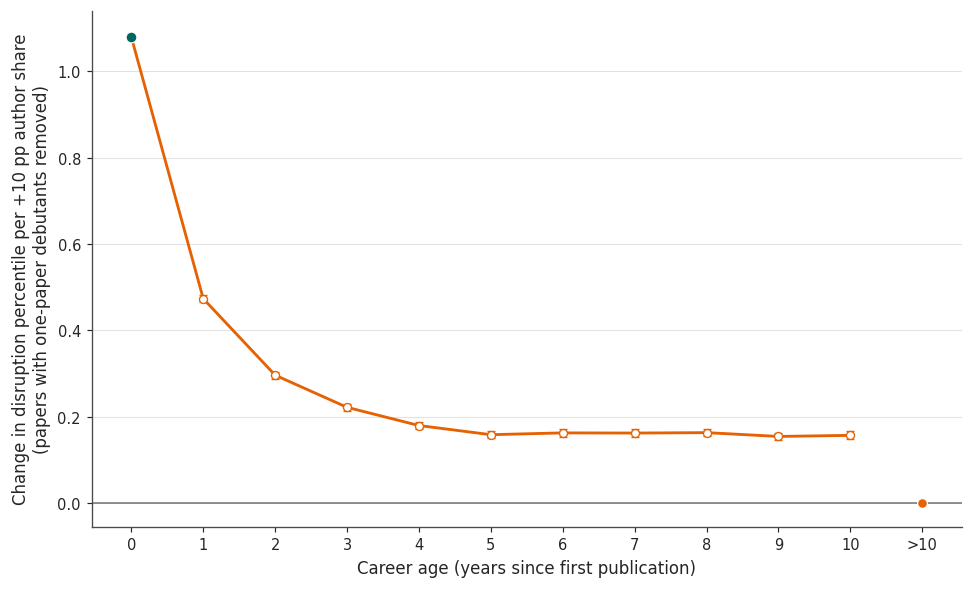


PERSISTENT-DEBUTANT ROBUSTNESS: DISRUPTION
N = 25,917,743
Age 0, +10pp: 1.0794 [1.0736, 1.0852]
Age 1, +10pp: 0.4735 [0.4651, 0.4818]
Age 0 - age 1, +10pp: 0.6059 [0.5963, 0.6156]
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T93_persistent_debutant_atypicality_profile.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T93_persistent_debutant_atypicality_profile.tex
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T93_persistent_debutant_atypicality_debut_contrasts.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T93_persistent_debutant_atypicality_debut_contrasts.tex
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T93_persistent_debutant_atypicality_extrapolation.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T93_persistent_debutant_atypicality_extra

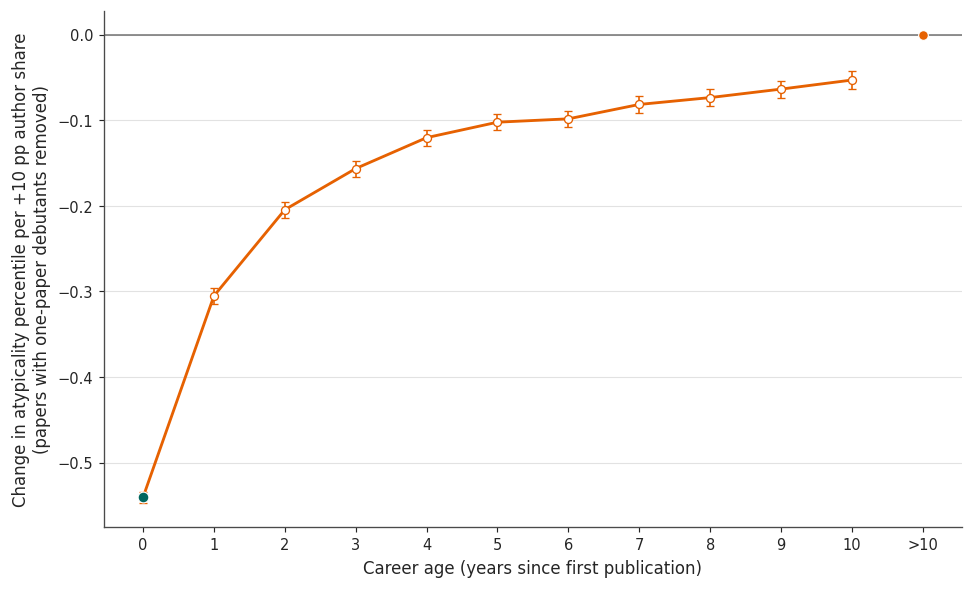


PERSISTENT-DEBUTANT ROBUSTNESS: ATYPICALITY
N = 21,235,963
Age 0, +10pp: -0.5405 [-0.5473, -0.5338]
Age 1, +10pp: -0.3053 [-0.3146, -0.2959]
Age 0 - age 1, +10pp: -0.2353 [-0.2462, -0.2244]
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T94_persistent_debutant_reference_popularity_profile.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T94_persistent_debutant_reference_popularity_profile.tex
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T94_persistent_debutant_reference_popularity_debut_contrasts.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T94_persistent_debutant_reference_popularity_debut_contrasts.tex
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T94_persistent_debutant_reference_popularity_extrapolation.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Resu

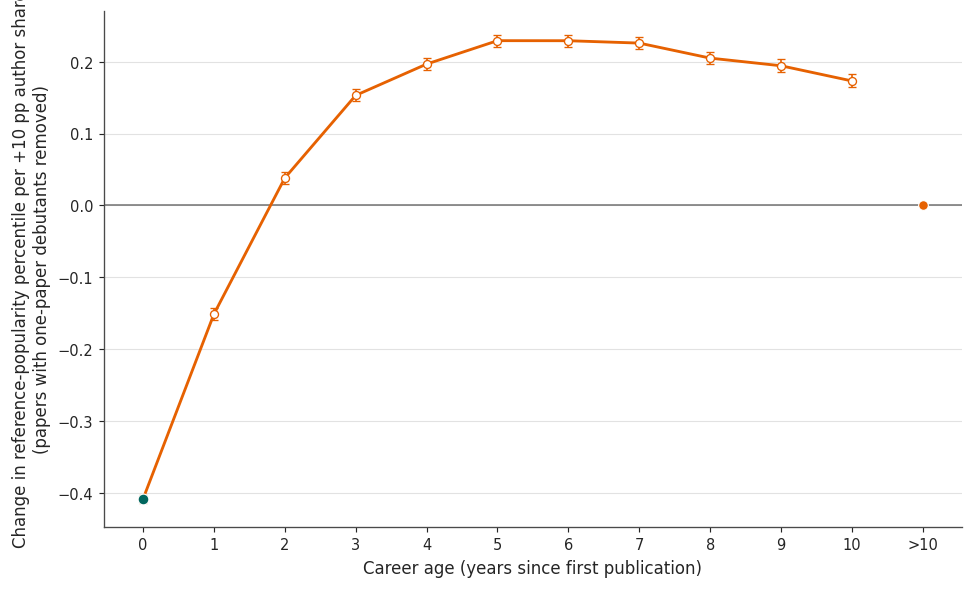


PERSISTENT-DEBUTANT ROBUSTNESS: REFERENCE POPULARITY
N = 25,917,743
Age 0, +10pp: -0.4086 [-0.4143, -0.4029]
Age 1, +10pp: -0.1513 [-0.1595, -0.1431]
Age 0 - age 1, +10pp: -0.2573 [-0.2667, -0.2479]
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T95_persistent_debutant_C10_profile.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T95_persistent_debutant_C10_profile.tex
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T95_persistent_debutant_C10_debut_contrasts.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T95_persistent_debutant_C10_debut_contrasts.tex
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T95_persistent_debutant_C10_extrapolation.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T95_persistent_debutant_C10_extrapolation.tex
Saved figure dat

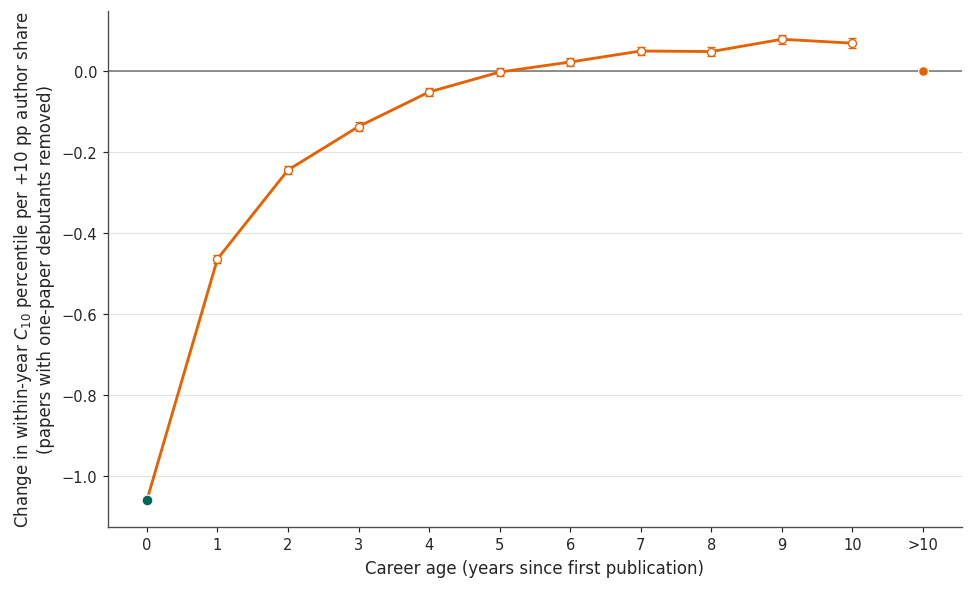


PERSISTENT-DEBUTANT ROBUSTNESS: CITATION IMPACT
N = 14,453,813
Age 0, +10pp: -1.0594 [-1.0662, -1.0527]
Age 1, +10pp: -0.4635 [-0.4736, -0.4534]
Age 0 - age 1, +10pp: -0.5959 [-0.6072, -0.5847]


,outcome,n_restricted,original_age0_per_10pp,restricted_age0_per_10pp,restricted_age0_ci95_low,restricted_age0_ci95_high,original_age1_per_10pp,restricted_age1_per_10pp,original_age0_minus_age1_per_10pp,restricted_age0_minus_age1_per_10pp,restricted_age0_minus_age1_ci95_low,restricted_age0_minus_age1_ci95_high,original_age0_minus_ages1_5_extrap_per_10pp,restricted_age0_minus_ages1_5_extrap_per_10pp,restricted_extrap_ci95_low,restricted_extrap_ci95_high
0,Disruption,25917743,1.348950,1.079412,1.073640,1.085183,0.509749,0.473488,0.839201,0.605924,0.596292,0.615556,0.820592,0.588424,0.578440,0.598408
1,Atypicality,21235963,-0.793108,-0.540544,-0.547287,-0.533800,-0.338996,-0.305268,-0.454112,-0.235275,-0.246158,-0.224393,-0.434511,-0.215699,-0.226934,-0.204464
2,Reference popularity,25917743,-0.641650,-0.408628,-0.414342,-0.402914,-0.186968,-0.151306,-0.454682,-0.257322,-0.266702,-0.247941,-0.419260,-0.224195,-0.233932,-0.214457
3,Citation impact,14453813,-1.364563,-1.059417,-1.066155,-1.052679,-0.481789,-0.463482,-0.882774,-0.595935,-0.607198,-0.584673,-0.828834,-0.542658,-0.554412,-0.530904


Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T96_persistent_debutant_headline_summary.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T96_persistent_debutant_headline_summary.tex

Interpretation target: the headline finding is robust if (1) age 0 remains substantially more extreme than age 1, (2) the age-0 minus age-1 contrast keeps the same sign and similar magnitude, and (3) age 0 remains well beyond the ages-1--5 extrapolated trajectory across the four outcomes.


In [80]:
# ============================================================
# RE-RUN THE FOUR HEADLINE EXACT-AGE OUTCOMES
# AFTER REMOVING PAPERS WITH ANY ONE-PAPER DEBUTANT
# ============================================================

persistent_disruption = run_exact_age_secondary(
    outcome="disruption_percentile",
    label="Persistent-debutant robustness: disruption",
    ylabel=(
        "Change in disruption percentile per +10 pp author share\n"
        "(papers with one-paper debutants removed)"
    ),
    table_prefix="T92_persistent_debutant_disruption",
    figure_stem="persistent_debutant_exact_age_disruption",
    base_mask=persistent_debutant_mask,
)

persistent_atypicality = run_exact_age_secondary(
    outcome="Atyp_Median_Z_percentile",
    label="Persistent-debutant robustness: atypicality",
    ylabel=(
        "Change in atypicality percentile per +10 pp author share\n"
        "(papers with one-paper debutants removed)"
    ),
    table_prefix="T93_persistent_debutant_atypicality",
    figure_stem="persistent_debutant_exact_age_atypicality",
    base_mask=persistent_debutant_mask,
)

persistent_reference_popularity = run_exact_age_secondary(
    outcome="avg_reference_popularity_percentile",
    label="Persistent-debutant robustness: reference popularity",
    ylabel=(
        "Change in reference-popularity percentile per +10 pp author share\n"
        "(papers with one-paper debutants removed)"
    ),
    table_prefix="T94_persistent_debutant_reference_popularity",
    figure_stem="persistent_debutant_exact_age_reference_popularity",
    base_mask=persistent_debutant_mask,
)

persistent_c10_mask = (
    persistent_debutant_mask
    & (
        np.asarray(A["year"])
        <= C10_COMPLETE_THROUGH
    )
)

persistent_c10 = run_exact_age_secondary(
    outcome="C10_percentile_within_year",
    label="Persistent-debutant robustness: citation impact",
    ylabel=(
        "Change in within-year $C_{10}$ percentile per +10 pp author share\n"
        "(papers with one-paper debutants removed)"
    ),
    table_prefix="T95_persistent_debutant_C10",
    figure_stem="persistent_debutant_exact_age_C10",
    base_mask=persistent_c10_mask,
)


# ------------------------------------------------------------
# Compact side-by-side comparison with the main results
# ------------------------------------------------------------

def _robust_exact_summary(
    label,
    robust_result,
    original_age0,
    original_age1,
    original_age01,
    original_extrap,
):
    m = robust_result["model"]
    c = robust_result["contrasts"]
    e = robust_result["extrapolation"]

    age0 = m.loc[
        m["career_age"] == 0
    ].iloc[0]

    age1 = m.loc[
        m["career_age"] == 1
    ].iloc[0]

    age01 = c.loc[
        c["other_career_age"] == 1
    ].iloc[0]

    extrap = e.loc[
        e["trajectory_used"] == "career ages 1-5"
    ].iloc[0]

    return {
        "outcome": label,
        "n_restricted": int(m["n"].iloc[0]),

        "original_age0_per_10pp":
            float(original_age0),

        "restricted_age0_per_10pp":
            float(age0["change_per_10pp"]),

        "restricted_age0_ci95_low":
            float(age0["change_per_10pp_ci95_low"]),

        "restricted_age0_ci95_high":
            float(age0["change_per_10pp_ci95_high"]),

        "original_age1_per_10pp":
            float(original_age1),

        "restricted_age1_per_10pp":
            float(age1["change_per_10pp"]),

        "original_age0_minus_age1_per_10pp":
            float(original_age01),

        "restricted_age0_minus_age1_per_10pp":
            float(age01["difference_per_10pp"]),

        "restricted_age0_minus_age1_ci95_low":
            float(age01["ci95_low"]),

        "restricted_age0_minus_age1_ci95_high":
            float(age01["ci95_high"]),

        "original_age0_minus_ages1_5_extrap_per_10pp":
            float(original_extrap),

        "restricted_age0_minus_ages1_5_extrap_per_10pp":
            float(
                extrap[
                    "observed_minus_extrapolated_per_10pp"
                ]
            ),

        "restricted_extrap_ci95_low":
            float(
                extrap[
                    "ci95_low_per_10pp"
                ]
            ),

        "restricted_extrap_ci95_high":
            float(
                extrap[
                    "ci95_high_per_10pp"
                ]
            ),
    }


orig_disruption_age0 = float(
    exact_age_fe.loc[
        exact_age_fe["career_age"] == 0,
        "change_per_10pp",
    ].iloc[0]
)

orig_disruption_age1 = float(
    exact_age_fe.loc[
        exact_age_fe["career_age"] == 1,
        "change_per_10pp",
    ].iloc[0]
)

orig_disruption_age01 = float(
    debut_vs_exact_age.loc[
        debut_vs_exact_age["other_career_age"] == 1,
        "difference_per_10pp",
    ].iloc[0]
)

orig_disruption_extrap = float(
    smooth_extrapolation.loc[
        smooth_extrapolation["trajectory_used"]
        == "career ages 1-5",
        "age0_minus_extrapolated_per_10pp",
    ].iloc[0]
)


def _main_result_values(result):
    m = result["model"]
    c = result["contrasts"]
    e = result["extrapolation"]

    return (
        float(
            m.loc[
                m["career_age"] == 0,
                "change_per_10pp",
            ].iloc[0]
        ),
        float(
            m.loc[
                m["career_age"] == 1,
                "change_per_10pp",
            ].iloc[0]
        ),
        float(
            c.loc[
                c["other_career_age"] == 1,
                "difference_per_10pp",
            ].iloc[0]
        ),
        float(
            e.loc[
                e["trajectory_used"] == "career ages 1-5",
                "observed_minus_extrapolated_per_10pp",
            ].iloc[0]
        ),
    )


orig_atyp = _main_result_values(
    exact_atypicality
)

orig_refpop = _main_result_values(
    exact_reference_popularity
)

orig_c10 = _main_result_values(
    exact_c10
)


persistent_exact_age_summary = pd.DataFrame([
    _robust_exact_summary(
        "Disruption",
        persistent_disruption,
        orig_disruption_age0,
        orig_disruption_age1,
        orig_disruption_age01,
        orig_disruption_extrap,
    ),

    _robust_exact_summary(
        "Atypicality",
        persistent_atypicality,
        *orig_atyp,
    ),

    _robust_exact_summary(
        "Reference popularity",
        persistent_reference_popularity,
        *orig_refpop,
    ),

    _robust_exact_summary(
        "Citation impact",
        persistent_c10,
        *orig_c10,
    ),
])

display(
    persistent_exact_age_summary
)

export_pub_table(
    persistent_exact_age_summary,
    "T96_persistent_debutant_headline_summary",
)

persistent_exact_age_summary.to_csv(
    OUTPUT_DIR
    / "persistent_debutant_headline_summary.csv",
    index=False,
)

print()
print(
    "Interpretation target: the headline finding is robust if "
    "(1) age 0 remains substantially more extreme than age 1, "
    "(2) the age-0 minus age-1 contrast keeps the same sign and "
    "similar magnitude, and (3) age 0 remains well beyond the "
    "ages-1--5 extrapolated trajectory across the four outcomes."
)


In [81]:
# ============================================================
# OPTIONAL BUT RECOMMENDED:
# RE-RUN THE EXACT-AGE x TEAM-SIZE AMPLIFICATION
# AFTER REMOVING PAPERS WITH ANY ONE-PAPER DEBUTANT
# ============================================================

persistent_team_mask = (
    persistent_debutant_mask.copy()
    & np.isfinite(
        np.asarray(
            A["disruption_percentile"],
            dtype=np.float64,
        )
    )
)

persistent_team_data = {
    "year":
        np.asarray(A["year"])[
            persistent_team_mask
        ],

    "team_size":
        np.asarray(A["team_size"])[
            persistent_team_mask
        ],

    "disruption_percentile":
        np.asarray(A["disruption_percentile"])[
            persistent_team_mask
        ],
}

PERSIST_TEAM_MAIN = []
PERSIST_TEAM_INTERACTIONS = []

for a in range(11):
    main_name = (
        f"career_age_{a}_ratio"
    )

    int_name = (
        f"career_age_{a}_x_log2teamsize"
    )

    PERSIST_TEAM_MAIN.append(
        main_name
    )

    PERSIST_TEAM_INTERACTIONS.append(
        int_name
    )

    share = (
        EXACT_SHARE_FULL[a][
            persistent_team_mask
        ]
    )

    persistent_team_data[
        main_name
    ] = share

    persistent_team_data[
        int_name
    ] = (
        share
        * log2_team_full[
            persistent_team_mask
        ]
    ).astype(
        np.float32,
        copy=False,
    )


(
    persistent_team_fe,
    persistent_team_cov,
    persistent_team_info,
) = fit_two_way_fe_model_full(
    persistent_team_data,
    outcome="disruption_percentile",
    predictors=(
        PERSIST_TEAM_MAIN
        + PERSIST_TEAM_INTERACTIONS
    ),
)
# Free the large 22-predictor paper-level dictionary now that
# estimation is complete.
del persistent_team_data
gc.collect()

def _team_interaction_row(age):
    term = (
        f"career_age_{age}_x_log2teamsize"
    )

    row = persistent_team_fe.loc[
        persistent_team_fe["term"] == term
    ].iloc[0]

    return {
        "career_age": age,
        "amplification_per_doubling_per_10pp":
            0.10 * row["coef"],
        "ci95_low":
            0.10 * row["ci95_low"],
        "ci95_high":
            0.10 * row["ci95_high"],
        "n":
            int(row["n"]),
    }


persistent_team_amplification = pd.DataFrame([
    _team_interaction_row(a)
    for a in range(11)
])

age0_amp = persistent_team_amplification.loc[
    persistent_team_amplification["career_age"] == 0
].iloc[0]

age1_amp = persistent_team_amplification.loc[
    persistent_team_amplification["career_age"] == 1
].iloc[0]

amp_contrast = linear_combo_from_model(
    persistent_team_fe,
    persistent_team_cov,
    weights={
        "career_age_0_x_log2teamsize":
            0.10,
        "career_age_1_x_log2teamsize":
            -0.10,
    },
    label=(
        "Persistent debutants: "
        "age 0 vs age 1 amplification"
    ),
)


team_size_rows = []

for n_team in [1, 4, 16, 40]:
    log2_n = math.log2(
        n_team
    )

    z = linear_combo_from_model(
        persistent_team_fe,
        persistent_team_cov,
        weights={
            "career_age_0_ratio":
                0.10,
            "career_age_1_ratio":
                -0.10,
            "career_age_0_x_log2teamsize":
                0.10 * log2_n,
            "career_age_1_x_log2teamsize":
                -0.10 * log2_n,
        },
        label=(
            f"Persistent debutants: age 0 vs age 1 "
            f"at team size {n_team}"
        ),
    )

    team_size_rows.append({
        "team_size":
            n_team,

        "age0_minus_age1_per_10pp":
            z["estimate"],

        "ci95_low":
            z["ci95_low"],

        "ci95_high":
            z["ci95_high"],
    })


persistent_team_size_contrasts = pd.DataFrame(
    team_size_rows
)


persistent_team_summary = pd.DataFrame([{
    "n":
        int(
            persistent_team_fe["n"].iloc[0]
        ),

    "original_age0_amplification_per_doubling_per_10pp":
        float(
            team_exact_amplification.loc[
                team_exact_amplification["career_age"] == 0,
                "amplification_per_doubling_per_10pp",
            ].iloc[0]
        ),

    "restricted_age0_amplification_per_doubling_per_10pp":
        float(
            age0_amp[
                "amplification_per_doubling_per_10pp"
            ]
        ),

    "original_age1_amplification_per_doubling_per_10pp":
        float(
            team_exact_amplification.loc[
                team_exact_amplification["career_age"] == 1,
                "amplification_per_doubling_per_10pp",
            ].iloc[0]
        ),

    "restricted_age1_amplification_per_doubling_per_10pp":
        float(
            age1_amp[
                "amplification_per_doubling_per_10pp"
            ]
        ),

    "original_age0_minus_age1_amplification_per_doubling_per_10pp":
        float(
            team_exact_amplification_contrasts.loc[
                team_exact_amplification_contrasts["other_career_age"] == 1,
                "difference_in_amplification_per_doubling_per_10pp",
            ].iloc[0]
        ),

    "restricted_age0_minus_age1_amplification_per_doubling_per_10pp":
        float(
            amp_contrast[
                "estimate"
            ]
        ),

    "restricted_contrast_ci95_low":
        float(
            amp_contrast[
                "ci95_low"
            ]
        ),

    "restricted_contrast_ci95_high":
        float(
            amp_contrast[
                "ci95_high"
            ]
        ),
}])


display(
    persistent_team_summary
)

display(
    persistent_team_size_contrasts
)

export_pub_table(
    persistent_team_summary,
    "T97_persistent_debutant_team_size_amplification",
)

export_pub_table(
    persistent_team_size_contrasts,
    "T97b_persistent_debutant_age0_age1_by_team_size",
)

print()
print(
    "If the restricted age-0 amplification remains clearly larger "
    "than age 1, and the age-0 minus age-1 gap still widens with team "
    "size, then the team-size headline is also robust to removing "
    "one-paper debutants."
)


,n,original_age0_amplification_per_doubling_per_10pp,restricted_age0_amplification_per_doubling_per_10pp,original_age1_amplification_per_doubling_per_10pp,restricted_age1_amplification_per_doubling_per_10pp,original_age0_minus_age1_amplification_per_doubling_per_10pp,restricted_age0_minus_age1_amplification_per_doubling_per_10pp,restricted_contrast_ci95_low,restricted_contrast_ci95_high
0,25917743,0.598074,0.521028,0.323302,0.323071,0.274771,0.197957,0.186681,0.209232


,team_size,age0_minus_age1_per_10pp,ci95_low,ci95_high
0,1,0.443896,0.430140,0.457651
1,4,0.839809,0.823886,0.855733
2,16,1.235723,1.199185,1.272261
3,40,1.497408,1.446338,1.548478


Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T97_persistent_debutant_team_size_amplification.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T97_persistent_debutant_team_size_amplification.tex
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T97b_persistent_debutant_age0_age1_by_team_size.csv
Saved table: D:\beginners_charm\new_statistical_analysis\Reanalysis_Results_v9\tables\T97b_persistent_debutant_age0_age1_by_team_size.tex

If the restricted age-0 amplification remains clearly larger than age 1, and the age-0 minus age-1 gap still widens with team size, then the team-size headline is also robust to removing one-paper debutants.


In [82]:
# ============================================================
# COMPACT ROBUSTNESS READOUT
# ============================================================

print(
    "\n" + "=" * 100
)
print(
    "ONE-PAPER DEBUTANT ROBUSTNESS SUMMARY"
)
print(
    "=" * 100
)

print(
    f"\nRetained exact-age papers: "
    f"{int(persistent_debutant_mask.sum()):,} "
    f"of {int(valid_exact_age.sum()):,} "
    f"({persistent_debutant_mask.sum() / valid_exact_age.sum():.2%})"
)

for row in persistent_exact_age_summary.itertuples(
    index=False
):
    retention_age01 = (
        abs(
            row.restricted_age0_minus_age1_per_10pp
        )
        / abs(
            row.original_age0_minus_age1_per_10pp
        )
        if row.original_age0_minus_age1_per_10pp != 0
        else np.nan
    )

    retention_extrap = (
        abs(
            row.restricted_age0_minus_ages1_5_extrap_per_10pp
        )
        / abs(
            row.original_age0_minus_ages1_5_extrap_per_10pp
        )
        if row.original_age0_minus_ages1_5_extrap_per_10pp != 0
        else np.nan
    )

    print()
    print(
        row.outcome
    )

    print(
        "  age 0:",
        f"{row.original_age0_per_10pp:+.3f}",
        "->",
        f"{row.restricted_age0_per_10pp:+.3f}",
    )

    print(
        "  age 0 - age 1:",
        f"{row.original_age0_minus_age1_per_10pp:+.3f}",
        "->",
        f"{row.restricted_age0_minus_age1_per_10pp:+.3f}",
        f"(magnitude retained: {retention_age01:.1%})",
    )

    print(
        "  debut excess beyond ages 1-5:",
        f"{row.original_age0_minus_ages1_5_extrap_per_10pp:+.3f}",
        "->",
        f"{row.restricted_age0_minus_ages1_5_extrap_per_10pp:+.3f}",
        f"(magnitude retained: {retention_extrap:.1%})",
    )

print()
print(
    "Team-size amplification:"
)

r = persistent_team_summary.iloc[0]

print(
    "  age 0 amplification per doubling:",
    f"{r['original_age0_amplification_per_doubling_per_10pp']:+.3f}",
    "->",
    f"{r['restricted_age0_amplification_per_doubling_per_10pp']:+.3f}",
)

print(
    "  age 0 - age 1 amplification difference:",
    f"{r['original_age0_minus_age1_amplification_per_doubling_per_10pp']:+.3f}",
    "->",
    f"{r['restricted_age0_minus_age1_amplification_per_doubling_per_10pp']:+.3f}",
)

print()
print(
    "Interpret conservatively: this test asks whether the headline "
    "patterns survive after removing papers containing debutants who "
    "appear only once in the observed publication record. It does not "
    "prove that every retained debutant continued publishing beyond the "
    "database observation window."
)



ONE-PAPER DEBUTANT ROBUSTNESS SUMMARY

Retained exact-age papers: 25,917,743 of 29,054,201 (89.20%)

Disruption
  age 0: +1.349 -> +1.079
  age 0 - age 1: +0.839 -> +0.606 (magnitude retained: 72.2%)
  debut excess beyond ages 1-5: +0.821 -> +0.588 (magnitude retained: 71.7%)

Atypicality
  age 0: -0.793 -> -0.541
  age 0 - age 1: -0.454 -> -0.235 (magnitude retained: 51.8%)
  debut excess beyond ages 1-5: -0.435 -> -0.216 (magnitude retained: 49.6%)

Reference popularity
  age 0: -0.642 -> -0.409
  age 0 - age 1: -0.455 -> -0.257 (magnitude retained: 56.6%)
  debut excess beyond ages 1-5: -0.419 -> -0.224 (magnitude retained: 53.5%)

Citation impact
  age 0: -1.365 -> -1.059
  age 0 - age 1: -0.883 -> -0.596 (magnitude retained: 67.5%)
  debut excess beyond ages 1-5: -0.829 -> -0.543 (magnitude retained: 65.5%)

Team-size amplification:
  age 0 amplification per doubling: +0.598 -> +0.521
  age 0 - age 1 amplification difference: +0.275 -> +0.198

Interpret conservatively: this test 